# Mapping Similarity, Not Certainty: Philippine Biodiversity Field-Survey Triage

[![DIMER](https://img.shields.io/badge/DIMER-Applied_AI-165b80)](https://training.dimer1.asti.dost.gov.ph/signin)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/bioclip2-biodiversity-pipeline/blob/main/tutorials/DIMER_Philippine_Biodiversity_Field_Survey_Capstone.ipynb)

**Profile:** E2E · **Mode:** WORKSHOP · **Notebook standard:** 2.2 · **Revision:** 0.2.2-candidate · **Release status:** Candidate.

**Scientific question:** Can a biological foundation model help triage photographs of four Philippine endemic bird species while referring uncertain cases for expert review?

This optional, modular capstone is for research and education. Basic Python and Colab familiarity are enough; earlier classification and representation activities are helpful. You will audit a local sample, compare general and biological representations, fit a small head, freeze a referral policy, evaluate held-out observers and verify your exported classifier.

**AI Assistance Disclosure:** Generative AI assisted this notebook's code and technical writing under maintainer direction. The maintainer remains responsible for reviewing implementation, validating results and release decisions. AI assistance is not independent verification, provider endorsement or release approval.

Photographs retain their individual CC0 or CC BY terms and creator attribution. BioCLIP 2 weights use MIT terms; SigLIP 2 uses Apache-2.0. This is a frozen educational sample, not an official iNaturalist benchmark. Candidate status remains until the sample review and a fresh hosted end-to-end run have been qualified.

## 1. Orient: what will this system decide?

The candidate list is Philippine Pied-Fantail (*Rhipidura nigritorquis*); Philippine Bulbul (*Hypsipetes philippinus*); Coleto (*Sarcops calvus*); Philippine Serpent-Eagle (*Spilornis holospilus*). The frozen manifest, rather than a live search, fixes the sample and exact taxonomy. Every final species must pass the same licensing, observer and split feasibility gates; reserve substitutions are documented in the dataset manifest.

| Stage | Input → system → output |
| --- | --- |
| Data | Licensed photographs and community-supported labels → integrity and split checks → a frozen observer-disjoint sample |
| Models | Images and candidate names → SigLIP 2 or BioCLIP 2 → model-specific embeddings and class scores |
| Adaptation | Training embeddings → a fitted linear head → four candidate scores |
| Triage | Scores and a validation-selected threshold → accept or refer → a proposed label and review decision |
| Evidence | Held-out predictions → metrics and artifact checks → a reproducible results bundle |

An **embedding** is a vector representing an image or label. **Zero-shot** classification compares images with label text without fitting to our training photographs. A **linear head** fits a small mapping from frozen image vectors to candidate scores. Neither foundation model checks that the image contains a bird or that its true species is in the supplied list.

Before running, predict which pair will be hardest to separate. Name a factor such as framing, plumage, occlusion, lighting or background. Keep this prediction to compare with the error panels later.

**Learning objectives.** By the end you should be able to:

1. explain why an observer-disjoint split is a stronger test than a random photo split for field imagery;
2. distinguish zero-shot classification, nearest-neighbour classification and a fitted linear head;
3. compare a biology-specific representation with a general vision-language model;
4. read accuracy, macro-F1, per-species recall, top-2 accuracy and a confusion matrix;
5. explain why a closed-set classifier always picks one supplied label, even for an unsuitable image;
6. use validation data to set a bounded referral policy without tuning on the test set;
7. inspect errors for effects of framing, occlusion, life stage, lighting and background;
8. export a small classifier and verify that it gives the same predictions after reload; and
9. write a conclusion that separates demonstrated evidence from unresolved pretraining overlap and deployment claims.

Completion notes and written answers are optional personal learning aids, **not required submissions**.

## 2. Set up the reproducible runtime

Select **Runtime → Change runtime type → T4 GPU**, start a fresh runtime and select **Run all**. The default path needs no login, token, upload, repository clone, DIMER service or manual restart. Infrastructure cells can be collapsed.

The notebook creates an isolated Python 3.12 environment from a fully hashed lock and carries its implementation. Public assets are pinned by revision, byte count and SHA-256. It needs **at least 12 GiB free disk** for CUDA dependencies, both model snapshots and outputs; final measured download time, runtime and peak RAM/VRAM are reported by the run, not promised in advance. SigLIP and BioCLIP run in separate processes and are never resident simultaneously. Defaults use float32 and bounded batches.

Network hosts used: PyPI (the pinned `uv` wheel and the hashed dependency lock), the CPython build that `uv` downloads for its managed Python 3.12.12, the Hugging Face Hub (both model snapshots at fixed revisions) and the iNaturalist open-data bucket (`inaturalist-open-data.s3.amazonaws.com`, manifest-listed photographs only). No token or login is used.

**Input:** a fresh T4 runtime. **System:** verified carrier plus locked dependencies. **Output:** a unique run directory and an isolated executable. Integrity failures stop execution; do not disable checks to continue.

In [ ]:
import hashlib
import io
import json
import os
import platform
from pathlib import Path
import shutil
import subprocess
import time
import urllib.error
import urllib.request
import uuid
import zipfile

SESSION_START = time.perf_counter()
SESSION_STARTED_AT = time.time()
if platform.system() != 'Linux' or platform.machine() != 'x86_64':
    raise RuntimeError('Use a fresh Google Colab Linux x86-64 T4 runtime for this notebook.')
try:
    gpu = subprocess.run(['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'], capture_output=True, text=True)
except FileNotFoundError as exc:
    raise RuntimeError('Select Runtime > Change runtime type > T4 GPU, then Run all.') from exc
if gpu.returncode or 'T4' not in gpu.stdout:
    raise RuntimeError('The canonical run requires a T4 GPU. Change the runtime before Run all.')
print('Device:', gpu.stdout.strip())
ROOT = Path.cwd() / 'outputs' / 'philippine_biodiversity' / uuid.uuid4().hex[:12]
ROOT.mkdir(parents=True)
if shutil.disk_usage(ROOT).free < 12 * 1024**3:
    raise RuntimeError('At least 12 GiB free disk is required for dependencies, two model snapshots and outputs.')
print('Run directory:', ROOT)

Device: Tesla T4
Run directory: /content/outputs/philippine_biodiversity/90d9a3b725c8


In [ ]:
CARRIED_FILES = {
 'bioclip2_biodiversity_pipeline/__init__.py': (
  '"""Isolated capstone carrier for the unchanged pipeline module."""\n'
 ),
 'bioclip2_biodiversity_pipeline/pipeline.py': (
  '"""BioCLIP 2 (`imageomics/bioclip-2`) DIMER pipeline: verified snapshot, organism image embeddings,\n'
  'zero-shot species classification from taxonomic names, and bounded species-classification fine-tuning\n'
  'with a portable adapter.\n'
  '\n'
  'BioCLIP 2 is a CLIP model (ViT-L/14 image tower, 12-layer masked-attention text tower, 768-d joint\n'
  'space) trained on TreeOfLife-200M with hierarchical contrastive learning. It is published in the\n'
  '`open_clip` checkpoint format, so this package builds the `open_clip.model.CLIP` module from the\n'
  "**pinned** `open_clip_config.json` (not from open_clip's built-in model registry) and loads the\n"
  'pinned `open_clip_model.safetensors` with `strict=True`. No remote code is executed: the checkpoint\n'
  "is a plain state dict and the architecture is open_clip's own.\n"
  '\n'
  'Two design choices are stated rather than hidden:\n'
  '\n'
  "* **The text tokenizer is open_clip's bundled CLIP BPE**, not the `tokenizer.json` the upstream\n"
  '  repository also ships. Both encode the same 49,408-token CLIP vocabulary; identical token ids\n'
  '  were verified for the tutorial prompts (see docs/WEIGHTS.md). The HF tokenizer files are\n'
  '  therefore not staged.\n'
  '* **Adaptation initialises the classification head from the zero-shot text classifier** when class\n'
  '  prompts are supplied, so fine-tuning starts exactly where zero-shot classification is and every\n'
  "  epoch's validation number is comparable to the zero-shot number.\n"
  '\n'
  'Everything model-related is imported lazily so that snapshot verification and input validation run\n'
  '(and can refuse) before `torch` or `open_clip` are imported (fleet RTM-001).\n'
  '"""\n'
  '\n'
  'from __future__ import annotations\n'
  '\n'
  'import hashlib\n'
  'import io\n'
  'import json\n'
  'import warnings\n'
  'from collections.abc import Callable, Mapping, Sequence\n'
  'from dataclasses import dataclass, field\n'
  'from pathlib import Path\n'
  'from typing import Any\n'
  '\n'
  'MODEL_ID = "imageomics/bioclip-2"\n'
  'MODEL_REVISION = "2957b322090f9cb17ae72c71981c7218a28d81e0"\n'
  'MODEL_LICENSE = "mit"\n'
  'MODEL_KEY = "bioclip-2"\n'
  'ARTIFACT_FORMAT = "org.valcorza.bioclip2-biodiversity.adapter.v1"\n'
  'ARTIFACT_FORMAT_VERSION = "1.0"\n'
  'ARTIFACT_WEIGHTS_NAME = "adapter.safetensors"\n'
  'ARTIFACT_MANIFEST_NAME = "manifest.json"\n'
  'DEFAULT_WEIGHTS_DIR = Path(__file__).resolve().parents[2] / "weights" / MODEL_KEY\n'
  'MANIFEST_NAME = "dimer-base-manifest.json"\n'
  'CONFIG_NAME = "open_clip_config.json"\n'
  'WEIGHTS_NAME = "open_clip_model.safetensors"\n'
  '\n'
  '# Architecture facts from the pinned open_clip_config.json; asserted against the file at load time.\n'
  'EMBED_DIM = 768\n'
  'IMAGE_SIZE = 224\n'
  'VISION_LAYERS = 24\n'
  'CONTEXT_LENGTH = 77\n'
  'VOCAB_SIZE = 49408\n'
  '# Ceilings. Images are resized to IMAGE_SIZE on the short side and centre-cropped, so anything from\n'
  '# MIN_IMAGE_SIDE up is accepted; MAX_IMAGE_SIDE bounds decode memory. Batches are bounded so that a\n'
  '# 1.7 GB tower on a CPU runtime finishes a call in seconds, not minutes.\n'
  'MIN_IMAGE_SIDE = 32\n'
  'MAX_IMAGE_SIDE = 8192\n'
  'MAX_IMAGES_PER_CALL = 32\n'
  'MAX_LABELS = 64\n'
  'MAX_PROMPT_CHARS = 200\n'
  'ACCEPTED_FORMATS = ("JPEG", "PNG", "WEBP")\n'
  '# BioCLIP\'s prompt convention: "a photo of <name>." where the name is a taxonomic string. The\n'
  '# upstream authors trained with full 7-rank taxonomic strings and scientific names; a scientific\n'
  '# binomial is the recommended minimum.\n'
  'DEFAULT_PROMPT_TEMPLATE = "a photo of {}."\n'
  '\n'
  '\n'
  'def _verify_manifest(root: Path, model_id: str, revision: str) -> dict[str, Any]:\n'
  '    manifest_path = root / MANIFEST_NAME\n'
  '    if not manifest_path.is_file():\n'
  '        raise FileNotFoundError(f"snapshot manifest not found: {manifest_path}")\n'
  '    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))\n'
  '    if manifest.get("modelId") != model_id:\n'
  '        raise ValueError(f"manifest modelId {manifest.get(\'modelId\')!r} != {model_id!r}")\n'
  '    if manifest.get("revision") != revision:\n'
  '        raise ValueError(f"manifest revision {manifest.get(\'revision\')!r} != {revision!r}")\n'
  '    listed = {entry["path"] for entry in manifest["files"]}\n'
  '    for required in (CONFIG_NAME, WEIGHTS_NAME):\n'
  '        if required not in listed:\n'
  '            raise ValueError(f"manifest does not list {required}; refusing to proceed")\n'
  '    for entry in manifest["files"]:\n'
  '        file_path = root / entry["path"]\n'
  '        if not file_path.is_file():\n'
  '            raise FileNotFoundError(f"snapshot file missing: {file_path}")\n'
  '        size = file_path.stat().st_size\n'
  '        if size != entry["bytes"]:\n'
  '            raise ValueError(f"{entry[\'path\']}: size {size} != manifest {entry[\'bytes\']}")\n'
  '        digest = hashlib.sha256()\n'
  '        with open(file_path, "rb") as fh:\n'
  '            for chunk in iter(lambda: fh.read(1 << 20), b""):\n'
  '                digest.update(chunk)\n'
  '        if digest.hexdigest() != entry["sha256"]:\n'
  '            raise ValueError(f"{entry[\'path\']}: sha256 {digest.hexdigest()} != manifest {entry[\'sha256\']}")\n'
  '    return manifest\n'
  '\n'
  '\n'
  'def verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n'
  '    """Check the snapshot against its DIMER manifest (size + SHA-256 of every listed file)."""\n'
  '    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n'
  '    return _verify_manifest(root, MODEL_ID, MODEL_REVISION)\n'
  '\n'
  '\n'
  'def _hub_download(relative_path: str, root: Path) -> None:\n'
  '    """Fetch one manifest-listed file at the pinned revision straight into the snapshot directory."""\n'
  '    from huggingface_hub import hf_hub_download\n'
  '\n'
  '    hf_hub_download(MODEL_ID, relative_path, revision=MODEL_REVISION, local_dir=str(root))\n'
  '\n'
  '\n'
  'def stage_missing_files(\n'
  '    path: str | Path | None = None,\n'
  '    *,\n'
  '    allow_download: bool = False,\n'
  '    downloader: Callable[[str, Path], None] | None = None,\n'
  ') -> list[str]:\n'
  '    """Fetch manifest entries that are absent locally (a fresh clone commits the manifest but\n'
  '    git-ignores the 1.7 GB safetensors file). `verify_snapshot` still runs after."""\n'
  '    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n'
  '    manifest_path = root / MANIFEST_NAME\n'
  '    if not manifest_path.is_file():\n'
  '        raise FileNotFoundError(f"manifest not found: {manifest_path}")\n'
  '    with open(manifest_path, encoding="utf-8") as fh:\n'
  '        manifest = json.load(fh)\n'
  '    if manifest.get("modelId") != MODEL_ID or manifest.get("revision") != MODEL_REVISION:\n'
  '        raise ValueError(\n'
  '            f"manifest names {manifest.get(\'modelId\')}@{manifest.get(\'revision\')}, "\n'
  '            f"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage"\n'
  '        )\n'
  '    missing = [entry["path"] for entry in manifest["files"] if not (root / entry["path"]).is_file()]\n'
  '    if not missing:\n'
  '        return []\n'
  '    if not allow_download:\n'
  '        raise FileNotFoundError(\n'
  '            f"snapshot at {root} is missing {missing}; "\n'
  '            f"pass allow_download=True to fetch them at {MODEL_REVISION}"\n'
  '        )\n'
  '    fetch = downloader or _hub_download\n'
  '    for relative_path in missing:\n'
  '        fetch(relative_path, root)\n'
  '    return missing\n'
  '\n'
  '\n'
  'INPUT_SCHEMA: dict[str, Any] = {\n'
  '    "input": "1..MAX_IMAGES_PER_CALL images, each as encoded bytes (JPEG, PNG or WEBP) or a PIL image",\n'
  '    "images": [1, MAX_IMAGES_PER_CALL],\n'
  '    "image_side_pixels": [MIN_IMAGE_SIDE, MAX_IMAGE_SIDE],\n'
  '    "labels_per_zero_shot_call": [2, MAX_LABELS],\n'
  '    "validation": (\n'
  '        "decodability, format, mode convertible to RGB and pixel-size ceilings only. Nothing checks "\n'
  '        "that an image shows an organism, that the organism fills the frame, or that a label names a "\n'
  '        "real taxon -- a photo of a rock is embedded and classified without complaint"\n'
  '    ),\n'
  '    "preprocessing": (\n'
  '        "resize so the shorter side is 224 px (bicubic), centre-crop 224x224, convert to RGB, "\n'
  '        "normalise with the CLIP mean/std from the pinned open_clip_config.json; embeddings are "\n'
  '        "L2-normalised 768-d vectors from the image tower\'s projection (CLIP convention)"\n'
  '    ),\n'
  '}\n'
  '\n'
  '\n'
  'def decode_image(image: Any) -> Any:\n'
  '    """Return a PIL RGB image from bytes, a file path, or a PIL image; raise on anything else.\n'
  '\n'
  '    Pillow is imported here (not a model library). Decoding is the only way to know an image is\n'
  '    valid, so validation and execution share this function and cannot diverge.\n'
  '    """\n'
  '    from PIL import Image, UnidentifiedImageError\n'
  '\n'
  '    if isinstance(image, Image.Image):\n'
  '        im = image\n'
  '    elif isinstance(image, bytes | bytearray):\n'
  '        try:\n'
  '            im = Image.open(io.BytesIO(bytes(image)))\n'
  '        except UnidentifiedImageError as exc:\n'
  '            raise ValueError("image bytes could not be decoded as JPEG, PNG or WEBP") from exc\n'
  '    elif isinstance(image, str | Path):\n'
  '        path = Path(image)\n'
  '        if not path.is_file():\n'
  '            raise FileNotFoundError(f"image file not found: {path}")\n'
  '        try:\n'
  '            im = Image.open(path)\n'
  '        except UnidentifiedImageError as exc:\n'
  '            raise ValueError(f"{path.name} could not be decoded as JPEG, PNG or WEBP") from exc\n'
  '    else:\n'
  '        raise TypeError(f"image must be bytes, a path or a PIL image, got {type(image).__name__}")\n'
  '    fmt = getattr(im, "format", None)\n'
  '    if fmt is not None and fmt not in ACCEPTED_FORMATS:\n'
  '        raise ValueError(f"image format {fmt} is not accepted; use one of {list(ACCEPTED_FORMATS)}")\n'
  '    width, height = im.size\n'
  '    if min(width, height) < MIN_IMAGE_SIDE:\n'
  '        raise ValueError(f"image is {width}x{height}; the shorter side must be at least {MIN_IMAGE_SIDE} px")\n'
  '    if max(width, height) > MAX_IMAGE_SIDE:\n'
  '        raise ValueError(f"image is {width}x{height}; the longer side must be at most {MAX_IMAGE_SIDE} px")\n'
  '    im.load()\n'
  '    return im.convert("RGB") if im.mode != "RGB" else im\n'
  '\n'
  '\n'
  'def image_digest(image: Any) -> str:\n'
  '    """SHA-256 of the encoded bytes (or, for a PIL image, of its raw RGB pixels and size)."""\n'
  '    if isinstance(image, bytes | bytearray):\n'
  '        return hashlib.sha256(bytes(image)).hexdigest()\n'
  '    if isinstance(image, str | Path):\n'
  '        return hashlib.sha256(Path(image).read_bytes()).hexdigest()\n'
  '    im = decode_image(image)\n'
  '    h = hashlib.sha256(f"{im.size[0]}x{im.size[1]}".encode())\n'
  '    h.update(im.tobytes())\n'
  '    return h.hexdigest()\n'
  '\n'
  '\n'
  'def _check_images(images: Any, names: Any = None) -> tuple[list[Any], list[str], list[dict[str, Any]]]:\n'
  '    """Raise TypeError/ValueError naming the first violated rule; return (pil_images, ids, facts).\n'
  '\n'
  '    ``embed_images``, ``zero_shot``, ``classify`` and ``validate_inputs`` all route through this\n'
  '    function so their acceptance criteria cannot diverge.\n'
  '    """\n'
  '    if isinstance(images, str | bytes | bytearray | Path) or not isinstance(images, Sequence):\n'
  '        raise TypeError("images must be a list of image bytes, paths or PIL images")\n'
  '    if not 1 <= len(images) <= MAX_IMAGES_PER_CALL:\n'
  '        raise ValueError(f"images must hold 1..{MAX_IMAGES_PER_CALL} items, got {len(images)}")\n'
  '    decoded: list[Any] = []\n'
  '    facts: list[dict[str, Any]] = []\n'
  '    for i, image in enumerate(images):\n'
  '        try:\n'
  '            im = decode_image(image)\n'
  '        except (TypeError, ValueError, FileNotFoundError) as exc:\n'
  '            raise type(exc)(f"images[{i}]: {exc}") from exc\n'
  '        decoded.append(im)\n'
  '        facts.append({"width": im.size[0], "height": im.size[1], "sha256": image_digest(image)})\n'
  '    if names is None:\n'
  '        ids = [f"img-{i}" for i in range(len(decoded))]\n'
  '    else:\n'
  '        if isinstance(names, str | bytes) or not isinstance(names, Sequence) or len(names) != len(decoded):\n'
  '            raise ValueError("names must be a list with exactly one id per image")\n'
  '        ids = [str(n) for n in names]\n'
  '        if len(set(ids)) != len(ids):\n'
  '            raise ValueError("names must be unique")\n'
  '    return decoded, ids, facts\n'
  '\n'
  '\n'
  'def _check_labels(labels: Any) -> list[tuple[str, str]]:\n'
  '    """Return (label, prompt_text) pairs from a list of names or a {label: name} mapping."""\n'
  '    if isinstance(labels, Mapping):\n'
  '        pairs = [(str(k), str(v)) for k, v in labels.items()]\n'
  '    elif isinstance(labels, str | bytes) or not isinstance(labels, Sequence):\n'
  '        raise TypeError("labels must be a list of taxon names or a {label: taxon name} mapping")\n'
  '    else:\n'
  '        pairs = [(str(x), str(x)) for x in labels]\n'
  '    if not 2 <= len(pairs) <= MAX_LABELS:\n'
  '        raise ValueError(f"zero-shot classification needs 2..{MAX_LABELS} labels, got {len(pairs)}")\n'
  '    if len({k for k, _ in pairs}) != len(pairs):\n'
  '        raise ValueError("labels must be unique")\n'
  '    for label, text in pairs:\n'
  '        if not label.strip() or not text.strip():\n'
  '            raise ValueError("labels and their prompt names must be non-empty")\n'
  '        if len(text) > MAX_PROMPT_CHARS:\n'
  '            raise ValueError(f"prompt name for {label!r} exceeds {MAX_PROMPT_CHARS} characters")\n'
  '    return pairs\n'
  '\n'
  '\n'
  'def _softmax(logits: Sequence[float]) -> list[float]:\n'
  '    import math\n'
  '\n'
  '    top = max(logits)\n'
  '    exps = [math.exp(v - top) for v in logits]\n'
  '    total = sum(exps)\n'
  '    return [v / total for v in exps]\n'
  '\n'
  '\n'
  '@dataclass\n'
  'class BioClip2Pipeline:\n'
  '    """BioCLIP 2 pipeline: `embed_images`, `embed_texts` and `zero_shot` always; `classify` after\n'
  '    `adapt` or `from_artifact`."""\n'
  '\n'
  '    _image_embedder: Callable[[list[Any]], list[list[float]]]\n'
  '    _text_embedder: Callable[[list[str]], list[list[float]]]\n'
  '    device: str\n'
  '    logit_scale: float = 100.0\n'
  '    load_warnings: list[str] = field(default_factory=list)\n'
  '    classes: list[str] = field(default_factory=list)\n'
  '    _classifier: Callable[[list[Any]], list[list[float]]] | None = None\n'
  '    model: Any = None\n'
  '    preprocess: Any = None\n'
  '    tokenizer: Any = None\n'
  '    classifier_model: Any = None\n'
  '    weights_dir: Path | None = None\n'
  '    adaptation: dict[str, Any] = field(default_factory=dict)\n'
  '\n'
  '    @classmethod\n'
  '    def from_pretrained(\n'
  '        cls,\n'
  '        device: str | None = None,\n'
  '        weights_dir: str | Path | None = None,\n'
  '        allow_download: bool = False,\n'
  '    ) -> BioClip2Pipeline:\n'
  '        root = Path(weights_dir) if weights_dir is not None else DEFAULT_WEIGHTS_DIR\n'
  '        if not (root / MANIFEST_NAME).is_file():\n'
  '            raise FileNotFoundError(f"no snapshot manifest at {root} and allow_download={allow_download}")\n'
  '        # Stage and verify before importing model libraries (RTM-001).\n'
  '        stage_missing_files(root, allow_download=allow_download)\n'
  '        verify_snapshot(root)\n'
  '        cfg = json.loads((root / CONFIG_NAME).read_text(encoding="utf-8"))\n'
  '        model_cfg, pre_cfg = cfg["model_cfg"], cfg["preprocess_cfg"]\n'
  '        expected = {\n'
  '            "embed_dim": (model_cfg["embed_dim"], EMBED_DIM),\n'
  '            "image_size": (model_cfg["vision_cfg"]["image_size"], IMAGE_SIZE),\n'
  '            "vision_layers": (model_cfg["vision_cfg"]["layers"], VISION_LAYERS),\n'
  '            "context_length": (model_cfg["text_cfg"]["context_length"], CONTEXT_LENGTH),\n'
  '            "vocab_size": (model_cfg["text_cfg"]["vocab_size"], VOCAB_SIZE),\n'
  '        }\n'
  '        drift = {k: v for k, v in expected.items() if v[0] != v[1]}\n'
  '        if drift:\n'
  '            raise ValueError(f"pinned open_clip_config.json disagrees with the package constants: {drift}")\n'
  '\n'
  '        import torch\n'
  '        from open_clip import image_transform\n'
  '        from open_clip.model import CLIP\n'
  '        from open_clip.tokenizer import SimpleTokenizer\n'
  '        from safetensors.torch import load_file\n'
  '\n'
  '        resolved_device = device or ("cuda:0" if torch.cuda.is_available() else "cpu")\n'
  '        with warnings.catch_warnings(record=True) as caught:\n'
  '            warnings.simplefilter("always")\n'
  "            # Built from the pinned config, not from open_clip's registry, so the architecture the\n"
  '            # weights load into is the one the snapshot describes. `quick_gelu` is absent from the\n'
  "            # pinned config and defaults to False (LAION-2B lineage, not OpenAI's).\n"
  '            model = CLIP(\n'
  '                embed_dim=model_cfg["embed_dim"],\n'
  '                vision_cfg=model_cfg["vision_cfg"],\n'
  '                text_cfg=model_cfg["text_cfg"],\n'
  '                quick_gelu=bool(model_cfg.get("quick_gelu", False)),\n'
  '            )\n'
  '            state = load_file(str(root / WEIGHTS_NAME))\n'
  '            model.load_state_dict(state, strict=True)\n'
  '            del state\n'
  '            preprocess = image_transform(\n'
  '                model_cfg["vision_cfg"]["image_size"],\n'
  '                is_train=False,\n'
  '                mean=tuple(pre_cfg["mean"]),\n'
  '                std=tuple(pre_cfg["std"]),\n'
  '                resize_mode=pre_cfg.get("resize_mode", "shortest"),\n'
  '                interpolation=pre_cfg.get("interpolation", "bicubic"),\n'
  '            )\n'
  '            tokenizer = SimpleTokenizer(context_length=model_cfg["text_cfg"]["context_length"])\n'
  '        model = model.to(resolved_device).eval()\n'
  '        messages = [f"{w.category.__name__}: {w.message}" for w in caught]\n'
  '        pipe = cls(\n'
  '            cls._make_image_embedder(model, preprocess, resolved_device),\n'
  '            cls._make_text_embedder(model, tokenizer, resolved_device),\n'
  '            resolved_device,\n'
  '            float(model.logit_scale.exp().item()),\n'
  '            messages,\n'
  '        )\n'
  '        pipe.model, pipe.preprocess, pipe.tokenizer, pipe.weights_dir = model, preprocess, tokenizer, root\n'
  '        return pipe\n'
  '\n'
  '    # -- backends ---------------------------------------------------------------------------------\n'
  '\n'
  '    @classmethod\n'
  '    def _make_image_embedder(\n'
  '        cls, model: Any, preprocess: Any, device: str\n'
  '    ) -> Callable[[list[Any]], list[list[float]]]:\n'
  '        import torch\n'
  '\n'
  '        def embedder(images: list[Any]) -> list[list[float]]:\n'
  '            batch = torch.stack([preprocess(im) for im in images]).to(device)\n'
  '            # no_grad, not inference_mode: tensors produced here must stay usable by a later\n'
  '            # training epoch that shares this module.\n'
  '            with torch.no_grad():\n'
  '                feats = model.encode_image(batch, normalize=True)\n'
  '            return feats.float().cpu().tolist()\n'
  '\n'
  '        return embedder\n'
  '\n'
  '    @classmethod\n'
  '    def _make_text_embedder(\n'
  '        cls, model: Any, tokenizer: Any, device: str\n'
  '    ) -> Callable[[list[str]], list[list[float]]]:\n'
  '        import torch\n'
  '\n'
  '        def embedder(texts: list[str]) -> list[list[float]]:\n'
  '            tokens = tokenizer(texts).to(device)\n'
  '            with torch.no_grad():\n'
  '                feats = model.encode_text(tokens, normalize=True)\n'
  '            return feats.float().cpu().tolist()\n'
  '\n'
  '        return embedder\n'
  '\n'
  '    @classmethod\n'
  '    def _make_classifier(\n'
  '        cls, clf: Any, preprocess: Any, device: str\n'
  '    ) -> Callable[[list[Any]], list[list[float]]]:\n'
  '        import torch\n'
  '\n'
  '        def classifier(images: list[Any]) -> list[list[float]]:\n'
  '            batch = torch.stack([preprocess(im) for im in images]).to(device)\n'
  '            with torch.no_grad():\n'
  '                logits = clf(batch)\n'
  '            return logits.float().cpu().tolist()\n'
  '\n'
  '        return classifier\n'
  '\n'
  '    # -- public stages ----------------------------------------------------------------------------\n'
  '\n'
  '    def embed_images(self, images: Sequence[Any], *, names: Sequence[str] | None = None) -> dict[str, Any]:\n'
  '        """L2-normalised image-tower embedding per image (EMBED_DIM floats each)."""\n'
  '        decoded, ids, facts = _check_images(images, names)\n'
  '        vectors = self._image_embedder(decoded)\n'
  '        if len(vectors) != len(decoded) or any(len(v) != EMBED_DIM for v in vectors):\n'
  '            raise RuntimeError("backend returned embeddings of the wrong shape")\n'
  '        return {\n'
  '            "ids": ids,\n'
  '            "embeddings": [[float(x) for x in v] for v in vectors],\n'
  '            "dimension": EMBED_DIM,\n'
  '            "pooling": "image-tower projection, L2-normalised (CLIP joint space)",\n'
  '            "unit": "one unit vector per image; representations, not species predictions",\n'
  '            "images": [{"id": i, **f} for i, f in zip(ids, facts, strict=True)],\n'
  '            "n_images": len(decoded),\n'
  '            "model_id": MODEL_ID,\n'
  '            "model_revision": MODEL_REVISION,\n'
  '        }\n'
  '\n'
  '    def embed_texts(self, texts: Sequence[str]) -> dict[str, Any]:\n'
  '        """L2-normalised text-tower embedding per string (same joint space as the images)."""\n'
  '        if isinstance(texts, str | bytes) or not isinstance(texts, Sequence):\n'
  '            raise TypeError("texts must be a list of strings")\n'
  '        if not 1 <= len(texts) <= MAX_LABELS:\n'
  '            raise ValueError(f"texts must hold 1..{MAX_LABELS} items, got {len(texts)}")\n'
  '        for i, t in enumerate(texts):\n'
  '            if not isinstance(t, str) or not t.strip():\n'
  '                raise ValueError(f"texts[{i}] must be a non-empty string")\n'
  '            if len(t) > MAX_PROMPT_CHARS:\n'
  '                raise ValueError(f"texts[{i}] exceeds {MAX_PROMPT_CHARS} characters")\n'
  '        vectors = self._text_embedder([str(t) for t in texts])\n'
  '        if len(vectors) != len(texts) or any(len(v) != EMBED_DIM for v in vectors):\n'
  '            raise RuntimeError("backend returned embeddings of the wrong shape")\n'
  '        return {\n'
  '            "texts": list(texts),\n'
  '            "embeddings": [[float(x) for x in v] for v in vectors],\n'
  '            "dimension": EMBED_DIM,\n'
  '            "n_texts": len(texts),\n'
  '            "model_id": MODEL_ID,\n'
  '            "model_revision": MODEL_REVISION,\n'
  '        }\n'
  '\n'
  '    def zero_shot(\n'
  '        self,\n'
  '        images: Sequence[Any],\n'
  '        labels: Sequence[str] | Mapping[str, str],\n'
  '        *,\n'
  '        names: Sequence[str] | None = None,\n'
  '        template: str = DEFAULT_PROMPT_TEMPLATE,\n'
  '    ) -> dict[str, Any]:\n'
  '        """Classify images against a label set with no training: softmax over scaled cosine\n'
  "        similarities between each image embedding and the text embedding of each label's prompt.\n"
  '\n'
  '        `labels` is a list of taxon names, or a `{label: taxon name}` mapping when the reported\n'
  '        label should differ from the text put into the prompt (e.g. a dataset key -> a scientific\n'
  '        name). `template` must contain one `{}` placeholder.\n'
  '        """\n'
  '        if "{}" not in template:\n'
  '            raise ValueError("template must contain a \'{}\' placeholder for the taxon name")\n'
  '        pairs = _check_labels(labels)\n'
  '        decoded, ids, facts = _check_images(images, names)\n'
  '        prompts = [template.format(text) for _, text in pairs]\n'
  '        text_vecs = self._text_embedder(prompts)\n'
  '        image_vecs = self._image_embedder(decoded)\n'
  '        classes = [label for label, _ in pairs]\n'
  '        predictions = []\n'
  '        for iid, fact, iv in zip(ids, facts, image_vecs, strict=True):\n'
  '            logits = [self.logit_scale * sum(a * b for a, b in zip(iv, tv, strict=True)) for tv in text_vecs]\n'
  '            scores = _softmax(logits)\n'
  '            best = max(range(len(scores)), key=scores.__getitem__)\n'
  '            predictions.append(\n'
  '                {\n'
  '                    "id": iid,\n'
  '                    "sha256": fact["sha256"],\n'
  '                    "label": classes[best],\n'
  '                    "score": scores[best],\n'
  '                    "scores": dict(zip(classes, scores, strict=True)),\n'
  '                }\n'
  '            )\n'
  '        return {\n'
  '            "predictions": predictions,\n'
  '            "classes": classes,\n'
  '            "prompts": dict(zip(classes, prompts, strict=True)),\n'
  '            "template": template,\n'
  '            "logit_scale": self.logit_scale,\n'
  '            "decision_rule": (\n'
  '                "argmax over softmax(logit_scale * cosine(image, text)); scores are relative to the "\n'
  '                "supplied label set only and are not calibrated probabilities"\n'
  '            ),\n'
  '            "n_images": len(decoded),\n'
  '            "model_id": MODEL_ID,\n'
  '            "model_revision": MODEL_REVISION,\n'
  '        }\n'
  '\n'
  '    def zero_shot_evaluate(\n'
  '        self,\n'
  '        records: Sequence[Mapping[str, Any]],\n'
  '        class_prompts: Mapping[str, str],\n'
  '        *,\n'
  '        template: str = DEFAULT_PROMPT_TEMPLATE,\n'
  '    ) -> dict[str, Any]:\n'
  '        """Zero-shot metrics on a labelled dataset: the model\'s own prior, before any training."""\n'
  '        from .metrics import classification_metrics\n'
  '        from .samples import validate_dataset\n'
  '\n'
  '        # An evaluation split may legitimately be small; the coverage rule applies to training data.\n'
  '        manifest = validate_dataset(records, classes=list(class_prompts), min_records=2, min_per_class=1)\n'
  '        classes = list(manifest["classes"])\n'
  '        predicted: list[str] = []\n'
  '        scores: list[list[float]] = []\n'
  '        for start in range(0, len(records), MAX_IMAGES_PER_CALL):\n'
  '            chunk = records[start : start + MAX_IMAGES_PER_CALL]\n'
  '            result = self.zero_shot(\n'
  '                [r["image_bytes"] for r in chunk],\n'
  '                {c: class_prompts[c] for c in classes},\n'
  '                names=[r["id"] for r in chunk],\n'
  '                template=template,\n'
  '            )\n'
  '            for p in result["predictions"]:\n'
  '                predicted.append(p["label"])\n'
  '                scores.append([p["scores"][c] for c in classes])\n'
  '        metrics = classification_metrics([r["label"] for r in records], predicted, scores, classes)\n'
  '        return {"baseline": "zero-shot (text classifier, no training)", "template": template, **metrics}\n'
  '\n'
  '    def classify(self, images: Sequence[Any], *, names: Sequence[str] | None = None) -> dict[str, Any]:\n'
  '        """Class scores and argmax label per image from the adapted head; requires a prior `adapt`\n'
  '        or `from_artifact`."""\n'
  '        if self._classifier is None or not self.classes:\n'
  '            raise RuntimeError(\n'
  '                "classify requires an adapted head: call adapt(...) or load from_artifact(...) first"\n'
  '            )\n'
  '        decoded, ids, facts = _check_images(images, names)\n'
  '        logits = self._classifier(decoded)\n'
  '        predictions = []\n'
  '        for iid, fact, row in zip(ids, facts, logits, strict=True):\n'
  '            if len(row) != len(self.classes):\n'
  '                raise RuntimeError("backend returned a logits row that does not match the class list")\n'
  '            scores = _softmax(row)\n'
  '            best = max(range(len(scores)), key=scores.__getitem__)\n'
  '            predictions.append(\n'
  '                {\n'
  '                    "id": iid,\n'
  '                    "sha256": fact["sha256"],\n'
  '                    "label": self.classes[best],\n'
  '                    "score": scores[best],\n'
  '                    "scores": dict(zip(self.classes, scores, strict=True)),\n'
  '                }\n'
  '            )\n'
  '        return {\n'
  '            "predictions": predictions,\n'
  '            "classes": list(self.classes),\n'
  '            "decision_rule": (\n'
  '                "argmax over softmax(logits); scores are softmax outputs, not calibrated probabilities"\n'
  '            ),\n'
  '            "n_images": len(decoded),\n'
  '            "model_id": MODEL_ID,\n'
  '            "model_revision": MODEL_REVISION,\n'
  '            "adaptation": dict(self.adaptation),\n'
  '        }\n'
  '\n'
  '    def evaluate(self, records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:\n'
  '        """Held-out species-classification metrics (see metrics.classification_metrics)."""\n'
  '        from .metrics import classification_metrics\n'
  '        from .samples import validate_dataset\n'
  '\n'
  '        validate_dataset(records, classes=self.classes, min_records=2, min_per_class=1)\n'
  '        predicted: list[str] = []\n'
  '        scores: list[list[float]] = []\n'
  '        for start in range(0, len(records), MAX_IMAGES_PER_CALL):\n'
  '            chunk = records[start : start + MAX_IMAGES_PER_CALL]\n'
  '            result = self.classify([r["image_bytes"] for r in chunk], names=[r["id"] for r in chunk])\n'
  '            for p in result["predictions"]:\n'
  '                predicted.append(p["label"])\n'
  '                scores.append([p["scores"][c] for c in self.classes])\n'
  '        return classification_metrics([r["label"] for r in records], predicted, scores, self.classes)\n'
  '\n'
  '    def _build_classifier(self, n_classes: int) -> Any:\n'
  '        """A fresh copy of the image tower with a linear head on its (unnormalised) projection."""\n'
  '        import copy\n'
  '\n'
  '        import torch\n'
  '\n'
  '        class ImageClassifier(torch.nn.Module):\n'
  '            def __init__(self, visual: Any, embed_dim: int, n: int) -> None:\n'
  '                super().__init__()\n'
  '                self.visual = visual\n'
  '                self.head = torch.nn.Linear(embed_dim, n, bias=True)\n'
  '\n'
  '            def forward(self, pixels: Any) -> Any:\n'
  '                feats = self.visual(pixels)\n'
  '                feats = feats / feats.norm(dim=-1, keepdim=True)\n'
  '                return self.head(feats)\n'
  '\n'
  '        return ImageClassifier(copy.deepcopy(self.model.visual), EMBED_DIM, n_classes)\n'
  '\n'
  '    def adapt(\n'
  '        self,\n'
  '        train_records: Sequence[Mapping[str, Any]],\n'
  '        val_records: Sequence[Mapping[str, Any]] | None = None,\n'
  '        *,\n'
  '        classes: Sequence[str] | None = None,\n'
  '        class_prompts: Mapping[str, str] | None = None,\n'
  '        template: str = DEFAULT_PROMPT_TEMPLATE,\n'
  '        epochs: int = 4,\n'
  '        learning_rate: float = 1e-4,\n'
  '        batch_size: int = 8,\n'
  '        trainable_blocks: int = 0,\n'
  '        weight_decay: float = 0.01,\n'
  '        seed: int = 42,\n'
  '    ) -> dict[str, Any]:\n'
  '        """Bounded gradient fine-tuning of a species-classification head on the verified base.\n'
  '\n'
  '        Copies the image tower, adds a linear head over its L2-normalised projection, freezes\n'
  '        everything except the head and the last `trainable_blocks` transformer blocks of the tower,\n'
  '        and runs AdamW for `epochs` passes. When `class_prompts` maps every class to a taxon name,\n'
  "        the head's weights are initialised from the zero-shot text classifier (scaled by the\n"
  "        checkpoint's logit scale) so epoch 0 *is* zero-shot classification; otherwise the head is\n"
  "        randomly initialised. Validation records are monitored per epoch only; the final epoch's\n"
  '        weights are kept (no selection).\n'
  '\n'
  '        `trainable_blocks=0` (the default) trains the head alone on image features computed once by\n'
  '        the frozen tower, which is what a few-dozen-image dataset supports: on the tutorial sample,\n'
  '        unfreezing even one block of the 24 degraded a saturated zero-shot classifier (recorded in\n'
  '        MODEL_CARD.md). With `trainable_blocks>0` the tower runs every epoch and the unfrozen blocks\n'
  '        receive gradients.\n'
  '        """\n'
  '        if self.model is None or self.preprocess is None or self.weights_dir is None:\n'
  '            raise RuntimeError("adapt requires a pipeline built by from_pretrained (no loaded base model)")\n'
  '        from .samples import validate_dataset\n'
  '\n'
  '        if not 1 <= int(epochs) <= 50:\n'
  '            raise ValueError("epochs must be in 1..50 (tutorial-scale adaptation)")\n'
  '        if not 1 <= int(batch_size) <= MAX_IMAGES_PER_CALL:\n'
  '            raise ValueError(f"batch_size must be in 1..{MAX_IMAGES_PER_CALL}")\n'
  '        if not 0 <= int(trainable_blocks) <= VISION_LAYERS:\n'
  '            raise ValueError(\n'
  '                f"trainable_blocks must be in 0..{VISION_LAYERS} (the image tower has that many)"\n'
  '            )\n'
  '        train_manifest = validate_dataset(train_records, classes=classes)\n'
  '        class_list = list(train_manifest["classes"])\n'
  '        if val_records is not None:\n'
  '            validate_dataset(val_records, classes=class_list, min_records=2, min_per_class=1)\n'
  '        head_init = "random"\n'
  '        if class_prompts is not None:\n'
  '            missing = [c for c in class_list if c not in class_prompts]\n'
  '            if missing:\n'
  '                raise ValueError(f"class_prompts lacks an entry for classes {missing}")\n'
  '            _check_labels({c: class_prompts[c] for c in class_list})\n'
  '            head_init = "zero-shot text classifier"\n'
  '\n'
  '        import random\n'
  '\n'
  '        import torch\n'
  '\n'
  '        random.seed(seed)\n'
  '        torch.manual_seed(seed)\n'
  '        if torch.cuda.is_available():\n'
  '            torch.cuda.manual_seed_all(seed)\n'
  '\n'
  '        clf = self._build_classifier(len(class_list))\n'
  '        if head_init != "random":\n'
  '            prompts = [template.format(class_prompts[c]) for c in class_list]  # type: ignore[index]\n'
  '            text_vecs = torch.tensor(self._text_embedder(prompts), dtype=torch.float32)\n'
  '            with torch.no_grad():\n'
  '                clf.head.weight.copy_(text_vecs * self.logit_scale)\n'
  '                clf.head.bias.zero_()\n'
  '        clf = clf.to(self.device)\n'
  '        for p in clf.parameters():\n'
  '            p.requires_grad = False\n'
  '        blocks = clf.visual.transformer.resblocks\n'
  '        for block in blocks[len(blocks) - int(trainable_blocks) :] if trainable_blocks else []:\n'
  '            for p in block.parameters():\n'
  '                p.requires_grad = True\n'
  '        for p in clf.head.parameters():\n'
  '            p.requires_grad = True\n'
  '        trainable = [n for n, p in clf.named_parameters() if p.requires_grad]\n'
  '        n_trainable = sum(p.numel() for p in clf.parameters() if p.requires_grad)\n'
  '        n_total = sum(p.numel() for p in clf.parameters())\n'
  '        optimizer = torch.optim.AdamW(\n'
  '            [p for p in clf.parameters() if p.requires_grad], lr=learning_rate, weight_decay=weight_decay\n'
  '        )\n'
  '        label_index = {c: i for i, c in enumerate(class_list)}\n'
  '        examples = [(decode_image(r["image_bytes"]), label_index[r["label"]]) for r in train_records]\n'
  '        self.classes = class_list\n'
  '        self.classifier_model = clf\n'
  '        self._classifier = self._make_classifier(clf, self.preprocess, self.device)\n'
  '        loss_fn = torch.nn.CrossEntropyLoss()\n'
  '        cached: list[Any] | None = None\n'
  '        if not trainable_blocks:\n'
  '            # Frozen tower: its output for a fixed image never changes, so compute it once.\n'
  '            clf.eval()\n'
  '            cached = []\n'
  '            with torch.no_grad():\n'
  '                for start in range(0, len(examples), MAX_IMAGES_PER_CALL):\n'
  '                    pixels = torch.stack(\n'
  '                        [self.preprocess(im) for im, _ in examples[start : start + MAX_IMAGES_PER_CALL]]\n'
  '                    ).to(self.device)\n'
  '                    feats = clf.visual(pixels)\n'
  '                    cached.extend(feats / feats.norm(dim=-1, keepdim=True))\n'
  '\n'
  '        history: list[dict[str, Any]] = []\n'
  '        if val_records:\n'
  '            clf.eval()\n'
  '            val0 = self.evaluate(val_records)\n'
  '            history.append(\n'
  '                {\n'
  '                    "epoch": 0,\n'
  '                    "train_loss": None,\n'
  '                    "n_batches": 0,\n'
  '                    "val_accuracy": val0["accuracy"],\n'
  '                    "val_macro_f1": val0["macro_f1"],\n'
  '                    "note": f"before training; head = {head_init}",\n'
  '                }\n'
  '            )\n'
  '        for epoch in range(1, int(epochs) + 1):\n'
  '            clf.train()\n'
  '            order = list(range(len(examples)))\n'
  '            random.shuffle(order)\n'
  '            total_loss, n_batches = 0.0, 0\n'
  '            for start in range(0, len(order), int(batch_size)):\n'
  '                idx = order[start : start + int(batch_size)]\n'
  '                labels = torch.tensor([examples[i][1] for i in idx], device=self.device)\n'
  '                optimizer.zero_grad()\n'
  '                if cached is not None:\n'
  '                    logits = clf.head(torch.stack([cached[i] for i in idx]))\n'
  '                else:\n'
  '                    pixels = torch.stack([self.preprocess(examples[i][0]) for i in idx]).to(self.device)\n'
  '                    logits = clf(pixels)\n'
  '                loss = loss_fn(logits, labels)\n'
  '                loss.backward()\n'
  '                optimizer.step()\n'
  '                total_loss += float(loss.item())\n'
  '                n_batches += 1\n'
  '            clf.eval()\n'
  '            entry: dict[str, Any] = {\n'
  '                "epoch": epoch,\n'
  '                "train_loss": round(total_loss / max(1, n_batches), 6),\n'
  '                "n_batches": n_batches,\n'
  '            }\n'
  '            if val_records:\n'
  '                val = self.evaluate(val_records)\n'
  '                entry["val_accuracy"] = val["accuracy"]\n'
  '                entry["val_macro_f1"] = val["macro_f1"]\n'
  '            history.append(entry)\n'
  '        clf.eval()\n'
  '        self.adaptation = {\n'
  '            "method": "gradient fine-tuning (AdamW) of a linear head over the L2-normalised image projection"\n'
  '            + (\n'
  '                f" and the last {int(trainable_blocks)} image-tower block(s)"\n'
  '                if trainable_blocks\n'
  '                else " (frozen tower; features computed once)"\n'
  '            ),\n'
  '            "head_initialisation": head_init,\n'
  '            "template": template if head_init != "random" else None,\n'
  '            "classes": class_list,\n'
  '            "epochs": int(epochs),\n'
  '            "learning_rate": float(learning_rate),\n'
  '            "batch_size": int(batch_size),\n'
  '            "weight_decay": float(weight_decay),\n'
  '            "trainable_blocks": int(trainable_blocks),\n'
  '            "seed": int(seed),\n'
  '            "precision": "float32",\n'
  '            "trainable_parameters": int(n_trainable),\n'
  '            "total_parameters": int(n_total),\n'
  '            "trainable_parameter_names": trainable,\n'
  '            "train_records": len(train_records),\n'
  '            "val_records": len(val_records) if val_records else 0,\n'
  '            "selection": "final epoch kept; validation metrics are monitoring only",\n'
  '            "history": history,\n'
  '        }\n'
  '        return dict(self.adaptation)\n'
  '\n'
  '    def save_artifact(self, output_dir: str | Path, metadata: Mapping[str, Any] | None = None) -> Path:\n'
  '        """Export the trainable tensors as safetensors plus a JSON manifest binding them to the base."""\n'
  '        if self.classifier_model is None or not self.classes:\n'
  '            raise RuntimeError("save_artifact requires an adapted head (call adapt first)")\n'
  '        from safetensors.torch import save_file\n'
  '\n'
  '        out = Path(output_dir)\n'
  '        out.mkdir(parents=True, exist_ok=True)\n'
  '        names = set(self.adaptation.get("trainable_parameter_names", []))\n'
  '        state = self.classifier_model.state_dict()\n'
  '        tensors = {k: v.detach().cpu().contiguous() for k, v in state.items() if k in names}\n'
  '        if not tensors:\n'
  '            raise RuntimeError("no trainable tensors recorded; nothing to export")\n'
  '        weights_path = out / ARTIFACT_WEIGHTS_NAME\n'
  '        save_file(tensors, str(weights_path))\n'
  '        digest = hashlib.sha256(weights_path.read_bytes()).hexdigest()\n'
  '        manifest = {\n'
  '            "format": ARTIFACT_FORMAT,\n'
  '            "format_version": ARTIFACT_FORMAT_VERSION,\n'
  '            "base_model": {"model_id": MODEL_ID, "model_revision": MODEL_REVISION, "license": MODEL_LICENSE},\n'
  '            "requires_remote_code": False,\n'
  '            "classes": list(self.classes),\n'
  '            "files": [\n'
  '                {"path": ARTIFACT_WEIGHTS_NAME, "bytes": weights_path.stat().st_size, "sha256": digest}\n'
  '            ],\n'
  '            "tensors": sorted(tensors),\n'
  '            "serving_state_tensors": [],\n'
  '            "adaptation": {k: v for k, v in self.adaptation.items() if k != "trainable_parameter_names"},\n'
  '            "metadata": dict(metadata or {}),\n'
  '        }\n'
  '        (out / ARTIFACT_MANIFEST_NAME).write_text(json.dumps(manifest, indent=2), encoding="utf-8")\n'
  '        return out\n'
  '\n'
  '    def load_artifact(self, artifact_dir: str | Path) -> dict[str, Any]:\n'
  '        """Rebuild the classification head from an exported artifact (manifest verified before loading)."""\n'
  '        if self.model is None or self.weights_dir is None:\n'
  '            raise RuntimeError("load_artifact requires a pipeline built by from_pretrained")\n'
  '        art = Path(artifact_dir)\n'
  '        manifest_path = art / ARTIFACT_MANIFEST_NAME\n'
  '        if not manifest_path.is_file():\n'
  '            raise FileNotFoundError(f"artifact manifest not found: {manifest_path}")\n'
  '        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))\n'
  '        if manifest.get("format") != ARTIFACT_FORMAT:\n'
  '            raise ValueError(f"artifact format {manifest.get(\'format\')!r} != {ARTIFACT_FORMAT!r}")\n'
  '        base = manifest.get("base_model", {})\n'
  '        if (base.get("model_id"), base.get("model_revision")) != (MODEL_ID, MODEL_REVISION):\n'
  '            raise ValueError(f"artifact was trained on {base}, this package pins {MODEL_ID}@{MODEL_REVISION}")\n'
  '        classes = [str(c) for c in manifest.get("classes", [])]\n'
  '        if len(classes) < 2 or len(set(classes)) != len(classes):\n'
  '            raise ValueError("artifact manifest must list at least two unique classes")\n'
  '        for entry in manifest["files"]:\n'
  '            fp = art / entry["path"]\n'
  '            if not fp.is_file():\n'
  '                raise FileNotFoundError(f"artifact file missing: {fp}")\n'
  '            if fp.stat().st_size != entry["bytes"]:\n'
  '                raise ValueError(f"{entry[\'path\']}: size {fp.stat().st_size} != manifest {entry[\'bytes\']}")\n'
  '            if hashlib.sha256(fp.read_bytes()).hexdigest() != entry["sha256"]:\n'
  '                raise ValueError(f"{entry[\'path\']}: sha256 mismatch against the artifact manifest")\n'
  '        from safetensors.torch import load_file\n'
  '\n'
  '        clf = self._build_classifier(len(classes))\n'
  '        tensors = load_file(str(art / ARTIFACT_WEIGHTS_NAME))\n'
  '        if set(tensors) != set(manifest.get("tensors", [])):\n'
  '            raise ValueError("artifact tensors do not match the names listed in its manifest")\n'
  '        _missing, unexpected = clf.load_state_dict(tensors, strict=False)\n'
  '        if unexpected:\n'
  '            raise ValueError(\n'
  '                f"artifact carries tensors the base architecture does not have: {sorted(unexpected)[:5]}"\n'
  '            )\n'
  '        clf = clf.to(self.device).eval()\n'
  '        self.classes = classes\n'
  '        self.classifier_model = clf\n'
  '        self._classifier = self._make_classifier(clf, self.preprocess, self.device)\n'
  '        self.adaptation = {**manifest.get("adaptation", {}), "loaded_from_artifact": str(art)}\n'
  '        return manifest\n'
  '\n'
  '    @classmethod\n'
  '    def from_artifact(\n'
  '        cls,\n'
  '        artifact_dir: str | Path,\n'
  '        device: str | None = None,\n'
  '        weights_dir: str | Path | None = None,\n'
  '        allow_download: bool = False,\n'
  '    ) -> BioClip2Pipeline:\n'
  '        """Verified base snapshot + exported adapter, ready for `classify`."""\n'
  '        pipe = cls.from_pretrained(device=device, weights_dir=weights_dir, allow_download=allow_download)\n'
  '        pipe.load_artifact(artifact_dir)\n'
  '        return pipe\n'
  '\n'
  '\n'
  'def validate_inputs(images: Sequence[Any], *, names: Sequence[str] | None = None) -> dict[str, Any]:\n'
  '    """Validation stage: return the input manifest (schema, observations, verdict).\n'
  '\n'
  '    Decodes every image (that is the only real check), records its size and digest, and raises\n'
  '    exactly what `embed_images` / `classify` would raise. Nothing here knows what the image shows.\n'
  '    """\n'
  '    _decoded, ids, facts = _check_images(images, names)\n'
  '    return {\n'
  '        "schema": dict(INPUT_SCHEMA),\n'
  '        "inputs": [{"id": i, **f} for i, f in zip(ids, facts, strict=True)],\n'
  '        "n_images": len(ids),\n'
  '        "verdict": "accepted",\n'
  '        "findings": [],\n'
  '        "model_id": MODEL_ID,\n'
  '        "model_revision": MODEL_REVISION,\n'
  '        "requires_remote_code": False,\n'
  '    }\n'
 ),
 'bioclip2_biodiversity_pipeline/metrics.py': (
  '"""Classification metrics and trivial baselines for BioCLIP 2 species-classification adaptation.\n'
  '\n'
  'Pure Python (no scikit-learn): accuracy, macro-F1, per-class precision/recall/F1/support, and AUROC\n'
  '(binary: positive class = the last entry of `classes`; multiclass: macro one-vs-rest), computed by\n'
  'the Mann-Whitney rank statistic with average ranks for ties. The zero-shot baseline lives on the\n'
  'pipeline (`zero_shot_evaluate`) because it needs the model; the two baselines here need nothing.\n'
  '"""\n'
  '\n'
  'from __future__ import annotations\n'
  '\n'
  'from collections.abc import Mapping, Sequence\n'
  'from typing import Any\n'
  '\n'
  'from .pipeline import decode_image\n'
  '\n'
  '\n'
  'def _prf(hits: int, n_pred: int, n_true: int) -> dict[str, float]:\n'
  '    precision = hits / n_pred if n_pred else 0.0\n'
  '    recall = hits / n_true if n_true else 0.0\n'
  '    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0\n'
  '    return {"precision": round(precision, 4), "recall": round(recall, 4), "f1": round(f1, 4)}\n'
  '\n'
  '\n'
  'def auroc(y_true: Sequence[int], scores: Sequence[float]) -> float | None:\n'
  '    """Area under the ROC curve for binary 0/1 labels; None when only one class is present."""\n'
  '    n_pos = sum(1 for y in y_true if y == 1)\n'
  '    n_neg = len(y_true) - n_pos\n'
  '    if n_pos == 0 or n_neg == 0:\n'
  '        return None\n'
  '    order = sorted(range(len(scores)), key=lambda i: scores[i])\n'
  '    ranks = [0.0] * len(scores)\n'
  '    i = 0\n'
  '    while i < len(order):\n'
  '        j = i\n'
  '        while j + 1 < len(order) and scores[order[j + 1]] == scores[order[i]]:\n'
  '            j += 1\n'
  '        avg = (i + j + 2) / 2.0  # 1-based average rank of the tie block\n'
  '        for k in range(i, j + 1):\n'
  '            ranks[order[k]] = avg\n'
  '        i = j + 1\n'
  '    rank_sum = sum(r for r, y in zip(ranks, y_true, strict=True) if y == 1)\n'
  '    return round((rank_sum - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg), 4)\n'
  '\n'
  '\n'
  'def classification_metrics(\n'
  '    y_true: Sequence[str],\n'
  '    y_pred: Sequence[str],\n'
  '    scores: Sequence[Sequence[float]] | None,\n'
  '    classes: Sequence[str],\n'
  ') -> dict[str, Any]:\n'
  '    """Discrete and ranking metrics over one evaluation split (labels are class names).\n'
  '\n'
  '    `scores[i][k]` is the score of class `classes[k]` for record i (softmax outputs from the\n'
  '    pipeline; any monotone score works for AUROC). Class order is preserved exactly as given.\n'
  '    """\n'
  '    if len(y_true) != len(y_pred):\n'
  '        raise ValueError(f"{len(y_true)} labels vs {len(y_pred)} predictions")\n'
  '    class_list = list(classes)\n'
  '    unknown = sorted((set(y_true) | set(y_pred)) - set(class_list))\n'
  '    if unknown:\n'
  '        raise ValueError(f"labels outside the class list {class_list}: {unknown}")\n'
  '    n = len(y_true)\n'
  '    correct = sum(1 for t, p in zip(y_true, y_pred, strict=True) if t == p)\n'
  '    per_class: dict[str, dict[str, Any]] = {}\n'
  '    f1s: list[float] = []\n'
  '    for c in class_list:\n'
  '        hits = sum(1 for t, p in zip(y_true, y_pred, strict=True) if t == c and p == c)\n'
  '        n_pred = sum(1 for p in y_pred if p == c)\n'
  '        n_true = sum(1 for t in y_true if t == c)\n'
  '        prf = _prf(hits, n_pred, n_true)\n'
  '        per_class[c] = {**prf, "support": n_true, "predicted": n_pred}\n'
  '        if n_true:\n'
  '            f1s.append(prf["f1"])\n'
  '    result: dict[str, Any] = {\n'
  '        "n": n,\n'
  '        "accuracy": round(correct / n, 4) if n else 0.0,\n'
  '        "macro_f1": round(sum(f1s) / len(f1s), 4) if f1s else 0.0,\n'
  '        "per_class": per_class,\n'
  '        "classes": class_list,\n'
  '        "decision_rule": "argmax over class scores",\n'
  '        "auroc": None,\n'
  '        "auroc_definition": None,\n'
  '    }\n'
  '    if scores is not None and n:\n'
  '        if len(scores) != n or any(len(row) != len(class_list) for row in scores):\n'
  '            raise ValueError("scores must be one row per record with one column per class")\n'
  '        if len(class_list) == 2:\n'
  '            pos = class_list[-1]\n'
  '            result["auroc"] = auroc([1 if t == pos else 0 for t in y_true], [row[-1] for row in scores])\n'
  '            result["auroc_definition"] = f"binary AUROC with positive class {pos!r} (last class in the list)"\n'
  '        else:\n'
  '            values = []\n'
  '            for k, c in enumerate(class_list):\n'
  '                a = auroc([1 if t == c else 0 for t in y_true], [row[k] for row in scores])\n'
  '                if a is not None:\n'
  '                    values.append(a)\n'
  '            result["auroc"] = round(sum(values) / len(values), 4) if values else None\n'
  '            result["auroc_definition"] = "macro-averaged one-vs-rest AUROC over classes present in the split"\n'
  '    return result\n'
  '\n'
  '\n'
  'def majority_baseline(\n'
  '    train_records: Sequence[Mapping[str, Any]],\n'
  '    eval_records: Sequence[Mapping[str, Any]],\n'
  '    classes: Sequence[str],\n'
  ') -> dict[str, Any]:\n'
  '    """Predict the most frequent training class for every evaluation record (EVAL11)."""\n'
  '    counts: dict[str, int] = {}\n'
  '    for r in train_records:\n'
  '        counts[r["label"]] = counts.get(r["label"], 0) + 1\n'
  '    majority = max(sorted(counts), key=counts.__getitem__)\n'
  '    metrics = classification_metrics(\n'
  '        [r["label"] for r in eval_records], [majority] * len(eval_records), None, classes\n'
  '    )\n'
  '    return {"baseline": "majority-class", "predicted_label": majority, **metrics}\n'
  '\n'
  '\n'
  'def color_features(image_bytes: bytes) -> list[float]:\n'
  '    """Six numbers per image: mean and standard deviation of each RGB channel on a 32x32 thumbnail."""\n'
  '    im = decode_image(image_bytes).resize((32, 32))\n'
  '    raw = im.tobytes()\n'
  '    pixels = [raw[k : k + 3] for k in range(0, len(raw), 3)]\n'
  '    n = float(len(pixels))\n'
  '    means = [sum(p[c] for p in pixels) / n for c in range(3)]\n'
  '    stds = [(sum((p[c] - means[c]) ** 2 for p in pixels) / n) ** 0.5 for c in range(3)]\n'
  '    return [round(v / 255.0, 6) for v in means + stds]\n'
  '\n'
  '\n'
  'def color_baseline(\n'
  '    train_records: Sequence[Mapping[str, Any]],\n'
  '    eval_records: Sequence[Mapping[str, Any]],\n'
  '    classes: Sequence[str],\n'
  ') -> dict[str, Any]:\n'
  '    """Nearest class centroid in a six-number colour space, fitted on the training split only (SPL8).\n'
  '\n'
  '    Colour is the confounder worth ruling out in a species task: if the classes have different\n'
  '    plumage colours or typical backgrounds, a model can score well without seeing any structure.\n'
  "    The tutorial's four species were picked to be similarly coloured so this baseline has little to\n"
  "    use; on a user's own data it says how much of the task is colour.\n"
  '    """\n'
  '    class_list = list(classes)\n'
  '    sums: dict[str, list[float]] = {c: [0.0] * 6 for c in class_list}\n'
  '    counts: dict[str, int] = {c: 0 for c in class_list}\n'
  '    for r in train_records:\n'
  '        feats = color_features(r["image_bytes"])\n'
  '        sums[r["label"]] = [a + b for a, b in zip(sums[r["label"]], feats, strict=True)]\n'
  '        counts[r["label"]] += 1\n'
  '    centroids = {c: [v / counts[c] for v in sums[c]] for c in class_list if counts[c]}\n'
  '    predicted: list[str] = []\n'
  '    for r in eval_records:\n'
  '        feats = color_features(r["image_bytes"])\n'
  '        best = min(\n'
  '            sorted(centroids),\n'
  '            key=lambda c: sum((a - b) ** 2 for a, b in zip(feats, centroids[c], strict=True)),\n'
  '        )\n'
  '        predicted.append(best)\n'
  '    metrics = classification_metrics([r["label"] for r in eval_records], predicted, None, class_list)\n'
  '    return {\n'
  '        "baseline": "colour nearest-centroid (RGB mean+std on a 32x32 thumbnail)",\n'
  '        "centroids": {c: [round(v, 4) for v in centroids[c]] for c in centroids},\n'
  '        **metrics,\n'
  '    }\n'
 ),
 'capstone.py': (
  '"""Standalone Philippine bird capstone stages; model imports are deliberately lazy."""\n'
  '\n'
  'from __future__ import annotations\n'
  '\n'
  'import argparse\n'
  'import copy\n'
  'import csv\n'
  'import gc\n'
  'import hashlib\n'
  'import importlib.metadata\n'
  'import io\n'
  'import json\n'
  'import os\n'
  'import platform\n'
  'import shutil\n'
  'import sys\n'
  'import time\n'
  'import zipfile\n'
  'from pathlib import Path\n'
  '\n'
  'import biodiversity_core as core\n'
  '\n'
  '# Stage processes render to files only. A notebook kernel exports its own inline backend\n'
  '# (Colab: MPLBACKEND=module://matplotlib_inline.backend_inline), which does not exist in the\n'
  '# isolated environment and makes `import matplotlib` itself fail, so override it first.\n'
  'os.environ["MPLBACKEND"] = "Agg"\n'
  'import matplotlib  # noqa: E402\n'
  'import numpy as np  # noqa: E402\n'
  '\n'
  'matplotlib.use("Agg")\n'
  '\n'
  'STAGES = (\n'
  '    "prepare",\n'
  '    "siglip-zero-shot",\n'
  '    "bioclip-zero-shot",\n'
  '    "representations",\n'
  '    "adapt-head",\n'
  '    "evaluate",\n'
  '    "triage",\n'
  '    "reload",\n'
  '    "report",\n'
  ')\n'
  'BIO_ID = "imageomics/bioclip-2"\n'
  'BIO_REV = "2957b322090f9cb17ae72c71981c7218a28d81e0"\n'
  'CONFIG = {\n'
  '    "seed": 42,\n'
  '    "epochs": 20,\n'
  '    # Predeclared grid: the rate is selected together with the epoch by minimum validation\n'
  '    # cross-entropy, before any test result is computed. The head starts at logit_scale x text\n'
  '    # (about 3.6 per weight), so 80 AdamW steps at 1e-4 alone cannot move a logit by more than\n'
  '    # about 0.2; a single tiny rate would make "the head did not beat zero-shot" a foregone result.\n'
  '    "learning_rates": [0.0001, 0.001, 0.01],\n'
  '    "weight_decay": 0.01,\n'
  '    "batch_size": 8,\n'
  '    "precision": "float32",\n'
  '    "k": 5,\n'
  '    "bootstrap": 2000,\n'
  '    "atol": 1e-6,\n'
  '    "rtol": 1e-5,\n'
  '}\n'
  'NOTEBOOK_REVISION = "0.2.2-candidate"\n'
  '# Transformers SigLIP 2 guidance: lowercased label text, the pipeline template and fixed\n'
  '# padding to 64 tokens, which is how the model was trained.\n'
  'SIGLIP_TEMPLATE = "This is a photo of {}."\n'
  'SIGLIP_TEXT_KWARGS = {"padding": "max_length", "max_length": 64}\n'
  '# Okabe-Ito qualitative palette (colour-blind safe).\n'
  'PALETTE = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442", "#000000"]\n'
  '# Systems whose scores are one-hot by construction; top-2 accuracy is undefined for them.\n'
  'UNSCORED_SYSTEMS = {"majority"}\n'
  '\n'
  '\n'
  'def write_csv(path, rows, fields=None):\n'
  '    path.parent.mkdir(parents=True, exist_ok=True)\n'
  '    if not rows and fields is None:\n'
  '        raise ValueError("Cannot export an empty table")\n'
  '    fields = fields or list(dict.fromkeys(key for row in rows for key in row))\n'
  '    with path.open("w", newline="", encoding="utf-8") as f:\n'
  '        writer = csv.DictWriter(f, fieldnames=fields)\n'
  '        writer.writeheader()\n'
  '        writer.writerows(\n'
  '            {k: json.dumps(v) if isinstance(v, (list, dict)) else v for k, v in r.items()} for r in rows\n'
  '        )\n'
  '\n'
  '\n'
  'def read_csv(path):\n'
  '    with path.open(encoding="utf-8", newline="") as f:\n'
  '        return list(csv.DictReader(f))\n'
  '\n'
  '\n'
  'def context(root):\n'
  '    manifest = core.read_json(root / "data_manifest.json")\n'
  '    classes = [c["label"] for c in manifest["classes"]]\n'
  '    records = manifest["records"] + manifest.get("probes", [])\n'
  '    return manifest, classes, records\n'
  '\n'
  '\n'
  'def indexes(records, role):\n'
  '    return np.array([i for i, r in enumerate(records) if r["split"] == role], dtype=int)\n'
  '\n'
  '\n'
  'def truths(records, classes, indices):\n'
  '    return np.array([classes.index(records[i]["label"]) for i in indices], dtype=int)\n'
  '\n'
  '\n'
  'def images(root, records):\n'
  '    from PIL import Image, ImageOps\n'
  '\n'
  '    result = []\n'
  '    for r in records:\n'
  '        path = core.fetch_asset(root, r)\n'
  '        with Image.open(path) as image:\n'
  '            result.append(ImageOps.exif_transpose(image).convert("RGB").copy())\n'
  '    return result\n'
  '\n'
  '\n'
  'def figure(root, name, fig):\n'
  '    import matplotlib.pyplot as plt\n'
  '\n'
  '    destination = root / "outputs" / "figures" / name\n'
  '    destination.parent.mkdir(parents=True, exist_ok=True)\n'
  '    fig.savefig(destination, dpi=130, bbox_inches="tight")\n'
  '    plt.close(fig)\n'
  '\n'
  '\n'
  'def centre_crop_box(width, height):\n'
  '    """BioCLIP\'s eval transform: shortest-side resize, then a centred square crop."""\n'
  '    side = min(width, height)\n'
  '    return (width - side) / 2, (height - side) / 2, side\n'
  '\n'
  '\n'
  'def contact(root, records, name, annotations=None, crop_boxes=False):\n'
  '    import matplotlib.pyplot as plt\n'
  '    from matplotlib.patches import Rectangle\n'
  '\n'
  '    selected = records[:12]\n'
  '    fig, axes = plt.subplots(\n'
  '        (len(selected) + 2) // 3, 3, figsize=(15, 4.5 * ((len(selected) + 2) // 3)), squeeze=False\n'
  '    )\n'
  '    for ax in axes.flat:\n'
  '        ax.axis("off")\n'
  '    for j, (ax, r, im) in enumerate(zip(axes.flat, selected, images(root, selected), strict=False)):\n'
  '        ax.imshow(im)\n'
  '        if crop_boxes:\n'
  '            x, y, side = centre_crop_box(*im.size)\n'
  '            box = Rectangle((x, y), side, side, fill=False, edgecolor=PALETTE[1], linewidth=2, linestyle="--")\n'
  '            ax.add_patch(box)\n'
  '        title = f"{r[\'id\']} · {r.get(\'common_name\', r[\'label\'])}"\n'
  '        if annotations:\n'
  '            title += "\\n" + annotations[j]\n'
  '        title += f"\\n{r.get(\'attribution\', \'Synthetic control\')} · {r.get(\'license_code\', \'CC0\')}"\n'
  '        ax.set_title(title, fontsize=8, wrap=True)\n'
  '    if crop_boxes:\n'
  '        fig.suptitle(\n'
  '            "Dashed box: region BioCLIP sees after its centre crop. "\n'
  '            "SigLIP resizes the whole frame to 224 x 224.",\n'
  '            fontsize=10,\n'
  '        )\n'
  '    figure(root, name, fig)\n'
  '\n'
  '\n'
  'def confusion_figure(root, y, scores, classes, name, title):\n'
  '    import matplotlib.pyplot as plt\n'
  '\n'
  '    matrix = np.array(core.metrics(y, scores)["confusion"])\n'
  '    fig, ax = plt.subplots(figsize=(7, 6))\n'
  '    ax.imshow(matrix, cmap="Blues")\n'
  '    ax.set(\n'
  '        xticks=range(len(classes)),\n'
  '        yticks=range(len(classes)),\n'
  '        xticklabels=classes,\n'
  '        yticklabels=classes,\n'
  '        xlabel="Predicted species",\n'
  '        ylabel="Reference species",\n'
  '        title=title,\n'
  '    )\n'
  '    plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)\n'
  '    for i in range(len(classes)):\n'
  '        for j in range(len(classes)):\n'
  '            pct = matrix[i, j] / max(1, matrix[i].sum())\n'
  '            ax.text(j, i, f"{matrix[i, j]}\\n{pct:.0%}", ha="center", va="center", color="black")\n'
  '    figure(root, name, fig)\n'
  '\n'
  '\n'
  'def simple_scores(root, records, classes):\n'
  '    train = indexes(records, "train")\n'
  '    labels = truths(records, classes, train)\n'
  '    features = np.stack([core.colour_features(core.fetch_asset(root, r)) for r in records])\n'
  '    centroids = np.stack([features[train][labels == i].mean(0) for i in range(len(classes))])\n'
  '    distances = ((features[:, None] - centroids[None]) ** 2).sum(2)\n'
  '    colour = core.softmax(-distances)\n'
  '    counts = np.bincount(labels, minlength=len(classes))\n'
  '    winner = sorted(range(len(classes)), key=lambda i: (-counts[i], classes[i]))[0]\n'
  '    majority = np.zeros((len(records), len(classes)))\n'
  '    majority[:, winner] = 1\n'
  '    return {"majority": majority, "colour": colour}\n'
  '\n'
  '\n'
  'def prepare(root):\n'
  '    manifest, classes, records = context(root)\n'
  '    checks = core.validate_manifest(manifest, strict=not manifest.get("byod", False))\n'
  '    if not manifest.get("byod") and core.sha256(root / "exclusions.json") != manifest["exclusions_sha256"]:\n'
  '        raise ValueError("Dataset exclusions digest mismatch")\n'
  '    cache = root / "cache"\n'
  '    cached_before = {p.name for p in cache.glob("*.img")} if cache.exists() else set()\n'
  '    started = time.monotonic()\n'
  '    image_checks = core.validate_images(root, manifest)\n'
  '    fetch_seconds = time.monotonic() - started\n'
  '    out = root / "outputs"\n'
  '    fetched = [r for r in records if f"{r[\'id\']}.img" not in cached_before and not r.get("synthetic")]\n'
  '    core.write_json(\n'
  '        out / "download_dataset.json",\n'
  '        {\n'
  '            "downloaded_records": len(fetched),\n'
  '            "downloaded_bytes": sum(r["bytes"] for r in fetched),\n'
  '            "seconds": fetch_seconds,\n'
  '            "generated_synthetic_probes": sum(1 for r in records if r.get("synthetic")),\n'
  '            "note": "fetch plus hash, decode, dHash and EXIF validation of every manifest image; "\n'
  '            "synthetic probes are generated locally and verified by decoded pixels",\n'
  '        },\n'
  '    )\n'
  '    for filename in ("data_manifest.json", "model_manifest.json"):\n'
  '        shutil.copyfile(root / filename, out / filename)\n'
  '    if not manifest.get("byod"):\n'
  '        shutil.copyfile(root / "exclusions.json", out / "exclusions.json")\n'
  '    rows = []\n'
  '    for c in classes:\n'
  '        for split in ("train", "validation", "test"):\n'
  '            selected = [r for r in records if r["label"] == c and r["split"] == split]\n'
  '            rows.append(\n'
  '                {\n'
  '                    "label": c,\n'
  '                    "split": split,\n'
  '                    "images": len(selected),\n'
  '                    "observers": len({r["observer"] for r in selected}),\n'
  '                }\n'
  '            )\n'
  '    write_csv(out / "dataset_summary.csv", rows)\n'
  '    write_csv(out / "observer_roles.csv", observer_role_rows(records))\n'
  '    write_csv(out / "dataset_audit.csv", audit_rows(manifest, records, checks))\n'
  '    write_csv(\n'
  '        out / "split_manifest.csv",\n'
  '        [{k: r.get(k) for k in ("id", "label", "observer", "split")} for r in records],\n'
  '    )\n'
  '    write_csv(\n'
  '        out / "attribution.csv",\n'
  '        [\n'
  '            {k: r.get(k) for k in ("id", "attribution", "observation_url", "license_code", "license_url")}\n'
  '            for r in records\n'
  '        ],\n'
  '    )\n'
  '    scores = simple_scores(root, records, classes)\n'
  '    np.savez(out / "baseline_scores.npz", **scores)\n'
  '    val = indexes(records, "validation")\n'
  '    y = truths(records, classes, val)\n'
  '    write_csv(\n'
  '        out / "validation_baselines.csv",\n'
  '        [{"system": name, **scalar_metrics(y, s[val], name)} for name, s in scores.items()],\n'
  '    )\n'
  '    confusion_figure(\n'
  '        root,\n'
  '        y,\n'
  '        scores["colour"][val],\n'
  '        classes,\n'
  '        "baseline_validation.png",\n'
  '        "Colour baseline · validation only",\n'
  '    )\n'
  '    selected = [\n'
  '        r for c in classes for r in [r for r in records if r["split"] == "train" and r["label"] == c][:3]\n'
  '    ]\n'
  '    contact(root, selected, "contact_train.png", crop_boxes=True)\n'
  '    if (root / "licenses").exists():\n'
  '        shutil.copytree(root / "licenses", out / "licenses", dirs_exist_ok=True)\n'
  '    core.write_json(\n'
  '        out / "licenses" / "model_licenses.json",\n'
  '        {\n'
  '            "bioclip": {"license": "MIT", "source": f"https://huggingface.co/{BIO_ID}/tree/{BIO_REV}"},\n'
  '            "siglip": {\n'
  '                "license": "Apache-2.0",\n'
  '                "source": "https://huggingface.co/google/siglip2-base-patch16-224",\n'
  '            },\n'
  '            "photos": "Per-photo attribution and canonical licence links are in attribution.csv.",\n'
  '        },\n'
  '    )\n'
  '    refusals = refusal_probes(root, manifest)\n'
  '    write_csv(out / "refusal_probe_results.csv", refusals)\n'
  '    core.write_json(\n'
  '        out / "prepare.json",\n'
  '        {\n'
  '            "dataset": checks,\n'
  '            "images": image_checks,\n'
  '            "source_image_bytes": sum(r["bytes"] for r in records),\n'
  '            "status": "Candidate",\n'
  '            "refusal_probes_passed": len(refusals),\n'
  '        },\n'
  '    )\n'
  '\n'
  '\n'
  'def observer_role_rows(records):\n'
  '    """Whole-sample observer concentration per role: grouped splits can still be dominated by one person."""\n'
  '    from collections import Counter\n'
  '\n'
  '    rows = []\n'
  '    for role in core.ROLES:\n'
  '        counts = Counter(r["observer"] for r in records if r["split"] == role)\n'
  '        if not counts:\n'
  '            continue\n'
  '        top = max(counts.values())\n'
  '        rows.append(\n'
  '            {\n'
  '                "role": role,\n'
  '                "images": sum(counts.values()),\n'
  '                "observers": len(counts),\n'
  '                "largest_observer_images": top,\n'
  '                "largest_observer_share": top / sum(counts.values()),\n'
  '                "species_covered_by_largest_observer": len(\n'
  '                    {r["label"] for r in records if r["split"] == role and counts[r["observer"]] == top}\n'
  '                ),\n'
  '            }\n'
  '        )\n'
  '    return rows\n'
  '\n'
  '\n'
  'def audit_rows(manifest, records, checks):\n'
  '    """Flat, learner-readable audit of the frozen sample (every value also lives in data_manifest.json)."""\n'
  '    from collections import Counter\n'
  '\n'
  '    canonical = [r for r in records if r["split"] != "probe"]\n'
  '    dated = sorted(r["observed_on"] for r in canonical if r.get("observed_on"))\n'
  '    licences = Counter(r.get("license_code") for r in records)\n'
  '    rows = [\n'
  '        ("canonical photographs", len(canonical)),\n'
  '        ("probe images (never scored)", len(records) - len(canonical)),\n'
  '        ("species", len(manifest["classes"])),\n'
  '        ("observers (canonical)", checks["observers"]),\n'
  '        ("split counts", "/".join(str(checks["split_counts"].get(r, 0)) for r in core.ROLES)),\n'
  '        ("observation dates", f"{dated[0]} to {dated[-1]}" if dated else "not recorded"),\n'
  '        ("width range (px)", f"{min(r[\'width\'] for r in records)} to {max(r[\'width\'] for r in records)}"),\n'
  '        ("height range (px)", f"{min(r[\'height\'] for r in records)} to {max(r[\'height\'] for r in records)}"),\n'
  '        ("photo licences", "; ".join(f"{k}: {v}" for k, v in sorted(licences.items()))),\n'
  '        ("precise location fields in the manifest", "none (refused if present)"),\n'
  '        ("GPS EXIF in downloaded images", "none (refused if present)"),\n'
  '        ("duplicate photo/observation IDs or bytes", "none (refused if present)"),\n'
  '        ("near-duplicate images (dHash distance <= 4)", "none (refused if present)"),\n'
  '    ]\n'
  '    finer = [r for r in canonical if r.get("taxonomic_resolution", "exact_species") != "exact_species"]\n'
  '    for r in finer:\n'
  '        rows.append(\n'
  '            (\n'
  '                f"identified below species: {r[\'id\']}",\n'
  '                f"{r.get(\'observed_scientific_name\')} kept as {r[\'label\']} ({r.get(\'taxonomic_resolution\')})",\n'
  '            )\n'
  '        )\n'
  '    if dated:\n'
  "        # BioCLIP 2's preprint appeared in May 2025; photographs observed afterwards cannot be in\n"
  '        # its training data. This is descriptive only and does not resolve overlap for the rest.\n'
  '        after = sum(d >= "2025-06" for d in dated)\n'
  '        rows.append(("canonical photographs observed after 2025-05 (BioCLIP 2 release)", after))\n'
  '    review = manifest.get("visual_review") or {}\n'
  '    for item in review.get("crop_limitations", []):\n'
  '        rows.append((f"crop limitation, observation {item.get(\'observation_id\')}", item.get("note", "")))\n'
  '    return [{"check": key, "value": value} for key, value in rows]\n'
  '\n'
  '\n'
  'def scalar_metrics(y, scores, system=None):\n'
  '    result = {k: v for k, v in core.metrics(y, scores).items() if k not in ("confusion", "per_class")}\n'
  '    if system in UNSCORED_SYSTEMS:\n'
  '        result["top2_accuracy"] = None  # one-hot scores: the "second choice" is only a tie-break\n'
  '    return result\n'
  '\n'
  '\n'
  'def refusal_probes(root, manifest):\n'
  '    """Exercise real validators without editing canonical records or image bytes."""\n'
  '    rows = []\n'
  '    mutations = {\n'
  '        "disallowed licence": lambda m: m["records"][0].update(license_code="all-rights-reserved"),\n'
  '        "missing attribution": lambda m: m["records"][0].update(attribution=""),\n'
  '        "duplicate photo": lambda m: m["records"][1].update(photo_id=m["records"][0]["photo_id"]),\n'
  '        "duplicate observation": lambda m: m["records"][1].update(\n'
  '            observation_id=m["records"][0]["observation_id"]\n'
  '        ),\n'
  '        "duplicate bytes": lambda m: m["records"][1].update(sha256=m["records"][0]["sha256"]),\n'
  '        "coordinates": lambda m: m["records"][0].update(latitude=0),\n'
  '        "too small": lambda m: m["records"][0].update(width=1),\n'
  '        "too large": lambda m: m["records"][0].update(height=9000),\n'
  '        "unsupported format": lambda m: m["records"][0].update(media_type="image/gif"),\n'
  '        "missing test class": lambda m: m["records"].__setitem__(\n'
  '            slice(None),\n'
  '            [\n'
  '                r\n'
  '                for r in m["records"]\n'
  '                if not (r["split"] == "test" and r["label"] == m["classes"][0]["label"])\n'
  '            ],\n'
  '        ),\n'
  '    }\n'
  '    if manifest.get("byod"):\n'
  '        mutations.pop("duplicate photo")\n'
  '        mutations.pop("duplicate observation")\n'
  '    for name, mutation in mutations.items():\n'
  '        altered = copy.deepcopy(manifest)\n'
  '        altered.pop("manifest_sha256", None)  # Exercise the specific contract beneath the digest guard.\n'
  '        mutation(altered)\n'
  '        try:\n'
  '            core.validate_manifest(altered, strict=not manifest.get("byod", False))\n'
  '        except (ValueError, KeyError) as exc:\n'
  '            rows.append({"probe": name, "refused": True, "reason": str(exc)})\n'
  '        else:\n'
  '            raise ValueError(f"Refusal probe unexpectedly accepted: {name}")\n'
  '    altered = copy.deepcopy(manifest)\n'
  '    altered.pop("manifest_sha256", None)\n'
  '    train = next(r for r in altered["records"] if r["split"] == "train")\n'
  '    next(r for r in altered["records"] if r["split"] == "test")["observer"] = train["observer"]\n'
  '    tests = [\n'
  '        ("observer leakage", lambda: core.validate_manifest(altered, strict=not manifest.get("byod", False))),\n'
  '        ("path traversal", lambda: core.safe_path(root, "../outside")),\n'
  '    ]\n'
  '    for field, value in (("bytes", manifest["records"][0]["bytes"] + 1), ("sha256", "0" * 64)):\n'
  '        row = {**manifest["records"][0], field: value}\n'
  '        tests.append((f"changed {field}", lambda row=row: core.fetch_asset(root, row)))\n'
  '    for name, check in tests:\n'
  '        try:\n'
  '            check()\n'
  '        except ValueError as exc:\n'
  '            rows.append({"probe": name, "refused": True, "reason": str(exc)})\n'
  '        else:\n'
  '            raise ValueError(f"Refusal probe unexpectedly accepted: {name}")\n'
  '    return rows\n'
  '\n'
  '\n'
  'def stage_model(root, key, record_download=True):\n'
  '    """Download only immutable declared snapshot files, verify before model construction."""\n'
  '    from huggingface_hub import hf_hub_download\n'
  '\n'
  '    m = core.read_json(root / "model_manifest.json")[key]\n'
  '    expected = {\n'
  '        "bioclip": (BIO_ID, BIO_REV),\n'
  '        "siglip": ("google/siglip2-base-patch16-224", "5ffaac51d5e2f3367f7dab0cad4be4cb07c0caa2"),\n'
  '    }\n'
  '    if (m["modelId"], m["revision"]) != expected[key]:\n'
  '        raise ValueError("Model identity does not match the predeclared comparison")\n'
  '    folder = root / "weights" / key\n'
  '    folder.mkdir(parents=True, exist_ok=True)\n'
  '    started, downloaded = time.monotonic(), 0\n'
  '    for entry in m["files"]:\n'
  '        path = core.safe_path(folder, entry["path"])\n'
  '        if not path.exists():\n'
  '            hf_hub_download(m["modelId"], entry["path"], revision=m["revision"], local_dir=str(folder))\n'
  '            downloaded += entry["bytes"]\n'
  '        if path.stat().st_size != entry["bytes"] or core.sha256(path) != entry["sha256"]:\n'
  '            raise ValueError(f"Model snapshot mismatch: {entry[\'path\']}")\n'
  '    core.write_json(folder / "dimer-base-manifest.json", m)\n'
  '    if record_download:\n'
  '        core.write_json(\n'
  '            root / "outputs" / f"download_{key}.json",\n'
  '            {\n'
  '                "downloaded_bytes": downloaded,\n'
  '                "seconds": time.monotonic() - started,\n'
  '                "model_id": m["modelId"],\n'
  '                "revision": m["revision"],\n'
  '            },\n'
  '        )\n'
  '    return folder\n'
  '\n'
  '\n'
  'def torch_runtime():\n'
  '    import torch\n'
  '\n'
  '    if not torch.cuda.is_available():\n'
  '        raise RuntimeError("This model stage requires the Colab T4 GPU runtime.")\n'
  '    torch.manual_seed(42)\n'
  '    torch.cuda.manual_seed_all(42)\n'
  '    torch.backends.cuda.matmul.allow_tf32 = False\n'
  '    torch.backends.cudnn.allow_tf32 = False\n'
  '    torch.backends.cudnn.benchmark = False\n'
  '    torch.backends.cudnn.deterministic = True\n'
  '    torch.cuda.reset_peak_memory_stats()\n'
  '    return torch\n'
  '\n'
  '\n'
  'def siglip_zero_shot(root):\n'
  '    torch = torch_runtime()\n'
  '    from transformers import AutoModel, AutoProcessor\n'
  '\n'
  '    manifest, classes, records = context(root)\n'
  '    folder = stage_model(root, "siglip")\n'
  '    model = (\n'
  '        AutoModel.from_pretrained(\n'
  '            folder, local_files_only=True, trust_remote_code=False, use_safetensors=True\n'
  '        )\n'
  '        .float()\n'
  '        .cuda()\n'
  '        .eval()\n'
  '    )\n'
  '    processor = AutoProcessor.from_pretrained(folder, local_files_only=True, trust_remote_code=False)\n'
  '    data, used = {}, {}\n'
  '    for condition, field in (("common", "common_name"), ("scientific", "scientific_name")):\n'
  '        prompts = siglip_prompts(manifest["classes"], field)\n'
  '        used[condition] = prompts\n'
  '        scores = []\n'
  '        for start in range(0, len(records), 8):\n'
  '            inputs = processor(\n'
  '                text=prompts,\n'
  '                images=images(root, records[start : start + 8]),\n'
  '                return_tensors="pt",\n'
  '                **SIGLIP_TEXT_KWARGS,\n'
  '            ).to("cuda")\n'
  '            if tuple(inputs["input_ids"].shape) != (len(prompts), SIGLIP_TEXT_KWARGS["max_length"]):\n'
  '                raise ValueError("SigLIP text was not padded to its documented 64-token length")\n'
  '            with torch.no_grad():\n'
  '                output = model(**inputs)\n'
  '                scores.extend(torch.sigmoid(output.logits_per_image).float().cpu().numpy())\n'
  '        data[f"siglip_{condition}"] = np.asarray(scores)\n'
  '    np.savez(root / "outputs" / "siglip_scores.npz", **data)\n'
  '    core.write_json(\n'
  '        root / "outputs" / "siglip_preprocessing.json",\n'
  '        {\n'
  '            "template": SIGLIP_TEMPLATE,\n'
  '            "label_text_lowercased": True,\n'
  '            **SIGLIP_TEXT_KWARGS,\n'
  '            "score": "sigmoid(logits_per_image); not normalised across candidates",\n'
  '            "prompts": used,\n'
  '            "source": "Transformers SigLIP 2 usage notes (lowercased text, padding to 64 tokens)",\n'
  '        },\n'
  '    )\n'
  '    val = indexes(records, "validation")\n'
  '    y = truths(records, classes, val)\n'
  '    write_csv(\n'
  '        root / "outputs" / "validation_siglip.csv",\n'
  '        [{"system": k, **scalar_metrics(y, s[val], k)} for k, s in data.items()],\n'
  '    )\n'
  '    del model, processor\n'
  '    gc.collect()\n'
  '    torch.cuda.empty_cache()\n'
  '\n'
  '\n'
  'def siglip_prompts(classes, field):\n'
  '    """Documented SigLIP 2 convention: the pipeline template with lowercased label text."""\n'
  '    return [SIGLIP_TEMPLATE.format(c[field].lower()) for c in classes]\n'
  '\n'
  '\n'
  'def bioclip_pipe(root, record_download=True):\n'
  '    torch_runtime()\n'
  '    from bioclip2_biodiversity_pipeline.pipeline import BioClip2Pipeline\n'
  '\n'
  '    return BioClip2Pipeline.from_pretrained(\n'
  '        device="cuda", weights_dir=stage_model(root, "bioclip", record_download), allow_download=False\n'
  '    )\n'
  '\n'
  '\n'
  'def bioclip_zero_shot(root):\n'
  '    manifest, classes, records = context(root)\n'
  '    pipe = bioclip_pipe(root)\n'
  '    vectors = []\n'
  '    for start in range(0, len(records), 8):\n'
  '        vectors.extend(pipe.embed_images(images(root, records[start : start + 8]))["embeddings"])\n'
  '    features = np.asarray(vectors, dtype=np.float32)\n'
  '    # Determinism is checked with the same batch composition as the original pass; a different\n'
  '    # batch size may legitimately select different GPU kernels, so that difference is recorded\n'
  '    # descriptively instead of being asserted at float32 noise level.\n'
  '    first = records[:8]\n'
  '    repeated = np.asarray(pipe.embed_images(images(root, first))["embeddings"], dtype=np.float32)\n'
  '    repeat_error = float(np.max(np.abs(features[: len(first)] - repeated)))\n'
  '    if not np.allclose(features[: len(first)], repeated, atol=CONFIG["atol"], rtol=CONFIG["rtol"]):\n'
  '        raise ValueError("BioCLIP repeated embedding parity failed")\n'
  '    single = np.asarray(pipe.embed_images(images(root, records[:1]))["embeddings"], dtype=np.float32)\n'
  '    cross_batch_error = float(np.max(np.abs(features[:1] - single)))\n'
  '    # The fresh-process reload probe is embedded here as one batch so the reload stage can\n'
  '    # repeat exactly the same computation.\n'
  '    probe_ix = indexes(records, "test")[:2]\n'
  '    probe_features = np.asarray(\n'
  '        pipe.embed_images(images(root, [records[i] for i in probe_ix]))["embeddings"], dtype=np.float32\n'
  '    )\n'
  '    np.save(root / "outputs" / "reload_probe_features.npy", probe_features)\n'
  '    if not np.allclose(np.linalg.norm(features, axis=1), 1, atol=1e-5):\n'
  '        raise ValueError("BioCLIP embedding norms drifted")\n'
  '    data = {}\n'
  '    for condition, field in (("common", "common_name"), ("scientific", "scientific_name")):\n'
  '        prompts = [f"a photo of {c[field]}." for c in manifest["classes"]]\n'
  '        text = np.asarray(pipe.embed_texts(prompts)["embeddings"], dtype=np.float32)\n'
  '        data[f"bioclip_{condition}"] = core.softmax(pipe.logit_scale * features @ text.T)\n'
  '        if condition == "scientific":\n'
  '            np.save(root / "outputs" / "text_embeddings.npy", text)\n'
  '    np.save(root / "outputs" / "image_embeddings.npy", features)\n'
  '    np.savez(root / "outputs" / "bioclip_scores.npz", **data)\n'
  '    core.write_json(\n'
  '        root / "outputs" / "embedding_identity.json",\n'
  '        {\n'
  '            "ids": [r["id"] for r in records],\n'
  '            "logit_scale": pipe.logit_scale,\n'
  '            "repeat_verified": True,\n'
  '            "repeat_same_batch_max_abs_error": repeat_error,\n'
  '            "cross_batch_size_max_abs_error": cross_batch_error,\n'
  '            "reload_probe_ids": [records[i]["id"] for i in probe_ix],\n'
  '            "dimension": features.shape[1],\n'
  '        },\n'
  '    )\n'
  '    val = indexes(records, "validation")\n'
  '    write_csv(\n'
  '        root / "outputs" / "validation_bioclip.csv",\n'
  '        [{"system": k, **scalar_metrics(truths(records, classes, val), s[val], k)} for k, s in data.items()],\n'
  '    )\n'
  '    all_zero = dict(data)\n'
  '    with np.load(root / "outputs" / "siglip_scores.npz", allow_pickle=False) as saved:\n'
  '        all_zero.update({k: saved[k] for k in saved.files})\n'
  '    y = truths(records, classes, val)\n'
  '    write_csv(\n'
  '        root / "outputs" / "validation_per_class.csv",\n'
  '        [\n'
  '            {"system": system, "label": classes[i], **row}\n'
  '            for system, values in all_zero.items()\n'
  '            for i, row in enumerate(core.metrics(y, values[val])["per_class"])\n'
  '        ],\n'
  '    )\n'
  '    confusion_figure(\n'
  '        root,\n'
  '        y,\n'
  '        data["bioclip_scientific"][val],\n'
  '        classes,\n'
  '        "zero_shot_validation.png",\n'
  '        "BioCLIP scientific names · validation only",\n'
  '    )\n'
  '\n'
  '\n'
  'def byod_infer(root):\n'
  '    manifest, classes, records = context(root)\n'
  '    if not manifest.get("byod") or not manifest.get("inference_only"):\n'
  '        raise ValueError("BYOD inference stage requires the explicit inference-only manifest")\n'
  '    pipe = bioclip_pipe(root)\n'
  '    rows = []\n'
  '    for condition, field in (("common", "common_name"), ("scientific", "scientific_name")):\n'
  '        prompts = {c["label"]: c.get(field, c["scientific_name"]) for c in manifest["classes"]}\n'
  '        for start in range(0, len(records), 8):\n'
  '            batch = records[start : start + 8]\n'
  '            result = pipe.zero_shot(images(root, batch), prompts, names=[r["id"] for r in batch])\n'
  '            for p in result["predictions"]:\n'
  '                rows.append(\n'
  '                    {\n'
  '                        "id": p["id"],\n'
  '                        "condition": condition,\n'
  '                        "prediction": p["label"],\n'
  '                        "scores": p["scores"],\n'
  '                        "heldout_evaluation": False,\n'
  '                    }\n'
  '                )\n'
  '    write_csv(root / "outputs" / "byod_predictions.csv", rows)\n'
  '\n'
  '\n'
  'def representations(root):\n'
  '    import matplotlib.pyplot as plt\n'
  '    from sklearn.decomposition import PCA\n'
  '\n'
  '    _, classes, records = context(root)\n'
  '    features = np.load(root / "outputs" / "image_embeddings.npy", allow_pickle=False)\n'
  '    train, val = indexes(records, "train"), indexes(records, "validation")\n'
  '    scores = core.knn_scores(features[train], truths(records, classes, train), features, k=5)\n'
  '    np.save(root / "outputs" / "knn_scores.npy", scores)\n'
  '    write_csv(\n'
  '        root / "outputs" / "validation_knn.csv",\n'
  '        [{"system": "bioclip_5nn", **scalar_metrics(truths(records, classes, val), scores[val])}],\n'
  '    )\n'
  '    projection = PCA(n_components=2, svd_solver="full").fit(features[train]).transform(features)\n'
  '    fig, ax = plt.subplots(figsize=(9, 6))\n'
  '    for split, marker in (("train", "o"), ("validation", "^"), ("test", "s")):\n'
  '        ix = indexes(records, split)\n'
  '        for c, label in enumerate(classes):\n'
  '            chosen = [i for i in ix if records[i]["label"] == label]\n'
  '            ax.scatter(\n'
  '                projection[chosen, 0],\n'
  '                projection[chosen, 1],\n'
  '                marker=marker,\n'
  '                color=PALETTE[c % len(PALETTE)],\n'
  '                label=f"{label} · {split}",\n'
  '                alpha=0.8,\n'
  '            )\n'
  '    ax.set(\n'
  '        xlabel="Principal component 1",\n'
  '        ylabel="Principal component 2",\n'
  '        title="Train-fitted PCA · descriptive visualisation only",\n'
  '    )\n'
  '    ax.legend(fontsize=7, bbox_to_anchor=(1, 1))\n'
  '    figure(root, "pca.png", fig)\n'
  '\n'
  '\n'
  'def fit_head(train_x, train_y, val_x, val_y, text, scale, epochs=20, learning_rates=None):\n'
  '    """CPU-testable head fitting with validation-only selection of (learning rate, epoch).\n'
  '\n'
  '    Every rate in the predeclared grid starts from the same zero-shot initialisation and seed.\n'
  '    Epoch zero (the zero-shot classifier itself) competes for every rate. The selected state has\n'
  '    the lowest validation cross-entropy; ties keep the earlier epoch, then the smaller rate.\n'
  '    """\n'
  '    import torch\n'
  '\n'
  '    rates = list(learning_rates or CONFIG["learning_rates"])\n'
  '    train_x, val_x = torch.tensor(train_x, dtype=torch.float32), torch.tensor(val_x, dtype=torch.float32)\n'
  '    train_y, val_y = torch.tensor(train_y, dtype=torch.long), torch.tensor(val_y, dtype=torch.long)\n'
  '    loss_fn = torch.nn.CrossEntropyLoss()\n'
  '    history, best_key, best = [], None, None\n'
  '    for rate_index, rate in enumerate(rates):\n'
  '        torch.manual_seed(CONFIG["seed"])\n'
  '        head = torch.nn.Linear(train_x.shape[1], len(text))\n'
  '        with torch.no_grad():\n'
  '            head.weight.copy_(torch.tensor(text, dtype=torch.float32) * scale)\n'
  '            head.bias.zero_()\n'
  '        optimizer = torch.optim.AdamW(head.parameters(), lr=rate, weight_decay=CONFIG["weight_decay"])\n'
  '        for epoch in range(epochs + 1):\n'
  '            if epoch:\n'
  '                for ix in torch.randperm(len(train_y)).split(CONFIG["batch_size"]):\n'
  '                    optimizer.zero_grad()\n'
  '                    loss_fn(head(train_x[ix]), train_y[ix]).backward()\n'
  '                    optimizer.step()\n'
  '            with torch.no_grad():\n'
  '                train_loss = float(loss_fn(head(train_x), train_y))\n'
  '                val_loss = float(loss_fn(head(val_x), val_y))\n'
  '            history.append(\n'
  '                {"learning_rate": rate, "epoch": epoch, "train_loss": train_loss, "validation_loss": val_loss}\n'
  '            )\n'
  '            key = (val_loss, epoch, rate_index)\n'
  '            if best_key is None or key < best_key:\n'
  '                best_key = key\n'
  '                best = {"head." + k: v.detach().clone() for k, v in head.state_dict().items()}\n'
  '    selection = {"learning_rate": rates[best_key[2]], "epoch": best_key[1], "validation_loss": best_key[0]}\n'
  '    return best, history, selection\n'
  '\n'
  '\n'
  'def head_change(features, tensors, text, scale):\n'
  '    """How far the selected head moved from its zero-shot initialisation, on the given features."""\n'
  '    weight, bias = (\n'
  '        np.asarray(tensors[k].detach().cpu().numpy() if hasattr(tensors[k], "detach") else tensors[k])\n'
  '        for k in ("head.weight", "head.bias")\n'
  '    )\n'
  '    initial = np.asarray(text, dtype=np.float32) * scale\n'
  '    head_logits = np.asarray(features, dtype=np.float32) @ weight.T + bias\n'
  '    zero_shot_logits = np.asarray(features, dtype=np.float32) @ initial.T\n'
  '    return {\n'
  '        "max_abs_weight_change": float(np.max(np.abs(weight - initial))),\n'
  '        "max_abs_bias": float(np.max(np.abs(bias))),\n'
  '        "max_abs_logit_change": float(np.max(np.abs(head_logits - zero_shot_logits))),\n'
  '        "predictions_changed_vs_zero_shot": int(np.sum(head_logits.argmax(1) != zero_shot_logits.argmax(1))),\n'
  '        "records_compared": len(head_logits),\n'
  '    }\n'
  '\n'
  '\n'
  'def head_scores(features, tensors):\n'
  '    weight = (\n'
  '        tensors["head.weight"].detach().cpu().numpy()\n'
  '        if hasattr(tensors["head.weight"], "detach")\n'
  '        else tensors["head.weight"]\n'
  '    )\n'
  '    bias = (\n'
  '        tensors["head.bias"].detach().cpu().numpy()\n'
  '        if hasattr(tensors["head.bias"], "detach")\n'
  '        else tensors["head.bias"]\n'
  '    )\n'
  '    return core.softmax(np.asarray(features, dtype=np.float32) @ weight.T + bias)\n'
  '\n'
  '\n'
  'def load_head(folder, expected_classes=None):\n'
  '    from safetensors.numpy import load_file\n'
  '\n'
  '    m = core.read_json(folder / "manifest.json")\n'
  '    if m["base_model"] != {"model_id": BIO_ID, "revision": BIO_REV}:\n'
  '        raise ValueError("Adapter base identity mismatch")\n'
  '    classes = m["classes"]\n'
  '    if (\n'
  '        len(classes) < 2\n'
  '        or len(classes) != len(set(classes))\n'
  '        or (expected_classes is not None and classes != expected_classes)\n'
  '    ):\n'
  '        raise ValueError("Adapter class order mismatch")\n'
  '    if set(m["prompts"]) != set(classes):\n'
  '        raise ValueError("Adapter prompts mismatch")\n'
  '    file = folder / "adapter.safetensors"\n'
  '    if file.stat().st_size != m["bytes"] or core.sha256(file) != m["sha256"]:\n'
  '        raise ValueError("Adapter bytes or digest mismatch")\n'
  '    tensors = load_file(file)\n'
  '    expected = {"head.weight": [len(classes), 768], "head.bias": [len(classes)]}\n'
  '    if m["tensors"] != expected or set(tensors) != set(expected):\n'
  '        raise ValueError("Adapter tensor scope mismatch")\n'
  '    for name, tensor in tensors.items():\n'
  '        if (\n'
  '            list(tensor.shape) != expected[name]\n'
  '            or tensor.dtype != np.float32\n'
  '            or not np.isfinite(tensor).all()\n'
  '        ):\n'
  '            raise ValueError("Adapter tensor shape, dtype or finite check failed")\n'
  '    return tensors, m\n'
  '\n'
  '\n'
  'def adapt_head(root):\n'
  '    import matplotlib.pyplot as plt\n'
  '    from safetensors.torch import save_file\n'
  '\n'
  '    manifest, classes, records = context(root)\n'
  '    out = root / "outputs"\n'
  '    features = np.load(out / "image_embeddings.npy", allow_pickle=False)\n'
  '    text = np.load(out / "text_embeddings.npy", allow_pickle=False)\n'
  '    train, val = indexes(records, "train"), indexes(records, "validation")\n'
  '    scale = core.read_json(out / "embedding_identity.json")["logit_scale"]\n'
  '    tensors, history, selection = fit_head(\n'
  '        features[train],\n'
  '        truths(records, classes, train),\n'
  '        features[val],\n'
  '        truths(records, classes, val),\n'
  '        text,\n'
  '        scale,\n'
  '        epochs=CONFIG["epochs"],\n'
  '    )\n'
  '    selected = selection["epoch"]\n'
  '    scores = head_scores(features, tensors)\n'
  '    fitted = np.concatenate([train, val])\n'
  '    change = head_change(features[fitted], tensors, text, scale)\n'
  '    equals_zero_shot = selected == 0\n'
  '    policy = core.select_threshold(truths(records, classes, val), scores[val])\n'
  '    policy.update(\n'
  '        {\n'
  '            "selected_learning_rate": selection["learning_rate"],\n'
  '            "selected_epoch": selected,\n'
  '            "head_equals_zero_shot": equals_zero_shot,\n'
  '            "selection": (\n'
  '                "minimum validation cross-entropy over the predeclared learning-rate grid and epochs 0-"\n'
  '                f"{CONFIG[\'epochs\']}; ties keep the earlier epoch, then the smaller rate"\n'
  '            ),\n'
  '            "selection_split": "validation",\n'
  '            "locked_before_test": True,\n'
  '        }\n'
  '    )\n'
  '    core.write_json(out / "selected_policy.json", policy)\n'
  '    np.save(out / "head_scores.npy", scores)\n'
  '    write_csv(out / "training_history.csv", history)\n'
  '    folder = out / "adapter"\n'
  '    folder.mkdir(exist_ok=True)\n'
  '    save_file(tensors, str(folder / "adapter.safetensors"))\n'
  '    training = {\n'
  '        **CONFIG,\n'
  '        "optimizer": "AdamW",\n'
  '        "trainable_names": sorted(tensors),\n'
  '        "trainable_parameters": sum(v.numel() for v in tensors.values()),\n'
  '        "selected_learning_rate": selection["learning_rate"],\n'
  '        "selected_epoch": selected,\n'
  '        "selection": policy["selection"],\n'
  '        "change_from_zero_shot_on_train_and_validation": change,\n'
  '    }\n'
  '    adapter = {\n'
  '        "format": "dimer-birds-linear-head-v1",\n'
  '        "base_model": {"model_id": BIO_ID, "revision": BIO_REV},\n'
  '        "classes": classes,\n'
  '        "prompts": {c["label"]: f"a photo of {c[\'scientific_name\']}." for c in manifest["classes"]},\n'
  '        "tensors": {k: list(v.shape) for k, v in tensors.items()},\n'
  '        "bytes": (folder / "adapter.safetensors").stat().st_size,\n'
  '        "sha256": core.sha256(folder / "adapter.safetensors"),\n'
  '        "training": training,\n'
  '    }\n'
  '    core.write_json(folder / "manifest.json", adapter)\n'
  '    # Flat learner-facing record of the head configuration and how far it moved.\n'
  '    core.write_json(\n'
  '        out / "head_training.json",\n'
  '        {\n'
  '            "trainable_tensors": ", ".join(sorted(tensors)),\n'
  '            "trainable_parameters": training["trainable_parameters"],\n'
  '            "frozen": "both BioCLIP towers",\n'
  '            "optimizer": "AdamW",\n'
  '            "learning_rate_grid": ", ".join(str(v) for v in CONFIG["learning_rates"]),\n'
  '            "selected_learning_rate": selection["learning_rate"],\n'
  '            "weight_decay": CONFIG["weight_decay"],\n'
  '            "batch_size": CONFIG["batch_size"],\n'
  '            "max_epochs": CONFIG["epochs"],\n'
  '            "selected_epoch": selected,\n'
  '            "selected_validation_cross_entropy": selection["validation_loss"],\n'
  '            "head_equals_zero_shot": equals_zero_shot,\n'
  '            **{k + "_train_validation": v for k, v in change.items()},\n'
  '        },\n'
  '    )\n'
  '    loaded, _ = load_head(folder, classes)\n'
  '    core.parity(scores[val], head_scores(features[val], loaded), policy["threshold"])\n'
  '    fig, ax = plt.subplots(figsize=(9, 4.5))\n'
  '    for index, rate in enumerate(CONFIG["learning_rates"]):\n'
  '        rows = [r for r in history if r["learning_rate"] == rate]\n'
  '        colour = PALETTE[index % len(PALETTE)]\n'
  '        ax.plot([r["epoch"] for r in rows], [r["validation_loss"] for r in rows], color=colour,\n'
  '                label=f"validation · lr {rate:g}")\n'
  '        ax.plot([r["epoch"] for r in rows], [r["train_loss"] for r in rows], color=colour, linestyle=":",\n'
  '                label=f"train · lr {rate:g}")\n'
  '    ax.axvline(selected, color="black", linestyle="--",\n'
  '               label=f"Selected: lr {selection[\'learning_rate\']:g}, epoch {selected}")\n'
  '    ax.set(\n'
  '        xlabel="Epoch (0 = zero-shot initialisation)",\n'
  '        ylabel="Cross-entropy loss",\n'
  '        title="Frozen BioCLIP features · head-only adaptation · validation selects rate and epoch",\n'
  '    )\n'
  '    ax.legend(fontsize=7, ncol=2)\n'
  '    figure(root, "loss.png", fig)\n'
  '\n'
  '\n'
  'def all_scores(root):\n'
  '    out = root / "outputs"\n'
  '    scores = {}\n'
  '    for filename in ("baseline_scores.npz", "siglip_scores.npz", "bioclip_scores.npz"):\n'
  '        with np.load(out / filename, allow_pickle=False) as values:\n'
  '            scores.update({k: values[k] for k in values.files})\n'
  '    scores["bioclip_5nn"] = np.load(out / "knn_scores.npy", allow_pickle=False)\n'
  '    scores["bioclip_head"] = np.load(out / "head_scores.npy", allow_pickle=False)\n'
  '    return scores\n'
  '\n'
  '\n'
  'def prediction_rows(records, ix, classes, scores, system, threshold=None):\n'
  '    rows = []\n'
  '    for i in ix:\n'
  '        rank = np.argsort(-scores[i], kind="stable")\n'
  '        margin = float(scores[i, rank[0]] - scores[i, rank[1]])\n'
  '        rows.append(\n'
  '            {\n'
  '                "id": records[i]["id"],\n'
  '                "system": system,\n'
  '                "split": records[i]["split"],\n'
  '                "truth": records[i]["label"],\n'
  '                "prediction": classes[rank[0]],\n'
  '                "scores": scores[i].tolist(),\n'
  '                "top1_score": float(scores[i, rank[0]]),\n'
  '                "top2_score": float(scores[i, rank[1]]),\n'
  '                "top2_label": classes[rank[1]],\n'
  '                "margin": margin,\n'
  '                "correct": records[i]["label"] == classes[rank[0]],\n'
  '                "accepted": margin >= threshold if threshold is not None else None,\n'
  '            }\n'
  '        )\n'
  '    return rows\n'
  '\n'
  '\n'
  'ERROR_CATEGORIES = (\n'
  '    "highest-margin correct",\n'
  '    "highest-margin incorrect",\n'
  '    "lowest margin",\n'
  '    "head and SigLIP (scientific) disagree",\n'
  ')\n'
  '\n'
  '\n'
  'def error_panel_selection(correct, margins, disagree):\n'
  '    """One record per diagnostic category, falling back to the next candidate when a record already\n'
  '    represents an earlier category. Empty categories are reported, never filled."""\n'
  '    candidates = (\n'
  '        np.where(correct)[0][np.argsort(-margins[correct], kind="stable")],\n'
  '        np.where(~correct)[0][np.argsort(-margins[~correct], kind="stable")],\n'
  '        np.argsort(margins, kind="stable"),\n'
  '        np.where(disagree)[0][np.argsort(margins[disagree], kind="stable")],\n'
  '    )\n'
  '    chosen, rows = [], []\n'
  '    for category, options in zip(ERROR_CATEGORIES, candidates, strict=True):\n'
  '        pick = next((int(j) for j in options if int(j) not in chosen), None)\n'
  '        if pick is not None:\n'
  '            chosen.append(pick)\n'
  '        rows.append((category, pick, len(options)))\n'
  '    return rows\n'
  '\n'
  '\n'
  'def evaluate(root):\n'
  '    _, classes, records = context(root)\n'
  '    out = root / "outputs"\n'
  '    policy = core.read_json(out / "selected_policy.json")\n'
  '    if not policy["locked_before_test"] or policy["selection_split"] != "validation":\n'
  '        raise ValueError("Test reveal requires locked validation policy")\n'
  '    ix = indexes(records, "test")\n'
  '    y = truths(records, classes, ix)\n'
  '    scores = all_scores(root)\n'
  '    metric_rows, per_class, predictions = [], [], []\n'
  '    canonical_correct = scores["bioclip_scientific"][ix].argmax(1) == y\n'
  '    test_observers = len({records[i]["observer"] for i in ix})\n'
  '    for name, values in scores.items():\n'
  '        metric_rows.append(\n'
  '            {\n'
  '                "system": name,\n'
  '                **scalar_metrics(y, values[ix], name),\n'
  '                # Stratified by reference species: every resample keeps the test support per\n'
  '                # species, so a species cannot vanish from a resample and score F1 = 0 (BC-M3).\n'
  '                **core.bootstrap(y, values[ix], n_boot=CONFIG["bootstrap"], stratify=True),\n'
  '                "bootstrap_method": "records resampled within each species; support fixed",\n'
  '                "test_records": len(ix),\n'
  '                "test_observers": test_observers,\n'
  '                "paired_correctness_difference_vs_bioclip_scientific": float(\n'
  '                    np.mean((values[ix].argmax(1) == y).astype(int) - canonical_correct.astype(int))\n'
  '                ),\n'
  '            }\n'
  '        )\n'
  '        details = core.metrics(y, values[ix])\n'
  '        per_class.extend(\n'
  '            {"system": name, "label": classes[i], **row} for i, row in enumerate(details["per_class"])\n'
  '        )\n'
  '        predictions.extend(\n'
  '            prediction_rows(\n'
  '                records, ix, classes, values, name, policy["threshold"] if name == "bioclip_head" else None\n'
  '            )\n'
  '        )\n'
  '        confusion_figure(\n'
  '            root, y, values[ix], classes, f"confusion_test_{name}.png", f"{name} · held-out test"\n'
  '        )\n'
  '    write_csv(out / "metrics.csv", metric_rows)\n'
  '    write_csv(out / "per_class_metrics.csv", per_class)\n'
  '    write_csv(out / "predictions.csv", predictions)\n'
  '    head = scores["bioclip_head"][ix]\n'
  '    order = np.argsort(-head, axis=1, kind="stable")\n'
  '    margins = head[np.arange(len(ix)), order[:, 0]] - head[np.arange(len(ix)), order[:, 1]]\n'
  '    correct = order[:, 0] == y\n'
  '    disagree = scores["siglip_scientific"][ix].argmax(1) != order[:, 0]\n'
  '    panel = error_panel_selection(correct, margins, disagree)\n'
  '    panel_rows, chosen, annotations = [], [], []\n'
  '    for category, j, available in panel:\n'
  '        if j is None:\n'
  '            panel_rows.append({"category": category, "id": "", "available_records": available,\n'
  '                               "shown": False, "note": "no test record in this category"})\n'
  '            continue\n'
  '        decision = "accept" if margins[j] >= policy["threshold"] else "refer"\n'
  '        chosen.append(j)\n'
  '        annotations.append(\n'
  '            f"[{category}]\\n"\n'
  '            f"Truth: {classes[y[j]]}\\n"\n'
  '            f"Top 1: {classes[order[j, 0]]} {head[j, order[j, 0]]:.3f}\\n"\n'
  '            f"Top 2: {classes[order[j, 1]]} {head[j, order[j, 1]]:.3f}\\n"\n'
  '            f"Margin {margins[j]:.3f} · {decision}"\n'
  '        )\n'
  '        panel_rows.append(\n'
  '            {\n'
  '                "category": category,\n'
  '                "id": records[ix[j]]["id"],\n'
  '                "available_records": available,\n'
  '                "shown": True,\n'
  '                "truth": classes[y[j]],\n'
  '                "prediction": classes[order[j, 0]],\n'
  '                "margin": float(margins[j]),\n'
  '                "decision": decision,\n'
  '            }\n'
  '        )\n'
  '    write_csv(out / "error_panel.csv", panel_rows)\n'
  '    if chosen:\n'
  '        contact(root, [records[ix[j]] for j in chosen], "errors.png", annotations)\n'
  '    core.write_json(\n'
  '        out / "error_categories.json",\n'
  '        {\n'
  '            "categories": {row["category"]: row["id"] or None for row in panel_rows},\n'
  '            "note": "Absent categories are reported, never fabricated.",\n'
  '        },\n'
  '    )\n'
  '    # The reload probe was embedded as one batch in the bioclip-zero-shot stage; the fresh\n'
  '    # process repeats exactly that computation, so parity compares like with like (BC-m3).\n'
  '    probe_ids = core.read_json(out / "embedding_identity.json")["reload_probe_ids"]\n'
  '    if probe_ids != [records[i]["id"] for i in ix[:2]]:\n'
  '        raise ValueError("Reload probe identities changed")\n'
  '    tensors, _ = load_head(out / "adapter", classes)\n'
  '    np.save(out / "reload_expected.npy", head_scores(np.load(out / "reload_probe_features.npy"), tensors))\n'
  '    core.write_json(\n'
  '        out / "reload_probe.json",\n'
  '        {\n'
  '            "ids": probe_ids,\n'
  '            "pid": os.getpid(),\n'
  '            "adapter_sha256": core.sha256(out / "adapter" / "adapter.safetensors"),\n'
  '            "batch": "the same two test records, embedded together, as in the bioclip-zero-shot stage",\n'
  '        },\n'
  '    )\n'
  '\n'
  '\n'
  'def neighbour_thresholds(candidates, locked):\n'
  '    """The display activity moves to the adjacent distinct validation candidate on each side."""\n'
  '    values = sorted({float(v) for v in candidates})\n'
  '    lower = max((v for v in values if v < locked), default=locked)\n'
  '    higher = min((v for v in values if v > locked), default=locked)\n'
  '    return {"lower": lower, "canonical": locked, "higher": higher}\n'
  '\n'
  '\n'
  'def triage(root, display_threshold=None):\n'
  '    import matplotlib.pyplot as plt\n'
  '\n'
  '    _, classes, records = context(root)\n'
  '    out = root / "outputs"\n'
  '    scores = np.load(out / "head_scores.npy", allow_pickle=False)\n'
  '    policy = core.read_json(out / "selected_policy.json")\n'
  '    rows = []\n'
  '    for split in ("validation", "test"):\n'
  '        ix = indexes(records, split)\n'
  '        for row in core.risk_rows(truths(records, classes, ix), scores[ix]):\n'
  '            rows.append({"split": split, **row, "canonical": float(row["threshold"]) == policy["threshold"]})\n'
  '        if not any(r["split"] == split and r["canonical"] for r in rows):\n'
  '            rows.extend(\n'
  '                {"split": split, **r, "canonical": True}\n'
  '                for r in core.risk_rows(\n'
  '                    truths(records, classes, ix), scores[ix], thresholds=[policy["threshold"]]\n'
  '                )\n'
  '            )\n'
  '    rows.sort(key=lambda r: (r["split"] != "validation", r["threshold"]))\n'
  '    if display_threshold is not None:\n'
  '        # The largest validation candidate is nextafter(max margin), which can exceed 1.0 by one ulp.\n'
  '        if not np.isfinite(display_threshold) or not 0 <= display_threshold <= float(np.nextafter(1.0, 2.0)):\n'
  '            raise ValueError("Display threshold must lie in [0,1]")\n'
  '        ix = indexes(records, "test")\n'
  '        core.write_json(\n'
  '            out / "activity.json",\n'
  '            {\n'
  '                "display_only": True,\n'
  '                "canonical_threshold": policy["threshold"],\n'
  '                "display_threshold": display_threshold,\n'
  '                "comparison": core.risk_rows(\n'
  '                    truths(records, classes, ix),\n'
  '                    scores[ix],\n'
  '                    thresholds=sorted(set([policy["threshold"], display_threshold])),\n'
  '                ),\n'
  '            },\n'
  '        )\n'
  '        rows = prediction_rows(records, ix, classes, scores, "bioclip_head", display_threshold)\n'
  '        chosen = []\n'
  '        for accepted in (True, False):\n'
  '            chosen.extend([r for r in rows if r["accepted"] == accepted][:3])\n'
  '        contact(\n'
  '            root,\n'
  '            [next(r for r in records if r["id"] == p["id"]) for p in chosen],\n'
  '            "activity.png",\n'
  '            [\n'
  '                f"Display-only threshold {display_threshold:.6g}\\n"\n'
  '                f"margin {p[\'margin\']:.6g} · {p[\'prediction\']} · {\'accept\' if p[\'accepted\'] else \'refer\'}"\n'
  '                for p in chosen\n'
  '            ],\n'
  '        )\n'
  '        return\n'
  '    write_csv(out / "risk_coverage.csv", rows)\n'
  '    validation_candidates = [r["threshold"] for r in rows if r["split"] == "validation"]\n'
  '    core.write_json(\n'
  '        out / "activity_thresholds.json",\n'
  '        {\n'
  '            **neighbour_thresholds(validation_candidates, policy["threshold"]),\n'
  '            "rule": "adjacent distinct validation candidate thresholds around the locked value",\n'
  '        },\n'
  '    )\n'
  '    probes = indexes(records, "probe")\n'
  '    head_probe_rows = prediction_rows(records, probes, classes, scores, "bioclip_head", policy["threshold"])\n'
  '    probe_rows = list(head_probe_rows)\n'
  '    # Every predeclared system still names one of the four candidates for each probe (BC-m9);\n'
  '    # only the head carries a referral decision. Probes are described, never scored.\n'
  '    for name, values in all_scores(root).items():\n'
  '        if name != "bioclip_head":\n'
  '            probe_rows.extend(prediction_rows(records, probes, classes, values, name))\n'
  '    for row in probe_rows:\n'
  '        row.pop("correct")\n'
  '    write_csv(\n'
  '        out / "probe_predictions.csv",\n'
  '        probe_rows,\n'
  '        fields=list(probe_rows[0]) if probe_rows else ["id", "system", "prediction", "accepted"],\n'
  '    )\n'
  '    if len(probes):\n'
  '        contact(\n'
  '            root,\n'
  '            [records[i] for i in probes],\n'
  '            "probes.png",\n'
  '            [\n'
  '                f"Head candidate: {r[\'prediction\']}\\n"\n'
  '                f"Margin {r[\'margin\']:.3f} · {\'accept\' if r[\'accepted\'] else \'refer\'}"\n'
  '                for r in head_probe_rows\n'
  '            ],\n'
  '        )\n'
  '    fig, ax = plt.subplots(figsize=(8, 5))\n'
  '    for index, (split, marker) in enumerate((("validation", "o"), ("test", "s"))):\n'
  '        chosen = [\n'
  '            r\n'
  '            for r in rows\n'
  '            if r["split"] == split and r.get("selective_accuracy") is not None and not r["canonical"]\n'
  '        ]\n'
  '        chosen.sort(key=lambda r: r["coverage"])\n'
  '        ax.plot(\n'
  '            [r["coverage"] for r in chosen],\n'
  '            [1 - r["selective_accuracy"] for r in chosen],\n'
  '            marker=marker,\n'
  '            color=PALETTE[index],\n'
  '            label=f"{split} (all thresholds, diagnostic)" if split == "test" else split,\n'
  '        )\n'
  '        for r in rows:\n'
  '            if r["split"] == split and r["canonical"] and r.get("selective_accuracy") is not None:\n'
  '                ax.scatter(\n'
  '                    r["coverage"], 1 - r["selective_accuracy"], s=160, facecolors="none", edgecolors="black",\n'
  '                    linewidths=1.5, zorder=3,\n'
  '                )\n'
  '    ax.set(\n'
  '        xlabel="Accepted fraction (coverage)",\n'
  '        ylabel="Error fraction among accepted",\n'
  '        title="Risk versus coverage · rings mark the locked validation threshold",\n'
  '    )\n'
  '    ax.legend()\n'
  '    figure(root, "risk_coverage.png", fig)\n'
  '    ix = indexes(records, "test")\n'
  '    primary = prediction_rows(records, ix, classes, scores, "bioclip_head", policy["threshold"])\n'
  '    write_csv(\n'
  '        out / "referral_by_species.csv",\n'
  '        [\n'
  '            {\n'
  '                "label": label,\n'
  '                "count": sum(r["truth"] == label for r in primary),\n'
  '                "referred": sum(r["truth"] == label and not r["accepted"] for r in primary),\n'
  '                "incorrect_accepted": sum(\n'
  '                    r["truth"] == label and r["accepted"] and not r["correct"] for r in primary\n'
  '                ),\n'
  '            }\n'
  '            for label in classes\n'
  '        ],\n'
  '    )\n'
  '\n'
  '\n'
  'def reload(root):\n'
  '    _, classes, records = context(root)\n'
  '    out = root / "outputs"\n'
  '    probe = core.read_json(out / "reload_probe.json")\n'
  '    if probe["pid"] == os.getpid():\n'
  '        raise ValueError("Reload must run in a fresh process")\n'
  '    if probe["adapter_sha256"] != core.sha256(out / "adapter" / "adapter.safetensors"):\n'
  '        raise ValueError("Adapter changed after held-out evaluation")\n'
  '    tensors, _ = load_head(out / "adapter", classes)\n'
  '    pipe = bioclip_pipe(root, record_download=False)\n'
  '    selected = [next(r for r in records if r["id"] == iid) for iid in probe["ids"]]\n'
  '    features = np.array(pipe.embed_images(images(root, selected))["embeddings"], dtype=np.float32)\n'
  '    actual = head_scores(features, tensors)\n'
  '    result = core.parity(\n'
  '        np.load(out / "reload_expected.npy", allow_pickle=False),\n'
  '        actual,\n'
  '        core.read_json(out / "selected_policy.json")["threshold"],\n'
  '    )\n'
  '    core.write_json(\n'
  '        out / "verification_reload.json",\n'
  '        {\n'
  '            **result,\n'
  '            "fresh_process": True,\n'
  '            "original_pid": probe["pid"],\n'
  '            "reload_pid": os.getpid(),\n'
  '            "adapter_sha256": probe["adapter_sha256"],\n'
  '            "batch_composition": probe.get("batch", "not recorded"),\n'
  '        },\n'
  '    )\n'
  '\n'
  '\n'
  'def report(root):\n'
  '    out = root / "outputs"\n'
  '    _, classes, records = context(root)\n'
  '    rows = read_csv(out / "predictions.csv")\n'
  '    metrics_rows = read_csv(out / "metrics.csv")\n'
  '    expected_ids = {r["id"] for r in records if r["split"] == "test"}\n'
  '    for metric in metrics_rows:\n'
  '        selected = [r for r in rows if r["system"] == metric["system"]]\n'
  '        if len(selected) != len(indexes(records, "test")):\n'
  '            raise ValueError("Prediction export count mismatch")\n'
  '        if {r["id"] for r in selected} != expected_ids:\n'
  '            raise ValueError("Prediction export record identities mismatch")\n'
  '        for row in selected:\n'
  '            scores = np.asarray(json.loads(row["scores"]))\n'
  '            if scores.shape != (len(classes),) or not np.isfinite(scores).all():\n'
  '                raise ValueError("Prediction CSV score type/shape mismatch")\n'
  '            winner = classes[int(scores.argmax())]\n'
  '            if row["prediction"] != winner or row["correct"] != str(winner == row["truth"]):\n'
  '                raise ValueError("Prediction CSV labels/correctness mismatch")\n'
  '        rebuilt = scalar_metrics(\n'
  '            np.array([classes.index(r["truth"]) for r in selected]),\n'
  '            np.array([json.loads(r["scores"]) for r in selected]),\n'
  '            metric["system"],\n'
  '        )\n'
  '        for key in ("accuracy", "macro_f1", "top2_accuracy"):\n'
  '            if rebuilt[key] is None:\n'
  '                if metric[key] != "":\n'
  '                    raise ValueError("Undefined metric exported with a value")\n'
  '            elif not np.isclose(rebuilt[key], float(metric[key]), atol=1e-12):\n'
  '                raise ValueError("Prediction/metric export parity failed")\n'
  '    report_started = time.monotonic()\n'
  '    write_csv(out / "runtime_summary.csv", runtime_rows(root, STAGES[:-1]))\n'
  '    csv_counts = {}\n'
  '    numeric_fields = {\n'
  '        "accuracy",\n'
  '        "macro_f1",\n'
  '        "top2_accuracy",\n'
  '        "precision",\n'
  '        "recall",\n'
  '        "f1",\n'
  '        "support",\n'
  '        "predicted",\n'
  '        "margin",\n'
  '        "top1_score",\n'
  '        "top2_score",\n'
  '        "threshold",\n'
  '        "coverage",\n'
  '        "count",\n'
  '        "referred",\n'
  '        "incorrect_accepted",\n'
  '        "train_loss",\n'
  '        "validation_loss",\n'
  '        "epoch",\n'
  '        "images",\n'
  '        "observers",\n'
  '    }\n'
  '    for path in out.glob("*.csv"):\n'
  '        table = read_csv(path)\n'
  '        if any(None in row or any(value is None for value in row.values()) for row in table):\n'
  '            raise ValueError("Malformed CSV row width")\n'
  '        for row in table:\n'
  '            for key in numeric_fields & row.keys():\n'
  '                if row[key] and not np.isfinite(float(row[key])):\n'
  '                    raise ValueError("Non-finite CSV numeric field")\n'
  '        csv_counts[path.name] = len(table)\n'
  '    receipts = [core.read_json(root / "receipts" / f"{s}.json") for s in STAGES[:-1]]\n'
  '    versions = {}\n'
  '    for package in (\n'
  '        "torch",\n'
  '        "torchvision",\n'
  '        "open_clip_torch",\n'
  '        "transformers",\n'
  '        "safetensors",\n'
  '        "Pillow",\n'
  '        "numpy",\n'
  '        "matplotlib",\n'
  '        "scikit-learn",\n'
  '    ):\n'
  '        try:\n'
  '            versions[package] = importlib.metadata.version(package)\n'
  '        except importlib.metadata.PackageNotFoundError:\n'
  '            versions[package] = "unavailable"\n'
  '    verification = {\n'
  '        "status": "Candidate",\n'
  '        "csv_counts": csv_counts,\n'
  '        "prediction_metric_parity": True,\n'
  '        "reload": core.read_json(out / "verification_reload.json"),\n'
  '        "dataset": core.read_json(out / "prepare.json"),\n'
  '        "hosted_release_review": "pending",\n'
  '        "attribution_review": "pending",\n'
  '        "archive": (\n'
  '            "results.zip is verified after it is written (CRC, member digests, safe paths, excluded "\n'
  '            "assets, size and headline-metric recomputation); see archive_verification.json, which "\n'
  '            "cannot be inside the archive it verifies"\n'
  '        ),\n'
  '    }\n'
  '    core.write_json(out / "verification.json", verification)\n'
  '    bootstrap_record = core.read_json(out / "bootstrap.json") if (out / "bootstrap.json").exists() else {}\n'
  '    core.write_json(\n'
  '        out / "run_summary.json",\n'
  '        {\n'
  '            "status": "Candidate",\n'
  '            "notebook_revision": NOTEBOOK_REVISION,\n'
  '            "wall_clock_seconds_since_session_start": (\n'
  '                time.time() - bootstrap_record["session_started_at"]\n'
  '                if "session_started_at" in bootstrap_record\n'
  '                else None\n'
  '            ),\n'
  '            "timing": {\n'
  '                "bootstrap": bootstrap_record,\n'
  '                "downloads": {\n'
  '                    key: core.read_json(out / f"download_{key}.json")\n'
  '                    for key in ("dataset", "siglip", "bioclip")\n'
  '                    if (out / f"download_{key}.json").exists()\n'
  '                },\n'
  '                "report_seconds_before_archive": time.monotonic() - report_started,\n'
  '            },\n'
  '            "environment": {\n'
  '                "python": platform.python_version(),\n'
  '                "os": platform.platform(),\n'
  '                "versions": versions,\n'
  '            },\n'
  '            "models": core.read_json(root / "model_manifest.json"),\n'
  '            "policy": core.read_json(out / "selected_policy.json"),\n'
  '            "metrics": metrics_rows,\n'
  '            "stages": receipts,\n'
  '            "stage_seconds_excluding_report": sum(r["seconds"] for r in receipts),\n'
  '            "limitations": [\n'
  '                "Research Grade labels can be wrong.",\n'
  '                "Pretraining overlap unresolved for both models.",\n'
  '                "Referral is not novelty detection or calibrated uncertainty.",\n'
  '                "Small frozen sample is not national performance evidence.",\n'
  '            ],\n'
  '        },\n'
  '    )\n'
  '    (out / "conclusion.md").write_text(\n'
  '        "On this observer-disjoint sample of [n] Philippine bird photographs from [number] held-out "\n'
  '        "photographers, [system] achieved [macro-F1 with its species-stratified interval] compared "\n'
  '        "with [baselines]. The selected head [did / did not] equal the zero-shot classifier "\n'
  '        "(learning rate and epoch chosen on validation). The review policy accepted [coverage] with "\n'
  '        "[selective accuracy], while [failure pattern] remained. This supports [bounded use], "\n'
  '        "but does not establish pretraining independence, open-set recognition, nationwide "\n'
  '        "accuracy or expert-level identification. Next collect [evidence].\\n\\n"\n'
  '        "Completion notes are optional, not required submissions.\\n",\n'
  '        encoding="utf-8",\n'
  '    )\n'
  '    # Photos and photo-derived figures stay out of the default archive.\n'
  '    files = [\n'
  '        p\n'
  '        for p in out.rglob("*")\n'
  '        if p.is_file()\n'
  '        and p.suffix in (".json", ".csv", ".md", ".txt", ".safetensors")\n'
  '        and p.name not in ("checksums.json", "activity.json", "archive_verification.json")\n'
  '    ]\n'
  '    hashes = {p.relative_to(out).as_posix(): core.sha256(p) for p in sorted(files)}\n'
  '    core.write_json(out / "checksums.json", hashes)\n'
  '    archive = out / "results.zip"\n'
  '    with zipfile.ZipFile(archive, "w", zipfile.ZIP_DEFLATED) as z:\n'
  '        for p in files + [out / "checksums.json"]:\n'
  '            z.write(p, p.relative_to(out).as_posix())\n'
  '    if archive.stat().st_size > 100_000_000:\n'
  '        raise ValueError("Results archive exceeds 100 MB")\n'
  '    core.write_json(out / "archive_verification.json", verify_archive(archive, hashes, classes))\n'
  '\n'
  '\n'
  'EXCLUDED_SUFFIXES = (".png", ".jpg", ".jpeg", ".webp", ".img", ".npy", ".npz", ".bin", ".pt", ".pth", ".whl")\n'
  'EXCLUDED_PREFIXES = ("cache/", "weights/", "env/", "figures/")\n'
  '\n'
  '\n'
  'def verify_archive(archive, hashes, classes):\n'
  '    """Reopen results.zip and check CRC, digests, paths, excluded assets and headline metrics."""\n'
  '    with zipfile.ZipFile(archive) as z:\n'
  '        names = z.namelist()\n'
  '        if z.testzip() is not None or set(names) != set(hashes) | {"checksums.json"}:\n'
  '            raise ValueError("Archive CRC/member verification failed")\n'
  '        for name in names:\n'
  '            if name.startswith("/") or ".." in Path(name).parts or "\\\\" in name:\n'
  '                raise ValueError(f"Unsafe archive member path: {name}")\n'
  '        for name, digest in hashes.items():\n'
  '            if hashlib.sha256(z.read(name)).hexdigest() != digest:\n'
  '                raise ValueError("Archive digest mismatch")\n'
  '        excluded = [\n'
  '            n for n in names\n'
  '            if n.lower().endswith(EXCLUDED_SUFFIXES) or n.startswith(EXCLUDED_PREFIXES)\n'
  '        ]\n'
  '        safetensors = [n for n in names if n.endswith(".safetensors")]\n'
  '        if excluded or safetensors != ["adapter/adapter.safetensors"]:\n'
  '            raise ValueError(f"Archive contains excluded assets: {excluded or safetensors}")\n'
  '        rows = list(csv.DictReader(io.StringIO(z.read("predictions.csv").decode("utf-8"))))\n'
  '        headline = {}\n'
  '        for metric in csv.DictReader(io.StringIO(z.read("metrics.csv").decode("utf-8"))):\n'
  '            chosen = [r for r in rows if r["system"] == metric["system"]]\n'
  '            rebuilt = scalar_metrics(\n'
  '                np.array([classes.index(r["truth"]) for r in chosen]),\n'
  '                np.array([json.loads(r["scores"]) for r in chosen]),\n'
  '                metric["system"],\n'
  '            )\n'
  '            for key in ("accuracy", "macro_f1"):\n'
  '                if not np.isclose(rebuilt[key], float(metric[key]), atol=1e-12):\n'
  '                    raise ValueError("Archived predictions do not reproduce archived metrics")\n'
  '            headline[metric["system"]] = {"accuracy": rebuilt["accuracy"], "macro_f1": rebuilt["macro_f1"]}\n'
  '    size = archive.stat().st_size\n'
  '    if size > 100_000_000:\n'
  '        raise ValueError("Results archive exceeds 100 MB")\n'
  '    return {\n'
  '        "crc": True,\n'
  '        "member_hashes": True,\n'
  '        "safe_member_paths": True,\n'
  '        "members": len(names),\n'
  '        "bytes": size,\n'
  '        "excluded_assets_absent": True,\n'
  '        "checked_exclusions": ", ".join(EXCLUDED_SUFFIXES + EXCLUDED_PREFIXES),\n'
  '        "headline_metrics_recomputed_from_archived_predictions": True,\n'
  '        "systems_recomputed": len(headline),\n'
  '    }\n'
  '\n'
  '\n'
  'def runtime_rows(root, stages):\n'
  '    """One flat row per measured step: bootstrap, downloads, stages (report is added by its receipt)."""\n'
  '    out = root / "outputs"\n'
  '    rows = []\n'
  '    if (out / "bootstrap.json").exists():\n'
  '        boot = core.read_json(out / "bootstrap.json")\n'
  '        for key in ("uv_download_seconds", "environment_seconds", "install_seconds"):\n'
  '            if key in boot:\n'
  '                rows.append({"step": "bootstrap: " + key.replace("_seconds", "").replace("_", " "),\n'
  '                             "seconds": boot[key]})\n'
  '    for key in ("dataset", "siglip", "bioclip"):\n'
  '        path = out / f"download_{key}.json"\n'
  '        if path.exists():\n'
  '            record = core.read_json(path)\n'
  '            rows.append({"step": f"download: {key} (included in its stage)", "seconds": record["seconds"],\n'
  '                         "downloaded_bytes": record["downloaded_bytes"]})\n'
  '    for stage in stages:\n'
  '        receipt = core.read_json(root / "receipts" / f"{stage}.json")\n'
  '        resources = receipt.get("resources", {})\n'
  '        rows.append(\n'
  '            {\n'
  '                "step": f"stage: {stage}",\n'
  '                "seconds": receipt.get("seconds"),\n'
  '                "peak_vram_bytes": resources.get("peak_vram_bytes"),\n'
  '                "peak_host_ram_bytes": resources.get("peak_host_ram_bytes"),\n'
  '            }\n'
  '        )\n'
  '    total = sum(float(r["seconds"] or 0) for r in rows if not r["step"].startswith("download:"))\n'
  '    rows.append({"step": "total: bootstrap + stages before report", "seconds": total})\n'
  '    return rows\n'
  '\n'
  '\n'
  'def identity(root):\n'
  '    paths = [\n'
  '        root / "data_manifest.json",\n'
  '        root / "model_manifest.json",\n'
  '        Path(__file__),\n'
  '        root / "biodiversity_core.py",\n'
  '    ]\n'
  '    paths += sorted((root / "bioclip2_biodiversity_pipeline").glob("*.py"))\n'
  '    paths += [p for p in (root / "requirements.txt", root / "source.json") if p.exists()]\n'
  '    return {\n'
  '        "files": {\n'
  '            str(p.relative_to(root)) if p.is_relative_to(root) else p.name: core.sha256(p) for p in paths\n'
  '        },\n'
  '        "config": CONFIG,\n'
  '    }\n'
  '\n'
  '\n'
  'def begin_stage(root, stage, invalidate=True):\n'
  '    current = identity(root)\n'
  '    receipts = root / "receipts"\n'
  '    receipts.mkdir(exist_ok=True)\n'
  '    for preceding in STAGES[: STAGES.index(stage)]:\n'
  '        receipt = core.read_json(receipts / f"{preceding}.json")\n'
  '        if receipt["identity"] != current:\n'
  '            raise ValueError("Source/config/manifest changed; rerun from prepare")\n'
  '        for name, digest in receipt["products"].items():\n'
  '            if core.sha256(core.safe_path(root, name)) != digest:\n'
  '                raise ValueError(f"Prerequisite changed: {name}")\n'
  '    if stage != "prepare":\n'
  '        _, _, records = context(root)\n'
  '        for r in records:\n'
  '            path = root / "cache" / f"{r[\'id\']}.img"\n'
  '            if not path.exists():\n'
  '                raise ValueError("Cached dataset changed; rerun prepare")\n'
  '            try:\n'
  '                core.verify_cached(r, path)\n'
  '            except ValueError as exc:\n'
  '                raise ValueError("Cached dataset changed; rerun prepare") from exc\n'
  '    if invalidate:\n'
  '        for following in STAGES[STAGES.index(stage) :]:\n'
  '            (receipts / f"{following}.json").unlink(missing_ok=True)\n'
  '    return current\n'
  '\n'
  '\n'
  'def main():\n'
  '    parser = argparse.ArgumentParser()\n'
  '    parser.add_argument("--root", type=Path, required=True)\n'
  '    parser.add_argument("--stage", choices=(*STAGES, "byod-infer"), required=True)\n'
  '    parser.add_argument("--display-threshold", type=float)\n'
  '    args = parser.parse_args()\n'
  '    root = args.root.resolve()\n'
  '    (root / "outputs").mkdir(exist_ok=True)\n'
  '    if args.stage == "byod-infer":\n'
  '        byod_infer(root)\n'
  '        return\n'
  '    if args.display_threshold is not None:\n'
  '        if args.stage != "triage":\n'
  '            raise ValueError("Display threshold belongs only to triage")\n'
  '        begin_stage(root, "triage", invalidate=False)\n'
  '        triage(root, args.display_threshold)\n'
  '        return\n'
  '    source_identity = begin_stage(root, args.stage)\n'
  '    inputs = {\n'
  '        stage: core.read_json(root / "receipts" / f"{stage}.json")["products"]\n'
  '        for stage in STAGES[: STAGES.index(args.stage)]\n'
  '    }\n'
  '    before = {\n'
  '        p.relative_to(root).as_posix(): (core.sha256(p), p.stat().st_mtime_ns)\n'
  '        for p in (root / "outputs").rglob("*")\n'
  '        if p.is_file()\n'
  '    }\n'
  '    started = time.monotonic()\n'
  '    globals()[args.stage.replace("-", "_")](root)\n'
  '    if identity(root) != source_identity:\n'
  '        raise ValueError("Source changed during stage")\n'
  '    products = {\n'
  '        p.relative_to(root).as_posix(): core.sha256(p)\n'
  '        for p in (root / "outputs").rglob("*")\n'
  '        if p.is_file()\n'
  '        and before.get(p.relative_to(root).as_posix()) != (core.sha256(p), p.stat().st_mtime_ns)\n'
  '    }\n'
  '    resources = {}\n'
  '    if "torch" in sys.modules:\n'
  '        torch = sys.modules["torch"]\n'
  '        if torch.cuda.is_available():\n'
  '            resources.update(\n'
  '                {\n'
  '                    "peak_vram_bytes": torch.cuda.max_memory_allocated(),\n'
  '                    "gpu": torch.cuda.get_device_name(),\n'
  '                    "cuda": torch.version.cuda,\n'
  '                }\n'
  '            )\n'
  '    try:\n'
  '        import resource\n'
  '\n'
  '        resources["peak_host_ram_bytes"] = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss * 1024\n'
  '    except ImportError:\n'
  '        resources["peak_host_ram_bytes"] = None\n'
  '    core.write_json(\n'
  '        root / "receipts" / f"{args.stage}.json",\n'
  '        {\n'
  '            "identity": source_identity,\n'
  '            "stage": args.stage,\n'
  '            "products": products,\n'
  '            "input_products": inputs,\n'
  '            "seconds": time.monotonic() - started,\n'
  '            "resources": resources,\n'
  '            "pid": os.getpid(),\n'
  '        },\n'
  '    )\n'
  '    print(json.dumps({"stage": args.stage, "products": len(products), "status": "complete"}))\n'
  '\n'
  '\n'
  'if __name__ == "__main__":\n'
  '    main()\n'
 ),
 'biodiversity_core.py': (
  '"""CPU-only contracts and statistics for the Philippine biodiversity capstone."""\n'
  '\n'
  'from __future__ import annotations\n'
  '\n'
  'import csv\n'
  'import hashlib\n'
  'import io\n'
  'import json\n'
  'import re\n'
  'import time\n'
  'import urllib.error\n'
  'import urllib.parse\n'
  'import urllib.request\n'
  'import zipfile\n'
  'from collections import Counter\n'
  'from pathlib import Path\n'
  '\n'
  'import numpy as np\n'
  'from PIL import Image, ImageOps\n'
  '\n'
  'ROLES = ("train", "validation", "test")\n'
  'BYOD_SUFFIXES = {".jpg", ".jpeg", ".png", ".webp"}\n'
  'FORBIDDEN = {\n'
  '    "latitude",\n'
  '    "longitude",\n'
  '    "coordinates",\n'
  '    "location",\n'
  '    "geojson",\n'
  '    "place_guess",\n'
  '    "positional_accuracy",\n'
  '    "locality",\n'
  '    "private_location",\n'
  '    "private_geojson",\n'
  '    "gps",\n'
  '}\n'
  '\n'
  '\n'
  'def sha256(path: Path) -> str:\n'
  '    digest = hashlib.sha256()\n'
  '    with path.open("rb") as stream:\n'
  '        for chunk in iter(lambda: stream.read(1024 * 1024), b""):\n'
  '            digest.update(chunk)\n'
  '    return digest.hexdigest()\n'
  '\n'
  '\n'
  'def sha256_bytes(data: bytes) -> str:\n'
  '    return hashlib.sha256(data).hexdigest()\n'
  '\n'
  '\n'
  'def read_json(path: Path) -> dict:\n'
  '    return json.loads(path.read_text(encoding="utf-8"))\n'
  '\n'
  '\n'
  'def write_json(path: Path, value: object) -> None:\n'
  '    path.parent.mkdir(parents=True, exist_ok=True)\n'
  '    path.write_text(json.dumps(value, indent=2, allow_nan=False) + "\\n", encoding="utf-8")\n'
  '\n'
  '\n'
  'def safe_path(root: Path, name: str) -> Path:\n'
  '    if "\\\\" in name or ":" in name or name.startswith("/") or ".." in Path(name).parts:\n'
  '        raise ValueError(f"Unsafe relative path: {name}")\n'
  '    candidate = (root / name).resolve()\n'
  '    if not candidate.is_relative_to(root.resolve()):\n'
  '        raise ValueError("Path escapes root")\n'
  '    return candidate\n'
  '\n'
  '\n'
  'def check_private(value: object) -> None:\n'
  '    if isinstance(value, dict):\n'
  '        for key, item in value.items():\n'
  '            if key.lower() in FORBIDDEN or key.lower().startswith("private_"):\n'
  '                raise ValueError(f"Precise location/private metadata forbidden: {key}")\n'
  '            check_private(item)\n'
  '\n'
  '    elif isinstance(value, list):\n'
  '        for item in value:\n'
  '            check_private(item)\n'
  '\n'
  '\n'
  'def assign_byod_roles(records: list[dict]) -> None:\n'
  '    """Assign whole observers using integer constraints; refuse infeasible grouped evaluation."""\n'
  '    from scipy.optimize import Bounds, LinearConstraint, milp\n'
  '\n'
  '    observers = sorted({r["observer"] for r in records})\n'
  '    classes = sorted({r["label"] for r in records})\n'
  '    variables = len(observers) * 3\n'
  '    matrix, low, high = [], [], []\n'
  '    for i, _ in enumerate(observers):\n'
  '        row = np.zeros(variables)\n'
  '        row[3 * i : 3 * i + 3] = 1\n'
  '        matrix.append(row)\n'
  '        low.append(1)\n'
  '        high.append(1)\n'
  '    for label in classes:\n'
  '        counts = Counter(r["observer"] for r in records if r["label"] == label)\n'
  '        if sum(counts.values()) < 12 or len(counts) < 6:\n'
  '            raise ValueError("Grouped BYOD needs >=12 photos and >=6 observers per class (two per role)")\n'
  '        for role, minimum in enumerate((6, 3, 3)):\n'
  '            row, groups = np.zeros(variables), np.zeros(variables)\n'
  '            for i, observer in enumerate(observers):\n'
  '                row[3 * i + role] = counts[observer]\n'
  '                groups[3 * i + role] = int(counts[observer] > 0)\n'
  '            matrix.extend([row, groups])\n'
  '            low.extend([minimum, 2])\n'
  '            high.extend([np.inf, np.inf])\n'
  '    objective = np.array([0.0 if i % 3 == 0 else 1.0 for i in range(variables)])\n'
  '    objective += np.arange(variables) / (variables * 1000)\n'
  '    solved = milp(\n'
  '        objective,\n'
  '        integrality=np.ones(variables),\n'
  '        bounds=Bounds(0, 1),\n'
  '        constraints=LinearConstraint(np.array(matrix), low, high),\n'
  '        options={"time_limit": 30},\n'
  '    )\n'
  '    if not solved.success:\n'
  '        raise ValueError("No feasible observer-disjoint BYOD split within 30 seconds")\n'
  '    assignments = {\n'
  '        observer: ROLES[int(np.argmax(solved.x[3 * i : 3 * i + 3]))] for i, observer in enumerate(observers)\n'
  '    }\n'
  '    for record in records:\n'
  '        record["split"] = assignments[record["observer"]]\n'
  '\n'
  '\n'
  'def prepare_byod(\n'
  '    root: Path, zip_path: str, class_prompts: dict | None = None, authorization: bool = False\n'
  ') -> dict:\n'
  '    """Sanitise a bounded user ZIP; missing observer groups permits inference only."""\n'
  '    if not authorization:\n'
  '        raise ValueError("Confirm permission to process the supplied images in this hosted runtime")\n'
  '    class_prompts = class_prompts or {}\n'
  '    source = Path(zip_path)\n'
  '    if source.stat().st_size > 250 * 1024**2:\n'
  '        raise ValueError("BYOD archive too large")\n'
  '    rows, payloads = [], {}\n'
  '    with zipfile.ZipFile(source) as bundle:\n'
  '        members = bundle.infolist()\n'
  '        if len(members) > 5001 or sum(m.file_size for m in members) > 250 * 1024**2:\n'
  '            raise ValueError("BYOD expanded archive ceiling")\n'
  '        for member in members:\n'
  '            safe_path(root / "unpack-check", member.filename)\n'
  '            if (member.external_attr >> 16) & 0o170000 == 0o120000:\n'
  '                raise ValueError("ZIP symlink refused")\n'
  '            if member.file_size > 20 * 1024**2:\n'
  '                raise ValueError("ZIP member too large")\n'
  '        names = [m.filename for m in members if not m.is_dir()]\n'
  '        if len(names) != len(set(names)):\n'
  '            raise ValueError("Duplicate ZIP member")\n'
  '        csv_name = next((n for n in names if n == "labels.csv" or n.endswith("/labels.csv")), None)\n'
  '        if csv_name is not None:\n'
  '            reader = csv.DictReader(io.StringIO(bundle.read(csv_name).decode("utf-8-sig")))\n'
  '            missing = {"id", "image", "label"} - set(reader.fieldnames or [])\n'
  '            if missing:\n'
  '                raise ValueError(\n'
  '                    f"labels.csv lacks required column(s) {sorted(missing)}; expected "\n'
  '                    "id,image,label,scientific_name,observer_group"\n'
  '                )\n'
  '            prefix = csv_name[: -len("labels.csv")]\n'
  '            rows = [{**row, "image": prefix + (row.get("image") or "")} for row in reader]\n'
  '        else:\n'
  '            image_names = [n for n in sorted(names) if Path(n).suffix.lower() in BYOD_SUFFIXES]\n'
  '            tops = {Path(n).parts[0] for n in image_names}\n'
  '            # Zipping a folder usually adds one top-level directory: accept <top>/<label>/<image>.\n'
  '            strip = len(tops) == 1 and image_names and all(len(Path(n).parts) == 3 for n in image_names)\n'
  '            for name in image_names:\n'
  '                path = Path(name)\n'
  '                parts = path.parts[1:] if strip else path.parts\n'
  '                if len(parts) == 2:\n'
  '                    label = parts[0]\n'
  '                    rows.append(\n'
  '                        {\n'
  '                            "id": f"byod_{len(rows):04d}",\n'
  '                            "image": name,\n'
  '                            "label": label,\n'
  '                            "scientific_name": class_prompts.get(label, ""),\n'
  '                        }\n'
  '                    )\n'
  '        if not rows:\n'
  '            raise ValueError(\n'
  '                "BYOD has no images: use <label>/<image> folders (optionally inside one top-level "\n'
  '                "folder) or a labels.csv with id,image,label,scientific_name,observer_group"\n'
  '            )\n'
  '        if len(rows) > 5000:\n'
  '            raise ValueError("BYOD exceeds 5000 images")\n'
  '        for row in rows:\n'
  '            check_private(row)\n'
  '            if row["image"] not in names:\n'
  '                raise ValueError("BYOD CSV references missing archive image")\n'
  '            payloads[row["image"]] = bundle.read(row["image"])\n'
  '    records, classes, seen_pixels = [], {}, set()\n'
  '    for index, row in enumerate(rows):\n'
  '        label, scientific = row["label"], row.get("scientific_name") or class_prompts.get(row["label"])\n'
  '        if not scientific or len(scientific) > 200 or len(label) > 100:\n'
  '            raise ValueError("Supply a bounded scientific name for every class")\n'
  '        if label in classes and classes[label]["scientific_name"] != scientific:\n'
  '            raise ValueError("Inconsistent scientific names")\n'
  '        classes[label] = {"label": label, "scientific_name": scientific, "common_name": label}\n'
  '        with Image.open(io.BytesIO(payloads[row["image"]])) as image:\n'
  '            if image.format not in {"JPEG", "PNG", "WEBP"} or min(image.size) < 32 or max(image.size) > 8192:\n'
  '                raise ValueError("BYOD image format/dimensions refused")\n'
  '            clean = ImageOps.exif_transpose(image).convert("RGB")\n'
  '            pixel_digest = hashlib.sha256(str(clean.size).encode() + clean.tobytes()).hexdigest()\n'
  '            if pixel_digest in seen_pixels:\n'
  '                raise ValueError("Duplicate BYOD pixels")\n'
  '            seen_pixels.add(pixel_digest)\n'
  '            output = io.BytesIO()\n'
  '            clean.save(output, format="PNG")  # EXIF/GPS stripped; payload is never exported.\n'
  '            data = output.getvalue()\n'
  '            if len(data) > 20_000_000:\n'
  '                raise ValueError("Sanitised BYOD image exceeds 20 MB")\n'
  '        identity = f"byod_{index:04d}"\n'
  '        target = safe_path(root / "cache", identity + ".img")\n'
  '        target.parent.mkdir(parents=True, exist_ok=True)\n'
  '        target.write_bytes(data)\n'
  '        records.append(\n'
  '            {\n'
  '                "id": identity,\n'
  '                "label": label,\n'
  '                "scientific_name": scientific,\n'
  '                "common_name": label,\n'
  '                "observer": row.get("observer_group", ""),\n'
  '                "split": "probe",\n'
  '                "photo_id": None,\n'
  '                "observation_id": None,\n'
  '                "taxon_id": None,\n'
  '                "observation_url": "",\n'
  '                "url": "",\n'
  '                "bytes": len(data),\n'
  '                "sha256": hashlib.sha256(data).hexdigest(),\n'
  '                "width": clean.width,\n'
  '                "height": clean.height,\n'
  '                "license_code": "user-authorized",\n'
  '                "license_url": "user-authorized",\n'
  '                "attribution": "User-supplied; private runtime only",\n'
  '                "observed_on": "",\n'
  '                "perceptual_hash": pixel_digest,\n'
  '            }\n'
  '        )\n'
  '    if not 2 <= len(classes) <= 20:\n'
  '        raise ValueError("BYOD requires 2..20 classes")\n'
  '    if sum(r["bytes"] for r in records) > 250_000_000:\n'
  '        raise ValueError("Sanitised BYOD dataset exceeds 250 MB")\n'
  '    inference_only = not all(r["observer"] for r in records)\n'
  '    if not inference_only:\n'
  '        assign_byod_roles(records)\n'
  '    manifest = {\n'
  '        "byod": True,\n'
  '        "inference_only": inference_only,\n'
  '        "classes": list(classes.values()),\n'
  '        "records": records,\n'
  '        "probes": [],\n'
  '        "authorization_confirmed": True,\n'
  '    }\n'
  '    if not inference_only:\n'
  '        validate_manifest(manifest, strict=False)\n'
  '    write_json(root / "data_manifest.json", manifest)\n'
  '    return manifest\n'
  '\n'
  '\n'
  'def validate_manifest(manifest: dict, strict: bool = True) -> dict:\n'
  '    """Refuse attribution, privacy, duplicate and grouped-split violations before downloads."""\n'
  '    check_private(manifest)\n'
  '    if "manifest_sha256" in manifest:\n'
  '        payload = {k: v for k, v in manifest.items() if k != "manifest_sha256"}\n'
  '        encoded = json.dumps(payload, sort_keys=True, separators=(",", ":"), ensure_ascii=False).encode()\n'
  '        if hashlib.sha256(encoded).hexdigest() != manifest["manifest_sha256"]:\n'
  '            raise ValueError("Dataset manifest digest mismatch")\n'
  '    records = manifest["records"]\n'
  '    classes = [c["label"] for c in manifest["classes"]]\n'
  '    if len(classes) != len(set(classes)) or not 2 <= len(classes) <= 20:\n'
  '        raise ValueError("Invalid class vocabulary")\n'
  '    if strict and (len(classes) != 4 or len(records) != 56):\n'
  '        raise ValueError("Canonical dataset requires four classes and 56 records")\n'
  '    all_records = records + manifest.get("probes", [])\n'
  '    for field in ("id", "photo_id", "observation_id", "sha256"):\n'
  '        values = [r[field] for r in all_records if r.get(field) is not None]\n'
  '        if len(values) != len(set(values)):\n'
  '            raise ValueError(f"Duplicate {field}")\n'
  '    observers: dict[str, str] = {}\n'
  '    group_roles: dict[str, str] = {}\n'
  '    counts = Counter()\n'
  '    groups: dict[tuple, set] = {}\n'
  '    for record in all_records:\n'
  '        if not re.fullmatch(r"[A-Za-z0-9_-]+", record["id"]):\n'
  '            raise ValueError("Unsafe record id")\n'
  '        if record.get("license_code") not in {"cc0", "cc-by", "user-authorized"}:\n'
  '            raise ValueError("Disallowed photo licence")\n'
  '        if record.get("license_code") == "user-authorized" and not manifest.get("byod"):\n'
  '            raise ValueError("Canonical images need an open photo licence")\n'
  '        if not record.get("attribution") or not record.get("license_url"):\n'
  '            raise ValueError("Missing attribution/licence URL")\n'
  '        if record.get("media_type", "image/png") not in {"image/jpeg", "image/png", "image/webp"}:\n'
  '            raise ValueError("Unsupported image format")\n'
  '        if not re.fullmatch(r"[a-f0-9]{64}", record.get("sha256", "")):\n'
  '            raise ValueError("Invalid SHA-256")\n'
  '        if not 0 < record["bytes"] <= 20 * 1024**2:\n'
  '            raise ValueError("Image byte ceiling")\n'
  '        if min(record["width"], record["height"]) < 32 or max(record["width"], record["height"]) > 8192:\n'
  '            raise ValueError("Image dimension ceiling")\n'
  '        if record["split"] == "probe":\n'
  '            continue\n'
  '        label, role, observer = record["label"], record["split"], record.get("observer")\n'
  '        if label not in classes or role not in ROLES or not observer:\n'
  '            raise ValueError("Invalid label/role/observer")\n'
  '        if observer in observers and observers[observer] != role:\n'
  '            raise ValueError("Observer leakage across roles")\n'
  '        observers[observer] = role\n'
  '        duplicate_group = record.get("duplicate_group", record.get("perceptual_hash", record["sha256"]))\n'
  '        if duplicate_group in group_roles and group_roles[duplicate_group] != role:\n'
  '            raise ValueError("Perceptual duplicate crosses roles")\n'
  '        group_roles[duplicate_group] = role\n'
  '        counts[label, role] += 1\n'
  '        groups.setdefault((label, role), set()).add(observer)\n'
  '    for label in classes:\n'
  '        for role, target in zip(ROLES, (8, 3, 3), strict=True):\n'
  '            count = counts[label, role]\n'
  '            if (strict and count != target) or count < 1 or len(groups.get((label, role), set())) < 2:\n'
  '                raise ValueError(f"Insufficient grouped support: {label}/{role}")\n'
  '    if strict and max(Counter((r["observer"], r["label"]) for r in records).values()) > 3:\n'
  '        raise ValueError("Observer per-class photo cap exceeded")\n'
  '    if sum(r["bytes"] for r in all_records) > 250 * 1024**2:\n'
  '        raise ValueError("Total image byte ceiling")\n'
  '    return {\n'
  '        "records": len(records),\n'
  '        "probes": len(manifest.get("probes", [])),\n'
  '        "classes": classes,\n'
  '        "observers": len(observers),\n'
  '        "split_counts": dict(Counter(r["split"] for r in records)),\n'
  '        "observer_disjoint": True,\n'
  '        "precise_locations_absent": True,\n'
  '    }\n'
  '\n'
  '\n'
  '# Synthetic probes are generated at runtime, so their *pixels* are the contract. PNG encoder output\n'
  "# depends on the zlib build bundled with Pillow (the frozen manifest's byte digest came from the\n"
  '# freezing machine and did not reproduce on Colab), so encoded bytes are never compared for them.\n'
  'SYNTHETIC_PROBES = {"blank": ((224, 224), (128, 128, 128))}\n'
  '\n'
  '\n'
  'def synthetic_image(record: dict) -> Image.Image:\n'
  '    kind = record.get("synthetic")\n'
  '    if kind not in SYNTHETIC_PROBES:\n'
  '        raise ValueError(f"Unknown synthetic probe: {kind!r}")\n'
  '    size, colour = SYNTHETIC_PROBES[kind]\n'
  '    if (record["width"], record["height"]) != size:\n'
  '        raise ValueError(f"Synthetic probe dimensions differ from the manifest: {record[\'id\']}")\n'
  '    return Image.new("RGB", size, colour)\n'
  '\n'
  '\n'
  'def pixel_sha256(image: Image.Image) -> str:\n'
  '    """Digest of decoded, orientation-corrected RGB pixels (independent of the file encoding)."""\n'
  '    rgb = ImageOps.exif_transpose(image).convert("RGB")\n'
  '    return hashlib.sha256(str(rgb.size).encode() + rgb.tobytes()).hexdigest()\n'
  '\n'
  '\n'
  'def verify_cached(record: dict, path: Path) -> None:\n'
  '    """Refuse a cache file that no longer matches its record."""\n'
  '    if record.get("synthetic"):\n'
  '        try:\n'
  '            with Image.open(path) as image:\n'
  '                actual = pixel_sha256(image)\n'
  '        except OSError as exc:\n'
  '            raise ValueError(f"Modified synthetic probe cache: {record[\'id\']}") from exc\n'
  '        if actual != pixel_sha256(synthetic_image(record)):\n'
  '            raise ValueError(f"Modified synthetic probe cache: {record[\'id\']}")\n'
  '        return\n'
  '    if path.stat().st_size != record["bytes"] or sha256(path) != record["sha256"]:\n'
  '        raise ValueError(f"Modified image cache: {record[\'id\']}")\n'
  '\n'
  '\n'
  'def fetch_asset(root: Path, record: dict) -> Path:\n'
  '    """Download a bounded manifest-listed photo; corrupt caches are refused, not silently repaired."""\n'
  '    target = safe_path(root / "cache", record["id"] + ".img")\n'
  '    if not target.exists():\n'
  '        target.parent.mkdir(parents=True, exist_ok=True)\n'
  '        if record.get("synthetic"):\n'
  '            stream = io.BytesIO()\n'
  '            synthetic_image(record).save(stream, format="PNG")\n'
  '            target.write_bytes(stream.getvalue())\n'
  '        else:\n'
  '            url = urllib.parse.urlsplit(record["url"])\n'
  '            if url.scheme != "https" or url.hostname not in {\n'
  '                "inaturalist-open-data.s3.amazonaws.com",\n'
  '                "static.inaturalist.org",\n'
  '            }:\n'
  '                raise ValueError("Photo download host not allowed")\n'
  '            for attempt in range(3):\n'
  '                try:\n'
  '                    request = urllib.request.Request(\n'
  '                        record["url"], headers={"User-Agent": "DIMER-Educational-Capstone/1"}\n'
  '                    )\n'
  '                    with urllib.request.urlopen(request, timeout=60) as response:\n'
  '                        payload = response.read(record["bytes"] + 1)\n'
  '                    break\n'
  '                except (urllib.error.URLError, TimeoutError, ConnectionError):\n'
  '                    if attempt == 2:\n'
  '                        raise\n'
  '                    time.sleep(2**attempt)\n'
  '            if len(payload) != record["bytes"] or hashlib.sha256(payload).hexdigest() != record["sha256"]:\n'
  '                raise ValueError(f"Photo size/hash mismatch: {record[\'id\']}")\n'
  '            target.write_bytes(payload)\n'
  '    verify_cached(record, target)\n'
  '    return target\n'
  '\n'
  '\n'
  'def validate_images(root: Path, manifest: dict) -> dict:\n'
  '    result = validate_manifest(manifest, strict=not manifest.get("byod", False))\n'
  '    pixel_hashes = set()\n'
  '    perceptual_hashes = []\n'
  '    for record in manifest["records"] + manifest.get("probes", []):\n'
  '        path = fetch_asset(root, record)\n'
  '        with Image.open(path) as image:\n'
  '            if image.format not in {"JPEG", "PNG", "WEBP"}:\n'
  '                raise ValueError("Unsupported image format")\n'
  '            if image.size != (record["width"], record["height"]):\n'
  '                raise ValueError("Image dimensions do not match manifest")\n'
  '            if image.getexif().get(34853):\n'
  '                raise ValueError("GPS EXIF metadata forbidden")\n'
  '            pixels = ImageOps.exif_transpose(image).convert("RGB")\n'
  '            digest = hashlib.sha256(str(pixels.size).encode() + pixels.tobytes()).hexdigest()\n'
  '            if digest in pixel_hashes:\n'
  '                raise ValueError("Duplicate decoded image pixels")\n'
  '            pixel_hashes.add(digest)\n'
  '            if not manifest.get("byod"):\n'
  '                grey = np.asarray(pixels.convert("L").resize((9, 8), Image.Resampling.LANCZOS))\n'
  '                bits = grey[:, 1:] > grey[:, :-1]\n'
  '                actual = int("".join("1" if b else "0" for b in bits.ravel()), 2)\n'
  '                if f"{actual:016x}" != record["perceptual_hash"]:\n'
  '                    raise ValueError("Perceptual hash mismatch")\n'
  '                if any((actual ^ previous).bit_count() <= 4 for previous in perceptual_hashes):\n'
  '                    raise ValueError("Near-duplicate images refused")\n'
  '                perceptual_hashes.append(actual)\n'
  '    return {**result, "image_hashes_verified": True, "decoded_pixel_duplicates": 0}\n'
  '\n'
  '\n'
  'def checked_scores(scores: np.ndarray, n: int | None = None) -> np.ndarray:\n'
  '    values = np.asarray(scores, dtype=np.float64)\n'
  '    if values.ndim != 2 or values.shape[1] < 2 or (n is not None and values.shape[0] != n):\n'
  '        raise ValueError("Scores must be N by C with C >= 2")\n'
  '    if not np.isfinite(values).all():\n'
  '        raise ValueError("Nonfinite scores")\n'
  '    return values\n'
  '\n'
  '\n'
  'def softmax(logits: np.ndarray) -> np.ndarray:\n'
  '    values = checked_scores(logits)\n'
  '    exponent = np.exp(values - values.max(axis=1, keepdims=True))\n'
  '    return exponent / exponent.sum(axis=1, keepdims=True)\n'
  '\n'
  '\n'
  'def metrics(y_true: np.ndarray, scores: np.ndarray) -> dict:\n'
  '    y = np.asarray(y_true)\n'
  '    values = checked_scores(scores, len(y))\n'
  '    if y.ndim != 1 or not len(y) or not np.issubdtype(y.dtype, np.integer):\n'
  '        raise ValueError("Nonempty integer labels required")\n'
  '    classes = values.shape[1]\n'
  '    if np.any(y < 0) or np.any(y >= classes):\n'
  '        raise ValueError("Labels outside vocabulary")\n'
  '    order = np.argsort(-values, axis=1, kind="stable")\n'
  '    matrix = np.zeros((classes, classes), dtype=np.int64)\n'
  '    np.add.at(matrix, (y, order[:, 0]), 1)\n'
  '    per_class = []\n'
  '    for i in range(classes):\n'
  '        tp, support, predicted = int(matrix[i, i]), int(matrix[i].sum()), int(matrix[:, i].sum())\n'
  '        precision = tp / predicted if predicted else 0.0\n'
  '        recall = tp / support if support else 0.0\n'
  '        f1 = 2 * tp / (support + predicted) if support + predicted else 0.0\n'
  '        per_class.append(\n'
  '            dict(\n'
  '                class_index=i, precision=precision, recall=recall, f1=f1, support=support, predicted=predicted\n'
  '            )\n'
  '        )\n'
  '    return {\n'
  '        "accuracy": float(np.mean(order[:, 0] == y)),\n'
  '        "macro_f1": float(np.mean([p["f1"] for p in per_class])),\n'
  '        "top2_accuracy": float(np.mean(np.any(order[:, :2] == y[:, None], axis=1))),\n'
  '        "confusion": matrix.tolist(),\n'
  '        "per_class": per_class,\n'
  '    }\n'
  '\n'
  '\n'
  'def bootstrap(\n'
  '    y: np.ndarray, scores: np.ndarray, groups=None, n_boot: int = 2000, stratify: bool = False\n'
  ') -> dict:\n'
  '    """Percentile intervals over test records.\n'
  '\n'
  '    `stratify=True` resamples records within each reference class, so every resample keeps the\n'
  '    per-class support of the test set. Macro-F1 averages over the fixed class vocabulary and scores\n'
  '    an absent class as 0, so unstratified record or cluster resampling of a tiny balanced test set\n'
  '    mixes "a species went missing from the resample" into the interval. The canonical capstone\n'
  '    therefore uses the stratified form. `groups` (whole-cluster resampling) remains available for\n'
  '    diagnostics but is not interpretable with only a handful of clusters.\n'
  '    """\n'
  '    y = np.asarray(y)\n'
  '    scores = checked_scores(scores, len(y))\n'
  '    if len(y) == 0 or n_boot < 2:\n'
  '        raise ValueError("Bootstrap needs observations and >=2 draws")\n'
  '    if stratify and groups is not None:\n'
  '        raise ValueError("Choose stratified record resampling or cluster resampling, not both")\n'
  '    rng = np.random.default_rng(42)\n'
  '    groups = np.arange(len(y)) if groups is None else np.asarray(groups)\n'
  '    if len(groups) != len(y):\n'
  '        raise ValueError("Bootstrap groups misaligned")\n'
  '    unique = np.unique(groups)\n'
  '    strata = [np.flatnonzero(y == c) for c in np.unique(y)]\n'
  '    values = []\n'
  '    for _ in range(n_boot):\n'
  '        if stratify:\n'
  '            index = np.concatenate([rng.choice(members, len(members)) for members in strata])\n'
  '        else:\n'
  '            index = np.concatenate([np.flatnonzero(groups == g) for g in rng.choice(unique, len(unique))])\n'
  '        result = metrics(y[index], scores[index])\n'
  '        values.append([result["accuracy"], result["macro_f1"]])\n'
  '    low, high = np.quantile(values, [0.025, 0.975], axis=0)\n'
  '    return {\n'
  '        "accuracy_low": float(low[0]),\n'
  '        "accuracy_high": float(high[0]),\n'
  '        "macro_f1_low": float(low[1]),\n'
  '        "macro_f1_high": float(high[1]),\n'
  '    }\n'
  '\n'
  '\n'
  'def knn_scores(trainfeatures: np.ndarray, labels: np.ndarray, query: np.ndarray, k: int = 5) -> np.ndarray:\n'
  '    train, query, labels = np.asarray(trainfeatures), np.asarray(query), np.asarray(labels)\n'
  '    if train.ndim != 2 or query.ndim != 2 or train.shape[1] != query.shape[1] or len(labels) != len(train):\n'
  '        raise ValueError("kNN shape mismatch")\n'
  '    if not np.isfinite(train).all() or not np.isfinite(query).all() or not 1 <= k <= len(train):\n'
  '        raise ValueError("kNN nonfinite features/invalid k")\n'
  '    if set(labels.tolist()) != set(range(int(labels.max()) + 1)):\n'
  '        raise ValueError("kNN class support missing")\n'
  '    train = train / np.maximum(np.linalg.norm(train, axis=1, keepdims=True), 1e-12)\n'
  '    query = query / np.maximum(np.linalg.norm(query, axis=1, keepdims=True), 1e-12)\n'
  '    similarity = query @ train.T\n'
  '    nearest = np.argsort(-similarity, axis=1, kind="stable")[:, :k]\n'
  '    scores = np.zeros((len(query), int(labels.max()) + 1), dtype=np.float64)\n'
  '    for row, indices in enumerate(nearest):\n'
  '        np.add.at(scores[row], labels[indices], np.maximum(similarity[row, indices], 0))\n'
  '    return scores\n'
  '\n'
  '\n'
  'def colour_features(path: Path) -> np.ndarray:\n'
  '    with Image.open(path) as image:\n'
  '        image = ImageOps.exif_transpose(image).convert("RGB")\n'
  '        image = ImageOps.fit(image, (224, 224), method=Image.Resampling.BICUBIC)\n'
  '        pixels = np.asarray(image, dtype=np.float64) / 255\n'
  '    return np.concatenate([pixels.mean((0, 1)), pixels.std((0, 1))])\n'
  '\n'
  '\n'
  'def risk_rows(y: np.ndarray, scores: np.ndarray, thresholds=None) -> list[dict]:\n'
  '    y = np.asarray(y)\n'
  '    scores = checked_scores(scores, len(y))\n'
  '    if not len(y):\n'
  '        raise ValueError("Empty risk set")\n'
  '    if np.any(scores < 0) or not np.allclose(scores.sum(axis=1), 1, atol=1e-6):\n'
  '        raise ValueError("Referral requires normalised scores")\n'
  '    order = np.argsort(-scores, axis=1, kind="stable")\n'
  '    margin = (\n'
  '        np.take_along_axis(scores, order[:, :1], axis=1)[:, 0]\n'
  '        - np.take_along_axis(scores, order[:, 1:2], axis=1)[:, 0]\n'
  '    )\n'
  '    if thresholds is None:\n'
  '        thresholds = sorted(set([0.0, *margin.tolist(), float(np.nextafter(margin.max(), np.inf))]))\n'
  '    rows = []\n'
  '    for threshold in thresholds:\n'
  '        if not np.isfinite(threshold) or threshold < 0:\n'
  '            raise ValueError("Invalid threshold")\n'
  '        accepted = margin >= threshold\n'
  '        count = int(accepted.sum())\n'
  '        correct = int(np.sum((order[:, 0] == y) & accepted))\n'
  '        rows.append(\n'
  '            {\n'
  '                "threshold": float(threshold),\n'
  '                "coverage": count / len(y),\n'
  '                "count": count,\n'
  '                "selective_accuracy": correct / count if count else None,\n'
  '                "incorrect_accepted": count - correct,\n'
  '                "referred": len(y) - count,\n'
  '            }\n'
  '        )\n'
  '    return rows\n'
  '\n'
  '\n'
  'def select_threshold(y: np.ndarray, scores: np.ndarray) -> dict:\n'
  '    choices = [r for r in risk_rows(y, scores) if r["coverage"] >= 0.5]\n'
  '    qualified = [r for r in choices if r["selective_accuracy"] >= 0.8]\n'
  '    if qualified:\n'
  '        return max(qualified, key=lambda r: (r["coverage"], r["threshold"]))\n'
  '    return max(choices, key=lambda r: (r["selective_accuracy"], r["coverage"], r["threshold"]))\n'
  '\n'
  '\n'
  'def parity(\n'
  '    original: np.ndarray, reloaded: np.ndarray, threshold: float, atol: float = 1e-6, rtol: float = 1e-5\n'
  ') -> dict:\n'
  '    original, reloaded = checked_scores(original), checked_scores(reloaded)\n'
  '    if original.shape != reloaded.shape or not np.allclose(original, reloaded, atol=atol, rtol=rtol):\n'
  '        raise ValueError("Reload score parity failed")\n'
  '    a, b = np.argsort(-original, axis=1, kind="stable"), np.argsort(-reloaded, axis=1, kind="stable")\n'
  '    if not np.array_equal(a[:, 0], b[:, 0]):\n'
  '        raise ValueError("Reload labels changed")\n'
  '    aa, bb = np.take_along_axis(original, a, axis=1), np.take_along_axis(reloaded, b, axis=1)\n'
  '    # Require entire stable ranking: stricter than the minimum top-2 requirement.\n'
  '    if not np.array_equal(a[:, :2], b[:, :2]):\n'
  '        raise ValueError("Reload top-2 order changed")\n'
  '    if not np.array_equal(aa[:, 0] - aa[:, 1] >= threshold, bb[:, 0] - bb[:, 1] >= threshold):\n'
  '        raise ValueError("Reload referral decisions changed")\n'
  '    return {\n'
  '        "score_allclose": True,\n'
  '        "identical_labels": True,\n'
  '        "identical_referrals": True,\n'
  '        "max_absolute_error": float(np.max(np.abs(original - reloaded))),\n'
  '        "atol": atol,\n'
  '        "rtol": rtol,\n'
  '    }\n'
 ),
 'data_manifest.json': (
  '{\n'
  '  "name": "Philippine Endemic Bird Field-Photo Sample v1",\n'
  '  "version": "1.0",\n'
  '  "frozen_at": "2026-09-27T13:30:56.491229+00:00",\n'
  '  "script_version": "1.0",\n'
  '  "source": "iNaturalist",\n'
  '  "place_id": 6873,\n'
  '  "country": "Philippines",\n'
  '  "query": {\n'
  '    "endpoint": "https://api.inaturalist.org/v1/observations",\n'
  '    "place_id": 6873,\n'
  '    "quality_grade": "research",\n'
  '    "photo_license": "cc0,cc-by",\n'
  '    "photos": true,\n'
  '    "order_by": "id",\n'
  '    "order": "asc"\n'
  '  },\n'
  '  "selection_salt": "dimer-ph-birds-v1:",\n'
  '  "duplicate_policy": "64-bit dHash Hamming <=4 excluded globally before selection",\n'
  '  "license_note": "Individual photos retain CC0 or CC BY licences and creator attribution; no source photos redistributed in results archive.",\n'
  '  "exclusions_sha256": "c6372628e7ac9dd7addd71228fc1aa888cf63e06dfd9920cfe244ef098fdd487",\n'
  '  "classes": [\n'
  '    {\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail"\n'
  '    },\n'
  '    {\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul"\n'
  '    },\n'
  '    {\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto"\n'
  '    },\n'
  '    {\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle"\n'
  '    }\n'
  '  ],\n'
  '  "discovery": {\n'
  '    "philippine_pied_fantail": {\n'
  '      "eligible_observations": 37,\n'
  '      "eligible_observers": 19\n'
  '    },\n'
  '    "philippine_bulbul": {\n'
  '      "eligible_observations": 27,\n'
  '      "eligible_observers": 9\n'
  '    },\n'
  '    "coleto": {\n'
  '      "eligible_observations": 21,\n'
  '      "eligible_observers": 10\n'
  '    },\n'
  '    "philippine_serpent_eagle": {\n'
  '      "eligible_observations": 23,\n'
  '      "eligible_observers": 9\n'
  '    }\n'
  '  },\n'
  '  "selection_proof": {\n'
  '    "algorithm": "scipy.optimize.milp / HiGHS",\n'
  '    "optimal": true,\n'
  '    "max_class_observer_role_units": 42,\n'
  '    "secondary_rank_objective": 2152.00513,\n'
  '    "selection_refinement": "Joint record/group optimisation guarantees exact counts and maximises represented photographers before minimum hash-rank sum; deterministic sorted variables, HiGHS tie handling. This replaces role-first greedy truncation, which may violate the two-observer minimum. It does not assert lexical optimality among equal rank-sum assignments."\n'
  '  },\n'
  '  "records": [\n'
  '    {\n'
  '      "id": "inat-151789345-261947787",\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto",\n'
  '      "observer": "tiluchi",\n'
  '      "observation_id": 151789345,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/151789345",\n'
  '      "photo_id": 261947787,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/261947787/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Forest Botial-Jarvis, some rights reserved (CC BY)",\n'
  '      "observed_on": "2023-02-06",\n'
  '      "selection_rank": "01b17e4db39a50874ffe8290567c1555aba4be1378f26565d30015175e3928ed",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 15002,\n'
  '      "observed_scientific_name": "Sarcops calvus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 15002,\n'
  '      "sha256": "251eefc203da3c46b63668b6b2c6ae68b924b866a5f1bd2a7c505ebe29d46cbe",\n'
  '      "bytes": 719577,\n'
  '      "width": 1024,\n'
  '      "height": 621,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "665eec868c8c9c9c",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-193113535-339177315",\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto",\n'
  '      "observer": "tiluchi",\n'
  '      "observation_id": 193113535,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/193113535",\n'
  '      "photo_id": 339177315,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/339177315/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Forest Botial-Jarvis, some rights reserved (CC BY)",\n'
  '      "observed_on": "2023-10-14",\n'
  '      "selection_rank": "0a133ddd76152c9811bcbdc8989bf3b0a62d8d076fd712ddd2a56198b102f763",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 15002,\n'
  '      "observed_scientific_name": "Sarcops calvus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 15002,\n'
  '      "sha256": "03b25b5acc2609e1da367091d647357888b0282e02464bb7f8330d350d9cd444",\n'
  '      "bytes": 707260,\n'
  '      "width": 1024,\n'
  '      "height": 685,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "7434380d04033fdc",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-103035490-172359585",\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto",\n'
  '      "observer": "tiluchi",\n'
  '      "observation_id": 103035490,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/103035490",\n'
  '      "photo_id": 172359585,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/172359585/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Forest Botial-Jarvis, some rights reserved (CC BY)",\n'
  '      "observed_on": "2021-12-14",\n'
  '      "selection_rank": "0af158d222e09215c8b925313e5a67afe1d7120855e2a192bcba26ed286e576e",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 15002,\n'
  '      "observed_scientific_name": "Sarcops calvus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 15002,\n'
  '      "sha256": "f608845a156122aa15186177a27569ea5d9df27f4c0164b19c6f12263beb4efa",\n'
  '      "bytes": 638734,\n'
  '      "width": 1024,\n'
  '      "height": 642,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "2c363427736a6565",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-344854106-628387309",\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto",\n'
  '      "observer": "tlaloc27",\n'
  '      "observation_id": 344854106,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/344854106",\n'
  '      "photo_id": 628387309,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/628387309/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) tlaloc27, some rights reserved (CC BY)",\n'
  '      "observed_on": "2026-03-15",\n'
  '      "selection_rank": "2df76b2addf1a3f2c1237d0f9a9c2d0b86cfafadf04d62740a376f61be112fe6",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 730049,\n'
  '      "observed_scientific_name": "Sarcops calvus melanonotus",\n'
  '      "observed_taxon_rank": "subspecies",\n'
  '      "taxonomic_resolution": "verified_subspecies_ancestor",\n'
  '      "species_ancestor_id": 15002,\n'
  '      "sha256": "8bdadfe41cedd7519db094051ae7e528c2e1c369ad528123f0d937e86413782d",\n'
  '      "bytes": 115684,\n'
  '      "width": 609,\n'
  '      "height": 649,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "4c19981b1c49e636",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-354080353-645993543",\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto",\n'
  '      "observer": "bencostamagna",\n'
  '      "observation_id": 354080353,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/354080353",\n'
  '      "photo_id": 645993543,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/645993543/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Ben Costamagna, some rights reserved (CC BY)",\n'
  '      "observed_on": "2026-04-25",\n'
  '      "selection_rank": "4e75a7996c505cdbbef2a40af24a98d8d99cb304daedf55f2f024079784245ef",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 15002,\n'
  '      "observed_scientific_name": "Sarcops calvus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 15002,\n'
  '      "sha256": "2786cdc1d55cb76c3da68db57dfec2534633ccb3ccf688af8a987fa186e752b1",\n'
  '      "bytes": 409711,\n'
  '      "width": 1024,\n'
  '      "height": 683,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "29a9b3d3e5c5cb3b",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-191336044-335635671",\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto",\n'
  '      "observer": "gancw1",\n'
  '      "observation_id": 191336044,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/191336044",\n'
  '      "photo_id": 335635671,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/335635671/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Cheongweei Gan, some rights reserved (CC BY)",\n'
  '      "observed_on": "2023-11-10",\n'
  '      "selection_rank": "86a79072d8c69ded5efedbd56a8203d72e4074a3359a7d3d7cc2b85d9c122874",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 15002,\n'
  '      "observed_scientific_name": "Sarcops calvus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 15002,\n'
  '      "sha256": "24e571cd183e5856926124ae25aa9bf2b33dac26995cf7e954b37fd770b64e16",\n'
  '      "bytes": 393220,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "ece6d848cccbcbaa",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-191262903-335487214",\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto",\n'
  '      "observer": "gancw1",\n'
  '      "observation_id": 191262903,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/191262903",\n'
  '      "photo_id": 335487214,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/335487214/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Cheongweei Gan, some rights reserved (CC BY)",\n'
  '      "observed_on": "2023-11-09",\n'
  '      "selection_rank": "d959e50faf957f1a8c643ea13a2d87facbfee4e604c65e5cb90b7e728f30954f",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 15002,\n'
  '      "observed_scientific_name": "Sarcops calvus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 15002,\n'
  '      "sha256": "306a984a0a9d4525319669794ea316f67f5810ea5a50707b44bf2c04e64b4ae3",\n'
  '      "bytes": 145466,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "0040b1790ccf300c",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-254716730-456310623",\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto",\n'
  '      "observer": "theweenuthatch",\n'
  '      "observation_id": 254716730,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/254716730",\n'
  '      "photo_id": 456310623,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/456310623/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Mathieu Soetens, some rights reserved (CC BY)",\n'
  '      "observed_on": "2024-12-09",\n'
  '      "selection_rank": "edfe6c27ad1e79ae499cf43583019f9d601fde46d8bb189e6a1f7a032db66eaf",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 15002,\n'
  '      "observed_scientific_name": "Sarcops calvus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 15002,\n'
  '      "sha256": "9cf4280a7f88d57c25a20df0c3248a5b9cfc0318e1324a62eb598c18b5631ea2",\n'
  '      "bytes": 536636,\n'
  '      "width": 1024,\n'
  '      "height": 683,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "0cb5b98b4666aad8",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-72874600-118899599",\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto",\n'
  '      "observer": "jeanpaulboerekamps",\n'
  '      "observation_id": 72874600,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/72874600",\n'
  '      "photo_id": 118899599,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/118899599/large.jpg",\n'
  '      "license_code": "cc0",\n'
  '      "license_url": "https://creativecommons.org/publicdomain/zero/1.0/",\n'
  '      "attribution": "no rights reserved",\n'
  '      "observed_on": "2019-11-20",\n'
  '      "selection_rank": "0a6e463d4290e42d99f59a21d7f304973a2bea4535acc019fffb65fa7374238e",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 15002,\n'
  '      "observed_scientific_name": "Sarcops calvus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 15002,\n'
  '      "sha256": "c1ea675902f456b09c60618bb10b97ec370872aee417bfc84cecb514acf861bd",\n'
  '      "bytes": 333128,\n'
  '      "width": 1024,\n'
  '      "height": 760,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "9993a58783034340",\n'
  '      "split": "validation"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-127624684-216687904",\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto",\n'
  '      "observer": "spacegecko",\n'
  '      "observation_id": 127624684,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/127624684",\n'
  '      "photo_id": 216687904,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/216687904/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) spacegecko, some rights reserved (CC BY)",\n'
  '      "observed_on": "2022-06-26",\n'
  '      "selection_rank": "2d489282015cbf6d663bc5bec0ac1d2998ab2854196314b07be1578d2307f9ae",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 15002,\n'
  '      "observed_scientific_name": "Sarcops calvus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 15002,\n'
  '      "sha256": "95a901fb541722ed241dcc22f7ea304a4bb146c9a7baf33a04a56bd37b5bbd94",\n'
  '      "bytes": 220584,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "98a4e4d0cd657173",\n'
  '      "split": "validation"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-17765382-27099494",\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto",\n'
  '      "observer": "pcjce_07",\n'
  '      "observation_id": 17765382,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/17765382",\n'
  '      "photo_id": 27099494,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/27099494/large.png",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Pauline Carmel Joy Eje, some rights reserved (CC BY)",\n'
  '      "observed_on": "2018-10-19",\n'
  '      "selection_rank": "4accf5c4d54324ce13439ddb3873cb5bb51f92880ce26809ba892b857ec16f9d",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 15002,\n'
  '      "observed_scientific_name": "Sarcops calvus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 15002,\n'
  '      "sha256": "f8fe3f32db98632e56cbfadd995119385c9c7f816e5663889fad473f5ee8f9b5",\n'
  '      "bytes": 806429,\n'
  '      "width": 1024,\n'
  '      "height": 639,\n'
  '      "media_type": "image/png",\n'
  '      "perceptual_hash": "cdd909cc0d4e5616",\n'
  '      "split": "validation"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-314486209-568011340",\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto",\n'
  '      "observer": "peterq",\n'
  '      "observation_id": 314486209,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/314486209",\n'
  '      "photo_id": 568011340,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/568011340/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Peter Quakenbush, some rights reserved (CC BY)",\n'
  '      "observed_on": "2016-06-21",\n'
  '      "selection_rank": "1afb0eb385bfb4ea48458ac39547add354863d23555cb2795fe57c4b97316f96",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 15002,\n'
  '      "observed_scientific_name": "Sarcops calvus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 15002,\n'
  '      "sha256": "ede6bd91434ce44f7c5fec417f5029e246b277f9c7429709fc3bb6d768c5da0b",\n'
  '      "bytes": 138981,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "c02878590eae9a55",\n'
  '      "split": "test"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-274691310-493753571",\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto",\n'
  '      "observer": "caseyfication",\n'
  '      "observation_id": 274691310,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/274691310",\n'
  '      "photo_id": 493753571,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/493753571/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Vreni Gem O. Caasi, some rights reserved (CC BY)",\n'
  '      "observed_on": "2025-04-27",\n'
  '      "selection_rank": "6308cc5369e51efda315480a917228a44fb806cdd848c108350c640aa1ae403d",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 15002,\n'
  '      "observed_scientific_name": "Sarcops calvus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 15002,\n'
  '      "sha256": "48aa099dcbeba72b0d5752ce59180850cf18641860e3537472d9f3cbbe3fbe6b",\n'
  '      "bytes": 214182,\n'
  '      "width": 1024,\n'
  '      "height": 683,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "f0f0f1d8c8e9e3f3",\n'
  '      "split": "test"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-275401694-494896807",\n'
  '      "label": "coleto",\n'
  '      "taxon_id": 15002,\n'
  '      "scientific_name": "Sarcops calvus",\n'
  '      "common_name": "Coleto",\n'
  '      "observer": "caseyfication",\n'
  '      "observation_id": 275401694,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/275401694",\n'
  '      "photo_id": 494896807,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/494896807/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Vreni Gem O. Caasi, some rights reserved (CC BY)",\n'
  '      "observed_on": "2025-04-28",\n'
  '      "selection_rank": "aaff4cc18f720ec4558964ae1dd5e967b6c862d0471ce1fd2c8258d17a54af4c",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 15002,\n'
  '      "observed_scientific_name": "Sarcops calvus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 15002,\n'
  '      "sha256": "f9e9813cb41200bf85338c87e9f9f1117f5a93dfecf03394c778bb6a7b478808",\n'
  '      "bytes": 175201,\n'
  '      "width": 1014,\n'
  '      "height": 1024,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "94331c1f8f8e19e4",\n'
  '      "split": "test"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-151728876-261837323",\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul",\n'
  '      "observer": "tiluchi",\n'
  '      "observation_id": 151728876,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/151728876",\n'
  '      "photo_id": 261837323,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/261837323/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Forest Botial-Jarvis, some rights reserved (CC BY)",\n'
  '      "observed_on": "2023-02-04",\n'
  '      "selection_rank": "10723095ecf5b582357cf27db0f056c5eed1d68963d6b59144c7d9df9f958d8a",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 144916,\n'
  '      "observed_scientific_name": "Hypsipetes philippinus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 144916,\n'
  '      "sha256": "1e22dc671921d00d1f39d7208465f930b4890ff05ddf03f8b63d54fe76cce40a",\n'
  '      "bytes": 395686,\n'
  '      "width": 1024,\n'
  '      "height": 701,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "cc080981992ae6a4",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-191362699-335688807",\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul",\n'
  '      "observer": "gancw1",\n'
  '      "observation_id": 191362699,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/191362699",\n'
  '      "photo_id": 335688807,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/335688807/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Cheongweei Gan, some rights reserved (CC BY)",\n'
  '      "observed_on": "2023-11-12",\n'
  '      "selection_rank": "2ebad8bd9759f6977e46be9d9bc178d45a733469e826b9c3c0c85d982be49402",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 144916,\n'
  '      "observed_scientific_name": "Hypsipetes philippinus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 144916,\n'
  '      "sha256": "708bdf4e58ba3adc995b5a4865e6a9cb175d64593fded47d6ec5be01fa9aa973",\n'
  '      "bytes": 217782,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "4e97991d9c9bd666",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-191362698-335688805",\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul",\n'
  '      "observer": "gancw1",\n'
  '      "observation_id": 191362698,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/191362698",\n'
  '      "photo_id": 335688805,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/335688805/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Cheongweei Gan, some rights reserved (CC BY)",\n'
  '      "observed_on": "2023-11-12",\n'
  '      "selection_rank": "32253b626c7ecde09950b3b83b651c36acd1875152bb5f06cecd490e4d078eb9",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 144916,\n'
  '      "observed_scientific_name": "Hypsipetes philippinus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 144916,\n'
  '      "sha256": "6027d79cab34833306d3c647aee9749bf0aacbb5776e877a88311a18cfc2e726",\n'
  '      "bytes": 232587,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "7d44577639e18708",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-116198780-196112447",\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul",\n'
  '      "observer": "tiluchi",\n'
  '      "observation_id": 116198780,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/116198780",\n'
  '      "photo_id": 196112447,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/196112447/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Forest Botial-Jarvis, some rights reserved (CC BY)",\n'
  '      "observed_on": "2022-04-03",\n'
  '      "selection_rank": "4fb255d2858d8077f905b5586d62f76b84dec92360675bca93c74937852dd9d0",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 144916,\n'
  '      "observed_scientific_name": "Hypsipetes philippinus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 144916,\n'
  '      "sha256": "6d91fffa783428df97ca9b25d32b5e80da7d4f6861fc8a174a509593b01d60cc",\n'
  '      "bytes": 492337,\n'
  '      "width": 1024,\n'
  '      "height": 670,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "b4f2f2b222614959",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-191257337-335476364",\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul",\n'
  '      "observer": "gancw1",\n'
  '      "observation_id": 191257337,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/191257337",\n'
  '      "photo_id": 335476364,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/335476364/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Cheongweei Gan, some rights reserved (CC BY)",\n'
  '      "observed_on": "2023-11-09",\n'
  '      "selection_rank": "651ec916026517293b46dbd355682374c1aa5efbc3622907157c5731131017a5",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 144916,\n'
  '      "observed_scientific_name": "Hypsipetes philippinus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 144916,\n'
  '      "sha256": "01068e3821712fd154faaccae68e50ccc1c9dbceb9b502397772daa409dcf31e",\n'
  '      "bytes": 284645,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "c3cb7172352b1a12",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-357727670-652495417",\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul",\n'
  '      "observer": "bencostamagna",\n'
  '      "observation_id": 357727670,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/357727670",\n'
  '      "photo_id": 652495417,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/652495417/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Ben Costamagna, some rights reserved (CC BY)",\n'
  '      "observed_on": "2026-04-27",\n'
  '      "selection_rank": "6627672035c90811335354dee831d90d67062b6b3df6995fd821711623f74263",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 144916,\n'
  '      "observed_scientific_name": "Hypsipetes philippinus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 144916,\n'
  '      "sha256": "5172b1456a7c60cf798e10d42d849bc355f5a07041d3eee539780fc9c68157f0",\n'
  '      "bytes": 494984,\n'
  '      "width": 768,\n'
  '      "height": 1024,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "244c0fc736534928",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-344840110-628387278",\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul",\n'
  '      "observer": "tlaloc27",\n'
  '      "observation_id": 344840110,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/344840110",\n'
  '      "photo_id": 628387278,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/628387278/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) tlaloc27, some rights reserved (CC BY)",\n'
  '      "observed_on": "2026-03-15",\n'
  '      "selection_rank": "6873fb25cf751c3ca9d90f4cc6ab79a7abfa0871ded481eac3a1562a55df66d8",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 144916,\n'
  '      "observed_scientific_name": "Hypsipetes philippinus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 144916,\n'
  '      "sha256": "b9443d99b17605e7b01a599ef8c3284bf7d4985f2650d275b4947dd7ff1c21bc",\n'
  '      "bytes": 278683,\n'
  '      "width": 912,\n'
  '      "height": 1024,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "b91b9acae3d667dd",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-116198795-196112488",\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul",\n'
  '      "observer": "tiluchi",\n'
  '      "observation_id": 116198795,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/116198795",\n'
  '      "photo_id": 196112488,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/196112488/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Forest Botial-Jarvis, some rights reserved (CC BY)",\n'
  '      "observed_on": "2022-04-03",\n'
  '      "selection_rank": "6fcd71be7310168512c2c3a0a28ae224962c9eefc9b9863cb03415045d0f583b",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 144916,\n'
  '      "observed_scientific_name": "Hypsipetes philippinus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 144916,\n'
  '      "sha256": "694c08926b0cd345f8818d4d78f503185ce5808b13df24b5703457e47138eb68",\n'
  '      "bytes": 395110,\n'
  '      "width": 1024,\n'
  '      "height": 653,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "d1709021b1b13131",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-9679017-13229705",\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul",\n'
  '      "observer": "pcjce_07",\n'
  '      "observation_id": 9679017,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/9679017",\n'
  '      "photo_id": 13229705,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/13229705/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Pauline Carmel Joy Eje, some rights reserved (CC BY)",\n'
  '      "observed_on": "2014-05-31",\n'
  '      "selection_rank": "0ebd0931d1313d2011f2e5f565d73732b229182f1f2ed94bce0ef553f2306ede",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 144916,\n'
  '      "observed_scientific_name": "Hypsipetes philippinus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 144916,\n'
  '      "sha256": "01b4f28c6c5acc3044cbe861c3b6bbe569f1d1127716d45629dada20a658d4a6",\n'
  '      "bytes": 247190,\n'
  '      "width": 1024,\n'
  '      "height": 773,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "169e9a11392a262c",\n'
  '      "split": "validation"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-9679016-13229704",\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul",\n'
  '      "observer": "pcjce_07",\n'
  '      "observation_id": 9679016,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/9679016",\n'
  '      "photo_id": 13229704,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/13229704/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Pauline Carmel Joy Eje, some rights reserved (CC BY)",\n'
  '      "observed_on": "2014-05-31",\n'
  '      "selection_rank": "37a028b79b34d368258a65bef5e78713b8b4ae913ba2eacc25fa059a24830cee",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 144916,\n'
  '      "observed_scientific_name": "Hypsipetes philippinus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 144916,\n'
  '      "sha256": "628ed572a71053bdd6bbf63cd1f3b075de98e1c3b737e1b259d88b5a6523cce0",\n'
  '      "bytes": 290363,\n'
  '      "width": 1024,\n'
  '      "height": 740,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "984a6d2dddda62cb",\n'
  '      "split": "validation"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-168588039-292190787",\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul",\n'
  '      "observer": "squiresk",\n'
  '      "observation_id": 168588039,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/168588039",\n'
  '      "photo_id": 292190787,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/292190787/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Kai Squires, some rights reserved (CC BY)",\n'
  '      "observed_on": "2023-06-20",\n'
  '      "selection_rank": "4ab2d4727a1eeb75246ab7d665f9c36b47de08ea0aae4ebf142d96da0fd698c6",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 144916,\n'
  '      "observed_scientific_name": "Hypsipetes philippinus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 144916,\n'
  '      "sha256": "210b1ed5cf6c911adc2f8760d329ab85530fd8c86f8805471bd8ab7ab8d52b03",\n'
  '      "bytes": 273470,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "2525252d6a4c050a",\n'
  '      "split": "validation"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-373949571-683455058",\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul",\n'
  '      "observer": "pchi45",\n'
  '      "observation_id": 373949571,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/373949571",\n'
  '      "photo_id": 683455058,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/683455058/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) 呂一起(Lyu yi-chi), some rights reserved (CC BY)",\n'
  '      "observed_on": "2026-06-15",\n'
  '      "selection_rank": "4af530ce27d172a86799b54333c3d8d77952fa04df285af034d4c1de469d6fcb",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 144916,\n'
  '      "observed_scientific_name": "Hypsipetes philippinus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 144916,\n'
  '      "sha256": "0bc8618f67dd47481759326ba6f5e065761fccb36333cf46a11f2cc22f17e29f",\n'
  '      "bytes": 586292,\n'
  '      "width": 1024,\n'
  '      "height": 683,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "0f26a6573c3c99b2",\n'
  '      "split": "test"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-314130723-567333486",\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul",\n'
  '      "observer": "peterq",\n'
  '      "observation_id": 314130723,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/314130723",\n'
  '      "photo_id": 567333486,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/567333486/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Peter Quakenbush, some rights reserved (CC BY)",\n'
  '      "observed_on": "2016-04-01",\n'
  '      "selection_rank": "81885fed3cb84ddb72a4dd75d35aa34b6dbe05a9030bc6d61f0bc8335f78e38d",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 144916,\n'
  '      "observed_scientific_name": "Hypsipetes philippinus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 144916,\n'
  '      "sha256": "d15689923e0fedbad3dafb01dd5e7ed6e7db0a55e72e7be122e1083232094d76",\n'
  '      "bytes": 243319,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "e3c3d696c4a0d130",\n'
  '      "split": "test"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-275045310-494320552",\n'
  '      "label": "philippine_bulbul",\n'
  '      "taxon_id": 144916,\n'
  '      "scientific_name": "Hypsipetes philippinus",\n'
  '      "common_name": "Philippine Bulbul",\n'
  '      "observer": "caseyfication",\n'
  '      "observation_id": 275045310,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/275045310",\n'
  '      "photo_id": 494320552,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/494320552/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Vreni Gem O. Caasi, some rights reserved (CC BY)",\n'
  '      "observed_on": "2025-04-28",\n'
  '      "selection_rank": "93caad5ec2e39cee7d71d6740c51c45cf4e39d94585f4d426c0e0bd4d8a0a813",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 144916,\n'
  '      "observed_scientific_name": "Hypsipetes philippinus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 144916,\n'
  '      "sha256": "16b8f2b924aa2b1e861e3dba1038b0cd94acff8c15ed72cf31acc5f54f1be84d",\n'
  '      "bytes": 81356,\n'
  '      "width": 999,\n'
  '      "height": 959,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "47a599992d6779dd",\n'
  '      "split": "test"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-125620571-213038018",\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail",\n'
  '      "observer": "tiluchi",\n'
  '      "observation_id": 125620571,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/125620571",\n'
  '      "photo_id": 213038018,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/213038018/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Forest Botial-Jarvis, some rights reserved (CC BY)",\n'
  '      "observed_on": "2022-07-05",\n'
  '      "selection_rank": "02a083216daecb07a191dd7c4841d616f12a78e4810e6abb13c1f320ae14632c",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 339682,\n'
  '      "observed_scientific_name": "Rhipidura nigritorquis",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 339682,\n'
  '      "sha256": "56b84cc5fc62121db911fde73e2bafdb990e35783e4475988b4a3775155c70a8",\n'
  '      "bytes": 509936,\n'
  '      "width": 1024,\n'
  '      "height": 700,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "5333f3d359c9b965",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-337415706-613376675",\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail",\n'
  '      "observer": "pampasorro",\n'
  '      "observation_id": 337415706,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/337415706",\n'
  '      "photo_id": 613376675,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/613376675/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) PampaSorro, some rights reserved (CC BY)",\n'
  '      "observed_on": "2026-02-05",\n'
  '      "selection_rank": "0ff0255266392b8c32e61ec8a373f7e632ad583fa23ffc7bd86e8506ae04d593",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 339682,\n'
  '      "observed_scientific_name": "Rhipidura nigritorquis",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 339682,\n'
  '      "sha256": "3070037c14438fbe1434aaa79f360927728024855dc2d34b33557d4284c7993a",\n'
  '      "bytes": 1091064,\n'
  '      "width": 768,\n'
  '      "height": 1024,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "93c9336d7939aca5",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-371806612-679346881",\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail",\n'
  '      "observer": "jayparoline",\n'
  '      "observation_id": 371806612,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/371806612",\n'
  '      "photo_id": 679346881,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/679346881/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Jay Paroline, some rights reserved (CC BY)",\n'
  '      "observed_on": "2026-06-15",\n'
  '      "selection_rank": "163c4b834e03d355775e3e9d9b1e96ad58af8b02308997b18249b4f6a373928e",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 339682,\n'
  '      "observed_scientific_name": "Rhipidura nigritorquis",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 339682,\n'
  '      "sha256": "af9246b226e7862bfa036df41198d491f14dd9726eb23f110c314d5c587ef86b",\n'
  '      "bytes": 457521,\n'
  '      "width": 1024,\n'
  '      "height": 1024,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "80c080a098766588",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-376813129-689003763",\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail",\n'
  '      "observer": "miqeri",\n'
  '      "observation_id": 376813129,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/376813129",\n'
  '      "photo_id": 689003763,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/689003763/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Gabriel, some rights reserved (CC BY)",\n'
  '      "observed_on": "2026-06-30",\n'
  '      "selection_rank": "2e5af76848089886a7f9bf9ff1ed834b3d33abc1e28e2f9ebf3b95ecf3e2fd44",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 339682,\n'
  '      "observed_scientific_name": "Rhipidura nigritorquis",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 339682,\n'
  '      "sha256": "d7b43cfe1cc7e46816b2e8ef8841e7ca9d4fb5bbbad9464af1d7c23585f0364a",\n'
  '      "bytes": 719644,\n'
  '      "width": 1003,\n'
  '      "height": 1003,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "0d1c981b2b59dcd8",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-328926708-596140517",\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail",\n'
  '      "observer": "nicolacrockford",\n'
  '      "observation_id": 328926708,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/328926708",\n'
  '      "photo_id": 596140517,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/596140517/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Nicola Crockford, some rights reserved (CC BY)",\n'
  '      "observed_on": "2025-11-18",\n'
  '      "selection_rank": "38727bf5dea7404d5719bfcd70b8491dcb73716db4298a35dc8ed2009b30757e",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 339682,\n'
  '      "observed_scientific_name": "Rhipidura nigritorquis",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 339682,\n'
  '      "sha256": "d70d1a8ff452a6c7be120847bd2f30ef9002640ccf628e72c2713b9699dc5b02",\n'
  '      "bytes": 31950,\n'
  '      "width": 550,\n'
  '      "height": 309,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "ccccc8ce86cd1b2f",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-193356763-339657498",\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail",\n'
  '      "observer": "siwnaturalist",\n'
  '      "observation_id": 193356763,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/193356763",\n'
  '      "photo_id": 339657498,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/339657498/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Seth Wollney, some rights reserved (CC BY)",\n'
  '      "observed_on": "2019-07-15",\n'
  '      "selection_rank": "61273439fb0697a0cce1ca0f5a81ef6ab32f3a5fb54af28b5fc6e20c486ce06b",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 339682,\n'
  '      "observed_scientific_name": "Rhipidura nigritorquis",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 339682,\n'
  '      "sha256": "feea9c11c31aa9d42731475814b4ca036ecd39692da795ddcf52d076620697d0",\n'
  '      "bytes": 663605,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "686a2a2cec99f1d0",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-316070557-571028839",\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail",\n'
  '      "observer": "leechuck",\n'
  '      "observation_id": 316070557,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/316070557",\n'
  '      "photo_id": 571028839,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/571028839/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Robert Hoehndorf, some rights reserved (CC BY)",\n'
  '      "observed_on": "2025-09-23",\n'
  '      "selection_rank": "7916ccf5bd652a12da540414c9d6ee5ec4e0e9ddf68af6d2e44221c250412ca1",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 339682,\n'
  '      "observed_scientific_name": "Rhipidura nigritorquis",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 339682,\n'
  '      "sha256": "663932fd9b577f8036d80b0c36e6980c39666866d5c1bb78b9367bc234d4e350",\n'
  '      "bytes": 461249,\n'
  '      "width": 768,\n'
  '      "height": 1024,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "080041062933506c",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-32862200-51573282",\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail",\n'
  '      "observer": "henrycalilung",\n'
  '      "observation_id": 32862200,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/32862200",\n'
  '      "photo_id": 51573282,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/51573282/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Henry Calilung, some rights reserved (CC BY)",\n'
  '      "observed_on": "2019-09-16",\n'
  '      "selection_rank": "849836b110afa73b993814a58caf70fcddcaffff1a0303efd33b43a95c9dac22",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 339682,\n'
  '      "observed_scientific_name": "Rhipidura nigritorquis",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 339682,\n'
  '      "sha256": "211202350eddc0490155c718232029bdefc55ae1fd5d2a5ace81a5ad22fc6eee",\n'
  '      "bytes": 870159,\n'
  '      "width": 1024,\n'
  '      "height": 683,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "adac4e9090918424",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-161050427-278348873",\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail",\n'
  '      "observer": "squiresk",\n'
  '      "observation_id": 161050427,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/161050427",\n'
  '      "photo_id": 278348873,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/278348873/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Kai Squires, some rights reserved (CC BY)",\n'
  '      "observed_on": "2023-05-11",\n'
  '      "selection_rank": "0ad9d6a8d5c12543c924a39d28ad6980305b203e419643179f60e635026e3ec8",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 339682,\n'
  '      "observed_scientific_name": "Rhipidura nigritorquis",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 339682,\n'
  '      "sha256": "a1d13816f05ea963fba5e2164240e7e9890e16dd24a48791b901e5662e710fef",\n'
  '      "bytes": 307168,\n'
  '      "width": 1024,\n'
  '      "height": 766,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "405311928a1c3633",\n'
  '      "split": "validation"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-37315671-59133189",\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail",\n'
  '      "observer": "carl_ramirez",\n'
  '      "observation_id": 37315671,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/37315671",\n'
  '      "photo_id": 59133189,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/59133189/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Carl Ramirez, some rights reserved (CC BY)",\n'
  '      "observed_on": "2020-01-05",\n'
  '      "selection_rank": "1525a944a5384decaee887406a4090e8368c0160cb06bc27628d298fffd5a403",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 339682,\n'
  '      "observed_scientific_name": "Rhipidura nigritorquis",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 339682,\n'
  '      "sha256": "8a3f029ec91e2d84da3127c96b241ff4d07f3696a0cdc998be2c0cf7e5895baf",\n'
  '      "bytes": 332938,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "10e0f0b272706960",\n'
  '      "split": "validation"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-9688148-13246082",\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail",\n'
  '      "observer": "pcjce_07",\n'
  '      "observation_id": 9688148,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/9688148",\n'
  '      "photo_id": 13246082,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/13246082/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Pauline Carmel Joy Eje, some rights reserved (CC BY)",\n'
  '      "observed_on": "2015-10-28",\n'
  '      "selection_rank": "307d217a367deabb647644409c89955a18736a32e935e569f5de9aa7b0c32caa",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 339682,\n'
  '      "observed_scientific_name": "Rhipidura nigritorquis",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 339682,\n'
  '      "sha256": "1df9cf3682dca52a6e4630dd7a7ec0a08ff2ace7c2300baac74d803e9053605c",\n'
  '      "bytes": 192420,\n'
  '      "width": 1024,\n'
  '      "height": 576,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "a35ee5b7b696cccc",\n'
  '      "split": "validation"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-217651776-385067716",\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail",\n'
  '      "observer": "adamwargon",\n'
  '      "observation_id": 217651776,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/217651776",\n'
  '      "photo_id": 385067716,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/385067716/large.jpg",\n'
  '      "license_code": "cc0",\n'
  '      "license_url": "https://creativecommons.org/publicdomain/zero/1.0/",\n'
  '      "attribution": "no rights reserved",\n'
  '      "observed_on": "2024-05-19",\n'
  '      "selection_rank": "0a28ca67d11ae3823bd60fae3513d55325e3ec895d2ae47e99a0cce88242f20d",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 339682,\n'
  '      "observed_scientific_name": "Rhipidura nigritorquis",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 339682,\n'
  '      "sha256": "440edfd208e60429699ae5b0553f738a49d6748dda8b2985dac9a1fcf064d793",\n'
  '      "bytes": 426039,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "9c9bcdcf67671038",\n'
  '      "split": "test"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-371150582-678109140",\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail",\n'
  '      "observer": "pchi45",\n'
  '      "observation_id": 371150582,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/371150582",\n'
  '      "photo_id": 678109140,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/678109140/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) 呂一起(Lyu yi-chi), some rights reserved (CC BY)",\n'
  '      "observed_on": "2026-06-13",\n'
  '      "selection_rank": "1952a7294cc8b52800837098cfdb3149e620ed353fa1dec692b7ea1f713bce9b",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 339682,\n'
  '      "observed_scientific_name": "Rhipidura nigritorquis",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 339682,\n'
  '      "sha256": "274dfede31a63e2387722ad126cb6532301129b1319b1247d0026caa92181d61",\n'
  '      "bytes": 1184993,\n'
  '      "width": 768,\n'
  '      "height": 1024,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "2c2c163a69dfc2c0",\n'
  '      "split": "test"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-211446937-373834513",\n'
  '      "label": "philippine_pied_fantail",\n'
  '      "taxon_id": 339682,\n'
  '      "scientific_name": "Rhipidura nigritorquis",\n'
  '      "common_name": "Philippine Pied-Fantail",\n'
  '      "observer": "caseyfication",\n'
  '      "observation_id": 211446937,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/211446937",\n'
  '      "photo_id": 373834513,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/373834513/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Vreni Gem O. Caasi, some rights reserved (CC BY)",\n'
  '      "observed_on": "2024-04-29",\n'
  '      "selection_rank": "21c258c4e9ef5e486687b56634a59c5ae38859e83b0e691af5fa70e3f0532c8e",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 339682,\n'
  '      "observed_scientific_name": "Rhipidura nigritorquis",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 339682,\n'
  '      "sha256": "f1159d4c1972dcdd46bfb4b853206b390088ea8394a4e063419d62fc35eed042",\n'
  '      "bytes": 369235,\n'
  '      "width": 1024,\n'
  '      "height": 683,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "b0f050e0d052584c",\n'
  '      "split": "test"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-353966254-645784402",\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle",\n'
  '      "observer": "bencostamagna",\n'
  '      "observation_id": 353966254,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/353966254",\n'
  '      "photo_id": 645784402,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/645784402/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Ben Costamagna, some rights reserved (CC BY)",\n'
  '      "observed_on": "2026-04-25",\n'
  '      "selection_rank": "00b4aa32bb680c3eff70aadbfa598727adf4e8b6a96bca2808ba185ec4fc58ff",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 5160,\n'
  '      "observed_scientific_name": "Spilornis holospilus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 5160,\n'
  '      "sha256": "9ecaa8804732dfbeb964a8c8a30e934f41476b401ac4d19398a585cb4c276b96",\n'
  '      "bytes": 325636,\n'
  '      "width": 1024,\n'
  '      "height": 683,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "80409090484c2448",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-116198900-196113433",\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle",\n'
  '      "observer": "tiluchi",\n'
  '      "observation_id": 116198900,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/116198900",\n'
  '      "photo_id": 196113433,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/196113433/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Forest Botial-Jarvis, some rights reserved (CC BY)",\n'
  '      "observed_on": "2022-04-03",\n'
  '      "selection_rank": "00db829198653327f1cb5edd3e9a16504c01837302a34798c91e28cfe55a68fc",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 5160,\n'
  '      "observed_scientific_name": "Spilornis holospilus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 5160,\n'
  '      "sha256": "0b5f05240d09076ab58f06dd1ea30baa02216dce77836340da5c023c9667d3fb",\n'
  '      "bytes": 203831,\n'
  '      "width": 1024,\n'
  '      "height": 692,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "10689494985a2010",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-145728957-250084085",\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle",\n'
  '      "observer": "tiluchi",\n'
  '      "observation_id": 145728957,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/145728957",\n'
  '      "photo_id": 250084085,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/250084085/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Forest Botial-Jarvis, some rights reserved (CC BY)",\n'
  '      "observed_on": "2022-12-01",\n'
  '      "selection_rank": "1080907454fe0e8e1b44a5faab07225dd053e545471685382cafe691f48485b4",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 5160,\n'
  '      "observed_scientific_name": "Spilornis holospilus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 5160,\n'
  '      "sha256": "10817e194a3e6a369c992d895448a0e86ad48f153ba578b808473cc5499c77e1",\n'
  '      "bytes": 386698,\n'
  '      "width": 1024,\n'
  '      "height": 593,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "f8e4e4e6f2e8e0f3",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-151728941-261838261",\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle",\n'
  '      "observer": "tiluchi",\n'
  '      "observation_id": 151728941,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/151728941",\n'
  '      "photo_id": 261838261,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/261838261/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Forest Botial-Jarvis, some rights reserved (CC BY)",\n'
  '      "observed_on": "2023-02-05",\n'
  '      "selection_rank": "214aa99a834432f45db4118c3db333e6dbb1aa09d89db88db0b1af9ceada7b9b",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 5160,\n'
  '      "observed_scientific_name": "Spilornis holospilus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 5160,\n'
  '      "sha256": "676ed2bb8afadb2e8c6c9ae0b637d4b4fa7e62ae31dc7d76378920224c4a44e9",\n'
  '      "bytes": 559207,\n'
  '      "width": 1024,\n'
  '      "height": 650,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "2edb5377d7b73d7c",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-260144968-467123994",\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle",\n'
  '      "observer": "ppericard",\n'
  '      "observation_id": 260144968,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/260144968",\n'
  '      "photo_id": 467123994,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/467123994/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Pierre Pericard, some rights reserved (CC BY)",\n'
  '      "observed_on": "2025-01-31",\n'
  '      "selection_rank": "43894b517267f6c909316afe6ff2f3b1e17641afe804eb9e2516cb94a1892b6d",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 5160,\n'
  '      "observed_scientific_name": "Spilornis holospilus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 5160,\n'
  '      "sha256": "2bccd4acf43d2c2248a6c4669134d37f8cdf2d4e373ccc5bc0d250998c4e1d2a",\n'
  '      "bytes": 380029,\n'
  '      "width": 771,\n'
  '      "height": 1024,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "0382084aa8000424",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-357357088-651788410",\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle",\n'
  '      "observer": "bencostamagna",\n'
  '      "observation_id": 357357088,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/357357088",\n'
  '      "photo_id": 651788410,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/651788410/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Ben Costamagna, some rights reserved (CC BY)",\n'
  '      "observed_on": "2026-04-27",\n'
  '      "selection_rank": "63feeea5dc84d302cb6c853fbe4237a2273ca8eab3f42cca18c57cc2e7506f7c",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 5160,\n'
  '      "observed_scientific_name": "Spilornis holospilus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 5160,\n'
  '      "sha256": "1bf375f777804df16db65d2e25a59b0220ccf3a995815c65dd63645f88375879",\n'
  '      "bytes": 557427,\n'
  '      "width": 1024,\n'
  '      "height": 682,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "16032776b2334f4e",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-254508643-455888009",\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle",\n'
  '      "observer": "theweenuthatch",\n'
  '      "observation_id": 254508643,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/254508643",\n'
  '      "photo_id": 455888009,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/455888009/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Mathieu Soetens, some rights reserved (CC BY)",\n'
  '      "observed_on": "2024-12-07",\n'
  '      "selection_rank": "96b5a0c9a1f4ef2eab903682e7c374624736c46b06a6b65e03acb82f2c0da950",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 5160,\n'
  '      "observed_scientific_name": "Spilornis holospilus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 5160,\n'
  '      "sha256": "efe0ad6c97756b634e184fd714f2cfeadb1a9c932fb1259727c4feab212a6b80",\n'
  '      "bytes": 629754,\n'
  '      "width": 1024,\n'
  '      "height": 683,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "94d49695333c7a73",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-231229227-410634053",\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle",\n'
  '      "observer": "wouterbeukema",\n'
  '      "observation_id": 231229227,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/231229227",\n'
  '      "photo_id": 410634053,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/410634053/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Wouter Beukema, some rights reserved (CC BY)",\n'
  '      "observed_on": "2010-04-19",\n'
  '      "selection_rank": "d3d634913d682bcc5a3065c2ff06763ed9fc3c4a349fb29240fc8cbc06f84b68",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 5160,\n'
  '      "observed_scientific_name": "Spilornis holospilus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 5160,\n'
  '      "sha256": "77d0a6944f092f31f9e8bc82eda7b8b677edaa9e136f05622a5ae0e3ebc5f9d7",\n'
  '      "bytes": 77485,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "e0e0f0c8c8f0f0f0",\n'
  '      "split": "train"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-395435551-724571481",\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle",\n'
  '      "observer": "spacegecko",\n'
  '      "observation_id": 395435551,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/395435551",\n'
  '      "photo_id": 724571481,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/724571481/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) spacegecko, some rights reserved (CC BY)",\n'
  '      "observed_on": "2022-06-28",\n'
  '      "selection_rank": "00ef5099bc473cc531db1b8f19616e9bf028d3c23fabacff0ea1a27c27c2af36",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 5160,\n'
  '      "observed_scientific_name": "Spilornis holospilus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 5160,\n'
  '      "sha256": "4dd942ac58c0e426a1f386fcf5c11a112575a50d31a11ddb1d03bb8265035855",\n'
  '      "bytes": 235405,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "b3a4ac0ae4f49782",\n'
  '      "split": "validation"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-223930556-396823829",\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle",\n'
  '      "observer": "pcjce_07",\n'
  '      "observation_id": 223930556,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/223930556",\n'
  '      "photo_id": 396823829,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/396823829/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Pauline Carmel Joy Eje, some rights reserved (CC BY)",\n'
  '      "observed_on": "2018-12-18",\n'
  '      "selection_rank": "767983f2a2dd4db5831434a4bbfd83abc3eb7886227b8de330aec6a2daa6fe63",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 5160,\n'
  '      "observed_scientific_name": "Spilornis holospilus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 5160,\n'
  '      "sha256": "2f8466f6d1743b2e4a94c5632ca026c003282e20c655e7e351cac5f6e43f0a92",\n'
  '      "bytes": 486327,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "a2f274e6e6d6f599",\n'
  '      "split": "validation"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-223927329-396818760",\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle",\n'
  '      "observer": "pcjce_07",\n'
  '      "observation_id": 223927329,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/223927329",\n'
  '      "photo_id": 396818760,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/396818760/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Pauline Carmel Joy Eje, some rights reserved (CC BY)",\n'
  '      "observed_on": "2019-09-28",\n'
  '      "selection_rank": "b0f7bcc96f093c48b11fb56e9d46e67f6b98db44c00d29a3d6341d14ca03151f",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 5160,\n'
  '      "observed_scientific_name": "Spilornis holospilus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 5160,\n'
  '      "sha256": "ab7b57b2e875ead4c9e2934cfd58e67b982f19dd10ab536121c6238fd13ab85b",\n'
  '      "bytes": 73412,\n'
  '      "width": 1024,\n'
  '      "height": 611,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "f0ececc8c8d8d8e0",\n'
  '      "split": "validation"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-314130732-567338524",\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle",\n'
  '      "observer": "peterq",\n'
  '      "observation_id": 314130732,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/314130732",\n'
  '      "photo_id": 567338524,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/567338524/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Peter Quakenbush, some rights reserved (CC BY)",\n'
  '      "observed_on": "2016-06-02",\n'
  '      "selection_rank": "0e7a0044eeaae897e7a7e6d9db7f537f5a61bd1219c5b004cc847fdb8d573cd4",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 5160,\n'
  '      "observed_scientific_name": "Spilornis holospilus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 5160,\n'
  '      "sha256": "f2cd9976322ebfd5c3c553a0dd82a0935a4e23fcd50eac2ecc40f4cdb1f3e6d9",\n'
  '      "bytes": 25703,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "1005255262210101",\n'
  '      "split": "test"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-211500306-373913156",\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle",\n'
  '      "observer": "caseyfication",\n'
  '      "observation_id": 211500306,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/211500306",\n'
  '      "photo_id": 373913156,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/373913156/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Vreni Gem O. Caasi, some rights reserved (CC BY)",\n'
  '      "observed_on": "2024-04-28",\n'
  '      "selection_rank": "2636a5cb9acdd7e79caab42fa0794fe4d7d56af5c4079d5591f5e58098ff12d4",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 5160,\n'
  '      "observed_scientific_name": "Spilornis holospilus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 5160,\n'
  '      "sha256": "9774ffebe340ac65e357ed5bde33ea9830d1722d9597cf169475cae1194e5eba",\n'
  '      "bytes": 106993,\n'
  '      "width": 993,\n'
  '      "height": 744,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "1489b15959cdc6b2",\n'
  '      "split": "test"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-211444868-373829626",\n'
  '      "label": "philippine_serpent_eagle",\n'
  '      "taxon_id": 5160,\n'
  '      "scientific_name": "Spilornis holospilus",\n'
  '      "common_name": "Philippine Serpent-Eagle",\n'
  '      "observer": "caseyfication",\n'
  '      "observation_id": 211444868,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/211444868",\n'
  '      "photo_id": 373829626,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/373829626/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Vreni Gem O. Caasi, some rights reserved (CC BY)",\n'
  '      "observed_on": "2024-04-29",\n'
  '      "selection_rank": "6ae54eb2afb9d4409f0c5ab3704a4fae8fb8d97e09b17a4c797b57f027a8721d",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 5160,\n'
  '      "observed_scientific_name": "Spilornis holospilus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 5160,\n'
  '      "sha256": "83ee4c1110d7418718ee2b98816448c40878d149aceafe55f22a8b65fb345d57",\n'
  '      "bytes": 201852,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "92a6444c98b71792",\n'
  '      "split": "test"\n'
  '    }\n'
  '  ],\n'
  '  "probes": [\n'
  '    {\n'
  '      "id": "inat-347455224-633525793",\n'
  '      "label": "outside_bird_flowerpecker",\n'
  '      "taxon_id": 13382,\n'
  '      "scientific_name": "Dicaeum australe",\n'
  '      "common_name": "Red-keeled Flowerpecker",\n'
  '      "observer": "tyh34",\n'
  '      "observation_id": 347455224,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/347455224",\n'
  '      "photo_id": 633525793,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/633525793/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Toby Y, some rights reserved (CC BY)",\n'
  '      "observed_on": "2026-04-03",\n'
  '      "selection_rank": "007f4efacbb601292643631881042501a976fdf1e64b34a2032a97bed82802f7",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 13382,\n'
  '      "observed_scientific_name": "Dicaeum australe",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 13382,\n'
  '      "sha256": "75b99a82005556a1b8cb865276dfdb80bd899eef5aaa6587865792e018606d64",\n'
  '      "bytes": 640973,\n'
  '      "width": 1024,\n'
  '      "height": 768,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "5a256d4dce0e59d2",\n'
  '      "split": "probe",\n'
  '      "probe_type": "outside_candidate_bird"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-339451045-617512617",\n'
  '      "label": "outside_bird_sparrow",\n'
  '      "taxon_id": 13851,\n'
  '      "scientific_name": "Passer montanus",\n'
  '      "common_name": "Eurasian Tree Sparrow",\n'
  '      "observer": "elbichito",\n'
  '      "observation_id": 339451045,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/339451045",\n'
  '      "photo_id": 617512617,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/617512617/large.jpg",\n'
  '      "license_code": "cc0",\n'
  '      "license_url": "https://creativecommons.org/publicdomain/zero/1.0/",\n'
  '      "attribution": "no rights reserved",\n'
  '      "observed_on": "2025-11-28",\n'
  '      "selection_rank": "0172dfc361f666eafa1c80da67b092f778b75bcf1611cb44f82d6b0d0bca7348",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 13851,\n'
  '      "observed_scientific_name": "Passer montanus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 13851,\n'
  '      "sha256": "3fb9ff60dc3f7f1b6e3a96306360aaf8a28d8d4b388c18c5c40727763d8a61fa",\n'
  '      "bytes": 768350,\n'
  '      "width": 768,\n'
  '      "height": 1024,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "e66272b3a9ae31b3",\n'
  '      "split": "probe",\n'
  '      "probe_type": "outside_candidate_bird"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-255155973-457196725",\n'
  '      "label": "nonbird_butterfly",\n'
  '      "taxon_id": 67835,\n'
  '      "scientific_name": "Danaus chrysippus",\n'
  '      "common_name": "Plain Tiger Butterfly",\n'
  '      "observer": "theweenuthatch",\n'
  '      "observation_id": 255155973,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/255155973",\n'
  '      "photo_id": 457196725,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/457196725/large.jpeg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) Mathieu Soetens, some rights reserved (CC BY)",\n'
  '      "observed_on": "2024-12-10",\n'
  '      "selection_rank": "1e756efa09e2aeba1a6f13a3791dac58e70974b308c2a472ccbcb5a8a537f1c9",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 67835,\n'
  '      "observed_scientific_name": "Danaus chrysippus",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 67835,\n'
  '      "sha256": "7e655d392306dfad50a5399bfd3533a08074f3e7ae6827e0ac7484ca35e9aa17",\n'
  '      "bytes": 463407,\n'
  '      "width": 1024,\n'
  '      "height": 683,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "f57753cde56aa7cd",\n'
  '      "split": "probe",\n'
  '      "probe_type": "non_bird"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-379912631-694982033",\n'
  '      "label": "nonbird_snail",\n'
  '      "taxon_id": 502885,\n'
  '      "scientific_name": "Lissachatina fulica",\n'
  '      "common_name": "African Giant Snail",\n'
  '      "observer": "spacegecko",\n'
  '      "observation_id": 379912631,\n'
  '      "observation_url": "https://www.inaturalist.org/observations/379912631",\n'
  '      "photo_id": 694982033,\n'
  '      "url": "https://inaturalist-open-data.s3.amazonaws.com/photos/694982033/large.jpg",\n'
  '      "license_code": "cc-by",\n'
  '      "license_url": "https://creativecommons.org/licenses/by/4.0/",\n'
  '      "attribution": "(c) spacegecko, some rights reserved (CC BY)",\n'
  '      "observed_on": "2022-06-16",\n'
  '      "selection_rank": "103d5d24ee049a2065354210f40ffbc8680bcf9e896e6c5b9e8e903c29fae1b3",\n'
  '      "quality_grade": "research",\n'
  '      "wild": true,\n'
  '      "observed_taxon_id": 502885,\n'
  '      "observed_scientific_name": "Lissachatina fulica",\n'
  '      "observed_taxon_rank": "species",\n'
  '      "taxonomic_resolution": "exact_species",\n'
  '      "species_ancestor_id": 502885,\n'
  '      "sha256": "a031ac9c56e385e94221316bcc9640f68e42abf8f83a0d7f1e5e612e84262456",\n'
  '      "bytes": 109868,\n'
  '      "width": 461,\n'
  '      "height": 1024,\n'
  '      "media_type": "image/jpeg",\n'
  '      "perceptual_hash": "4c3d1f9b9b1b091f",\n'
  '      "split": "probe",\n'
  '      "probe_type": "non_bird"\n'
  '    },\n'
  '    {\n'
  '      "id": "blank-control",\n'
  '      "synthetic": "blank",\n'
  '      "label": "blank_control",\n'
  '      "scientific_name": "Not applicable",\n'
  '      "common_name": "Constant gray control",\n'
  '      "observer": "DIMER",\n'
  '      "split": "probe",\n'
  '      "probe_type": "blank",\n'
  '      "taxon_id": null,\n'
  '      "photo_id": null,\n'
  '      "observation_id": null,\n'
  '      "observation_url": "",\n'
  '      "url": "",\n'
  '      "observed_on": null,\n'
  '      "sha256": "f8e2ad8e35a3200698374150a657caeda54919373983b2044638984e7afd1ad7",\n'
  '      "bytes": 675,\n'
  '      "width": 224,\n'
  '      "height": 224,\n'
  '      "media_type": "image/png",\n'
  '      "license_code": "cc0",\n'
  '      "license_url": "https://creativecommons.org/publicdomain/zero/1.0/",\n'
  '      "attribution": "DIMER generated constant gray control (CC0)",\n'
  '      "perceptual_hash": "0000000000000000"\n'
  '    }\n'
  '  ],\n'
  '  "pretraining_overlap": "Unresolved for BioCLIP 2 and SigLIP 2; split isolates only capstone fitting and selection.",\n'
  '  "visual_review": {\n'
  '    "status": "composition_only_reviewed",\n'
  '    "scope": "Fixed centre-crop contact sheets visually inspected; downloaded originals machine decoded and hash checked. No manual full-frame inspection or model predictions consulted.",\n'
  '    "limitations": "Not expert taxonomic verification. Difficult/small birds retained.",\n'
  '    "crop_limitations": [\n'
  '      {\n'
  '        "observation_id": 217651776,\n'
  '        "note": "Fantail small and difficult to locate in centre crop."\n'
  '      },\n'
  '      {\n'
  '        "observation_id": 339451045,\n'
  '        "note": "Outside-species sparrow small in centre crop."\n'
  '      }\n'
  '    ],\n'
  '    "maintainer_attribution_review": "pending"\n'
  '  },\n'
  '  "manifest_sha256": "e24373356471a356854acc3e2b309732b3b9506ea347f1051b149e48525b71f2"\n'
  '}\n'
 ),
 'model_manifest.json': (
  '{\n'
  '  "bioclip": {\n'
  '    "format": "dimer_hf_snapshot", "formatVersion": 1,\n'
  '    "modelKey": "bioclip-2", "modelId": "imageomics/bioclip-2",\n'
  '    "revision": "2957b322090f9cb17ae72c71981c7218a28d81e0",\n'
  '    "files": [\n'
  '      {"path":"README.md","bytes":20723,"sha256":"807e4daa2b3486bc542a7c796c84a117be02818e671c934a66cd1898c3c098c1"},\n'
  '      {"path":"open_clip_config.json","bytes":534,"sha256":"1bf947e96e943fe50efd5c3e26c37f843a2fa3c358967719a68c8a6d17ce68c8"},\n'
  '      {"path":"open_clip_model.safetensors","bytes":1710517724,"sha256":"b7b2bf6fbc95799e42630e394cf95803892ab447c1a8ab629dbc82fbeaf7dfef"}\n'
  '    ], "totalBytes":1710538981\n'
  '  },\n'
  '  "siglip": {\n'
  '    "format":"dimer_hf_snapshot", "formatVersion":1,\n'
  '    "modelKey":"siglip2-base-patch16-224", "modelId":"google/siglip2-base-patch16-224",\n'
  '    "revision":"5ffaac51d5e2f3367f7dab0cad4be4cb07c0caa2",\n'
  '    "files":[\n'
  '      {"path":"README.md","bytes":3367,"sha256":"77fd3e4cc34abaa0cf891f03fc73be58cd0e36ce09741cb0fe096342e4d8867f"},\n'
  '      {"path":"config.json","bytes":253,"sha256":"fe8b5fe6d5734360678fd71c11c21e1ea3364bd8598d34295d9206335973ffd7"},\n'
  '      {"path":"model.safetensors","bytes":1500800904,"sha256":"612923381c76ec5a9bed335d1c48827e3f2e506ac31b044b63b2031fadee6a0b"},\n'
  '      {"path":"preprocessor_config.json","bytes":394,"sha256":"9b36b57ebaf20f09bf4c22100ccc21877ea6bfe5aead0c00c59f8af8ccefacfc"},\n'
  '      {"path":"special_tokens_map.json","bytes":636,"sha256":"baec30ea10906f16adb8c18af7a34023002c1746542612b8b41c9f09e1351351"},\n'
  '      {"path":"tokenizer.json","bytes":34363039,"sha256":"cb9140fae3ac5122c972d37adf83e1248471a38147ad76f8215c8872c6fd8322"},\n'
  '      {"path":"tokenizer.model","bytes":4241003,"sha256":"61a7b147390c64585d6c3543dd6fc636906c9af3865a5548f27f31aee1d4c8e2"},\n'
  '      {"path":"tokenizer_config.json","bytes":47164,"sha256":"14afe629fe4959b9e0d51e1852b8d9f7ad074f90a1a7125a4fcdd17f06e78fc8"}\n'
  '    ], "totalBytes":1539456760\n'
  '  }\n'
  '}\n'
 ),
 'exclusions.json': (
  '{\n'
  '  "script_version": "1.0",\n'
  '  "records": [\n'
  '    {\n'
  '      "id": "inat-210013564-371547712",\n'
  '      "reason": "duplicate_or_near_duplicate",\n'
  '      "matching_id": "inat-275045310-494320552"\n'
  '    },\n'
  '    {\n'
  '      "id": "inat-223930580-396823954",\n'
  '      "reason": "duplicate_or_near_duplicate",\n'
  '      "matching_id": "inat-9679016-13229704"\n'
  '    }\n'
  '  ]\n'
  '}\n'
 ),
 'requirements.txt': (
  '# This file was autogenerated by uv via the following command:\n'
  '#    uv pip compile tools/biodiversity-requirements.in --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --output-file tools/biodiversity-requirements.lock --only-binary :all:\n'
  'certifi==2026.7.22 \\\n'
  '    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \\\n'
  '    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55\n'
  '    # via requests\n'
  'charset-normalizer==3.5.1 \\\n'
  '    --hash=sha256:00668ebb0609751758682eb0b5857e7c35b9f00e84dfdef062e103244ec94d45 \\\n'
  '    --hash=sha256:012a22b88a77ca2e59b98ac5889b0deb604147666032f45e6d6e217634d2550d \\\n'
  '    --hash=sha256:01e93745f7f219b703b60ba7afead36cfc4242782be5af484673fc500df12da5 \\\n'
  '    --hash=sha256:04368edf83514385ffc3e1cfd4546e595f4f1272dd23ba437a93a9cc3741d47b \\\n'
  '    --hash=sha256:0722590aabf9dc6a6c0343d523c05458fa2b5047dbe6302fd526bb570600753f \\\n'
  '    --hash=sha256:07ffd07412fc5d5e84cd8952acf9ff7e4ed7a708e69d1bada19d8ba91711353f \\\n'
  '    --hash=sha256:09a7bba9f739468c8e78c36a75c33768e53cb1959fc638f510454c14683f00d5 \\\n'
  '    --hash=sha256:0b2b1b3fa5670c127b246df1d0c059defd41f689a868a3b9d79df9b1cac42d22 \\\n'
  '    --hash=sha256:0c6dfb5ca6723eeed15aa8e564a014d69fcb8812f94eef11fe3631e0508199f5 \\\n'
  '    --hash=sha256:0d929fc574b4d6fd9e7c0f5c2ede8716a41911923aa7fa5fce38e0818aa4a1ac \\\n'
  '    --hash=sha256:13e3afe97712e8887cd516e960c63f0b93122971e5b5e4b2622fe7701771e838 \\\n'
  '    --hash=sha256:15f024313246a4ed976c60f440bb8d257815513a681d212ff74fd46f7d715a90 \\\n'
  '    --hash=sha256:195ce897c6153c0700078142cf8efe3e6454ca4cf4357499e4078dfd83396626 \\\n'
  '    --hash=sha256:19a3dd5aa73cef1c99687c4fc57db016a9c17104ae1185da88ba566a5d3bebe4 \\\n'
  '    --hash=sha256:1d1c7a53a6c2103925cdd6d7229f8c567379f211c869793df679f2e9f738c369 \\\n'
  '    --hash=sha256:1f5883d77fd409a261abb5dc8ccbe335720d798b1de4abb3b1d47ccbbc76b53b \\\n'
  '    --hash=sha256:21b82d8082f6f5e7f456ef0bd16323d08de1266efbfeb476e64b2a91d1471a4e \\\n'
  '    --hash=sha256:252d099029bcbea642f2a06c4ed5046bdf8b5a8150b64afa5e027e88b106e5ee \\\n'
  '    --hash=sha256:256dd4d85d9e4dc595e2bc983c980e73f62ddeb3165c58b4c3dfe78c5c8548c1 \\\n'
  '    --hash=sha256:26422d45fd13551cf564c58932f7d72b4f58b93b0fcf18c35ba6be12b46bb102 \\\n'
  '    --hash=sha256:2679de311c7946dde5d3b6f44941844133ff5c7cb86099c0061ab1e8901c20a8 \\\n'
  '    --hash=sha256:29880d17a8eb0b5cfdfd8944b468322928059aa35f1f5fa8ff22b149ec0b42f8 \\\n'
  '    --hash=sha256:2bced4061f000f7187254a02ad3433ae17eaf991747ceea2f478422590a5bba9 \\\n'
  '    --hash=sha256:2e9cf9253119d8e5d111f05d71626786fd3d6193817316eab1ca088cdb8593cf \\\n'
  '    --hash=sha256:2f06b7eae9dbe77fe1d644ca244dad508de8d302870a43f3c559b521270938a0 \\\n'
  '    --hash=sha256:2f293479cce755c75f1697e87c409b7ae4c555c7dfecb6e988ad13abba943031 \\\n'
  '    --hash=sha256:329fc3ccb63ad22d867d84c2adea759a64079a37ba4a343433b02c7a2816871e \\\n'
  '    --hash=sha256:343fb4f2821043bd87095f7b08a1a181febc8e36ac64212143bbfd0a0e1bc235 \\\n'
  '    --hash=sha256:3588e376b3ea2eea84976f67273d679f229e24c66dce7b82ae45aef04ff6e072 \\\n'
  '    --hash=sha256:35aea775dc2bd5f54cd84a1cd2696cc3207c479cb9cf0bd346f0d343e4300ddb \\\n'
  '    --hash=sha256:35fe081843b35aad20ffeccec3eeffbe637b15d14f3fb22cc1b59cd8ec17e93c \\\n'
  '    --hash=sha256:36047af20e17097c3bb9476c2b7655f2f7aa51322c0ba58c07695bedf755a950 \\\n'
  '    --hash=sha256:3617ac3cfd8b9888f145ad89dd6e692285834b0201c6074a5eeaad3fd4d668c2 \\\n'
  '    --hash=sha256:366ec70f5547c640d3ce1985722490f23faf4eb5216a7eeba78277490e78dacb \\\n'
  '    --hash=sha256:394fea06235c8543390050ed5f529187074b029fb027213f6c46ac11ab5d950e \\\n'
  '    --hash=sha256:3d27167433c0d5f18dc850f07d0b3816221984fecdc405d6c157a6f0b8f8e9e6 \\\n'
  '    --hash=sha256:3e5e1224c0a6a90e05843e07adfec669edebec17801c67072f51e59561d63c0b \\\n'
  '    --hash=sha256:41876ee62a3dddf48ff1121ad8f0798032aa03f2fd35f21f34a4cab14f18d8d2 \\\n'
  '    --hash=sha256:433c5a81eade63b47e522303bad236f59dba55ea6951746f5558355eeed8c75d \\\n'
  '    --hash=sha256:4582c27e8c889d64811987b5967fbd3ae0c823fe1fd933b543d55ac20bb475fa \\\n'
  '    --hash=sha256:485a0d363cafefcd2538a73c7c838daa2035f09b2c9f9b5e3133f80c6aeb84c2 \\\n'
  '    --hash=sha256:494b70049a4d69aec6e8137c13af4cf8db8c9f9820a1392ac293b0dd2987a818 \\\n'
  '    --hash=sha256:496846868fea80e479324862fa877f02411f2fd0f83b79ccee2607aa68b2a032 \\\n'
  '    --hash=sha256:4abdc5f9ad448c1ecbfae2974b820535d6bc6e7eef63babbab3d81cf46968c71 \\\n'
  '    --hash=sha256:4b599739b93b2cbeded49645ae3c8d1405c29ddfbceac1545c87a3f9580a9e96 \\\n'
  '    --hash=sha256:4bea7f8ebe90bbd7f0e4a2de42ca6924ba23e3e76418c408ff82f1d46fabd687 \\\n'
  '    --hash=sha256:4c4fb141a727957c93edfe5c32a26ceb6b5f6461d67146e2d39f51e16170bea8 \\\n'
  '    --hash=sha256:4c9548dc78002099910abaebc0a72ac58b7d30931869e0351c09b507dff4ece3 \\\n'
  '    --hash=sha256:4d26f14f041e83dd8edfd61f4cd4fa7285d31798b5bf1f28e70c367ba6c41d61 \\\n'
  '    --hash=sha256:4f298bdadb8f0b9e5672877f647d1be9373ef5320c9e2f049795e26cad28b6a9 \\\n'
  '    --hash=sha256:52ec005752a56ae79547a05c0139ca2501a0c866390b6115008456b9f0e7cde1 \\\n'
  '    --hash=sha256:55261ac0d2941c42f196dd576f543d87a8ee03cd6f5e30dfb4d807b2e3b9121a \\\n'
  '    --hash=sha256:56490c595a28b1bb27dfc583e816152a9767721ef58b2c03b13f954d2f707420 \\\n'
  '    --hash=sha256:58d3e12c88e0950bca850ae1f7c256055c097639c2edb9eb123af9807d8b15e4 \\\n'
  '    --hash=sha256:58d4aa13a59c969dbfdf9e6a9560e242cbfd9e8a8f50c2747714df1a423adf65 \\\n'
  '    --hash=sha256:59171c6e45bf07d0d5cab3b0bf81d945035530f6873398b3b531c31184d46663 \\\n'
  '    --hash=sha256:5b6d1386bf0096d26d3a863dc0a487a5b4eb9aa93cf5ba69683d29dde6b9d60f \\\n'
  '    --hash=sha256:5c0ea61a470e070686aa30892fed79e297d2c8d0ab46b8bcdf027d38c51da591 \\\n'
  '    --hash=sha256:5c84bec0ab5ae0c64bfe73a7d2adcb5ce73b467523fc27fd6a28ab2aa6cbe35a \\\n'
  '    --hash=sha256:5ca0555312ae2fe82715cada7fac375530c2f3349e1eaa1bcb33d0283ac79a18 \\\n'
  '    --hash=sha256:5d8531a6569d025f68e2321e7638fb7978f23db58e5f69f56913837aae03816e \\\n'
  '    --hash=sha256:5e2d0e146dcb57034f8b97dc58d2d512cb90aba253960ce449f695fec6a82c6f \\\n'
  '    --hash=sha256:5fc45d653ea8c9a20479167e11d4a0f8cb2fa3470737ab6f9c827532313187b7 \\\n'
  '    --hash=sha256:6117b84ea48435e5356dc737f5121485c30920ba43375fa7b434fd753df0eac3 \\\n'
  '    --hash=sha256:6199d5606e2bbf2b096cf64d03f8b6790c91081d5ac866b8e7bb6422738cc60c \\\n'
  '    --hash=sha256:62b55f6722735a6c472f88361cde6640608773d9443cebdbb51abf436a1fcdd3 \\\n'
  '    --hash=sha256:687c9ca3035544b113bea2055e180af96fb63c0c476e22a9180f51925186e7b7 \\\n'
  '    --hash=sha256:6b7430cf5728e68f6c462254009a6ef4086e1bea43cf2f57aa9c55fb4f50ff96 \\\n'
  '    --hash=sha256:6ba32c4d2abf1d2fe7cf27d280f4cca5664233b0f885549c7761719eb977f486 \\\n'
  '    --hash=sha256:6c9cdde8becb25a7fde49924511aa2644d6f8081cc8df8e9452724303348d8e3 \\\n'
  '    --hash=sha256:6df0ec430f9a831772c23ca5a224cba36517a58a84bb32c32bb59a9fa67c47f6 \\\n'
  '    --hash=sha256:6e2912d4babbc65196ac13c2f53468dc57fb8b9c25ef913e8c59ddf7c6dc0e1b \\\n'
  '    --hash=sha256:6e5e4d73d588ca5ed09df1b7dcd1b203d1df3c542e3f50d126c947d432b10731 \\\n'
  '    --hash=sha256:70055ff39b97c99e7ae40ea3e393fb62aa2e44dbd9b29f8d14f42fb0025c3959 \\\n'
  '    --hash=sha256:706bfd38730a5ac7a365793269a00f4e988178cec121391f4248d84ad8c972e9 \\\n'
  '    --hash=sha256:7235dc28fc6dd9d832ac7c7bce95367dedb85929f17368a0c2bee1e080b9acbf \\\n'
  '    --hash=sha256:774d157f112367ff4abd29019f38f023c24e00e56edc7829c20e358a5a913ad8 \\\n'
  '    --hash=sha256:77efcff2b23071c349402ac1066667a3d011f62398d81408c9b88ad991747c9e \\\n'
  '    --hash=sha256:789b8982559ae28dad2356519f841655756cdcd96616410590ae0b17454ee64f \\\n'
  '    --hash=sha256:7ac76cf9afd34929d76eb7fcb63be476a4853d8a96f0dcf2d0db68a0cbdf9885 \\\n'
  '    --hash=sha256:7c0c10730342b0c9b35dd1d619beb8214e520bd96a1f870f452680b238aab3e0 \\\n'
  '    --hash=sha256:823f82903d189af463d7df250ef1f7f696f3cee08cc8d91deb565e8d425f6506 \\\n'
  '    --hash=sha256:838648accb3a7fd9803fd45c87bce8509648eb0c11bc34e216141300977244f2 \\\n'
  '    --hash=sha256:854066be00447fa8de2ccbbe893e2ffc4b123ef16d897af794c1e18bd4a714b0 \\\n'
  '    --hash=sha256:85d5855daafc240cc045c026d7a15fd198a09b0fc8ff6f5ecbb5297b509cb11e \\\n'
  '    --hash=sha256:85de3134b5379856e323ba37c19c9256d39425f7b76a63af52b09fb4664c2e8f \\\n'
  '    --hash=sha256:87e4f41d375c0b9be2fb5251aee4b8a689169e134535aed81bf085c3b647451e \\\n'
  '    --hash=sha256:88ca277405c2d3b71c4e1c2ee0e7966e807bcba86a69d11e19ba199d18ae4491 \\\n'
  '    --hash=sha256:88e85ab89cb822c1e635f51d6d32e488f94e002e70e2f492bdb8b945543f345a \\\n'
  '    --hash=sha256:8ac8c94b6539074e0f40899301273ac8402b9b3e01c7b7ba269ff30340aaaf20 \\\n'
  '    --hash=sha256:8fe532b3c966d1fb794e0698e4589d0444017ae77fc0b31edea13c0e35bcc449 \\\n'
  '    --hash=sha256:9085f87b0e38a2b92b8923059b4e8789fe40d9279712d15dcc670048d77079af \\\n'
  '    --hash=sha256:90b7481fb62fbe172c558bc6fd1c4c98d82004a54a7551f20e11ac9bf0b8708c \\\n'
  '    --hash=sha256:92caef967d287a407085d61176fce4012b1dd62daed4eb6d5ceb26d3d2538712 \\\n'
  '    --hash=sha256:9362dd90aa7dab48c0054a21187791ccf05473f7dba5d92b8033ae62164675e7 \\\n'
  '    --hash=sha256:94d78ecec2605a8d0398b0f365d5f12a63248438516f5dac536a5eff7337df4a \\\n'
  '    --hash=sha256:94fbf1c0c6cc0d3d5e50f9a9313a8cdca90dd696d34b381cd1704f8c9e939f20 \\\n'
  '    --hash=sha256:950f23cb393f85543777b0433f082cddd25b51ab398eac7971146495679efe5f \\\n'
  '    --hash=sha256:96eefc178f8636b9c760c5829345307fd81cfae9ab1e80997dbddeb0f54ee9a3 \\\n'
  '    --hash=sha256:96fef3e886d6a9874b14f27fc193fbdc69d5d8035783d86aa4e1cea594e695f9 \\\n'
  '    --hash=sha256:977cdbd483a9cff38179bea4fd754289a6f2195c7abd414aba85410b3e66cc5e \\\n'
  '    --hash=sha256:978eab16f55b4ab2c2a745be9a0a840bf8f09a7f227d9c76eb30214d078865a5 \\\n'
  '    --hash=sha256:994e883d17c559cdfd38c84003c8b27d25424a1077272a17e7cd27bfe0bf57b2 \\\n'
  '    --hash=sha256:9ac4444d8d4fd4c4bd08bf451ed3167aa9e7ec6cdb41b648794f1d1103652e36 \\\n'
  '    --hash=sha256:9b5db6052055d34d41230fb78d7c439c23dc536a9896f6cb039e8dd92cfc1263 \\\n'
  '    --hash=sha256:9d9a0dc7cbe9bec24c3f767c9122c41fe5a1bc43f47cd099d00d393e09769de4 \\\n'
  '    --hash=sha256:9dbdd9205662134957cf0c324f639bdc5031c0ca056e2369e238db75187c0f11 \\\n'
  '    --hash=sha256:9eea3ab2597a5e65fe65296e2d6a84570845a6b55532d90333d740d48bbc850a \\\n'
  '    --hash=sha256:a2028475ba855475b8b4d3cfeb4994269c967aea8b9892dfba907f4263a863a3 \\\n'
  '    --hash=sha256:a3a370082ce34d0612f421e15fe011c53bb1feff21a26d06ad4fb244dab5a375 \\\n'
  '    --hash=sha256:a545775cfe815855ea32d7c27731d79da358ef2055b4a25830231b1622dd18aa \\\n'
  '    --hash=sha256:a5cbd90ecf0fc62e64726917ad083b73001f0563657a87ec3c0b504e277dc90d \\\n'
  '    --hash=sha256:a6d095662e73e74f0a49988e0593373e243e3a52e27bfeea0a859e88acf4a0f5 \\\n'
  '    --hash=sha256:a6dac12ff6b846103483683f60c5f8fee205121adc58ffd87e90a90a3af69e99 \\\n'
  '    --hash=sha256:a951ad59cad9145664a730d3036b40b844e74d2d3683da40111463cd3a83845d \\\n'
  '    --hash=sha256:aa1099b956fb795e686d073568f6dc002a0bb89765ea6d5b055dd7d9bf1b116c \\\n'
  '    --hash=sha256:aa2bb0b37202dca27175591f761108b5d34096ade1191ffe4808bdf6b1571488 \\\n'
  '    --hash=sha256:aae2ee51122d3ae968a3837d97dc24a0aeebb0dea23694422cd172bd30017cd6 \\\n'
  '    --hash=sha256:ab743e9bc90c1f73552ec33e10e3331315acd2c397b36065b591b0181de533cc \\\n'
  '    --hash=sha256:ac00177c4831ffa650f8609e4bdddd5fe09c03b1c0c47acece7e6ea20421598b \\\n'
  '    --hash=sha256:ac13b004224fb341e1e25a1ed5e19d32f57cdb2a403e01f003b46f051a550f6f \\\n'
  '    --hash=sha256:acaf604462bf330b0d07e7a07c1d6e4adac79e5fb13e9c5140590542cafacc00 \\\n'
  '    --hash=sha256:ae31a1a1db2ee6cc2942fccaf695c934bc7f3db9f2133a3fef1f367cf1a4ab10 \\\n'
  '    --hash=sha256:ae4a097991662cd4fff0ddc74e0fe7874f82e00042fa0ea00855645ed0c79598 \\\n'
  '    --hash=sha256:aea996a6aba25260827c9ea511d1addfde2da9eb686ac961838509086188b7e6 \\\n'
  '    --hash=sha256:b39b69b347e5e47a3b5b8cfc005c68c1ba347474e3960236c4944a8ecd174962 \\\n'
  '    --hash=sha256:b54e7e13267d49ffbfe68e25b3cbd774dab38fa37238f71265e91b36146eb21c \\\n'
  '    --hash=sha256:b9af956078716df40d985fb0dfeb2c2120c5ca92ba4ff4b388acfd01cdc14d08 \\\n'
  '    --hash=sha256:ba2f37ee79e6338845261a3c5b1784e5d1acdff2c0785b284f1b633033d136ab \\\n'
  '    --hash=sha256:ba501e667c17d8411f98e67a022d9604ef179aff0e459b7e292c796837c13573 \\\n'
  '    --hash=sha256:baf3775a2635e5a11fbd5e4e64ee69c7e86875d224a5c72aca4c141064589a90 \\\n'
  '    --hash=sha256:bb57753e36e4855b8ca375069482250a6246372331a3e4f3407eaebb007443f5 \\\n'
  '    --hash=sha256:bd6c173f04743d483881bffa1478d5a4624475b8cd1d2194956a75548e191c18 \\\n'
  '    --hash=sha256:be47f99644b208bff7766314013f9acf57b056b04191d570d68ad14022cf5b1d \\\n'
  '    --hash=sha256:c010f5581d9c612804cc59fcf7b524b707fbcb72828551237ab545bb5c7034af \\\n'
  '    --hash=sha256:c1dcc36dcb96abc02236e182d17e0f71430152a6c2c7447421da2d2dc144edea \\\n'
  '    --hash=sha256:c428c6c31eb5f4277d7f8eccaf767fbd548ddd5ce3c8b4f4cbbfab3d96b5904c \\\n'
  '    --hash=sha256:c658c50ac0c98cd755a2dd50b7977d3bca7df401dcc47fbdfa87db53ef7d4e8b \\\n'
  '    --hash=sha256:c71fb0d56c920c269cd3e2e3fe7c610e3f1fdb21a6ce60efa6430ff63676cea6 \\\n'
  '    --hash=sha256:c7b742bf31c88566b4bb6335a7f393bb322e580b6bb98df7bd0c25e6e3519ce8 \\\n'
  '    --hash=sha256:cc0329df4caaceb950d2f580b5ac716a377f7059624a0bafaeaf8a218c6ed774 \\\n'
  '    --hash=sha256:cc5d36d96478aa9c60654bd932525bf32964c62a7281eafdf16d85003a8d6004 \\\n'
  '    --hash=sha256:ce854f5f478050ade5a238731c4ca985a7d3b3cb53ff600a9b5c3b689b5f0a7a \\\n'
  '    --hash=sha256:ced3fdd71aaa83ce593746c2edb42b7a59cb4c19c8b5c407781c72e493aae55a \\\n'
  '    --hash=sha256:cee5dd7c6fb5dd52a0fe2a740f9bc6e3593f5f8b1788bde49de02086f30182b2 \\\n'
  '    --hash=sha256:cfa1c0cc3a8f9f53f1243a5a99ac36fd003880199383b37672e86ddda9cb07e2 \\\n'
  '    --hash=sha256:d1ee1e296209fdce05b81b663250eefa02213a2da7b41bf26f7829b8ba3545aa \\\n'
  '    --hash=sha256:d59b75732e9b6f27388e10c14b0259cc5f2e48c78627d185e6a177b58ad3cffe \\\n'
  '    --hash=sha256:d63600d620ad0064c3a748b950ac5ea38a80190e5498532efefa4b7b3f1da1f3 \\\n'
  '    --hash=sha256:dd732602a7009217f658d5863d12d79d373a4de0eebc111094bcdd3bb8e0a6cc \\\n'
  '    --hash=sha256:e06efa066f7dbadbc84ebc126a97c452a6451dfcf589d89d788484949e1cf795 \\\n'
  '    --hash=sha256:e199fb99720074809a7720f1c0b4d919eea8b87e88713e0f8f602f7bef543d9d \\\n'
  '    --hash=sha256:e4b018dc5a0eee4676e38fe84a47a427816c590b93b55d9025274ec4d6ffc2dc \\\n'
  '    --hash=sha256:e6621fb2a4988d6e53eedc455e5903e2679f3967b8acb3d639f1b63c14a2e893 \\\n'
  '    --hash=sha256:e71c909f353863b2b89c83de2ebed71ea6d0df8a6ef65a128193c5e650766bef \\\n'
  '    --hash=sha256:e90251c0c7bdd54a100a0dce3c07b7e637278c93af29dbf78ebb89a58c4bac7d \\\n'
  '    --hash=sha256:e9fbdce1e47394b09bc9f26ab117dfc8d6491977a11d86f592bb42c779db2fda \\\n'
  '    --hash=sha256:eb12fb2ba69ffa05f8695f61c69e591dc4b4a12ac3757ac8af8adb259bf56d17 \\\n'
  '    --hash=sha256:eda059b6bc8bc0812d626fd91a7ce01bf583df0a61296eff390fd94141a34e30 \\\n'
  '    --hash=sha256:f03ac127268b43ef4fe9e6ab6794a6794b49485a0cc0c1db79876d2f33f75bc7 \\\n'
  '    --hash=sha256:f298e218441525d3794428b4c8b8fb8662c6d3ea79925d4807ee6b9a96a3bca5 \\\n'
  '    --hash=sha256:f5542f9b941279d82d41eb0aa9f98eba36fe4df5c7086c651df7944935b37182 \\\n'
  '    --hash=sha256:f6f7deae3feb4edfa2efaf7c574fe88cbf055038a6abdb40188e4fff66d5699f \\\n'
  '    --hash=sha256:f9b1e28d0e8dbfa858abdba91d6b547beaf2df1a59bec6da6faae7b96a4991a9 \\\n'
  '    --hash=sha256:f9f8405c2c758532c74fed975dbee57be1f31a6e865c031870c79a6ed3212ada \\\n'
  '    --hash=sha256:fa48b1b63d639f9483e0633e092f5851e2348c352f1f9bb6c8182f87884ef876 \\\n'
  '    --hash=sha256:fb78f6e7fcd8ad785d28cd577168bc1aaee827b25bb8755638f694794ea98f0a \\\n'
  '    --hash=sha256:fbc597639158fd7c14d55e808718848319540f51b0e6746e3eefa59723a4a348 \\\n'
  '    --hash=sha256:fce8cbd4997efeb450bd298b54f755dcdff18d496f7a5ddbb4867c6d7c88fdc3 \\\n'
  '    --hash=sha256:fd0350afdc3aabd5576f60ea109228bd5538139713c7b094c5cd27c73a98bc6f \\\n'
  '    --hash=sha256:fd0a274c0e5f9a21565cd9d3dd749b61f96b7aa1e20a93aa1ba4029518f2e5c0 \\\n'
  '    --hash=sha256:fdb8a068947befafba9952162645dc2fecaeb400e64584829ed5e9b2fbe21a7f\n'
  '    # via requests\n'
  'cloudpickle==3.1.2 \\\n'
  '    --hash=sha256:7fda9eb655c9c230dab534f1983763de5835249750e85fbcef43aaa30a9a2414 \\\n'
  '    --hash=sha256:9acb47f6afd73f60dc1df93bb801b472f05ff42fa6c84167d25cb206be1fbf4a\n'
  '    # via joblib\n'
  'contourpy==1.4.0 \\\n'
  '    --hash=sha256:018227e134b73090b06f911e773a526c77c9af426be29065500ce096a5accd4c \\\n'
  '    --hash=sha256:072a702e2e178f4fcf96f04775d0c059e4c917925abf0d3208ebb6865df3c23d \\\n'
  '    --hash=sha256:0c7a4c2716a4e98342221954416a836cca77c996c14ddbf22b5f01d5d93ca09c \\\n'
  '    --hash=sha256:107ec46f7aa1664266d69b1181aadc953d58d39f7d8d648fa5b795d4a060b0de \\\n'
  '    --hash=sha256:181bea01bc742734ae672fa00c717d855dd35e1f029536406538c52e7b0cd73d \\\n'
  '    --hash=sha256:186ba929df36d61b6127da2e89cd1357e4cb79aca647381ab1a6feb0b152877b \\\n'
  '    --hash=sha256:196759a3e4db60e1546167e361090ebb6d199aa3aafc9e34ea17a5ac3b23e814 \\\n'
  '    --hash=sha256:20156f5a1ac4f8ce02656e39a61e82164a3d359796dc8026f75b062783d500e1 \\\n'
  '    --hash=sha256:20da2f86bfaed60dbba729fe738c8241b1dd22b6cf7e8cbbf30df290bd04ba28 \\\n'
  '    --hash=sha256:2deb580178ca19437a84bd77e4bc2cd91a8ccad212413a83c273900868b5978c \\\n'
  '    --hash=sha256:2e741a39dfc96babe1722561e81351aeec104526c57dbe91c167c1db606c2d55 \\\n'
  '    --hash=sha256:3863ef2e2b13fe93f8c0ebb08ee400cb07153b8b0e91c5acb26e4537f283634f \\\n'
  '    --hash=sha256:3e0a2392533e5e2abdf277c951047516acc8d2f3c42b2dd9dc34c907c9ebabf2 \\\n'
  '    --hash=sha256:404dbcd9233513dfd1323b66ea593fef90e899f658f6b8a9ed8e93bd0ca669db \\\n'
  '    --hash=sha256:417be048f7e122cefbe2a34c51a1f2b0410f8eb35796f794d45475ddb7872d9d \\\n'
  '    --hash=sha256:423bd5f4b3f11d54a8c597234e513382e3454bb106b8ec7ae32ba4ed63f8d99b \\\n'
  '    --hash=sha256:432e89f835cf01f8d2123a130a3126b17ee6e0348e4d62c0973872b30aa873bf \\\n'
  '    --hash=sha256:43c3ccbb32c6294b183dcc8e8c46dacf5ecef809497e3d48a5be298eef185ad0 \\\n'
  '    --hash=sha256:43d80072a32299bf945de0a6dd4e034ea0162e832261de2e07a274a5adbba9c9 \\\n'
  '    --hash=sha256:4bffcb2e8cc5c0e837631acab59dd04265fdac376550e7c3e310523877c68cb7 \\\n'
  '    --hash=sha256:510f7d93d94cf6ebf4e2cd0640bea16ab8affac7547230175b6745b596ce0599 \\\n'
  '    --hash=sha256:5450f091ac1be0be3ad3a2a3b3f23b5e443e78c670ced4fd347d626f92a28fd2 \\\n'
  '    --hash=sha256:5545ff38229c15d11d822fc6f7415b932da9f4975f53e305b7b96ebfb01f889c \\\n'
  '    --hash=sha256:5a4c89c7f38a0d7a94356d74e3391073c4325c4d47ad2fd065c3fe7dbae16c0c \\\n'
  '    --hash=sha256:61624f6722480aa7e168fd746164e7bfdf48f8ccb6542f1613741200dc37e2b1 \\\n'
  '    --hash=sha256:618137ec5778fb76d494c9ec854b104a377fddba0d128bef7136cce2c3bf0df8 \\\n'
  '    --hash=sha256:630d32f06cedf37b7f1dd2b6a12e4492826bd477a4c9c7b2e2fee6ce3a2cea76 \\\n'
  '    --hash=sha256:64039341e2d8804f1a13bda8c69083eab935167bbd7e856cf096241f17d5bd45 \\\n'
  '    --hash=sha256:6507a016976a75a15aee47809a34605de6244ccc056e6164bf9fb14b27eecad4 \\\n'
  '    --hash=sha256:6ced1670fafee703b8277ab1645072a226e74f167166eae146fb743916119b67 \\\n'
  '    --hash=sha256:6e697d94e69f499ff6bebb899cae97a58d5d14f0e1fe9568b43a0248d2f9af8c \\\n'
  '    --hash=sha256:6f963ea9f0d68d2b6a02d861e3c0aae09ae25ba21f243fcf281e9fed468b078d \\\n'
  '    --hash=sha256:738c44fa71735a617f36da58e32810512407d283d5d1bb5b1cecb00d7eeba7cf \\\n'
  '    --hash=sha256:758e7496cec3195fc28a28945eab3ceef348c47fb95c7afc2eca2f3901209c8c \\\n'
  '    --hash=sha256:78ed5c5f962b3e156109f0531b174a65ba80d13cc681a70227b12524c162e184 \\\n'
  '    --hash=sha256:79b06c60d5e569ce12c5da8f0c51217cdc484386e2349fa717c30fafb56d2871 \\\n'
  '    --hash=sha256:7f861af508fca2384eef392bc1d8377cfa349b2b854cb11b45d89c75780e2561 \\\n'
  '    --hash=sha256:80c7fc8e7ac217777ce7ba2db3cf8478652b5a4b335283111012ff9eaac9d842 \\\n'
  '    --hash=sha256:86d05cec773c9507a3950122e0e40ce77c23c75ceeb2fc189514e71893cbb34b \\\n'
  '    --hash=sha256:875f42444c9cf48d56f724f2637e60d0f73b3b12c9041e1484580a233edf9591 \\\n'
  '    --hash=sha256:90feb8da006803a95ba573fddc9536357d0c3faddc3a4c9e22816ca49af52878 \\\n'
  '    --hash=sha256:912c6afaa106e2f74ba22b30416b77ef7eb94e3bdc5a4df51ab147845dba9b6d \\\n'
  '    --hash=sha256:96019f059bcb3774acc0104be3360a57b36d33eaaa2e1d7f77c800ca8e07618b \\\n'
  '    --hash=sha256:9c0e07c691f3b3321913ed9b8161c50ea5f77fadd006f52f5e755359b0dcbfc5 \\\n'
  '    --hash=sha256:a03b32c2e7eda8b17757c022162c13c86f5c3d6f937dddf9ba3c3ff7b513953b \\\n'
  '    --hash=sha256:a1c8a74744fa746eeaa12f0f9ed7f8b4add9d8f1b14d95e3b5e133675eac888f \\\n'
  '    --hash=sha256:a3e67bc1a6a4618a1dac7c3053a9ffece5ddfa2046b2670b342cf430bb0b87d1 \\\n'
  '    --hash=sha256:a58b5f130afec61a093d743cdda435cc4047748b6791627e34a68f41ec3a9b07 \\\n'
  '    --hash=sha256:a5e2bb871b90cd7a52bdee63bf80ef7acb46398d27efc66d7679240016efc5aa \\\n'
  '    --hash=sha256:abd0f7e51ecc52bf8c95713bd80b1c17c516a71fa391c54475308a4377903c2b \\\n'
  '    --hash=sha256:b7794ea07cab575633daad8d6e963b662053391022294d3aacc1d9ba9ef54114 \\\n'
  '    --hash=sha256:b9dc493e7924e5aa32d89d0b8e50986280f3d4b284968a792787bd7bcffd3cad \\\n'
  '    --hash=sha256:be85d160e7c795113c2a93254dde2fc7e86b375322570eee78b420969426973c \\\n'
  '    --hash=sha256:bee6ff96653e0807cd0f8eaef00174a031e3a2effa5c20f49a5a8d574b05af23 \\\n'
  '    --hash=sha256:c76f3a5318164db7d9401132fc1b5364b784c613c93fa506e3b5e6d1bf353ec8 \\\n'
  '    --hash=sha256:c8be3392b84cf43373a488874dc1ebf46f60784a70977f92586e18019d71c7ed \\\n'
  '    --hash=sha256:c927ec747633e68c9920bcaad48b0bcefe648812b822f18c34e2d0e2270a3d2a \\\n'
  '    --hash=sha256:cc87f2ffa84a49a77d76cb792f28a48ff3b05a222aa0b2bddbd839ba78e1d5ca \\\n'
  '    --hash=sha256:dd59df9e2fb0aff8bd7fd1adb9f349b7c835245a9d0f18c2f2deeb537190f2b1 \\\n'
  '    --hash=sha256:ddf5a2596d716fd3793434844caf31abc7a40b1e8718431420c89858268fb909 \\\n'
  '    --hash=sha256:de503609fdb71f597634ca64fb4bd2f13d27c97f140e912b1e8ed93544840df0 \\\n'
  '    --hash=sha256:e21d1d4a9db5b3a793649c7ab0ddb4697f2818929eec871a7b9c45fce7b2a1ea \\\n'
  '    --hash=sha256:e439ab450c93455feb0218532ded3e946ec7a9b5f459069f122cfa44b89229f6 \\\n'
  '    --hash=sha256:ea09dc704029930cbd097f75cb0cc1db9852adbcf1a151fac7e9559f7bcbfd19 \\\n'
  '    --hash=sha256:ef47fef9a912c77e3d84b014f701e5a9340f25703e9ed3bcebe37f91fb69dc49 \\\n'
  '    --hash=sha256:ef9440f6f8506246269a82734f5ff9e2e4c5e775b3996fc883cc491c5257eca6 \\\n'
  '    --hash=sha256:f1219a8898523cba821085f2da8a1b962cc696325763f09d7f93538ba43b2d70 \\\n'
  '    --hash=sha256:f863c6100bf926cf47d13f3cd75f9bb8ebd98aaab230eeb4468b91f98f39a6b3 \\\n'
  '    --hash=sha256:fa1b787362a3856e63dd2b89449f6c384d55ee1beb8f94f4bcc871b40f02462c \\\n'
  '    --hash=sha256:fc9feef8f1f001c5b87decadc67c4a5d1eebb62ca39c4763d1237ff62cf2b707\n'
  '    # via matplotlib\n'
  'cuda-bindings==13.4.3 \\\n'
  '    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \\\n'
  '    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \\\n'
  '    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \\\n'
  '    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \\\n'
  '    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \\\n'
  '    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \\\n'
  '    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \\\n'
  '    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \\\n'
  '    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \\\n'
  '    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \\\n'
  '    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \\\n'
  '    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \\\n'
  '    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \\\n'
  '    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \\\n'
  '    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \\\n'
  '    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \\\n'
  '    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \\\n'
  '    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \\\n'
  '    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \\\n'
  '    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \\\n'
  '    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \\\n'
  '    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \\\n'
  '    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368\n'
  '    # via torch\n'
  'cuda-pathfinder==1.8.2 \\\n'
  '    --hash=sha256:4e65059febdb4d19d5cbc4798677e19db2b582f2f702f457b609e571690d357e\n'
  '    # via cuda-bindings\n'
  'cuda-toolkit==13.0.2 \\\n'
  '    --hash=sha256:b198824cf2f54003f50d64ada3a0f184b42ca0846c1c94192fa269ecd97a66eb\n'
  '    # via torch\n'
  'cycler==0.12.1 \\\n'
  '    --hash=sha256:85cef7cff222d8644161529808465972e51340599459b8ac3ccbac5a854e0d30 \\\n'
  '    --hash=sha256:88bb128f02ba341da8ef447245a9e138fae777f6a23943da4540077d3601eb1c\n'
  '    # via matplotlib\n'
  'filelock==4.0.4 \\\n'
  '    --hash=sha256:0df72be195ca7892216d16f2edce8d9b93a571f02402972020a8cff84c594c7b \\\n'
  '    --hash=sha256:90999ed63a26ccf86b93b959ab10cf1017f422d816be454ed54cbed263e71ab5\n'
  '    # via\n'
  '    #   huggingface-hub\n'
  '    #   torch\n'
  '    #   transformers\n'
  'fonttools==4.66.0 \\\n'
  '    --hash=sha256:02117d05dddb51e39b5c5a6eed0702ed8e0e1c341cb138101b2446eb479858f8 \\\n'
  '    --hash=sha256:03922992966a1830b94a750961d1ccfe1a7375d792ca61077a5afb719811788a \\\n'
  '    --hash=sha256:056641fcedeaad24b92e343e35e9fd1337200c102450678894b17928482d010d \\\n'
  '    --hash=sha256:0640e69b00e089d6b82e0a54e3a03af84b775f1f0b2cbecc1b0d7fe3980a194a \\\n'
  '    --hash=sha256:0cf33d1041364ebb7a9958db757e213c6d2a238eb41755fbf935db028c2db20f \\\n'
  '    --hash=sha256:107aae7c38f05561fef5103baa98a44400b5f4c69d87839c9a5f8125405e7d9a \\\n'
  '    --hash=sha256:135ce8738a6341fbefeedc061e20c2889350e84405abea7e61b1c9d87e1a1f2f \\\n'
  '    --hash=sha256:15315302c620e6ce8582934e07932dcf442fc3f59ab208d30564200b9a2f7ea4 \\\n'
  '    --hash=sha256:1d120ea0f5260b04e9b5ac0d9239efde4c23d990347d5d5889cdd37221726fec \\\n'
  '    --hash=sha256:221defad3b1949c1fdde2558d1fe780d42f926b683a71a46a4495a0e6a6614bd \\\n'
  '    --hash=sha256:2b278e2abe596872b3c9fe611f956ded85588537974e48e2adbe2d6ee159e099 \\\n'
  '    --hash=sha256:35684b562df7154d7a0ebfa512db9199c7fb0a93b5abfb59dac9d022dbee7aaa \\\n'
  '    --hash=sha256:379b94fe10651d26caf398eb646b3ecde886a9c504d3cce5e46164d58a78e32d \\\n'
  '    --hash=sha256:3889fdbe63e85dbf2a0d9d7c9d90746827ce60af2cdd24f0bb4738380a9540eb \\\n'
  '    --hash=sha256:398bfc5ce9055e0b91a6189f8cf462d4230b38f522b2ceaecb4f34cbf4fb5480 \\\n'
  '    --hash=sha256:3ea59aaec135c96c4cff20d79fdf1d10623993712a77990585a42cfd6a42bc5c \\\n'
  '    --hash=sha256:4513753259f06316bdc2039c9bf3129e74923c1cfad0722b4728a9ce19beeeb2 \\\n'
  '    --hash=sha256:4bdaf80590fcccb1b9d8e3b8ca72225defb14d03b79788f59781ce1bb66049b9 \\\n'
  '    --hash=sha256:5dda4087a7f8f0b985995489b3c0115bd117f18c0fc236013a0e78e837bb9ac2 \\\n'
  '    --hash=sha256:6371e7ed43cc9e23550fe4a1b72af3205275f28dcecac8c09b80a4582e326802 \\\n'
  '    --hash=sha256:6627f48130cdbe04c7e1189bff4192886ecda757f575626ee8468f6580eaecf3 \\\n'
  '    --hash=sha256:67ea5af3ca60e1e5c9b2841b1f6dba5ef16aab581bf463abb68515447154ab61 \\\n'
  '    --hash=sha256:6b11180c4166a4fc353bb02b147322b7c454927bba4f5040ccdef109a73f9051 \\\n'
  '    --hash=sha256:700c448f190cc7bbd9f059bd96131f4770e90938c9692550b142153bea73b14c \\\n'
  '    --hash=sha256:8009e736e1491c569392b2e9782c30dcb6ac879def102c8c2e06add8d2adc10f \\\n'
  '    --hash=sha256:850d50b347f31667d3a277a6e66a4219236db9d98afadb2993b8addf9bd4f593 \\\n'
  '    --hash=sha256:85e2960a29e6882567b981ba408b5a5ca2d8865b8f67240e1b420348997a13be \\\n'
  '    --hash=sha256:8739d77810aeb6d2ecd55cc2e4864d98a00c317fb6131a6d22ca58b3f50cf22a \\\n'
  '    --hash=sha256:886f3029ea10362c592d2e1a5326a44645b85a2a0be6fdb7c9edbdb60cedb0ab \\\n'
  '    --hash=sha256:8af85dfc2ad564f95b3e650024578bb2268bc4d827d418aab9650bbde4b6926a \\\n'
  '    --hash=sha256:8ea6265535b25f8254868f5a212a1c9dbd88c2c4050f3df18d9174949df0d6d9 \\\n'
  '    --hash=sha256:9b0198962bbba64a88bf15dc5d95e4bab8c5208dede22a10fb06280406ed9874 \\\n'
  '    --hash=sha256:a5a0624aaefb0a29e4ed7500a98732a1b0ec2d3040fe86cc8837f82e3fe4f446 \\\n'
  '    --hash=sha256:a9a45a23b020e667499fb2dbce0f1373b1b1b8cf88e47f3031e69ef3ea21f3ee \\\n'
  '    --hash=sha256:ada87643b20a8fa5763e6dd4fa0f5e2901cbdbe0833deb6d5c5a9c3186782b94 \\\n'
  '    --hash=sha256:aea0cc5609a5f2a2500f91bd6e1989fdd22da0f225be00dc1c4cec775838a7d0 \\\n'
  '    --hash=sha256:b02686b2e47115b2378ab6156abd984c776c6faa4f56898fbcc1c30ee387937d \\\n'
  '    --hash=sha256:b432b6b54a0f3be118c6243312c826aa086aa9bcb150160be4f0bc8a21ea3aaa \\\n'
  '    --hash=sha256:b46500e4d6f5708a9127ea12902ba54cb0ec594fc6bec649afc53154a1125b2b \\\n'
  '    --hash=sha256:ba65eb3e2c46ad0922d84ef78e287c2f48b7a8cae4420728bf3b8e583282d6d7 \\\n'
  '    --hash=sha256:bc7b7ddc1a1f46c363354304e9a8dd93722e4a6a24f785015650898dacf40df9 \\\n'
  '    --hash=sha256:c144e68572af1dfcb05fe065827d0920d4118b265504928e1d2262e3701a25a1 \\\n'
  '    --hash=sha256:c3a66c749b69e9abd92e519ccbdea7210522b0fffdba3f6492a8fab461d4708a \\\n'
  '    --hash=sha256:c519433e8632284dbe64ee4c81b609a17e205bc1afff285553723964880d1c89 \\\n'
  '    --hash=sha256:ce818581070527883e3678b92b1ac7ed3569e48c80f51b89b264f97d84be2608 \\\n'
  '    --hash=sha256:cf0033f343cb1592fb24ae3eaf8b58156f208884ac16991094293ee94c585654 \\\n'
  '    --hash=sha256:cffa168522a0e057d3a5628c8ebd43ddf66a34613f42e116bffb85b0b32ce5a0 \\\n'
  '    --hash=sha256:d2d10f89c4bf7cd42b84695da617f9130fa594647ee74673bf8c8d001fa04ef9 \\\n'
  '    --hash=sha256:dbee639a23c4e067aedfbcf84d2e466a71a1a1156ad04d6d09023791ed167495 \\\n'
  '    --hash=sha256:e4677025ee40b3b1420387ca85f55545b8095f7596c3d5d59552dbee19c91f07 \\\n'
  '    --hash=sha256:ee4f85d1341af630d787514eef1a0e1ad883f9d6c11a4c1465faeb9cd0bb5ced \\\n'
  '    --hash=sha256:ee7b9f6c835ea1a9beb5a35c8eb0c62b6a3290f8105d3d0c29a0a18c90f9b8ba \\\n'
  '    --hash=sha256:ef0610dfe7bb5bf574d9bdad6f597403ebc9807d124ac6f148d7604b2609be98 \\\n'
  '    --hash=sha256:f014bbf05f30731bf8b9f5c7d2b4c0e4f28f375926f95b187f85e0bbceb16029 \\\n'
  '    --hash=sha256:f2032ac005e14c56e774fd19f2bc1c22c796c0c3b39d91741c0e3f9575944d38 \\\n'
  '    --hash=sha256:fa995d96ced196388d8ed7a67ee001b181459d230e24bb68b193ae859f5609da \\\n'
  '    --hash=sha256:fd3dcb69d65c05a2fffa5d9b743b77e0cdc13832665ba435065493dad2b57f83 \\\n'
  '    --hash=sha256:fd9297a5f670f3e59ae697289ddad5902d3c4a86188e83e7823bde06334a560c\n'
  '    # via matplotlib\n'
  'fsspec==2026.9.0 \\\n'
  '    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \\\n'
  '    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f\n'
  '    # via\n'
  '    #   huggingface-hub\n'
  '    #   torch\n'
  'ftfy==6.3.1 \\\n'
  '    --hash=sha256:7c70eb532015cd2f9adb53f101fb6c7945988d023a085d127d1573dc49dd0083 \\\n'
  '    --hash=sha256:9b3c3d90f84fb267fe64d375a07b7f8912d817cf86009ae134aa03e1819506ec\n'
  '    # via\n'
  '    #   -r tools/biodiversity-requirements.in\n'
  '    #   open-clip-torch\n'
  'hf-xet==1.6.0 \\\n'
  '    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \\\n'
  '    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \\\n'
  '    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \\\n'
  '    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \\\n'
  '    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \\\n'
  '    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \\\n'
  '    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \\\n'
  '    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \\\n'
  '    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \\\n'
  '    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \\\n'
  '    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \\\n'
  '    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \\\n'
  '    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \\\n'
  '    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \\\n'
  '    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \\\n'
  '    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \\\n'
  '    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b\n'
  '    # via huggingface-hub\n'
  'huggingface-hub==0.36.2 \\\n'
  '    --hash=sha256:1934304d2fb224f8afa3b87007d58501acfda9215b334eed53072dd5e815ff7a \\\n'
  '    --hash=sha256:48f0c8eac16145dfce371e9d2d7772854a4f591bcb56c9cf548accf531d54270\n'
  '    # via\n'
  '    #   -r tools/biodiversity-requirements.in\n'
  '    #   open-clip-torch\n'
  '    #   timm\n'
  '    #   tokenizers\n'
  '    #   transformers\n'
  'idna==3.20 \\\n'
  '    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \\\n'
  '    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c\n'
  '    # via requests\n'
  'jinja2==3.1.6 \\\n'
  '    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \\\n'
  '    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67\n'
  '    # via torch\n'
  'joblib==1.6.0 \\\n'
  '    --hash=sha256:2ccc96785b12046c08fd6d55839c12857831b54a3c1673ffadd2f04bfc4eda03 \\\n'
  '    --hash=sha256:3dbbf9f6e4b592a2357b854608e980fe6390d131d7a82f011a377ef2ebef7aba\n'
  '    # via scikit-learn\n'
  'kiwisolver==1.5.1 \\\n'
  '    --hash=sha256:007a5553dfc4f4e8d184f588a0200e2cd4b63a59cc8796df3c39909e679dc7a0 \\\n'
  '    --hash=sha256:0324cd2567259b7a095f6cf18a52b0ffc6f3de9e69528ff1bc0e7a37bd43ff1a \\\n'
  '    --hash=sha256:0627b9bceb9c3cdcf12b8a18655eedfed2692b038df27423383c120d0b7dc2d6 \\\n'
  '    --hash=sha256:06a6917674de9e0fe3f66f5430787f59a9f2ddb64af9b714eaec547e29ef5c19 \\\n'
  '    --hash=sha256:072bdb15a3c19a5b5dbc8f8fb1f4e1884bf4f3507eeb4cc6334401274d37a5c0 \\\n'
  '    --hash=sha256:0a4faea5c6db201c6a21391d2ac926ea97acf7dacdbc3c417189e1adb1a00837 \\\n'
  '    --hash=sha256:0ba9527afc80ae3d7814ed98b6572d02bf85eaf48065678342c5f0c6dab7a8c7 \\\n'
  '    --hash=sha256:0d8924877ce22e17326a99a418c3c82037da078df3c6a260b13eca677444e6e7 \\\n'
  '    --hash=sha256:0ebdef3eae5336568147c39a55be6a2036ffde53faa9ca2d978989ae7c2da12c \\\n'
  '    --hash=sha256:1209042a623ddfda5497e4066c7b77651dde8e1d3a9dd97599dc7e97f3b9b78c \\\n'
  '    --hash=sha256:16895f553ee6620a827d2da56b871f835fb70b9216cca5d188e885caf6e3bd23 \\\n'
  '    --hash=sha256:17851e5dad4484be0cbccbde3b15331deae036de9aebd45eed964487802b172f \\\n'
  '    --hash=sha256:1798e83840c3f627246104c4d8a9639c60fa068adf9ce92b61791781fa8a68c1 \\\n'
  '    --hash=sha256:18170a77ddfecf40ec60d0928268dc95880c881864e015a8f34094ed18b9b9ad \\\n'
  '    --hash=sha256:186884a58486651e3c217b6acea0a53eaa9498fdd472057c46f2f0fb5c25aad5 \\\n'
  '    --hash=sha256:18a0cfb124546a4c2e6087c5f3029c7f44b37c85b142e0ced71f73a7599ac208 \\\n'
  '    --hash=sha256:1983f0974a750a6f6556f368ba11105d1d8369c735b944747c9f12ae5aea7aae \\\n'
  '    --hash=sha256:1a7587dc335f2c0f5bd577fd0540bd16c66006bdb60f759a1059f025e6c4f071 \\\n'
  '    --hash=sha256:1acc7e5b7ef05e9da8bb70cd6c7c4513090213d2e1ad9720f599f0bf6c52aec5 \\\n'
  '    --hash=sha256:1d852545c4d0e35a72728d072cbaa59e2fa7dd84bdf01e068d670dd0ceb58eb6 \\\n'
  '    --hash=sha256:1ed0f5e49d0ceff8b72190824d9e59c062fbbc02c231b853112c78474b3f5ec2 \\\n'
  '    --hash=sha256:1fff05e239575b1481b6ed1a782f6fad616efbf1f0b1f44e6e85c4dfe426e483 \\\n'
  '    --hash=sha256:21e46b23a2da695c364124817bc01d970effd5483147f8d66a6a7167e3f6b851 \\\n'
  '    --hash=sha256:22d5e5aaad6be121f2515765e3b1c444352cb8eb4c86510801db8f2e50757316 \\\n'
  '    --hash=sha256:2551cf9917af48ee7c4b29cc82320489508cf96fd26a51f6fc124de661cd44c7 \\\n'
  '    --hash=sha256:255605693a483db7bd5c79f60437f7bf658f7f520d61aa42722e32257c941951 \\\n'
  '    --hash=sha256:26e8268480be5061d509e29669d59103c067a26377a56491630ece11762e3858 \\\n'
  '    --hash=sha256:27add358abe374ebaa3b8763ef380bc99051b5a4b18d94878366a9e4f59efef0 \\\n'
  '    --hash=sha256:2ae70bc59790d2af72a3f76f24b272403e135070340281108b447cb77ea70819 \\\n'
  '    --hash=sha256:2e10ae1bba1899188b33557c10d73affcc12033edd18adddb57d209039976a4c \\\n'
  '    --hash=sha256:3221f78211074f561c44ca42eac0619828171bec15a2c4cf6f7747d07df76e8e \\\n'
  '    --hash=sha256:34633ecf50d16187ab8e5528b7a2530f2feb4e23f300db4672538b51cfc5cd38 \\\n'
  '    --hash=sha256:34ec467940442c9943016fb2d4c81d1ba84351eeca2f1a78f8bc87f1ba0d414c \\\n'
  '    --hash=sha256:37f801b5d7cc0e5a548921308e059fd2b057bb42972b591cfa3049f95423c4ed \\\n'
  '    --hash=sha256:38f6e0deb4d0a4615efe0c4efc5990b06ae450ab50a0b321c0b078b6d238c083 \\\n'
  '    --hash=sha256:3c24cd69455e1b00ddf770c13b6e2c33e07d6dc3f2d34add0bf9277c5c6bbd46 \\\n'
  '    --hash=sha256:3cc210010fd2f438a3ed430b45f1b501fd13a8618bf984dc2c5ce5b69b78752e \\\n'
  '    --hash=sha256:3fa5855898f6d3d01b72ccd48a2d65cbdee301251603fefe34e2025bddba219c \\\n'
  '    --hash=sha256:416ba7ff9f233b7036689bb5a3783537e838ad483f63558d2a800f75afe738b1 \\\n'
  '    --hash=sha256:431dc224a1a92a5c8f582d96e505196a3b5997a7271076678da2dfde67b77e9a \\\n'
  '    --hash=sha256:43844c1a7ad6d723d5b5b4c4fc7f5bd399c40e288120d16257c7c9e8765c6e85 \\\n'
  '    --hash=sha256:44b8faef94f1857e77fa0238f3390ff1ac51d2ea20a487e2e452a59fd2b5f5ca \\\n'
  '    --hash=sha256:470d420f98d368d6f010633a20659b544c5fdfa5329e6b70219f2ef08fd4a7ef \\\n'
  '    --hash=sha256:482676e5bd48d70ac99d9fc78863469845421e01184fa83f1f9366dc49f7e974 \\\n'
  '    --hash=sha256:4d4ca09bf13cff792b1884f64b98ee6c2467930d632233be25c56b442d99f10e \\\n'
  '    --hash=sha256:5025e36fb4fb275cef0a4e30dbb11cb4ae61d1c83deb90189cb5d7e4cafd6b55 \\\n'
  '    --hash=sha256:509735237ae0d849e8a843551d423d2500d2e0a9ac1611a145658b29c0fb9f85 \\\n'
  '    --hash=sha256:534f02c1abb31ed6dbd3515545285c330b2f12d00fdb1fdb71658b9ca5a13a6a \\\n'
  '    --hash=sha256:5978c3340f16a35c30f8ab2fa7bcf559973c55f1a5ef6970e1f621acf3c4db13 \\\n'
  '    --hash=sha256:5b973887ff782cfd6b67c9904ad8ca542e0bc5e4961503408b423b5a688b4d38 \\\n'
  '    --hash=sha256:5c490db2168a508088f59140dd392556a54b8bd1048fc6383c8baff13c359673 \\\n'
  '    --hash=sha256:5d142e352eb13facc7dd047489aebdff6ba78576c239f1ea04931979caaf0567 \\\n'
  '    --hash=sha256:5daa1f19e097050b9c4d9a78fcc9263cb96c9dfae08037ddc1b7c4ad1889f2a2 \\\n'
  '    --hash=sha256:61e9a64c7635095a6bfe483e2ff055d437c59bd45f3617a228b37277f0185d62 \\\n'
  '    --hash=sha256:63fb7294b768f444eb4b068965f2662f28c2fd4161e23bd60fcf3ff27b74c046 \\\n'
  '    --hash=sha256:685929988b208a911f1285e2f8ed54210b0d681a3dc0f03e00d599d291986e7e \\\n'
  '    --hash=sha256:6a797a1cefc8b9c93170db580337e1fe3d011ad18b1299943231279406342048 \\\n'
  '    --hash=sha256:6b92f60017dda7d877fdc546438b5e28f31c523264f49cf5a48c1d0ce1a0dfbc \\\n'
  '    --hash=sha256:70ed9a45c7484d2b30cdacf60d220f494a1763b9fec1ad03285c6553fa0889f2 \\\n'
  '    --hash=sha256:719a35fa1156db3640555f95ebb94f60a444e64d1c69626b0edef5df78eba225 \\\n'
  '    --hash=sha256:74ad5c3dad54a4641b4c28cd15ded70899d04459c6c7aeacafea716be97cce6d \\\n'
  '    --hash=sha256:74ea337e0ec3f6f342a36a4f1b5cd94dd9affddcd28ba9aae2905af932ee8c6b \\\n'
  '    --hash=sha256:75d9b1cf8258462dbdc1eeda718c96ea7f079324c09067f6daabfcf37712b7fe \\\n'
  '    --hash=sha256:77a4c8187a5948d7f8795adb765a3c7b553d07d86d88e43038fc32fc1fb9a3f3 \\\n'
  '    --hash=sha256:7824b5e8bdbf0bccb4ccd37bbb115849a1dc45437fb4de8351385ed07c437ee0 \\\n'
  '    --hash=sha256:7d38b0c279c3032e8c9cc013b405c6df8e1668dbf15465779aa7f15f61201812 \\\n'
  '    --hash=sha256:7e9c01d3dd7ceba4d1d436cc021d40d592466e40b9bc7f5d83dc4e98a5c9cd8c \\\n'
  '    --hash=sha256:7fd82debf43c6acd0a94359d232f6bb516ee13f269a7993736a9ac9f988bb5d9 \\\n'
  '    --hash=sha256:824c3d763a05ea9e9003610145186b0e9848c7584a5575c79bac5a8e7cd80bad \\\n'
  '    --hash=sha256:828f75af2b0080c8a972e75f649ab46af008e92c6104a57a759157200b835b75 \\\n'
  '    --hash=sha256:83f78128fa28705fa85d01c59771c72fe81c11bd0e6155edbb9f818983a7d761 \\\n'
  '    --hash=sha256:876bbfd276473d3daffe30e8c975df4ed9429967b41a6cb362dbb5155b6f13ad \\\n'
  '    --hash=sha256:886fc26012f0e8b5f69d1cfe6d711f6b11f194621539bf8e6bb1c25c5dc82724 \\\n'
  '    --hash=sha256:8a34616dc2521cc8dc1d7d081734da63539f021ac0450ce950908340c6e7aa2f \\\n'
  '    --hash=sha256:8a708a47ade1fe19e8371d5da076bac0dd4b0a5a7985ad6c637f7f7e361b6baa \\\n'
  '    --hash=sha256:8af9b142ad719ae3a911ebf616bc4b78b32bbab84d6a40d3ad2f129670509957 \\\n'
  '    --hash=sha256:8bf4df63592c2a66b4f8edc5df2544998c288aa02f96ce0acd880cd1de8c8127 \\\n'
  '    --hash=sha256:8de6f2a4ce7e7bd27d23dd94abf0ccafe0e0e5cc9c764b0577191f2c25f08f26 \\\n'
  '    --hash=sha256:8f8fddb8e323bd6eee4e54e69a39243beab22689070f4c66b472c4cc88bb89d8 \\\n'
  '    --hash=sha256:8fca690b00c4c48f6c2a547b0160ed511357093a4e4c9b47e0fadf3128066d89 \\\n'
  '    --hash=sha256:9506e892bcc3b409831d363c6f53e5985e1c8d1f6f6b0256d00358684ff85378 \\\n'
  '    --hash=sha256:958254518717542d02d0688d0d20cbf771da5e415e6f49543f92481c850a4540 \\\n'
  '    --hash=sha256:95a02752aa032eef4aed01cda6d9b687c669bd0396bf4519eef8bba22a286720 \\\n'
  '    --hash=sha256:96c30002424670b5e1e46495c2b8cbffef39cf77c1d79e76462029d50339785b \\\n'
  '    --hash=sha256:98b208a7cc42c803445ef551d6753cc42a5ea13e9cab1ee66cd8b9cb70195330 \\\n'
  '    --hash=sha256:9b3092d8992a1d69b7a59c3e39f35e1b9be327a17f68a7c35fc17329e337d6f2 \\\n'
  '    --hash=sha256:9e51c119992ea8820706871c30a4642ec76de20ae82f9b50b9a45517d8e9f810 \\\n'
  '    --hash=sha256:a5716a33bfabb2c6ce27b6cf03253467b3804f83e215f4d202685cf93c6c9874 \\\n'
  '    --hash=sha256:a5a00665d1a0e26763a7338d7e911d4598fbc1d50dd0d6b7919b7dc6c5d6569f \\\n'
  '    --hash=sha256:a5ca5aebae78a0bc13c1943af4af615d4966c5b650b05d5aa83b50e427196fee \\\n'
  '    --hash=sha256:a7b85b2cc6ea45e5f7e8c9a30bc9fabd47cda09106cbb4b967335c3e6c43b69d \\\n'
  '    --hash=sha256:a83ee7107df13abe42a54a6654670eef9bb39425cf2e27f65e0007465e1286ab \\\n'
  '    --hash=sha256:aa7d00b1700966d2917e54d278aba86897890ca9276dd8b76cf6446b6c181b92 \\\n'
  '    --hash=sha256:ab620eb663952455271ac37f9aaad86b73c969c02f11f53cea405b38e96a4300 \\\n'
  '    --hash=sha256:ad8b9671348d7c8716715652ae11f85ed0eb99e265a2df2ca490577d69860b2c \\\n'
  '    --hash=sha256:aefe930d113798330e9462f7874542977869c0613cba3262e2de3a8d5dee8f3a \\\n'
  '    --hash=sha256:b03af77d77e50edba2030fd5f7c352ff209314b09030a3cba7c14edf9a09a444 \\\n'
  '    --hash=sha256:b390aec180a7c054919c04898835e1c77bced23ea8383eb2c570213bf25d1a86 \\\n'
  '    --hash=sha256:b3d78f7bb2b9d9a30345be1474b9aaa8685430b54afb51ba3639b5c6c11e9ed6 \\\n'
  '    --hash=sha256:b5664603a253efd3a75716d793d1d3a6a82723b61dc6db767b2460bbbeec4c0f \\\n'
  '    --hash=sha256:b69602970994a2ed8bbfa78c2f0394a7435226c6040489702d9f0a0ad0c07052 \\\n'
  '    --hash=sha256:b6ae6a0328f0bc035741820fdeecdcd67bf4694eee03972e843663107122f450 \\\n'
  '    --hash=sha256:bad20d4c69c851c982a1e3606f4c293edfd5a87885786c50082412240c4b1ffd \\\n'
  '    --hash=sha256:bb7c99f0673c03017a3ee01e54a5c2617a05468b11eabe513b0080e063ed95b1 \\\n'
  '    --hash=sha256:bebb89489b279b2f5661bbbb2abcc87bcd4a46607bb4a5c966f04f1db6b8df9a \\\n'
  '    --hash=sha256:bfd1de989b3330420e29de39352f5c049905c9e3ee67233a50d550e3d652c148 \\\n'
  '    --hash=sha256:c2306e8bb53601979fcb3fa09cc65e031876d9ae01eff2fcbcd7a84ef94d5bc1 \\\n'
  '    --hash=sha256:c3a4e41e3096bf1f0f1b76e2ffd6d828d6547f574f702d59bdbef7acfa59db9c \\\n'
  '    --hash=sha256:c6834b92dd2428e2dd85ef3d85f723d3c12f20aaf43a2ddd4f944ca25d833408 \\\n'
  '    --hash=sha256:c90d3022d8a94778939cda8638c6c8da8fa757b8958dad7ec868ce29c87681b8 \\\n'
  '    --hash=sha256:ca307d6c259e5c98d3cb9ade55342b47a6839762caf2536f3d7b46ee660cc82e \\\n'
  '    --hash=sha256:ca7f6fe0f37ca978a1e5eb7a3a68e6413f417e78e838324947ffd420202b198b \\\n'
  '    --hash=sha256:cb6fae641357ed2f6e533c0d3c6504a4a5703621a50c89459e46051d56b61140 \\\n'
  '    --hash=sha256:cdaeeb6c350106df6bf9d873395973e5f066a9713200b72cd64f55d0a3eafab6 \\\n'
  '    --hash=sha256:cea20da04494e662b83c872683bf4ff2345206043d036315ed0e924b652e7294 \\\n'
  '    --hash=sha256:cea90547bfd93807e0013a004dc76552be44fad3bc1cc2b38610a9e889ed098f \\\n'
  '    --hash=sha256:d09037ca068d784ebc4aec290ef952ca27ac15dd9c0b5801a88c6e1096b83e6b \\\n'
  '    --hash=sha256:d27c2123977cb9269c30a49ba45f03a4323017ef693e19db4ec9dbe1299a3002 \\\n'
  '    --hash=sha256:d50de98e8d807dc31822fff96f50293163a62418eb65487a21b42713d72ed0b7 \\\n'
  '    --hash=sha256:d66a64dd5dec136040ec2ae94aa026a912ee60fdd45bc28d3db30037fd809e88 \\\n'
  '    --hash=sha256:d79308fa689fac89cbcfbd4dbfc80b5f95c54c5a7fd4d194be221f9d33d026e6 \\\n'
  '    --hash=sha256:da3275833be0edbaf4830fae08bae3dc7219f40ce0c37eaa6c25825957e06612 \\\n'
  '    --hash=sha256:dc1a26b8e53395a01c2c611e58602fa47461f136fba7cd5542e6db6d64be1839 \\\n'
  '    --hash=sha256:dc23390afe9f4ef9ac3bcc72a03a56eebbde03f4c571a32cb38f859cff9a6524 \\\n'
  '    --hash=sha256:e05c2f7925f1d88778e53cb44f14e0223204a3bdd09a41664750363acfb1f2ef \\\n'
  '    --hash=sha256:e12dfea7f5fc2a34a9080efbf79c4c44eb380ec5b9c6fea09407e08f0d1e941d \\\n'
  '    --hash=sha256:e4e4523d6f336708d732516e6cfca7796cf3d96c9474eb5aecf6165f2f1fefc3 \\\n'
  '    --hash=sha256:e4e49f7e1a4e7191bdf9dc67a974db714501b1fc52c24324103d06a86abd5c08 \\\n'
  '    --hash=sha256:e68e151428b5384f766cd25739bf77c7e4a3dc93b5ded7a12118d9fbfdf78ab6 \\\n'
  '    --hash=sha256:e8e4d953faaded9ec7ede36824e9814082d22d4c7b1eafbfa079ecba8cd0d076 \\\n'
  '    --hash=sha256:ee9df1f0d77b9c6e94f4ac0fec533fbddd5ea3a327807f18d7b069ae019ded80 \\\n'
  '    --hash=sha256:f0a887b6565bbfe80efde2b7f6e8890d7d9bbdb11bdb17028a3690c32fe0621f \\\n'
  '    --hash=sha256:f0f4a42db92d6ec7677ab9d12830a2a8ec145a9c6d15db2b593466bc875c78d7 \\\n'
  '    --hash=sha256:f1303ef2eec81262a4b708c3e858afe58d7c75ad91c1c05266eda7673369859a \\\n'
  '    --hash=sha256:f1d56ec54d257d05e0b50f5780d967540cd07beeaf9e5f645b26d50cce79f4d8 \\\n'
  '    --hash=sha256:f4167e87b397f273dc2356fcf1eaf50a6bac51e6105f45103ef7129c8efb0255 \\\n'
  '    --hash=sha256:f76fc85bd054c806960f917ec0f329e24e436f1712267d90588e4c39890caa63 \\\n'
  '    --hash=sha256:f942903fde7363d1d879057ec5de01310efda2597161784d752fa9953a01a71a \\\n'
  '    --hash=sha256:f9b1c4900736e489a812c529100de4b8fb617d4db075e931e213c57424b83d9b \\\n'
  '    --hash=sha256:fc271a6f0a2126958f4090e5507b9da5848927dae331f8f763bd4aa642b3d2cd \\\n'
  '    --hash=sha256:febcce10f2bcdbb80b4ea919238a6a4ac13dbc4c7cadbe8d5d75c3682f8b5404\n'
  '    # via matplotlib\n'
  'markupsafe==3.0.3 \\\n'
  '    --hash=sha256:0303439a41979d9e74d18ff5e2dd8c43ed6c6001fd40e5bf2e43f7bd9bbc523f \\\n'
  '    --hash=sha256:068f375c472b3e7acbe2d5318dea141359e6900156b5b2ba06a30b169086b91a \\\n'
  '    --hash=sha256:0bf2a864d67e76e5c9a34dc26ec616a66b9888e25e7b9460e1c76d3293bd9dbf \\\n'
  '    --hash=sha256:0db14f5dafddbb6d9208827849fad01f1a2609380add406671a26386cdf15a19 \\\n'
  '    --hash=sha256:0eb9ff8191e8498cca014656ae6b8d61f39da5f95b488805da4bb029cccbfbaf \\\n'
  '    --hash=sha256:0f4b68347f8c5eab4a13419215bdfd7f8c9b19f2b25520968adfad23eb0ce60c \\\n'
  '    --hash=sha256:1085e7fbddd3be5f89cc898938f42c0b3c711fdcb37d75221de2666af647c175 \\\n'
  '    --hash=sha256:116bb52f642a37c115f517494ea5feb03889e04df47eeff5b130b1808ce7c219 \\\n'
  '    --hash=sha256:12c63dfb4a98206f045aa9563db46507995f7ef6d83b2f68eda65c307c6829eb \\\n'
  '    --hash=sha256:133a43e73a802c5562be9bbcd03d090aa5a1fe899db609c29e8c8d815c5f6de6 \\\n'
  '    --hash=sha256:1353ef0c1b138e1907ae78e2f6c63ff67501122006b0f9abad68fda5f4ffc6ab \\\n'
  '    --hash=sha256:15d939a21d546304880945ca1ecb8a039db6b4dc49b2c5a400387cdae6a62e26 \\\n'
  '    --hash=sha256:177b5253b2834fe3678cb4a5f0059808258584c559193998be2601324fdeafb1 \\\n'
  '    --hash=sha256:1872df69a4de6aead3491198eaf13810b565bdbeec3ae2dc8780f14458ec73ce \\\n'
  '    --hash=sha256:1b4b79e8ebf6b55351f0d91fe80f893b4743f104bff22e90697db1590e47a218 \\\n'
  '    --hash=sha256:1b52b4fb9df4eb9ae465f8d0c228a00624de2334f216f178a995ccdcf82c4634 \\\n'
  '    --hash=sha256:1ba88449deb3de88bd40044603fafffb7bc2b055d626a330323a9ed736661695 \\\n'
  '    --hash=sha256:1cc7ea17a6824959616c525620e387f6dd30fec8cb44f649e31712db02123dad \\\n'
  '    --hash=sha256:218551f6df4868a8d527e3062d0fb968682fe92054e89978594c28e642c43a73 \\\n'
  '    --hash=sha256:26a5784ded40c9e318cfc2bdb30fe164bdb8665ded9cd64d500a34fb42067b1c \\\n'
  '    --hash=sha256:2713baf880df847f2bece4230d4d094280f4e67b1e813eec43b4c0e144a34ffe \\\n'
  '    --hash=sha256:2a15a08b17dd94c53a1da0438822d70ebcd13f8c3a95abe3a9ef9f11a94830aa \\\n'
  '    --hash=sha256:2f981d352f04553a7171b8e44369f2af4055f888dfb147d55e42d29e29e74559 \\\n'
  '    --hash=sha256:32001d6a8fc98c8cb5c947787c5d08b0a50663d139f1305bac5885d98d9b40fa \\\n'
  '    --hash=sha256:3524b778fe5cfb3452a09d31e7b5adefeea8c5be1d43c4f810ba09f2ceb29d37 \\\n'
  '    --hash=sha256:3537e01efc9d4dccdf77221fb1cb3b8e1a38d5428920e0657ce299b20324d758 \\\n'
  '    --hash=sha256:35add3b638a5d900e807944a078b51922212fb3dedb01633a8defc4b01a3c85f \\\n'
  '    --hash=sha256:38664109c14ffc9e7437e86b4dceb442b0096dfe3541d7864d9cbe1da4cf36c8 \\\n'
  '    --hash=sha256:3a7e8ae81ae39e62a41ec302f972ba6ae23a5c5396c8e60113e9066ef893da0d \\\n'
  '    --hash=sha256:3b562dd9e9ea93f13d53989d23a7e775fdfd1066c33494ff43f5418bc8c58a5c \\\n'
  '    --hash=sha256:457a69a9577064c05a97c41f4e65148652db078a3a509039e64d3467b9e7ef97 \\\n'
  '    --hash=sha256:4bd4cd07944443f5a265608cc6aab442e4f74dff8088b0dfc8238647b8f6ae9a \\\n'
  '    --hash=sha256:4e885a3d1efa2eadc93c894a21770e4bc67899e3543680313b09f139e149ab19 \\\n'
  '    --hash=sha256:4faffd047e07c38848ce017e8725090413cd80cbc23d86e55c587bf979e579c9 \\\n'
  '    --hash=sha256:509fa21c6deb7a7a273d629cf5ec029bc209d1a51178615ddf718f5918992ab9 \\\n'
  '    --hash=sha256:5678211cb9333a6468fb8d8be0305520aa073f50d17f089b5b4b477ea6e67fdc \\\n'
  '    --hash=sha256:591ae9f2a647529ca990bc681daebdd52c8791ff06c2bfa05b65163e28102ef2 \\\n'
  '    --hash=sha256:5a7d5dc5140555cf21a6fefbdbf8723f06fcd2f63ef108f2854de715e4422cb4 \\\n'
  '    --hash=sha256:69c0b73548bc525c8cb9a251cddf1931d1db4d2258e9599c28c07ef3580ef354 \\\n'
  '    --hash=sha256:6b5420a1d9450023228968e7e6a9ce57f65d148ab56d2313fcd589eee96a7a50 \\\n'
  '    --hash=sha256:722695808f4b6457b320fdc131280796bdceb04ab50fe1795cd540799ebe1698 \\\n'
  '    --hash=sha256:729586769a26dbceff69f7a7dbbf59ab6572b99d94576a5592625d5b411576b9 \\\n'
  '    --hash=sha256:77f0643abe7495da77fb436f50f8dab76dbc6e5fd25d39589a0f1fe6548bfa2b \\\n'
  '    --hash=sha256:795e7751525cae078558e679d646ae45574b47ed6e7771863fcc079a6171a0fc \\\n'
  '    --hash=sha256:7be7b61bb172e1ed687f1754f8e7484f1c8019780f6f6b0786e76bb01c2ae115 \\\n'
  '    --hash=sha256:7c3fb7d25180895632e5d3148dbdc29ea38ccb7fd210aa27acbd1201a1902c6e \\\n'
  '    --hash=sha256:7e68f88e5b8799aa49c85cd116c932a1ac15caaa3f5db09087854d218359e485 \\\n'
  '    --hash=sha256:83891d0e9fb81a825d9a6d61e3f07550ca70a076484292a70fde82c4b807286f \\\n'
  '    --hash=sha256:8485f406a96febb5140bfeca44a73e3ce5116b2501ac54fe953e488fb1d03b12 \\\n'
  '    --hash=sha256:8709b08f4a89aa7586de0aadc8da56180242ee0ada3999749b183aa23df95025 \\\n'
  '    --hash=sha256:8f71bc33915be5186016f675cd83a1e08523649b0e33efdb898db577ef5bb009 \\\n'
  '    --hash=sha256:915c04ba3851909ce68ccc2b8e2cd691618c4dc4c4232fb7982bca3f41fd8c3d \\\n'
  '    --hash=sha256:949b8d66bc381ee8b007cd945914c721d9aba8e27f71959d750a46f7c282b20b \\\n'
  '    --hash=sha256:94c6f0bb423f739146aec64595853541634bde58b2135f27f61c1ffd1cd4d16a \\\n'
  '    --hash=sha256:9a1abfdc021a164803f4d485104931fb8f8c1efd55bc6b748d2f5774e78b62c5 \\\n'
  '    --hash=sha256:9b79b7a16f7fedff2495d684f2b59b0457c3b493778c9eed31111be64d58279f \\\n'
  '    --hash=sha256:a320721ab5a1aba0a233739394eb907f8c8da5c98c9181d1161e77a0c8e36f2d \\\n'
  '    --hash=sha256:a4afe79fb3de0b7097d81da19090f4df4f8d3a2b3adaa8764138aac2e44f3af1 \\\n'
  '    --hash=sha256:ad2cf8aa28b8c020ab2fc8287b0f823d0a7d8630784c31e9ee5edea20f406287 \\\n'
  '    --hash=sha256:b8512a91625c9b3da6f127803b166b629725e68af71f8184ae7e7d54686a56d6 \\\n'
  '    --hash=sha256:bc51efed119bc9cfdf792cdeaa4d67e8f6fcccab66ed4bfdd6bde3e59bfcbb2f \\\n'
  '    --hash=sha256:bdc919ead48f234740ad807933cdf545180bfbe9342c2bb451556db2ed958581 \\\n'
  '    --hash=sha256:bdd37121970bfd8be76c5fb069c7751683bdf373db1ed6c010162b2a130248ed \\\n'
  '    --hash=sha256:be8813b57049a7dc738189df53d69395eba14fb99345e0a5994914a3864c8a4b \\\n'
  '    --hash=sha256:c0c0b3ade1c0b13b936d7970b1d37a57acde9199dc2aecc4c336773e1d86049c \\\n'
  '    --hash=sha256:c47a551199eb8eb2121d4f0f15ae0f923d31350ab9280078d1e5f12b249e0026 \\\n'
  '    --hash=sha256:c4ffb7ebf07cfe8931028e3e4c85f0357459a3f9f9490886198848f4fa002ec8 \\\n'
  '    --hash=sha256:ccfcd093f13f0f0b7fdd0f198b90053bf7b2f02a3927a30e63f3ccc9df56b676 \\\n'
  '    --hash=sha256:d2ee202e79d8ed691ceebae8e0486bd9a2cd4794cec4824e1c99b6f5009502f6 \\\n'
  '    --hash=sha256:d53197da72cc091b024dd97249dfc7794d6a56530370992a5e1a08983ad9230e \\\n'
  '    --hash=sha256:d6dd0be5b5b189d31db7cda48b91d7e0a9795f31430b7f271219ab30f1d3ac9d \\\n'
  '    --hash=sha256:d88b440e37a16e651bda4c7c2b930eb586fd15ca7406cb39e211fcff3bf3017d \\\n'
  '    --hash=sha256:de8a88e63464af587c950061a5e6a67d3632e36df62b986892331d4620a35c01 \\\n'
  '    --hash=sha256:df2449253ef108a379b8b5d6b43f4b1a8e81a061d6537becd5582fba5f9196d7 \\\n'
  '    --hash=sha256:e1c1493fb6e50ab01d20a22826e57520f1284df32f2d8601fdd90b6304601419 \\\n'
  '    --hash=sha256:e1cf1972137e83c5d4c136c43ced9ac51d0e124706ee1c8aa8532c1287fa8795 \\\n'
  '    --hash=sha256:e2103a929dfa2fcaf9bb4e7c091983a49c9ac3b19c9061b6d5427dd7d14d81a1 \\\n'
  '    --hash=sha256:e56b7d45a839a697b5eb268c82a71bd8c7f6c94d6fd50c3d577fa39a9f1409f5 \\\n'
  '    --hash=sha256:e8afc3f2ccfa24215f8cb28dcf43f0113ac3c37c2f0f0806d8c70e4228c5cf4d \\\n'
  '    --hash=sha256:e8fc20152abba6b83724d7ff268c249fa196d8259ff481f3b1476383f8f24e42 \\\n'
  '    --hash=sha256:eaa9599de571d72e2daf60164784109f19978b327a3910d3e9de8c97b5b70cfe \\\n'
  '    --hash=sha256:ec15a59cf5af7be74194f7ab02d0f59a62bdcf1a537677ce67a2537c9b87fcda \\\n'
  '    --hash=sha256:f190daf01f13c72eac4efd5c430a8de82489d9cff23c364c3ea822545032993e \\\n'
  '    --hash=sha256:f34c41761022dd093b4b6896d4810782ffbabe30f2d443ff5f083e0cbbb8c737 \\\n'
  '    --hash=sha256:f3e98bb3798ead92273dc0e5fd0f31ade220f59a266ffd8a4f6065e0a3ce0523 \\\n'
  '    --hash=sha256:f42d0984e947b8adf7dd6dde396e720934d12c506ce84eea8476409563607591 \\\n'
  '    --hash=sha256:f71a396b3bf33ecaa1626c255855702aca4d3d9fea5e051b41ac59a9c1c41edc \\\n'
  '    --hash=sha256:f9e130248f4462aaa8e2552d547f36ddadbeaa573879158d721bbd33dfe4743a \\\n'
  '    --hash=sha256:fed51ac40f757d41b7c48425901843666a6677e3e8eb0abcff09e4ba6e664f50\n'
  '    # via jinja2\n'
  'matplotlib==3.10.8 \\\n'
  '    --hash=sha256:00270d217d6b20d14b584c521f810d60c5c78406dc289859776550df837dcda7 \\\n'
  '    --hash=sha256:0a33deb84c15ede243aead39f77e990469fff93ad1521163305095b77b72ce4a \\\n'
  '    --hash=sha256:113bb52413ea508ce954a02c10ffd0d565f9c3bc7f2eddc27dfe1731e71c7b5f \\\n'
  '    --hash=sha256:12d90df9183093fcd479f4172ac26b322b1248b15729cb57f42f71f24c7e37a3 \\\n'
  '    --hash=sha256:15d30132718972c2c074cd14638c7f4592bd98719e2308bccea40e0538bc0cb5 \\\n'
  '    --hash=sha256:18821ace09c763ec93aef5eeff087ee493a24051936d7b9ebcad9662f66501f9 \\\n'
  '    --hash=sha256:1ae029229a57cd1e8fe542485f27e7ca7b23aa9e8944ddb4985d0bc444f1eca2 \\\n'
  '    --hash=sha256:2299372c19d56bcd35cf05a2738308758d32b9eaed2371898d8f5bd33f084aa3 \\\n'
  '    --hash=sha256:238b7ce5717600615c895050239ec955d91f321c209dd110db988500558e70d6 \\\n'
  '    --hash=sha256:24d50994d8c5816ddc35411e50a86ab05f575e2530c02752e02538122613371f \\\n'
  '    --hash=sha256:25d380fe8b1dc32cf8f0b1b448470a77afb195438bafdf1d858bfb876f3edf7b \\\n'
  '    --hash=sha256:2c1998e92cd5999e295a731bcb2911c75f597d937341f3030cc24ef2733d78a8 \\\n'
  '    --hash=sha256:2cf5bd12cecf46908f286d7838b2abc6c91cda506c0445b8223a7c19a00df008 \\\n'
  '    --hash=sha256:32f8dce744be5569bebe789e46727946041199030db8aeb2954d26013a0eb26b \\\n'
  '    --hash=sha256:37b3c1cc42aa184b3f738cfa18c1c1d72fd496d85467a6cf7b807936d39aa656 \\\n'
  '    --hash=sha256:3a48a78d2786784cc2413e57397981fb45c79e968d99656706018d6e62e57958 \\\n'
  '    --hash=sha256:3ab4aabc72de4ff77b3ec33a6d78a68227bf1123465887f9905ba79184a1cc04 \\\n'
  '    --hash=sha256:3c624e43ed56313651bc18a47f838b60d7b8032ed348911c54906b130b20071b \\\n'
  '    --hash=sha256:3f2e409836d7f5ac2f1c013110a4d50b9f7edc26328c108915f9075d7d7a91b6 \\\n'
  '    --hash=sha256:3f5c3e4da343bba819f0234186b9004faba952cc420fbc522dc4e103c1985908 \\\n'
  '    --hash=sha256:41703cc95688f2516b480f7f339d8851a6035f18e100ee6a32bc0b8536a12a9c \\\n'
  '    --hash=sha256:495672de149445ec1b772ff2c9ede9b769e3cb4f0d0aa7fa730d7f59e2d4e1c1 \\\n'
  '    --hash=sha256:4cf267add95b1c88300d96ca837833d4112756045364f5c734a2276038dae27d \\\n'
  '    --hash=sha256:56271f3dac49a88d7fca5060f004d9d22b865f743a12a23b1e937a0be4818ee1 \\\n'
  '    --hash=sha256:595ba4d8fe983b88f0eec8c26a241e16d6376fe1979086232f481f8f3f67494c \\\n'
  '    --hash=sha256:5f62550b9a30afde8c1c3ae450e5eb547d579dd69b25c2fc7a1c67f934c1717a \\\n'
  '    --hash=sha256:646d95230efb9ca614a7a594d4fcacde0ac61d25e37dd51710b36477594963ce \\\n'
  '    --hash=sha256:64fcc24778ca0404ce0cb7b6b77ae1f4c7231cdd60e6778f999ee05cbd581b9a \\\n'
  '    --hash=sha256:6be43b667360fef5c754dda5d25a32e6307a03c204f3c0fc5468b78fa87b4160 \\\n'
  '    --hash=sha256:6da7c2ce169267d0d066adcf63758f0604aa6c3eebf67458930f9d9b79ad1db1 \\\n'
  '    --hash=sha256:83d282364ea9f3e52363da262ce32a09dfe241e4080dcedda3c0db059d3c1f11 \\\n'
  '    --hash=sha256:9153c3292705be9f9c64498a8872118540c3f4123d1a1c840172edf262c8be4a \\\n'
  '    --hash=sha256:99eefd13c0dc3b3c1b4d561c1169e65fe47aab7b8158754d7c084088e2329466 \\\n'
  '    --hash=sha256:a0a7f52498f72f13d4a25ea70f35f4cb60642b466cbb0a9be951b5bc3f45a486 \\\n'
  '    --hash=sha256:a2b336e2d91a3d7006864e0990c83b216fcdca64b5a6484912902cef87313d78 \\\n'
  '    --hash=sha256:a48f2b74020919552ea25d222d5cc6af9ca3f4eb43a93e14d068457f545c2a17 \\\n'
  '    --hash=sha256:ad3d9833a64cf48cc4300f2b406c3d0f4f4724a91c0bd5640678a6ba7c102077 \\\n'
  '    --hash=sha256:b44d07310e404ba95f8c25aa5536f154c0a8ec473303535949e52eb71d0a1565 \\\n'
  '    --hash=sha256:b53285e65d4fa4c86399979e956235deb900be5baa7fc1218ea67fbfaeaadd6f \\\n'
  '    --hash=sha256:b5a2b97dbdc7d4f353ebf343744f1d1f1cca8aa8bfddb4262fcf4306c3761d50 \\\n'
  '    --hash=sha256:b9a5ca4ac220a0cdd1ba6bcba3608547117d30468fefce49bb26f55c1a3d5c58 \\\n'
  '    --hash=sha256:bab485bcf8b1c7d2060b4fcb6fc368a9e6f4cd754c9c2fea281f4be21df394a2 \\\n'
  '    --hash=sha256:c108a1d6fa78a50646029cb6d49808ff0fc1330fda87fa6f6250c6b5369b6645 \\\n'
  '    --hash=sha256:d56a1efd5bfd61486c8bc968fa18734464556f0fb8e51690f4ac25d85cbbbbc2 \\\n'
  '    --hash=sha256:d9050fee89a89ed57b4fb2c1bfac9a3d0c57a0d55aed95949eedbc42070fea39 \\\n'
  '    --hash=sha256:dd80ecb295460a5d9d260df63c43f4afbdd832d725a531f008dad1664f458adf \\\n'
  '    --hash=sha256:e8ea3e2d4066083e264e75c829078f9e149fa119d27e19acd503de65e0b13149 \\\n'
  '    --hash=sha256:eb3823f11823deade26ce3b9f40dcb4a213da7a670013929f31d5f5ed1055b22 \\\n'
  '    --hash=sha256:ee40c27c795bda6a5292e9cff9890189d32f7e3a0bf04e0e3c9430c4a00c37df \\\n'
  '    --hash=sha256:efb30e3baaea72ce5928e32bab719ab4770099079d66726a62b11b1ef7273be4 \\\n'
  '    --hash=sha256:f254d118d14a7f99d616271d6c3c27922c092dac11112670b157798b89bf4933 \\\n'
  '    --hash=sha256:f89c151aab2e2e23cb3fe0acad1e8b82841fd265379c4cecd0f3fcb34c15e0f6 \\\n'
  '    --hash=sha256:f97aeb209c3d2511443f8797e3e5a569aebb040d4f8bc79aa3ee78a8fb9e3dd8 \\\n'
  '    --hash=sha256:f9b587c9c7274c1613a30afabf65a272114cd6cdbe67b3406f818c79d7ab2e2a \\\n'
  '    --hash=sha256:fb061f596dad3a0f52b60dc6a5dec4a0c300dec41e058a7efe09256188d170b7\n'
  '    # via -r tools/biodiversity-requirements.in\n'
  'mpmath==1.3.0 \\\n'
  '    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \\\n'
  '    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c\n'
  '    # via sympy\n'
  'networkx==3.7 \\\n'
  '    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \\\n'
  '    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a\n'
  '    # via torch\n'
  'numpy==2.5.3 \\\n'
  '    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \\\n'
  '    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \\\n'
  '    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \\\n'
  '    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \\\n'
  '    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \\\n'
  '    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \\\n'
  '    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \\\n'
  '    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \\\n'
  '    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \\\n'
  '    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \\\n'
  '    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \\\n'
  '    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \\\n'
  '    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \\\n'
  '    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \\\n'
  '    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \\\n'
  '    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \\\n'
  '    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \\\n'
  '    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \\\n'
  '    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \\\n'
  '    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \\\n'
  '    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \\\n'
  '    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \\\n'
  '    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \\\n'
  '    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \\\n'
  '    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \\\n'
  '    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \\\n'
  '    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \\\n'
  '    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \\\n'
  '    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \\\n'
  '    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \\\n'
  '    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \\\n'
  '    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \\\n'
  '    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \\\n'
  '    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \\\n'
  '    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \\\n'
  '    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \\\n'
  '    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \\\n'
  '    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \\\n'
  '    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \\\n'
  '    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \\\n'
  '    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \\\n'
  '    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \\\n'
  '    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \\\n'
  '    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \\\n'
  '    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \\\n'
  '    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \\\n'
  '    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \\\n'
  '    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \\\n'
  '    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \\\n'
  '    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \\\n'
  '    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \\\n'
  '    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \\\n'
  '    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \\\n'
  '    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \\\n'
  '    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \\\n'
  '    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \\\n'
  '    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \\\n'
  '    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \\\n'
  '    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \\\n'
  '    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \\\n'
  '    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \\\n'
  '    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \\\n'
  '    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \\\n'
  '    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \\\n'
  '    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \\\n'
  '    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab\n'
  '    # via\n'
  '    #   -r tools/biodiversity-requirements.in\n'
  '    #   contourpy\n'
  '    #   matplotlib\n'
  '    #   scikit-learn\n'
  '    #   scipy\n'
  '    #   torchvision\n'
  '    #   transformers\n'
  'nvidia-cublas==13.1.0.3 \\\n'
  '    --hash=sha256:2a3b94a37def342471c59fad7856caee4926809a72dd5270155d6a31b5b277be \\\n'
  '    --hash=sha256:c86fc7f7ae36d7528288c5d88098edcb7b02c633d262e7ddbb86b0ad91be5df2 \\\n'
  '    --hash=sha256:ee8722c1f0145ab246bccb9e452153b5e0515fd094c3678df50b2a0888b8b171\n'
  '    # via\n'
  '    #   cuda-toolkit\n'
  '    #   nvidia-cudnn-cu13\n'
  '    #   nvidia-cusolver\n'
  'nvidia-cuda-cupti==13.0.85 \\\n'
  '    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \\\n'
  '    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \\\n'
  '    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151\n'
  '    # via cuda-toolkit\n'
  'nvidia-cuda-nvrtc==13.0.88 \\\n'
  '    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \\\n'
  '    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \\\n'
  '    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b\n'
  '    # via cuda-toolkit\n'
  'nvidia-cuda-runtime==13.0.96 \\\n'
  '    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \\\n'
  '    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \\\n'
  '    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492\n'
  '    # via cuda-toolkit\n'
  'nvidia-cudnn-cu13==9.19.0.56 \\\n'
  '    --hash=sha256:40d8c375005bcb01495f8edf375230b203a411a0c05fb6dc92a3781edcb23eac \\\n'
  '    --hash=sha256:6ed29ffaee1176c612daf442e4dd6cfeb6a0caa43ddcbeb59da94953030b1be4 \\\n'
  '    --hash=sha256:d20e1734305e9d68889a96e3f35094d733ff1f83932ebe462753973e53a572bf\n'
  '    # via torch\n'
  'nvidia-cufft==12.0.0.61 \\\n'
  '    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \\\n'
  '    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \\\n'
  '    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3\n'
  '    # via cuda-toolkit\n'
  'nvidia-cufile==1.15.1.6 \\\n'
  '    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \\\n'
  '    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1\n'
  '    # via cuda-toolkit\n'
  'nvidia-curand==10.4.0.35 \\\n'
  '    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \\\n'
  '    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \\\n'
  '    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f\n'
  '    # via cuda-toolkit\n'
  'nvidia-cusolver==12.0.4.66 \\\n'
  '    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \\\n'
  '    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \\\n'
  '    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65\n'
  '    # via cuda-toolkit\n'
  'nvidia-cusparse==12.6.3.3 \\\n'
  '    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \\\n'
  '    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \\\n'
  '    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79\n'
  '    # via\n'
  '    #   cuda-toolkit\n'
  '    #   nvidia-cusolver\n'
  'nvidia-cusparselt-cu13==0.8.0 \\\n'
  '    --hash=sha256:25e30a8a7323935d4ad0340b95a0b69926eee755767e8e0b1cf8dd85b197d3fd \\\n'
  '    --hash=sha256:400c6ed1cf6780fc6efedd64ec9f1345871767e6a1a0a552a1ea0578117ea77c \\\n'
  '    --hash=sha256:e80212ed7b1afc97102fbb2b5c82487aa73f6a0edfa6d26c5a152593e520bb8f\n'
  '    # via torch\n'
  'nvidia-nccl-cu13==2.28.9 \\\n'
  '    --hash=sha256:01c873ba1626b54caa12272ed228dc5b2781545e0ae8ba3f432a8ef1c6d78643 \\\n'
  '    --hash=sha256:e4553a30f34195f3fa1da02a6da3d6337d28f2003943aa0a3d247bbc25fefc42\n'
  '    # via torch\n'
  'nvidia-nvjitlink==13.0.88 \\\n'
  '    --hash=sha256:13a74f429e23b921c1109976abefacc69835f2f433ebd323d3946e11d804e47b \\\n'
  '    --hash=sha256:634e96e3da9ef845ae744097a1f289238ecf946ce0b82e93cdce14b9782e682f \\\n'
  '    --hash=sha256:e931536ccc7d467a98ba1d8b89ff7fa7f1fa3b13f2b0069118cd7f47bff07d0c\n'
  '    # via\n'
  '    #   cuda-toolkit\n'
  '    #   nvidia-cufft\n'
  '    #   nvidia-cusolver\n'
  '    #   nvidia-cusparse\n'
  'nvidia-nvshmem-cu13==3.4.5 \\\n'
  '    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \\\n'
  '    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9\n'
  '    # via torch\n'
  'nvidia-nvtx==13.0.85 \\\n'
  '    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \\\n'
  '    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \\\n'
  '    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519\n'
  '    # via cuda-toolkit\n'
  'open-clip-torch==3.3.0 \\\n'
  '    --hash=sha256:904b1a9f909df8281bb3de60ab95491cd2994a509177ea4f9d6292a84fe24d6d \\\n'
  '    --hash=sha256:c549ad5ed6bfc119cc11105033c0a2b9d7a2a4afeb40a58a09aab3da1a0043ce\n'
  '    # via -r tools/biodiversity-requirements.in\n'
  'packaging==26.3 \\\n'
  '    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \\\n'
  '    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c\n'
  '    # via\n'
  '    #   huggingface-hub\n'
  '    #   matplotlib\n'
  '    #   transformers\n'
  'pillow==12.3.0 \\\n'
  '    --hash=sha256:00808c5e14ef63ac5161091d242999076604ff74b883423a11e5d7bbb38bf756 \\\n'
  '    --hash=sha256:04f01d28a6aaff387bf842a13be313df23ba0597a44f1a976c9feb3c6ff4711a \\\n'
  '    --hash=sha256:06ff022112bc9cbf83b60f8e028d94ad87b60621706487e65f673de61610ab59 \\\n'
  '    --hash=sha256:0740a512dc522224c77d9aa5a8d70d8b7d73fb91f2c21125d8d025d3b8990e45 \\\n'
  '    --hash=sha256:0847a763afefb695bc912d7c131e7e0632d4edc1d8698f58ddabec8e46b8b6d3 \\\n'
  '    --hash=sha256:0dd2064cbc55aaec028ef5fbb60fa47bb6c3e7918e07ff17935284b227a9d2df \\\n'
  '    --hash=sha256:0feb2e9d6ad6c9e3c06effe9d00f3f1e618a6643273576b016f591e9315a7139 \\\n'
  '    --hash=sha256:10e41f0fbf1eec8cfd234b8fe17a4caac7c9d0db4c204d3c173a8f9f6ef3232b \\\n'
  '    --hash=sha256:1182d52bc2d5e5d7d0949503aa7e36d12f42205dc287e4883f407b1988820d39 \\\n'
  '    --hash=sha256:164b31cd1a0490ab6efae01aa5df49da7061be0af1b30e035b6e9a1bfe34ee6e \\\n'
  '    --hash=sha256:1657923d2d45afb66526e5b933e5b3052e6bdea196c90d3abb2424e18c77dae8 \\\n'
  '    --hash=sha256:186941b6aef820ad110fb01fb06eb925374dc3a21b17e37ec9a53b250c6fe2d1 \\\n'
  '    --hash=sha256:1cca606cd25738df4ed873d5ad46bbdb3d83b5cbca291f6b4ff13a4df6b0bbe8 \\\n'
  '    --hash=sha256:21900ce7ba264168cd50defae43cd75d25c833ad4ad6e73ffc5596d12e25ac89 \\\n'
  '    --hash=sha256:236ff70b9312fb68943c703aa842ca6a758abfa45ac187a5e7c1452e96ef72b5 \\\n'
  '    --hash=sha256:23aceaa007d6172b02c277f0cd359c79492bbb14f7072b4ede9fbcaf20648130 \\\n'
  '    --hash=sha256:23d27a3e0307ec2244cc51e7287b919aa68d097504ebe19df4e76a98a3eea5bd \\\n'
  '    --hash=sha256:24870b09b224f7ae3c39ed07d10e819d06f8720bc551847b1d623832b5b0e28d \\\n'
  '    --hash=sha256:251bf95b67017e27b13d82f5b326234ca62d70f9cf4c2b9032de2358a3b12c7b \\\n'
  '    --hash=sha256:25b9b82bb22e6e2b3cd07b39c68b7b862001226cb3dff7130d1cb914121b39ed \\\n'
  '    --hash=sha256:28ce87c5ab450a9dd970b52e5aca5fe63ed432d18a2eaddd1979a00a1ba24ace \\\n'
  '    --hash=sha256:300557495eb45ebb8aec96c2da9c4be642fbf7cd937278b4013ba894ea8eb0eb \\\n'
  '    --hash=sha256:30f2aa603c41533cc25c05acd0da21636e84a315768feb631c937177db558931 \\\n'
  '    --hash=sha256:331b624368d4f1d069149002f25f44bc61c8919ce8ddb3c45bdad8f6e2d89510 \\\n'
  '    --hash=sha256:37d6d0a00072fd2948eb22bce7e1475f34569d90c87c59f7a2ec59541b77f7a6 \\\n'
  '    --hash=sha256:37dc8f7bbb66efe481bb60defacef820c950c24713fb44962ed6aa2a50966de1 \\\n'
  '    --hash=sha256:3b8182a766685eaa002637e28b4ec8d6b18819a0c71f579bf0dbaa5830297cce \\\n'
  '    --hash=sha256:3edce1d53195db527e0191f84b71d02022de0540bf43a16ed734ed7537b07385 \\\n'
  '    --hash=sha256:446c34dcc4324b084a53b705127dc15717b22c5e140ae0a3c38349d4efec071e \\\n'
  '    --hash=sha256:4998562bf62a445225f22e07c896bb04b35b1b1f2eb6d760584c9c51d7a5f78c \\\n'
  '    --hash=sha256:4b0a7fe987b14c31ebda6083f74f22b561fd3739bc0ac51e019622e3d72668c7 \\\n'
  '    --hash=sha256:4e8c2a84d977f50b9daed6eeaf3baef67d00d5d74d932288f02cb94518ee3ace \\\n'
  '    --hash=sha256:4f883547d4b7f0495ebe7056b0cc2aea76094e7a4abc8e933540f3271df27d9c \\\n'
  '    --hash=sha256:514435a37670e3e5e08f3945b68718b6ed329bb84367777e16f9f4dfe1e61a0f \\\n'
  '    --hash=sha256:53aa02d20d10c3d814d536aa4e5ac9b84ca0ff5a88377963b085ad6822f93e64 \\\n'
  '    --hash=sha256:5594fc43d548a7ed94949d139aa1341b270f1863f11cfd37f5a6c8b778a6b67f \\\n'
  '    --hash=sha256:571b9fcb07b97ef3a492028fb3d2dc0993ca23a06138b0315286566d29ef718a \\\n'
  '    --hash=sha256:57b3d78c95ba9059768b10e28b813002261d3f3dfc55cc48b0c988f625175827 \\\n'
  '    --hash=sha256:5afb51d599ea772b8365ae807ae557f18bccfe46ab261fd1c2a9ed700fc6eb17 \\\n'
  '    --hash=sha256:6b02afb9b97f65fbca5f31db6a2a3ba21aa93030225f150fa3f249717e938fb4 \\\n'
  '    --hash=sha256:6c0016e7b354317c4e9e525b937ac8596c38d2d232b419529b9cd7a1cd46e39a \\\n'
  '    --hash=sha256:71d6097b330eea8fd15097780c8e89cb1a8ce7838669f48c5bacd6f663dd4701 \\\n'
  '    --hash=sha256:756c768d0c9c2955feb7a56c37ea24aea2e369f8d36a88da270b6a9f19e62b5e \\\n'
  '    --hash=sha256:78cb2c6865a35ab8ff8b75fd122f6033b92a62c82801110e48ddd6c936a45d91 \\\n'
  '    --hash=sha256:7a743ff716f746fc19a9557f60dab1600d4613255f8a7aeb3cdde4db7eb15a66 \\\n'
  '    --hash=sha256:85f998ea1848bc6757289e739cfbdda3a04adfd58b02fc018ce54d754a5ce468 \\\n'
  '    --hash=sha256:8728f216dcdb6e6d555cf971cb34076139ad74b31fc2c14da4fafc741c5f6217 \\\n'
  '    --hash=sha256:877c3f311ff35410f690861c4409e7ccbf0cd2f878e50628a28e5a0bb689e658 \\\n'
  '    --hash=sha256:8cd2f7bdda092d99c9fc2fb7391354f306d01443d22785d0cbfafa2e2c8bb418 \\\n'
  '    --hash=sha256:8e95e1385e4998ae9694eeaa4730ba5457ff61185b3a55e2e7bea0880aef452a \\\n'
  '    --hash=sha256:962864dc93511324d51ddbb5b9f8731bf71675b93ca612a07441896f4688fb8c \\\n'
  '    --hash=sha256:9cf95fe4d0f84c82d282745d9bb08ad9f926efa00be4697e767b814ce40d4330 \\\n'
  '    --hash=sha256:9e881fca225083806662a5c43d627d215f258ff43c890f831966c7d7ba9c7402 \\\n'
  '    --hash=sha256:a2b55dd6b2a4c4b7d87ffa56bdb33fdc5fdb9a462173861a7bc097f17d91cb09 \\\n'
  '    --hash=sha256:a45650e8ce7fafffd731db8550230db6b0d306d181a90b67d3e6bca2f1990930 \\\n'
  '    --hash=sha256:a876864214e136f0eb367788dbd7df045f4806801518e2cfe9e13229cfe06d8f \\\n'
  '    --hash=sha256:ae26d61dfa7a47befdc7572b521024e8745f3d809bd95ca9505a7bba9ef849ec \\\n'
  '    --hash=sha256:af8d94b0db561cf68b88a267c5c44b49e134f525d0dc2cb7ed413a66bc23559a \\\n'
  '    --hash=sha256:b343699e8308bdc51978310e1c959c584e7869cc8c40780058c87da7781a1e94 \\\n'
  '    --hash=sha256:b3c777e849237620b022f7f297dd67705f9f5cf1685f09f02e46f93e92725468 \\\n'
  '    --hash=sha256:b629de27fda84b42cde7edef0d85f13b958b47f6e9bbcbba9b673c562a89bd8b \\\n'
  '    --hash=sha256:ba09209fbe443b4acccebe845d8a138b89a8f4fbaeedd44953490b5315d5e965 \\\n'
  '    --hash=sha256:ba54cfebe86920a559a7c4d6b9050791c20513650a1952ebe3368c7dc70306f8 \\\n'
  '    --hash=sha256:bcb46e2f9feff8d06323983bd83ed00c201fdcab3d74973e7072a889b3979fcd \\\n'
  '    --hash=sha256:bcc33feacfaefce60c12fd500a277533bdc02b10a19f7f6d348763d8140bbba7 \\\n'
  '    --hash=sha256:bf16ba1b4d0b6b7c8e534936632270cf70eb00dbe09005bc345b2677b726855c \\\n'
  '    --hash=sha256:cf1845d02ad822a369a49f2bb9345b1614744267682e7a03527dc3bf6eea1777 \\\n'
  '    --hash=sha256:d69141514cc30b774ceea5e3ed3a6635c8d8a96edf664689b890f4089111fb35 \\\n'
  '    --hash=sha256:d9c7f76c0673154f044e9d78c8655fb4213f6ca31a836df48b40fe5d187717b9 \\\n'
  '    --hash=sha256:dbce0b29841537a2fa4a214c2bbf14de3587c9680caa9b4e217568472490b28f \\\n'
  '    --hash=sha256:dc624f6bc473dacdf7ef7eb8678d0d08edf15cd94fad6ae5c7d6cc67a4e4902f \\\n'
  '    --hash=sha256:e158cb00350dc278f3b91551101aa7d12415a66ebf2c91d8d5ac14e56ddd3ad0 \\\n'
  '    --hash=sha256:e491916b378fba47242221bb9ead245211b70d504f495d105d17b14a24b4907c \\\n'
  '    --hash=sha256:e795b7eb908249c4e43c7c99fac7c2c75dab0c43566e37db472a355f63693d71 \\\n'
  '    --hash=sha256:e7e480451b9fa137494bccd3a7d69adbe8ac65a87d97be61e11f1b1050a5bac3 \\\n'
  '    --hash=sha256:e91206ee562682b51b98ef4b26a6ef48fd84e15fd4c4bc5ec768eb641d206838 \\\n'
  '    --hash=sha256:e9871b1ffbfa9656b60aeee92ed5136a5742696006fa322b29ea3d8da0ecc9cf \\\n'
  '    --hash=sha256:e9aeb04d6aef139de265b29683e119b638208f88cf73cdd1658aa07221165321 \\\n'
  '    --hash=sha256:ebaea975e03d3141d9d3a507df75c9b3ec90fa9d2ffd07567b3a978d9d790b26 \\\n'
  '    --hash=sha256:f0606c8bf2cdefea14a43530f7657cbbb7ecf1c4222512492ef4a4434a9501ec \\\n'
  '    --hash=sha256:f13c32a3abd6079a66d9526e18dad9b6d280384d49d7c54040cd57b6424041d9 \\\n'
  '    --hash=sha256:f7401aebd7f581d7f83a439d87d474999317ee099218e5ad25d125290990ba65 \\\n'
  '    --hash=sha256:fa4ecea169a355be7a3ade2c783e2ed12f0e40d2c5621cda8b3297faf7fbb9f5 \\\n'
  '    --hash=sha256:fbd139c8447d25dd750ab79ee274cc5e1fe80fc56340ab10b18a195e1b6eca3e \\\n'
  '    --hash=sha256:fdafc9cce40277e0f7a0feabce0ee50dd2fa1800f3b38015e51296b5e814048d \\\n'
  '    --hash=sha256:fe3cca2e4e8a592be0f269a1ca4835c25199d9f3ce815c8491048f785b0a0198 \\\n'
  '    --hash=sha256:ffd0c5368496f41b0944be820fcb7a838aa6e623d250b01acf2643939c3f99d7\n'
  '    # via\n'
  '    #   -r tools/biodiversity-requirements.in\n'
  '    #   matplotlib\n'
  '    #   torchvision\n'
  'protobuf==6.33.5 \\\n'
  '    --hash=sha256:3093804752167bcab3998bec9f1048baae6e29505adaf1afd14a37bddede533c \\\n'
  '    --hash=sha256:69915a973dd0f60f31a08b8318b73eab2bd6a392c79184b3612226b0a3f8ec02 \\\n'
  '    --hash=sha256:6ddcac2a081f8b7b9642c09406bc6a4290128fce5f471cddd165960bb9119e5c \\\n'
  '    --hash=sha256:8afa18e1d6d20af15b417e728e9f60f3aa108ee76f23c3b2c07a2c3b546d3afd \\\n'
  '    --hash=sha256:8f04fa32763dcdb4973d537d6b54e615cc61108c7cb38fe59310c3192d29510a \\\n'
  '    --hash=sha256:9b71e0281f36f179d00cbcb119cb19dec4d14a81393e5ea220f64b286173e190 \\\n'
  '    --hash=sha256:a3157e62729aafb8df6da2c03aa5c0937c7266c626ce11a278b6eb7963c4e37c \\\n'
  '    --hash=sha256:a5cb85982d95d906df1e2210e58f8e4f1e3cdc088e52c921a041f9c9a0386de5 \\\n'
  '    --hash=sha256:cbf16ba3350fb7b889fca858fb215967792dc125b35c7976ca4818bee3521cf0 \\\n'
  '    --hash=sha256:d71b040839446bac0f4d162e758bea99c8251161dae9d0983a3b88dee345153b\n'
  '    # via -r tools/biodiversity-requirements.in\n'
  'pyparsing==3.3.3 \\\n'
  '    --hash=sha256:928ae7e20211f3b6f3915a72f06a0cfd29ab9d24279dd6346b6b1a7146397d36 \\\n'
  '    --hash=sha256:ece8c00a69cf01b45d0b1dedabb469c90d8caf996d4fda40f147627a122849a4\n'
  '    # via matplotlib\n'
  'python-dateutil==2.9.0.post0 \\\n'
  '    --hash=sha256:37dd54208da7e1cd875388217d5e00ebd4179249f90fb72437e91a35459a0ad3 \\\n'
  '    --hash=sha256:a8b2bc7bffae282281c8140a97d3aa9c14da0b136dfe83f850eea9a5f7470427\n'
  '    # via matplotlib\n'
  'pyyaml==6.0.3 \\\n'
  '    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \\\n'
  '    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \\\n'
  '    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \\\n'
  '    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \\\n'
  '    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \\\n'
  '    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \\\n'
  '    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \\\n'
  '    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \\\n'
  '    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \\\n'
  '    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \\\n'
  '    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \\\n'
  '    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \\\n'
  '    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \\\n'
  '    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \\\n'
  '    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \\\n'
  '    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \\\n'
  '    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \\\n'
  '    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \\\n'
  '    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \\\n'
  '    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \\\n'
  '    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \\\n'
  '    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \\\n'
  '    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \\\n'
  '    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \\\n'
  '    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \\\n'
  '    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \\\n'
  '    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \\\n'
  '    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \\\n'
  '    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \\\n'
  '    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \\\n'
  '    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \\\n'
  '    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \\\n'
  '    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \\\n'
  '    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \\\n'
  '    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \\\n'
  '    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \\\n'
  '    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \\\n'
  '    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \\\n'
  '    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \\\n'
  '    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \\\n'
  '    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \\\n'
  '    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \\\n'
  '    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \\\n'
  '    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \\\n'
  '    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \\\n'
  '    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \\\n'
  '    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \\\n'
  '    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \\\n'
  '    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \\\n'
  '    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \\\n'
  '    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \\\n'
  '    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \\\n'
  '    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \\\n'
  '    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \\\n'
  '    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \\\n'
  '    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \\\n'
  '    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \\\n'
  '    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \\\n'
  '    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \\\n'
  '    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \\\n'
  '    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \\\n'
  '    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \\\n'
  '    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \\\n'
  '    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \\\n'
  '    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \\\n'
  '    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \\\n'
  '    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \\\n'
  '    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \\\n'
  '    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \\\n'
  '    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \\\n'
  '    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \\\n'
  '    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \\\n'
  '    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0\n'
  '    # via\n'
  '    #   huggingface-hub\n'
  '    #   timm\n'
  '    #   transformers\n'
  'regex==2026.9.10 \\\n'
  '    --hash=sha256:030fa9e23624e39b3b94e46b90a5abd1a1678eb2f58fcdd3fd6c27526bf91c7e \\\n'
  '    --hash=sha256:032da15431c890d376f53547f0a6219f4f4cd19f3e4f11bdc321453b5bd207e4 \\\n'
  '    --hash=sha256:044bd4639b6bb409ec9e5d8b7accd57e02b4c4a4e2eafde916f8ae8006b3e40b \\\n'
  '    --hash=sha256:048a89ee797db10160bd2bd519286577a6b43a100279bd4b7d8456a3d69c80a0 \\\n'
  '    --hash=sha256:05fb018cfe7144585fc83882405906ff84994a2d154afc2509ecc7752c51f864 \\\n'
  '    --hash=sha256:07b45ba5c94b8fcb30cb6c56a11f715c57533a3017964504322ea52690a27b72 \\\n'
  '    --hash=sha256:0aa7589394230e0f0a422ab6b90841ff12c87e855e7aaf75d192a54a5f124548 \\\n'
  '    --hash=sha256:0acee94b480dd853e39434aa9a575f95385b1b4b8fa3feae56db363ca5cad782 \\\n'
  '    --hash=sha256:0b9ba3b2765cdfe18f0f561a69f78a69701f2896654a81c711108d35d14e5099 \\\n'
  '    --hash=sha256:0c32480f3371b75068decaf9e5da72c224e953830dd71e36e06cf80e30ea39d8 \\\n'
  '    --hash=sha256:1270cdec69248592bbe38a0b263ed58d907b891bd2b93703e225c317e421bda1 \\\n'
  '    --hash=sha256:13c52fc377792675f604a207a2ae5958c080f6854f7698d40d9ff034d95b1e76 \\\n'
  '    --hash=sha256:14caa05ce39ec70437af5aac8814c50ee6628f4a90353871c059692f448a164f \\\n'
  '    --hash=sha256:1562aabd9d4eb09bd88a62ad97ed06800094b529ac43419e43020b9cefec79b0 \\\n'
  '    --hash=sha256:175cf49ce7a994c88b8f15e3cb17cdb66a48ebb2d36de736b8205033db950f89 \\\n'
  '    --hash=sha256:1aa309ab7ba89a62d6cf70dbd38d4176440bce3c7001ab86256704cf4c18c6eb \\\n'
  '    --hash=sha256:1ad10a135fa0b4e4a462a61d07c6654d7518cfdb5cb8da08f9ff7d61384af1fe \\\n'
  '    --hash=sha256:1b891f77554bff991804cee24b78b40789f7d5993a24c7907bc7025fd2a70c8d \\\n'
  '    --hash=sha256:1e321e2c84f0e52c457f5ea5944f796d6e8e09cb99738ea98dcc1bfe402a128d \\\n'
  '    --hash=sha256:1e954e246466d5a1a78f563ce8364b5d7cb19e7adb0ccdec8f9c9610083187bc \\\n'
  '    --hash=sha256:1f0a8b4928823bc8b217a1ab7bf3d90598909dec9a70fbbfe9a52cc4eca55990 \\\n'
  '    --hash=sha256:1fbc8314436353e097c050e11b01a6c11433579437ed0579730157676ef59e2f \\\n'
  '    --hash=sha256:20e8bfb07ad79a282f8b95b56fe67f9750b1b7f775724e4ba1f23cb296115ce4 \\\n'
  '    --hash=sha256:217e98ba5fc8908ed8ffd4ebac04753a0c831067cbfb495b9821b94cc61eaa76 \\\n'
  '    --hash=sha256:239620b0e0681669367c0e218c8eb2551d9f8fe3b9fccfc8d0003377804e8348 \\\n'
  '    --hash=sha256:23ac9a28180f274d7dd7651fa131ad5b02d343b75df4b040737f0356223895dd \\\n'
  '    --hash=sha256:2479171edccced52ef02b899558f88ab2c235fe05b93180fdcae1670aacd89e1 \\\n'
  '    --hash=sha256:24d12a625a37c89c2b09303402a06942f55f071b95a7916a49c17034c3d47cd5 \\\n'
  '    --hash=sha256:2dd9286093c71afc8f55ef035c5b9d2776641fd72c6535f1febc92d0b0be9666 \\\n'
  '    --hash=sha256:2e67f8843f0e4b931f1fa860bf3bbe4134b714c0155cc5c7c0d7ea450230aae0 \\\n'
  '    --hash=sha256:31e4df2b11d48f61d511019bc1ee9b477055f17c352b68fe72db7a98b14d603c \\\n'
  '    --hash=sha256:3264132d576847ab5f88bb83e7debe67854bf165b3ea613bd467312b6099536a \\\n'
  '    --hash=sha256:3540734dbe241ebb3b87d5713781f6749a3e4d45480f506aa5fb5cbb0c37d249 \\\n'
  '    --hash=sha256:35ba3bab0c45079735f55ac61526774de1d84bc4a0333cc554e1a4ab74913924 \\\n'
  '    --hash=sha256:3a66e40a1a20de96a2fee00ed67e11012b62d85b277688258677fd19997addb7 \\\n'
  '    --hash=sha256:3bdeed3318a8eb2bbadc9c56347e0ff651639e934a47e168d05a3b12929fd0e7 \\\n'
  '    --hash=sha256:3fb4ae8cf83ef4e9addd43b2da31a9f45be816a8036fae8af59c8998b72718e2 \\\n'
  '    --hash=sha256:4971776b4f2bd7fd9a83eceb2cb2592cbe2924f639fe8045e6a9de5ba4bfcf25 \\\n'
  '    --hash=sha256:4a761ea45f2ad74c575ef5850ea514cef97302a552d3c7c9d1a1a870d4661d6c \\\n'
  '    --hash=sha256:4c66d54042a14a503907d81861b8a5235e6d1f03d4fbc1d8767f652eaf957ac1 \\\n'
  '    --hash=sha256:4db7d00c4afbfbb55b8e17b1e371da11418ea9389b030acec63c1fa4c7ad4b86 \\\n'
  '    --hash=sha256:4f0407474ffac8e5e89d93ca41d60891e29f0ab8423eb66ff292d850a86a0843 \\\n'
  '    --hash=sha256:53e182b6b04d0011909b47d51a2d72d908de07c7b1c7f16b3adda2204d723bc1 \\\n'
  '    --hash=sha256:5847e22bbf959764d776937d791d034cc2d19b787e361c88d97e859e8dc68502 \\\n'
  '    --hash=sha256:58c01f7b81079cf0817ba831ff4d9eff5d28be4a3ac76c353e6f09bd63f4c386 \\\n'
  '    --hash=sha256:58da726d3e766c0b3f5a3997dfaf0275898a1107b8191cdd6b0437fe45fd817d \\\n'
  '    --hash=sha256:5bef622850cf760154719d4e0d74b0a855962432995168e250069899ae12fe8f \\\n'
  '    --hash=sha256:5ccd139b2061132e7b265cfb4b4721baeb9f8928b81415304abf1ec7e3181c26 \\\n'
  '    --hash=sha256:5cef9f3d14796500ea834c41dbe688f1f6b23c7024dc23e8a794d7ebaf5d71d0 \\\n'
  '    --hash=sha256:63bb62cf62217dc38c8a6b2b61b165b0e4eb8fa93b0aba12139251c0986a8fa3 \\\n'
  '    --hash=sha256:681ed38664b64c6617d3c3c332018d1948c77e139c5ea667c1886efa671e426f \\\n'
  '    --hash=sha256:6888065672b341e5246f391ec16dc258a29218ac784172fd67c30d941544755b \\\n'
  '    --hash=sha256:6aebdd9a946de328b3f6f61dbf48dd064a36eb6dddf96e34ae6651d37f6e9383 \\\n'
  '    --hash=sha256:6afcad14310f1311d077553ed374b42a5e538f85a8c884b4e38e52de091c8077 \\\n'
  '    --hash=sha256:6b34a778c695d24e77c140e3b4c95da69282e34f2f6b02b55656aa4a0379f643 \\\n'
  '    --hash=sha256:6fd555fc9abef50c530869690b2daca054c8811a7aff632d11f9a7b2590b2742 \\\n'
  '    --hash=sha256:71879292c9c7ac67b1680345b16daba1be937cb027362cfa04e68f65db2dcfdd \\\n'
  '    --hash=sha256:75242f44a3e283106077be4ab717bc535e4701c9d54ad69e195945c22f137a1d \\\n'
  '    --hash=sha256:75aa39d3f4f1650eea84e46b0d8cefe77dd5478c10e3d0aaf0b0f00493475a7a \\\n'
  '    --hash=sha256:75f9297b16fcb588a1f8d8a55dabef3c0c20b0c7bac43c87ceaaaf1a825c12f4 \\\n'
  '    --hash=sha256:79e9432995e14c749d34209413de5e621ec8e67789bf4f46dbfabea9d06a2406 \\\n'
  '    --hash=sha256:7abb38b8c40f3a235235a44da452c64b7b5c1d650ec6351027db0e090804f2e5 \\\n'
  '    --hash=sha256:7dcad477c49c4c626a6c4fcd71b39a971aa217060cc40a6569fd24edcc0fa509 \\\n'
  '    --hash=sha256:7e6c0b5ec6ddee4032247585dc491b0fa58627745b66a705728703a3f0331231 \\\n'
  '    --hash=sha256:7f8f10015866608fe4c043cec2e4fe4c39a94bb50e45091de4cdf4004b9ae4b0 \\\n'
  '    --hash=sha256:866de9f98df0611d7b62b3a8729d3284a64c0cc6edd90bb95a533e443a4939cb \\\n'
  '    --hash=sha256:87f5f75c109f08f5c602d68e1af54cead8165189c727b6ac946b30b9833a3ba4 \\\n'
  '    --hash=sha256:880ac684c27176464c00c3fdc456116364f5ebc70da07aad0c2d4a7ba45e98db \\\n'
  '    --hash=sha256:88b02aa8d0ec9b6189fe933d425775882271c23700ac11fd26d1779b0f56fde3 \\\n'
  '    --hash=sha256:8ba1f78bd4fef2d8f84b894ec28ac3481afe6cc07aaa253ad4717ef7b3fe6bcb \\\n'
  '    --hash=sha256:8c07021a4faa3f092869adbd1f35cdc7a592276c807aeebc3ceb8ff1a638f0b4 \\\n'
  '    --hash=sha256:8d5c4518235a2ec1611e57af85fa488d529c1106aacff12adadcedf8687012cd \\\n'
  '    --hash=sha256:8e127d9a80cbf1c3276bb465c6d047e8705e97b58c2b8f2f0c0a69c336b44b37 \\\n'
  '    --hash=sha256:94c5ce3bc41d226b4eb89ca3f842b2e28c031487fb1f34eb2153d98235831325 \\\n'
  '    --hash=sha256:94d096369b7cd96d15343fef5257fe39eff9d0e8758b92a0e15e358b92cdb2fc \\\n'
  '    --hash=sha256:968c1e33edd9a104d1bf24c8d476c72de7e3839ae7f894b37e9e4f4739fdeeca \\\n'
  '    --hash=sha256:990797e765d89a423880052c68b61c31afe701de94a8c060f61c40605ca6c727 \\\n'
  '    --hash=sha256:9ce239acb15843ab03976626af810a4424b0409689ec2bbc52088ab5479ab487 \\\n'
  '    --hash=sha256:9d772586951d7d6a5d162d48f414065e483b1c81ab38fd8ed97c78b05883421a \\\n'
  '    --hash=sha256:9fbd2e5d8002dc49a6129fb321ec51c57a025e752ed525ddce0ba9223c4350a7 \\\n'
  '    --hash=sha256:a41693eb3fc4b92e6127d113813c6c395237f7edd3224abf67609af48c690d11 \\\n'
  '    --hash=sha256:abbfc1c33bf8efddcc43844aba61e036d74a918680dc3ce8ce2538b004eda0f9 \\\n'
  '    --hash=sha256:b298cdc33c5cc6969ff07f0fba19cc73e0fd8576373c50935feadaca2f6b4405 \\\n'
  '    --hash=sha256:b43456de605c8ee77eb75f07bc1ee44ba27f9cee22207deb77d495e954b7d953 \\\n'
  '    --hash=sha256:b71649169a9fcf30b395ee01047fa7ad6654a4c900ca75b23c04dedcce6a1f8c \\\n'
  '    --hash=sha256:b91c37551bf39d75116c02b146956f65b9aa0337a4a652f4ae186983789d4001 \\\n'
  '    --hash=sha256:b9d36b03dc362aa40ffaaec9d9bd75e87763529563ec008c43b0e07782f5be7a \\\n'
  '    --hash=sha256:bafa41b0dd63669e5c0f8adf3d24819efeb73c847f492eb011212eb352e69041 \\\n'
  '    --hash=sha256:bb7774924f8cd69f49cba0b3c2d679a6326f777e0e67d130ad5203e4df53f0d3 \\\n'
  '    --hash=sha256:bf29611e5376fec8f795879bb5c6153a76c3a292573d173c26784042b01eb840 \\\n'
  '    --hash=sha256:c014641157e9049b0603b8daa5343bd408d9b757b709aaa0f373cd3fab2d7944 \\\n'
  '    --hash=sha256:c103b3b14e011774af4fb7e4617ad4d72b9171905cd3b231a70a4efd76e477d7 \\\n'
  '    --hash=sha256:c22df8dd6373bbe3898e77429ffc85594300e39d752fd0e68a31e59d37899376 \\\n'
  '    --hash=sha256:c25a754bb81a2edcfc3b65eda50f017d736f818112ed43e8aafd595cb00678ae \\\n'
  '    --hash=sha256:c32818b28bcd153b25b63038348a9fe9b9fbcddb60df43f204c3ab55eeb57f77 \\\n'
  '    --hash=sha256:c37fa93bf18bf4f90b01c0fa9f11ea567ee4b7dd8bf96e63663e5edc37aa38cf \\\n'
  '    --hash=sha256:c3d95d7d9538b5b726dd6fcd7b6117a71e6565202f6d64f5845fb4d8f203f533 \\\n'
  '    --hash=sha256:c8fbd9cb30c68c1686b94029b9ef845d5870d3d65baf66cb126b676849b9d72b \\\n'
  '    --hash=sha256:cb76a9c4e07a6a47849726af0ed14c41741a182f097f134a8cf29c1bc0f4dde8 \\\n'
  '    --hash=sha256:ce7c118cb102975f974585688357a717ffbf9dddd64ab0bb1bc93eb5b367cf95 \\\n'
  '    --hash=sha256:cf377960d2ac37d987394a9dbaa75e91338c41a46d41e1d25e90125e7b3ee2dc \\\n'
  '    --hash=sha256:d278ad30ec83b6b9202685b0f80b741a51ea3ca7f0595ebda96e7628b6398876 \\\n'
  '    --hash=sha256:d2d377fd1cad611b806cdd732d86b65f536c768209890cb442556548daa65a23 \\\n'
  '    --hash=sha256:d414c411c06fe0009eac33488fb1591c66b5c2673e342e452e7bb2fe63da8194 \\\n'
  '    --hash=sha256:d8c668af8f7bdb1d18739c27d30cd9f4b371495a883f75a002fb7a39d740fecd \\\n'
  '    --hash=sha256:dce932f8e3ba936475ea3d0d8b59f7b050a9e206e994f53f8fd80299871e87da \\\n'
  '    --hash=sha256:debc629e98b95abaea1cf3057ca296151f348c697c9b8a59d18013adb302c0dd \\\n'
  '    --hash=sha256:e0dc78251154b66dc60211563fc115345da332eaa881e4e2523fb1edae3772f4 \\\n'
  '    --hash=sha256:e5e4a6e0734a685d13b9685622bb503bdbb2927f8b0df025a5085f0ea067475b \\\n'
  '    --hash=sha256:e6b99181d184d0f5c7b36b8d12b94d1e9499cce6246594331f9edc5d2ea9fceb \\\n'
  '    --hash=sha256:e7327795089ddb44912dce1434e1d7244be2e9fb48fcc2d6782936af7a3062db \\\n'
  '    --hash=sha256:ebb2ba68e4641a994061f70bf44ed448fba0b9b1d18c94ffb9efc1cca805b39b \\\n'
  '    --hash=sha256:ec8855f08c17895a26fbf5f19ed829722e19b34a96629e49a43c92974924026b \\\n'
  '    --hash=sha256:ecb2e7acb18f8cc4a67f0ad986c0af291ea4dd385d0614ba9bc09d7f8bbb478c \\\n'
  '    --hash=sha256:ef4c0a9dfdc90581b90b1b95a8c3d1557f8ff8f5a2a53536d26314de699d1468 \\\n'
  '    --hash=sha256:ef4ce69ff97fbb44b46751cfea5e859ad0b66d1a50abf34954f0645f51e81671 \\\n'
  '    --hash=sha256:ef5a059ea1c6ee5d1c7e99a2484e628608d010921efe876c6f0e2029d2f35eca \\\n'
  '    --hash=sha256:f0e2e5d23448b660d60a6ed85c46cc03b4b48bd276b8f4041d4a5fe2a4a0626b \\\n'
  '    --hash=sha256:f2374c27deb189b282ec7e16106752c22ad39b056bbd8018960b1e4cc95d67a1 \\\n'
  '    --hash=sha256:f2f43bf4e47ff7ce9e585558706d698c6204d0f80bf2207766382ed817c8e9f4 \\\n'
  '    --hash=sha256:f5c629df03adec31ee505dda3c8988f106c9390e4cbd343600036eb8b3d6724f \\\n'
  '    --hash=sha256:f70b9f0e39c2dba1d9da6bf7ef7c377cad7277f8440e9a69be05ede529ff024c \\\n'
  '    --hash=sha256:f7d4656e17ab736e9415a6442a345bfc97bb8b7dcce47884bb74a37f70f08d0c \\\n'
  '    --hash=sha256:f8bdec659a8fa7af51a32b224b3b7c02bc415d54ffd35187b1d224176b17d607 \\\n'
  '    --hash=sha256:faa911fbbcf8ac90bda0e0657d60768e3390954ef0588211d63a22add1cb1cd1 \\\n'
  '    --hash=sha256:fbc4e2f3cb7ce8436154e6483079e7d35eeb321a952fa936e180300630d8b873 \\\n'
  '    --hash=sha256:fd6bd89b9fc06018d35851cab0240adb7dd84d51941b19f6574ac90cd54e3ae5 \\\n'
  '    --hash=sha256:ff4d7b14ea19e50c8d9d6d83f45bd9b45cbb624c07ac1fa54db0a019049abed7 \\\n'
  '    --hash=sha256:ff6b3267318661dfddf6b3628663e00e5946bd0a5c8fa678537a1401f0388f91 \\\n'
  '    --hash=sha256:ffc2da104e43db716ce30cef9f28049a1faa6aca385dd8771b033268d0730b07\n'
  '    # via\n'
  '    #   -r tools/biodiversity-requirements.in\n'
  '    #   open-clip-torch\n'
  '    #   transformers\n'
  'requests==2.34.2 \\\n'
  '    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \\\n'
  '    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed\n'
  '    # via\n'
  '    #   huggingface-hub\n'
  '    #   transformers\n'
  'safetensors==0.8.0 \\\n'
  '    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \\\n'
  '    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \\\n'
  '    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \\\n'
  '    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \\\n'
  '    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \\\n'
  '    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \\\n'
  '    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \\\n'
  '    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \\\n'
  '    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \\\n'
  '    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \\\n'
  '    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \\\n'
  '    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \\\n'
  '    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \\\n'
  '    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \\\n'
  '    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \\\n'
  '    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \\\n'
  '    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774\n'
  '    # via\n'
  '    #   -r tools/biodiversity-requirements.in\n'
  '    #   open-clip-torch\n'
  '    #   timm\n'
  '    #   transformers\n'
  'scikit-learn==1.8.0 \\\n'
  '    --hash=sha256:00d6f1d66fbcf4eba6e356e1420d33cc06c70a45bb1363cd6f6a8e4ebbbdece2 \\\n'
  '    --hash=sha256:0d6ae97234d5d7079dc0040990a6f7aeb97cb7fa7e8945f1999a429b23569e0a \\\n'
  '    --hash=sha256:146b4d36f800c013d267b29168813f7a03a43ecd2895d04861f1240b564421da \\\n'
  '    --hash=sha256:15fc3b5d19cc2be65404786857f2e13c70c83dd4782676dd6814e3b89dc8f5b9 \\\n'
  '    --hash=sha256:2838551e011a64e3053ad7618dda9310175f7515f1742fa2d756f7c874c05961 \\\n'
  '    --hash=sha256:29ffc74089f3d5e87dfca4c2c8450f88bdc61b0fc6ed5d267f3988f19a1309f6 \\\n'
  '    --hash=sha256:2de443b9373b3b615aec1bb57f9baa6bb3a9bd093f1269ba95c17d870422b271 \\\n'
  '    --hash=sha256:35c007dedb2ffe38fe3ee7d201ebac4a2deccd2408e8621d53067733e3c74809 \\\n'
  '    --hash=sha256:3bad7565bc9cf37ce19a7c0d107742b320c1285df7aab1a6e2d28780df167242 \\\n'
  '    --hash=sha256:4496bb2cf7a43ce1a2d7524a79e40bc5da45cf598dbf9545b7e8316ccba47bb4 \\\n'
  '    --hash=sha256:4511be56637e46c25721e83d1a9cea9614e7badc7040c4d573d75fbe257d6fd7 \\\n'
  '    --hash=sha256:5025ce924beccb28298246e589c691fe1b8c1c96507e6d27d12c5fadd85bfd76 \\\n'
  '    --hash=sha256:56079a99c20d230e873ea40753102102734c5953366972a71d5cb39a32bc40c6 \\\n'
  '    --hash=sha256:5e30adb87f0cc81c7690a84f7932dd66be5bac57cfe16b91cb9151683a4a2d3b \\\n'
  '    --hash=sha256:5fb63362b5a7ddab88e52b6dbb47dac3fd7dafeee740dc6c8d8a446ddedade8e \\\n'
  '    --hash=sha256:6b595b07a03069a2b1740dc08c2299993850ea81cce4fe19b2421e0c970de6b7 \\\n'
  '    --hash=sha256:72358cce49465d140cc4e7792015bb1f0296a9742d5622c67e31399b75468b9e \\\n'
  '    --hash=sha256:74b66d8689d52ed04c271e1329f0c61635bcaf5b926db9b12d58914cdc01fe57 \\\n'
  '    --hash=sha256:7cc267b6108f0a1499a734167282c00c4ebf61328566b55ef262d48e9849c735 \\\n'
  '    --hash=sha256:80832434a6cc114f5219211eec13dcbc16c2bac0e31ef64c6d346cde3cf054cb \\\n'
  '    --hash=sha256:8c497fff237d7b4e07e9ef1a640887fa4fb765647f86fbe00f969ff6280ce2bb \\\n'
  '    --hash=sha256:8fdf95767f989b0cfedb85f7ed8ca215d4be728031f56ff5a519ee1e3276dc2e \\\n'
  '    --hash=sha256:9bccbb3b40e3de10351f8f5068e105d0f4083b1a65fa07b6634fbc401a6287fd \\\n'
  '    --hash=sha256:a0bcfe4d0d14aec44921545fd2af2338c7471de9cb701f1da4c9d85906ab847a \\\n'
  '    --hash=sha256:a69525355a641bf8ef136a7fa447672fb54fe8d60cab5538d9eb7c6438543fb9 \\\n'
  '    --hash=sha256:ada8121bcb4dac28d930febc791a69f7cb1673c8495e5eee274190b73a4559c1 \\\n'
  '    --hash=sha256:bf97c10a3f5a7543f9b88cbf488d33d175e9146115a451ae34568597ba33dcde \\\n'
  '    --hash=sha256:c22a2da7a198c28dd1a6e1136f19c830beab7fdca5b3e5c8bba8394f8a5c45b3 \\\n'
  '    --hash=sha256:c2656924ec73e5939c76ac4c8b026fc203b83d8900362eb2599d8aee80e4880f \\\n'
  '    --hash=sha256:c57b1b610bd1f40ba43970e11ce62821c2e6569e4d74023db19c6b26f246cb3b \\\n'
  '    --hash=sha256:eddde82a035681427cbedded4e6eff5e57fa59216c2e3e90b10b19ab1d0a65c3 \\\n'
  '    --hash=sha256:edec98c5e7c128328124a029bceb09eda2d526997780fef8d65e9a69eead963e \\\n'
  '    --hash=sha256:ee787491dbfe082d9c3013f01f5991658b0f38aa8177e4cd4bf434c58f551702 \\\n'
  '    --hash=sha256:f28dd15c6bb0b66ba09728cf09fd8736c304be29409bd8445a080c1280619e8c \\\n'
  '    --hash=sha256:f984ca4b14914e6b4094c5d52a32ea16b49832c03bd17a110f004db3c223e8e1 \\\n'
  '    --hash=sha256:fb65db5d7531bccf3a4f6bec3462223bea71384e2cda41da0f10b7c292b9e7c4 \\\n'
  '    --hash=sha256:fe1c011a640a9f0791146011dfd3c7d9669785f9fed2b2a5f9e207536cf5c2fd\n'
  '    # via -r tools/biodiversity-requirements.in\n'
  'scipy==1.17.1 \\\n'
  '    --hash=sha256:010f4333c96c9bb1a4516269e33cb5917b08ef2166d5556ca2fd9f082a9e6ea0 \\\n'
  '    --hash=sha256:02ae3b274fde71c5e92ac4d54bc06c42d80e399fec704383dcd99b301df37458 \\\n'
  '    --hash=sha256:08b900519463543aa604a06bec02461558a6e1cef8fdbb8098f77a48a83c8118 \\\n'
  '    --hash=sha256:131f5aaea57602008f9822e2115029b55d4b5f7c070287699fe45c661d051e39 \\\n'
  '    --hash=sha256:158dd96d2207e21c966063e1635b1063cd7787b627b6f07305315dd73d9c679e \\\n'
  '    --hash=sha256:1cc682cea2ae55524432f3cdff9e9a3be743d52a7443d0cba9017c23c87ae2f6 \\\n'
  '    --hash=sha256:1f95b894f13729334fb990162e911c9e5dc1ab390c58aa6cbecb389c5b5e28ec \\\n'
  '    --hash=sha256:200e1050faffacc162be6a486a984a0497866ec54149a01270adc8a59b7c7d21 \\\n'
  '    --hash=sha256:2040ad4d1795a0ae89bfc7e8429677f365d45aa9fd5e4587cf1ea737f927b4a1 \\\n'
  '    --hash=sha256:2b64ca7d4aee0102a97f3ba22124052b4bd2152522355073580bf4845e2550b6 \\\n'
  '    --hash=sha256:2ceb2d3e01c5f1d83c4189737a42d9cb2fc38a6eeed225e7515eef71ad301dce \\\n'
  '    --hash=sha256:35c3a56d2ef83efc372eaec584314bd0ef2e2f0d2adb21c55e6ad5b344c0dcb8 \\\n'
  '    --hash=sha256:37425bc9175607b0268f493d79a292c39f9d001a357bebb6b88fdfaff13f6448 \\\n'
  '    --hash=sha256:3877ac408e14da24a6196de0ddcace62092bfc12a83823e92e49e40747e52c19 \\\n'
  '    --hash=sha256:3fd1fcdab3ea951b610dc4cef356d416d5802991e7e32b5254828d342f7b7e0b \\\n'
  '    --hash=sha256:41b71f4a3a4cab9d366cd9065b288efc4d4f3c0b37a91a8e0947fb5bd7f31d87 \\\n'
  '    --hash=sha256:43af8d1f3bea642559019edfe64e9b11192a8978efbd1539d7bc2aaa23d92de4 \\\n'
  '    --hash=sha256:45abad819184f07240d8a696117a7aacd39787af9e0b719d00285549ed19a1e9 \\\n'
  '    --hash=sha256:4b400bdc6f79fa02a4d86640310dde87a21fba0c979efff5248908c6f15fad1b \\\n'
  '    --hash=sha256:4eb6c25dd62ee8d5edf68a8e1c171dd71c292fdae95d8aeb3dd7d7de4c364082 \\\n'
  '    --hash=sha256:581b2264fc0aa555f3f435a5944da7504ea3a065d7029ad60e7c3d1ae09c5464 \\\n'
  '    --hash=sha256:5cf36e801231b6a2059bf354720274b7558746f3b1a4efb43fcf557ccd484a87 \\\n'
  '    --hash=sha256:5e3c5c011904115f88a39308379c17f91546f77c1667cea98739fe0fccea804c \\\n'
  '    --hash=sha256:6609bc224e9568f65064cfa72edc0f24ee6655b47575954ec6339534b2798369 \\\n'
  '    --hash=sha256:6e3dcd57ab780c741fde8dc68619de988b966db759a3c3152e8e9142c26295ad \\\n'
  '    --hash=sha256:6fac755ca3d2c3edcb22f479fceaa241704111414831ddd3bc6056e18516892f \\\n'
  '    --hash=sha256:744b2bf3640d907b79f3fd7874efe432d1cf171ee721243e350f55234b4cec4c \\\n'
  '    --hash=sha256:74cbb80d93260fe2ffa334efa24cb8f2f0f622a9b9febf8b483c0b865bfb3475 \\\n'
  '    --hash=sha256:766e0dc5a616d026a3a1cffa379af959671729083882f50307e18175797b3dfd \\\n'
  '    --hash=sha256:7bdf2da170b67fdf10bca777614b1c7d96ae3ca5794fd9587dce41eb2966e866 \\\n'
  '    --hash=sha256:7ff200bf9d24f2e4d5dc6ee8c3ac64d739d3a89e2326ba68aaf6c4a2b838fd7d \\\n'
  '    --hash=sha256:844e165636711ef41f80b4103ed234181646b98a53c8f05da12ca5ca289134f6 \\\n'
  '    --hash=sha256:8a604bae87c6195d8b1045eddece0514d041604b14f2727bbc2b3020172045eb \\\n'
  '    --hash=sha256:94055a11dfebe37c656e70317e1996dc197e1a15bbcc351bcdd4610e128fe1ca \\\n'
  '    --hash=sha256:95d8e012d8cb8816c226aef832200b1d45109ed4464303e997c5b13122b297c0 \\\n'
  '    --hash=sha256:9cdc1a2fcfd5c52cfb3045feb399f7b3ce822abdde3a193a6b9a60b3cb5854ca \\\n'
  '    --hash=sha256:9ecb4efb1cd6e8c4afea0daa91a87fbddbce1b99d2895d151596716c0b2e859d \\\n'
  '    --hash=sha256:a3472cfbca0a54177d0faa68f697d8ba4c80bbdc19908c3465556d9f7efce9ee \\\n'
  '    --hash=sha256:a4328d245944d09fd639771de275701ccadf5f781ba0ff092ad141e017eccda4 \\\n'
  '    --hash=sha256:a48a72c77a310327f6a3a920092fa2b8fd03d7deaa60f093038f22d98e096717 \\\n'
  '    --hash=sha256:a720477885a9d2411f94a93d16f9d89bad0f28ca23c3f8daa521e2dcc3f44d49 \\\n'
  '    --hash=sha256:a77cbd07b940d326d39a1d1b37817e2ee4d79cb30e7338f3d0cddffae70fcaa2 \\\n'
  '    --hash=sha256:a9956e4d4f4a301ebf6cde39850333a6b6110799d470dbbb1e25326ac447f52a \\\n'
  '    --hash=sha256:adb2642e060a6549c343603a3851ba76ef0b74cc8c079a9a58121c7ec9fe2350 \\\n'
  '    --hash=sha256:beeda3d4ae615106d7094f7e7cef6218392e4465cc95d25f900bebabfded0950 \\\n'
  '    --hash=sha256:c80be5ede8f3f8eded4eff73cc99a25c388ce98e555b17d31da05287015ffa5b \\\n'
  '    --hash=sha256:cc90d2e9c7e5c7f1a482c9875007c095c3194b1cfedca3c2f3291cdc2bc7c086 \\\n'
  '    --hash=sha256:cd96a1898c0a47be4520327e01f874acfd61fb48a9420f8aa9f6483412ffa444 \\\n'
  '    --hash=sha256:d2650c1fb97e184d12d8ba010493ee7b322864f7d3d00d3f9bb97d9c21de4068 \\\n'
  '    --hash=sha256:d30e57c72013c2a4fe441c2fcb8e77b14e152ad48b5464858e07e2ad9fbfceff \\\n'
  '    --hash=sha256:d59c30000a16d8edc7e64152e30220bfbd724c9bbb08368c054e24c651314f0a \\\n'
  '    --hash=sha256:dbc12c9f3d185f5c737d801da555fb74b3dcfa1a50b66a1a93e09190f41fab50 \\\n'
  '    --hash=sha256:e18f12c6b0bc5a592ed23d3f7b891f68fd7f8241d69b7883769eb5d5dfb52696 \\\n'
  '    --hash=sha256:e19ebea31758fac5893a2ac360fedd00116cbb7628e650842a6691ba7ca28a21 \\\n'
  '    --hash=sha256:e30bdeaa5deed6bc27b4cc490823cd0347d7dae09119b8803ae576ea0ce52e4c \\\n'
  '    --hash=sha256:eb092099205ef62cd1782b006658db09e2fed75bffcae7cc0d44052d8aa0f484 \\\n'
  '    --hash=sha256:eee2cfda04c00a857206a4330f0c5e3e56535494e30ca445eb19ec624ae75118 \\\n'
  '    --hash=sha256:f4115102802df98b2b0db3cce5cb9b92572633a1197c77b7553e5203f284a5b3 \\\n'
  '    --hash=sha256:f590cd684941912d10becc07325a3eeb77886fe981415660d9265c4c418d0bea \\\n'
  '    --hash=sha256:f8885db0bc2bffa59d5c1b72fad7a6a92d3e80e7257f967dd81abb553a90d293 \\\n'
  '    --hash=sha256:fcb310ddb270a06114bb64bbe53c94926b943f5b7f0842194d585c65eb4edd76\n'
  '    # via\n'
  '    #   -r tools/biodiversity-requirements.in\n'
  '    #   scikit-learn\n'
  'sentencepiece==0.2.1 \\\n'
  '    --hash=sha256:010f025a544ef770bb395091d57cb94deb9652d8972e0d09f71d85d5a0816c8c \\\n'
  '    --hash=sha256:017f97b274d4b0baa84b2dc743bf4517be81156f413bb24f12aacacde378e5ab \\\n'
  '    --hash=sha256:01e6912125cb45d3792f530a4d38f8e21bf884d6b4d4ade1b2de5cf7a8d2a52b \\\n'
  '    --hash=sha256:02593eca45440ef39247cee8c47322a34bdcc1d8ae83ad28ba5a899a2cf8d79a \\\n'
  '    --hash=sha256:097f3394e99456e9e4efba1737c3749d7e23563dd1588ce71a3d007f25475fff \\\n'
  '    --hash=sha256:0a0d15781a171d188b661ae4bde1d998c303f6bd8621498c50c671bd45a4798e \\\n'
  '    --hash=sha256:0a81799d0a68d618e89063fb423c3001a034c893069135ffe51fee439ae474d6 \\\n'
  '    --hash=sha256:0c0f672da370cc490e4c59d89e12289778310a0e71d176c541e4834759e1ae07 \\\n'
  '    --hash=sha256:0cdfecef430d985f1c2bcbfff3defd1d95dae876fbd0173376012d2d7d24044b \\\n'
  '    --hash=sha256:105e36e75cbac1292642045458e8da677b2342dcd33df503e640f0b457cb6751 \\\n'
  '    --hash=sha256:10ed3dab2044c47f7a2e7b4969b0c430420cdd45735d78c8f853191fa0e3148b \\\n'
  '    --hash=sha256:1855f57db07b51fb51ed6c9c452f570624d2b169b36f0f79ef71a6e6c618cd8b \\\n'
  '    --hash=sha256:2005242a16d2dc3ac5fe18aa7667549134d37854823df4c4db244752453b78a8 \\\n'
  '    --hash=sha256:22c4ebcb3c6ab1496ab1c37c79ef7bb563b8726f29548c30773b7a4cb152df1a \\\n'
  '    --hash=sha256:251874d720ac7f28024a168501f3c7bb15d1802245f6e66de565f18bbb9b5eaa \\\n'
  '    --hash=sha256:27e38eee653abc3d387862e67bc5c8b6f428cd604e688b85d29170b7e725c26c \\\n'
  '    --hash=sha256:2af5a1fb05013332ad94343b8b5f3973e006a2dde2dfba55a819549e054e2f0f \\\n'
  '    --hash=sha256:2f27ae6deea72efdb6f361750c92f6c21fd0ad087445082770cc34015213c526 \\\n'
  '    --hash=sha256:33f068c9382dc2e7c228eedfd8163b52baa86bb92f50d0488bf2b7da7032e484 \\\n'
  '    --hash=sha256:39f8651bd10974eafb9834ce30d9bcf5b73e1fc798a7f7d2528f9820ca86e119 \\\n'
  '    --hash=sha256:3d165fbb9bf8fba35f1946ba2617c3f9995679f07438325f07c026d53f33e746 \\\n'
  '    --hash=sha256:477c81505db072b3ab627e7eab972ea1025331bd3a92bacbf798df2b75ea86ec \\\n'
  '    --hash=sha256:4cdc7c36234fda305e85c32949c5211faaf8dd886096c7cea289ddc12a2d02de \\\n'
  '    --hash=sha256:4f5a3e0d9f445ed9d66c0fec47d4b23d12cfc858b407a03c194c1b26c2ac2a63 \\\n'
  '    --hash=sha256:56dd39a3c4d6493db3cdca7e8cc68c6b633f0d4195495cbadfcf5af8a22d05a6 \\\n'
  '    --hash=sha256:57cae326c8727de58c85977b175af132a7138d84c764635d7e71bbee7e774133 \\\n'
  '    --hash=sha256:5d0350b686c320068702116276cfb26c066dc7e65cfef173980b11bb4d606719 \\\n'
  '    --hash=sha256:5e4366c97b68218fd30ea72d70c525e6e78a6c0a88650f57ac4c43c63b234a9d \\\n'
  '    --hash=sha256:60937c959e6f44159fdd9f56fbdd302501f96114a5ba436829496d5f32d8de3f \\\n'
  '    --hash=sha256:6356d0986b8b8dc351b943150fcd81a1c6e6e4d439772e8584c64230e58ca987 \\\n'
  '    --hash=sha256:6d297a1748d429ba8534eebe5535448d78b8acc32d00a29b49acf28102eeb094 \\\n'
  '    --hash=sha256:733e59ff1794d26db706cd41fc2d7ca5f6c64a820709cb801dc0ea31780d64ab \\\n'
  '    --hash=sha256:8138cec27c2f2282f4a34d9a016e3374cd40e5c6e9cb335063db66a0a3b71fad \\\n'
  '    --hash=sha256:814978ac05130dd5812b4b03215c766bc6abaef13e7bd72bc534e4d1e12e9a4c \\\n'
  '    --hash=sha256:82d9ead6591015f009cb1be1cb1c015d5e6f04046dbb8c9588b931e869a29728 \\\n'
  '    --hash=sha256:881b2e44b14fc19feade3cbed314be37de639fc415375cefaa5bc81a4be137fd \\\n'
  '    --hash=sha256:891ade6503dd93d418c03993f7d6a8aa20260c422cefff5096b9068185e67642 \\\n'
  '    --hash=sha256:89a3ea015517c42c0341d0d962f3e6aaf2cf10d71b1932d475c44ba48d00aa2b \\\n'
  '    --hash=sha256:8dd4b477a7b069648d19363aad0cab9bad2f4e83b2d179be668efa672500dc94 \\\n'
  '    --hash=sha256:8f8ba89a3acb3dc1ae90f65ec1894b0b9596fdb98ab003ff38e058f898b39bc7 \\\n'
  '    --hash=sha256:9076430ac25dfa7147d9d05751dbc66a04bc1aaac371c07f84952979ea59f0d0 \\\n'
  '    --hash=sha256:92b3816aa2339355fda2c8c4e021a5de92180b00aaccaf5e2808972e77a4b22f \\\n'
  '    --hash=sha256:99f955df238021bf11f0fc37cdb54fd5e5b5f7fd30ecc3d93fb48b6815437167 \\\n'
  '    --hash=sha256:a19adcec27c524cb7069a1c741060add95f942d1cbf7ad0d104dffa0a7d28a2b \\\n'
  '    --hash=sha256:a483fd29a34c3e34c39ac5556b0a90942bec253d260235729e50976f5dba1068 \\\n'
  '    --hash=sha256:ac650534e2251083c5f75dde4ff28896ce7c8904133dc8fef42780f4d5588fcd \\\n'
  '    --hash=sha256:ad8493bea8432dae8d6830365352350f3b4144415a1d09c4c8cb8d30cf3b6c3c \\\n'
  '    --hash=sha256:afefe50a0cdcb4f2fd9733cb52001a2c164181ee2d82c32d38f5b1b326a8528c \\\n'
  '    --hash=sha256:b3616ad246f360e52c85781e47682d31abfb6554c779e42b65333d4b5f44ecc0 \\\n'
  '    --hash=sha256:b81a24733726e3678d2db63619acc5a8dccd074f7aa7a54ecd5ca33ca6d2d596 \\\n'
  '    --hash=sha256:c415c9de1447e0a74ae3fdb2e52f967cb544113a3a5ce3a194df185cbc1f962f \\\n'
  '    --hash=sha256:c6c8f42949f419ff8c7e9960dbadcfbc982d7b5efc2f6748210d3dd53a7de062 \\\n'
  '    --hash=sha256:c7f0fd2f2693309e6628aeeb2e2faf6edd221134dfccac3308ca0de01f8dab47 \\\n'
  '    --hash=sha256:c7f54a31cde6fa5cb030370566f68152a742f433f8d2be458463d06c208aef33 \\\n'
  '    --hash=sha256:c83b85ab2d6576607f31df77ff86f28182be4a8de6d175d2c33ca609925f5da1 \\\n'
  '    --hash=sha256:caa4e560c72c151da80036aecc2159e51a7fd8ae9efebefd96860460ce6bd025 \\\n'
  '    --hash=sha256:d3233770f78e637dc8b1fda2cd7c3b99ec77e7505041934188a4e7fe751de3b0 \\\n'
  '    --hash=sha256:d7b670879c370d350557edabadbad1f6561a9e6968126e6debca4029e5547820 \\\n'
  '    --hash=sha256:d8b1d91545578852f128650b8cce4ec20f93d39b378ff554ebe66290f2dabb92 \\\n'
  '    --hash=sha256:d9381351182ff9888cc80e41c632e7e274b106f450de33d67a9e8f6043da6f76 \\\n'
  '    --hash=sha256:daeb5e9e9fcad012324807856113708614d534f596d5008638eb9b40112cd9e4 \\\n'
  '    --hash=sha256:dcd8161eee7b41aae57ded06272905dbd680a0a04b91edd0f64790c796b2f706 \\\n'
  '    --hash=sha256:e10fa50bdbaa5e2445dbd387979980d391760faf0ec99a09bd7780ff37eaec44 \\\n'
  '    --hash=sha256:e37e4b4c4a11662b5db521def4e44d4d30ae69a1743241412a93ae40fdcab4bb \\\n'
  '    --hash=sha256:e52144670738b4b477fade6c2a9b6af71a8d0094514c9853ac9f6fc1fcfabae7\n'
  '    # via -r tools/biodiversity-requirements.in\n'
  'setuptools==81.0.0 \\\n'
  '    --hash=sha256:487b53915f52501f0a79ccfd0c02c165ffe06631443a886740b91af4b7a5845a \\\n'
  '    --hash=sha256:fdd925d5c5d9f62e4b74b30d6dd7828ce236fd6ed998a08d81de62ce5a6310d6\n'
  '    # via torch\n'
  'six==1.17.0 \\\n'
  '    --hash=sha256:4721f391ed90541fddacab5acf947aa0d3dc7d27b2e1e8eda2be8970586c3274 \\\n'
  '    --hash=sha256:ff70335d468e7eb6ec65b95b99d3a2836546063f63acc5171de367e834932a81\n'
  '    # via python-dateutil\n'
  'sympy==1.14.0 \\\n'
  '    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \\\n'
  '    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5\n'
  '    # via torch\n'
  'threadpoolctl==3.7.0 \\\n'
  '    --hash=sha256:61348cfb77d53b9242e0017029244b559b810c142ced65b4e21eeca1843959a7 \\\n'
  '    --hash=sha256:cd8b60b5641b45c67bbf73c64c843235fc2d8a480c87389f52f5dbee893b86be\n'
  '    # via scikit-learn\n'
  'timm==1.0.29 \\\n'
  '    --hash=sha256:1af8d12bb7e15c5f96e98d60b7b8319cd7f31730778bf1af58e912a7ce171576 \\\n'
  '    --hash=sha256:4266486e355c9beb9432e689de580d09e2efe7fa92a9a79e76c03e7763eac724\n'
  '    # via\n'
  '    #   -r tools/biodiversity-requirements.in\n'
  '    #   open-clip-torch\n'
  'tokenizers==0.22.2 \\\n'
  '    --hash=sha256:143b999bdc46d10febb15cbffb4207ddd1f410e2c755857b5a0797961bbdc113 \\\n'
  '    --hash=sha256:1a62ba2c5faa2dd175aaeed7b15abf18d20266189fb3406c5d0550dd34dd5f37 \\\n'
  '    --hash=sha256:1c774b1276f71e1ef716e5486f21e76333464f47bece56bbd554485982a9e03e \\\n'
  '    --hash=sha256:1e418a55456beedca4621dbab65a318981467a2b188e982a23e117f115ce5001 \\\n'
  '    --hash=sha256:1e50f8554d504f617d9e9d6e4c2c2884a12b388a97c5c77f0bc6cf4cd032feee \\\n'
  '    --hash=sha256:2249487018adec45d6e3554c71d46eb39fa8ea67156c640f7513eb26f318cec7 \\\n'
  '    --hash=sha256:25b85325d0815e86e0bac263506dd114578953b7b53d7de09a6485e4a160a7dd \\\n'
  '    --hash=sha256:29c30b83d8dcd061078b05ae0cb94d3c710555fbb44861139f9f83dcca3dc3e4 \\\n'
  '    --hash=sha256:319f659ee992222f04e58f84cbf407cfa66a65fe3a8de44e8ad2bc53e7d99012 \\\n'
  '    --hash=sha256:369cc9fc8cc10cb24143873a0d95438bb8ee257bb80c71989e3ee290e8d72c67 \\\n'
  '    --hash=sha256:37ae80a28c1d3265bb1f22464c856bd23c02a05bb211e56d0c5301a435be6c1a \\\n'
  '    --hash=sha256:38337540fbbddff8e999d59970f3c6f35a82de10053206a7562f1ea02d046fa5 \\\n'
  '    --hash=sha256:473b83b915e547aa366d1eee11806deaf419e17be16310ac0a14077f1e28f917 \\\n'
  '    --hash=sha256:544dd704ae7238755d790de45ba8da072e9af3eea688f698b137915ae959281c \\\n'
  '    --hash=sha256:64d94e84f6660764e64e7e0b22baa72f6cd942279fdbb21d46abd70d179f0195 \\\n'
  '    --hash=sha256:753d47ebd4542742ef9261d9da92cd545b2cacbb48349a1225466745bb866ec4 \\\n'
  '    --hash=sha256:791135ee325f2336f498590eb2f11dc5c295232f288e75c99a36c5dbce63088a \\\n'
  '    --hash=sha256:9ce725d22864a1e965217204946f830c37876eee3b2ba6fc6255e8e903d5fcbc \\\n'
  '    --hash=sha256:a6bf3f88c554a2b653af81f3204491c818ae2ac6fbc09e76ef4773351292bc92 \\\n'
  '    --hash=sha256:bfb88f22a209ff7b40a576d5324bf8286b519d7358663db21d6246fb17eea2d5 \\\n'
  '    --hash=sha256:c9ea31edff2968b44a88f97d784c2f16dc0729b8b143ed004699ebca91f05c48 \\\n'
  '    --hash=sha256:df6c4265b289083bf710dff49bc51ef252f9d5be33a45ee2bed151114a56207b \\\n'
  '    --hash=sha256:e10bf9113d209be7cd046d40fbabbaf3278ff6d18eb4da4c500443185dc1896c \\\n'
  '    --hash=sha256:f01a9c019878532f98927d2bacb79bbb404b43d3437455522a00a30718cdedb5\n'
  '    # via transformers\n'
  'torch==2.11.0 \\\n'
  '    --hash=sha256:01018087326984a33b64e04c8cb5c2795f9120e0d775ada1f6638840227b04d7 \\\n'
  '    --hash=sha256:0f68f4ac6d95d12e896c3b7a912b5871619542ec54d3649cf48cc1edd4dd2756 \\\n'
  '    --hash=sha256:1b32ceda909818a03b112006709b02be1877240c31750a8d9c6b7bf5f2d8a6e5 \\\n'
  '    --hash=sha256:1e6debd97ccd3205bbb37eb806a9d8219e1139d15419982c09e23ef7d4369d18 \\\n'
  '    --hash=sha256:2658f34ce7e2dabf4ec73b45e2ca68aedad7a5be87ea756ad656eaf32bf1e1ea \\\n'
  '    --hash=sha256:2b4e811728bd0cc58fb2b0948fe939a1ee2bf1422f6025be2fca4c7bd9d79718 \\\n'
  '    --hash=sha256:2bb3cc54bd0dea126b0060bb1ec9de0f9c7f7342d93d436646516b0330cd5be7 \\\n'
  '    --hash=sha256:2c0d7fcfbc0c4e8bb5ebc3907cbc0c6a0da1b8f82b1fc6e14e914fa0b9baf74e \\\n'
  '    --hash=sha256:4b5866312ee6e52ea625cd211dcb97d6a2cdc1131a5f15cc0d87eec948f6dd34 \\\n'
  '    --hash=sha256:4cf8687f4aec3900f748d553483ef40e0ac38411c3c48d0a86a438f6d7a99b18 \\\n'
  '    --hash=sha256:4dc8b3809469b6c30b411bb8c4cad3828efd26236153d9beb6a3ec500f211a60 \\\n'
  '    --hash=sha256:4dda3b3f52d121063a731ddb835f010dc137b920d7fec2778e52f60d8e4bf0cd \\\n'
  '    --hash=sha256:563ed3d25542d7e7bbc5b235ccfacfeb97fb470c7fee257eae599adb8005c8a2 \\\n'
  '    --hash=sha256:63a68fa59de8f87acc7e85a5478bb2dddbb3392b7593ec3e78827c793c4b73fd \\\n'
  '    --hash=sha256:73e24aaf8f36ab90d95cd1761208b2eb70841c2a9ca1a3f9061b39fc5331b708 \\\n'
  '    --hash=sha256:7aa2f9bbc6d4595ba72138026b2074be1233186150e9292865e04b7a63b8c67a \\\n'
  '    --hash=sha256:7b6a60d48062809f58595509c524b88e6ddec3ebe25833d6462eeab81e5f2ce4 \\\n'
  '    --hash=sha256:8245477871c3700d4370352ffec94b103cfcb737229445cf9946cddb7b2ca7cd \\\n'
  '    --hash=sha256:8b394322f49af4362d4f80e424bcaca7efcd049619af03a4cf4501520bdf0fb4 \\\n'
  '    --hash=sha256:98bb213c3084cfe176302949bdc360074b18a9da7ab59ef2edc9d9f742504778 \\\n'
  '    --hash=sha256:a97b94bbf62992949b4730c6cd2cc9aee7b335921ee8dc207d930f2ed09ae2db \\\n'
  '    --hash=sha256:ab9a8482f475f9ba20e12db84b0e55e2f58784bdca43a854a6ccd3fd4b9f75e6 \\\n'
  '    --hash=sha256:b2a43985ff5ef6ddd923bbcf99943e5f58059805787c5c9a2622bf05ca2965b0 \\\n'
  '    --hash=sha256:b3c712ae6fb8e7a949051a953fc412fe0a6940337336c3b6f905e905dac5157f \\\n'
  '    --hash=sha256:cc89b9b173d9adfab59fd227f0ab5e5516d9a52b658ae41d64e59d2e55a418db \\\n'
  '    --hash=sha256:d91aac77f24082809d2c5a93f52a5f085032740a1ebc9252a7b052ef5a4fddc6 \\\n'
  '    --hash=sha256:f99924682ef0aa6a4ab3b1b76f40dc6e273fca09f367d15a524266db100a723f \\\n'
  '    --hash=sha256:fbf39280699d1b869f55eac536deceaa1b60bd6788ba74f399cc67e60a5fab10\n'
  '    # via\n'
  '    #   -r tools/biodiversity-requirements.in\n'
  '    #   open-clip-torch\n'
  '    #   timm\n'
  '    #   torchvision\n'
  'torchvision==0.26.0 \\\n'
  '    --hash=sha256:0f3e572efe62ad645017ea847e0b5e4f2f638d4e39f05bc011d1eb9ac68d4806 \\\n'
  '    --hash=sha256:114bec0c0e98aa4ba446f63e2fe7a2cbca37b39ac933987ee4804f65de121800 \\\n'
  '    --hash=sha256:1c55dc8affbcc0eb2060fbabbe996ae9e5839b24bb6419777f17848945a411b1 \\\n'
  '    --hash=sha256:2adfbe438473236191ff077a4a9a0c767436879c89628aa97137e959b0c11a94 \\\n'
  '    --hash=sha256:358fc4726d0c08615b6d83b3149854f11efb2a564ed1acb6fce882e151412d23 \\\n'
  '    --hash=sha256:3daf9cc149cf3cdcbd4df9c59dae69ffca86c6823250442c3bbfd63fc2e26c61 \\\n'
  '    --hash=sha256:406557718e62fdf10f5706e88d8a5ec000f872da913bf629aab9297622585547 \\\n'
  '    --hash=sha256:4280c35ec8cba1fcc8294fb87e136924708726864c379e4c54494797d86bc474 \\\n'
  '    --hash=sha256:55bd6ad4ae77be01ba67a410b05b51f53b0d0ee45f146eb6a0dfb9007e70ab3c \\\n'
  '    --hash=sha256:5d63dd43162691258b1b3529b9041bac7d54caa37eae0925f997108268cbf7c4 \\\n'
  '    --hash=sha256:7058c5878262937e876f20c25867b33724586aa4499e2853b2d52b99a5e51953 \\\n'
  '    --hash=sha256:7993c01648e7c61d191b018e84d38fe0825c8fcb2720cd0f37caf7ba14404aa1 \\\n'
  '    --hash=sha256:8008474855623c6ba52876589dc52df0aa66e518c25eca841445348e5f79844c \\\n'
  '    --hash=sha256:82c3965eca27e86a316e31e4c3e5a16d353e0bcbe0ef8efa2e66502c54493c4b \\\n'
  '    --hash=sha256:9a904f2131cbfadab4df828088a9f66291ad33f49ff853872aed1f86848ef776 \\\n'
  '    --hash=sha256:a06d4772a8e13e772906ed736cc53ec6639e5e60554f8e5fa6ca165aabebc464 \\\n'
  '    --hash=sha256:a39c7a26538c41fda453f9a9692b5ff9b35a5437db1d94f3027f6f509c160eac \\\n'
  '    --hash=sha256:b6f9ad1ecc0eab52647298b379ee9426845f8903703e6127973f8f3d049a798b \\\n'
  '    --hash=sha256:b7d3e295624a28b3b1769228ce1345d94cf4d390dd31136766f76f2d20f718da \\\n'
  '    --hash=sha256:b7e6213620bbf97742e5f79832f9e9d769e6cf0f744c5b53dad80b76db633691 \\\n'
  '    --hash=sha256:c409e1c3fdebec7a3834465086dbda8bf7680eff79abf7fd2f10c6b59520a7a4 \\\n'
  '    --hash=sha256:d61a5abb6b42a0c0c311996c2ac4b83a94418a97182c83b055a2a4ae985e05aa \\\n'
  '    --hash=sha256:de6424b12887ad884f39a0ee446994ae3cd3b6a00a9cafe1bead85a031132af0 \\\n'
  '    --hash=sha256:e9d0e022c19a78552fb055d0414d47fecb4a649309b9968573daea160ba6869c \\\n'
  '    --hash=sha256:eb61804eb9dbe88c5a2a6c4da8dec1d80d2d0a6f18c999c524e32266cb1ebcd3 \\\n'
  '    --hash=sha256:ebc043cc5a4f0bf22e7680806dbba37ffb19e70f6953bbb44ed1a90aeb5c9bea \\\n'
  '    --hash=sha256:f13f12b3791a266de2d599cb8162925261622a037d87fc03132848343cf68f75 \\\n'
  '    --hash=sha256:fd10b5f994c210f4f6d6761cf686f82d748554adf486cb0979770c3252868c8f\n'
  '    # via\n'
  '    #   -r tools/biodiversity-requirements.in\n'
  '    #   open-clip-torch\n'
  '    #   timm\n'
  'tqdm==4.70.1 \\\n'
  '    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \\\n'
  '    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4\n'
  '    # via\n'
  '    #   huggingface-hub\n'
  '    #   open-clip-torch\n'
  '    #   transformers\n'
  'transformers==4.57.6 \\\n'
  '    --hash=sha256:4c9e9de11333ddfe5114bc872c9f370509198acf0b87a832a0ab9458e2bd0550 \\\n'
  '    --hash=sha256:55e44126ece9dc0a291521b7e5492b572e6ef2766338a610b9ab5afbb70689d3\n'
  '    # via -r tools/biodiversity-requirements.in\n'
  'triton==3.6.0 \\\n'
  '    --hash=sha256:0b3a97e8ed304dfa9bd23bb41ca04cdf6b2e617d5e782a8653d616037a5d537d \\\n'
  '    --hash=sha256:10c7f76c6e72d2ef08df639e3d0d30729112f47a56b0c81672edc05ee5116ac9 \\\n'
  '    --hash=sha256:1722e172d34e32abc3eb7711d0025bb69d7959ebea84e3b7f7a341cd7ed694d6 \\\n'
  '    --hash=sha256:374f52c11a711fd062b4bfbb201fd9ac0a5febd28a96fb41b4a0f51dde3157f4 \\\n'
  '    --hash=sha256:448e02fe6dc898e9e5aa89cf0ee5c371e99df5aa5e8ad976a80b93334f3494fd \\\n'
  '    --hash=sha256:46bd1c1af4b6704e554cad2eeb3b0a6513a980d470ccfa63189737340c7746a7 \\\n'
  '    --hash=sha256:49df5ef37379c0c2b5c0012286f80174fcf0e073e5ade1ca9a86c36814553651 \\\n'
  '    --hash=sha256:6c723cfb12f6842a0ae94ac307dba7e7a44741d720a40cf0e270ed4a4e3be781 \\\n'
  '    --hash=sha256:74caf5e34b66d9f3a429af689c1c7128daba1d8208df60e81106b115c00d6fca \\\n'
  '    --hash=sha256:a17a5d5985f0ac494ed8a8e54568f092f7057ef60e1b0fa09d3fd1512064e803 \\\n'
  '    --hash=sha256:a6550fae429e0667e397e5de64b332d1e5695b73650ee75a6146e2e902770bea \\\n'
  '    --hash=sha256:d002e07d7180fd65e622134fbd980c9a3d4211fb85224b56a0a0efbd422ab72f \\\n'
  '    --hash=sha256:e8e323d608e3a9bfcc2d9efcc90ceefb764a82b99dea12a86d643c72539ad5d3 \\\n'
  '    --hash=sha256:ef5523241e7d1abca00f1d240949eebdd7c673b005edbbce0aca95b8191f1d43\n'
  '    # via torch\n'
  'typing-extensions==4.16.0 \\\n'
  '    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \\\n'
  '    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5\n'
  '    # via\n'
  '    #   huggingface-hub\n'
  '    #   torch\n'
  'urllib3==2.8.0 \\\n'
  '    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \\\n'
  '    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63\n'
  '    # via requests\n'
  'wcwidth==0.9.1 \\\n'
  '    --hash=sha256:03cfca3dcbffa86564290fe3c9978a6191ba003e8ced7f7dbda315fcb3fbe725 \\\n'
  '    --hash=sha256:0665ee822ea04e25801e6e82e5407528be0863e88a17b0e7ca038843a4a3ac0c \\\n'
  '    --hash=sha256:0d68a30d504c68cfdff2a5f804675c1e7ab4c0bbe878024c8b680ec5579cde67 \\\n'
  '    --hash=sha256:10b00ba23482e352f874d2e8135e7ace9da838646c7dd800566246bbd46125ff \\\n'
  '    --hash=sha256:356376852357b8fca71fe5415808ec421679e04b4a98eb7c9cb6a7984b911a05 \\\n'
  '    --hash=sha256:40d936d72c9bdc10df43f93a8be502bc5024b487259139f66a328722c07f34a9 \\\n'
  '    --hash=sha256:5823209b0d43af322ce698c689380d7c15ca31fa8e6e3be8459f27031bef0af5 \\\n'
  '    --hash=sha256:61bd7aef9cafb6cb77a37a169998d7928ce82a51522146d11f60db9e7d1cb43a \\\n'
  '    --hash=sha256:69bb970cf5652b88cfdb9d3fdd1764fc15e5f8ad531643e7bb3e894cd969740e \\\n'
  '    --hash=sha256:6e1272b7986cefe79783737e38bdb9eaae0682b333c7bd132024441193dd5ce7 \\\n'
  '    --hash=sha256:708158c082364af442f9983de7b6ec9ac0d2e1b825ada25f0911b1f138d55405 \\\n'
  '    --hash=sha256:747fb724223f417a17541a95a17c1dac3a8ef9a0cf41684950f0eab191a35f65 \\\n'
  '    --hash=sha256:991d1c8834f548e9c1f16432075ee84638e122312556bbf1ed595ea8fffc4673 \\\n'
  '    --hash=sha256:9f1636c5075ffd5c2e835b4561874f6e5dd2bbeba3c6c2c99f067d0d16883af8 \\\n'
  '    --hash=sha256:b5da43d6967668982e44a52fb551967d293f86d26cd86036ac95bbdd34394ed9 \\\n'
  '    --hash=sha256:bcb9ed4a367cc025bf1092ac679a156759605182d60b7ed3c28f7221a42ddf55 \\\n'
  '    --hash=sha256:c4cead196551112cb8f43cdd1f80c235ef2456e34b1a9955c424537ec99961b2 \\\n'
  '    --hash=sha256:dc10e262c3ac0abbfd0a2a51e45a848b1b7f500b21ff512630277973ba25674d \\\n'
  '    --hash=sha256:e0c3a1c45c5b9550c6919a4449e95f5b177f6e165786376981db8f1addae9b21 \\\n'
  '    --hash=sha256:eab587e18e7cadf1a750b0098fc8bebfb62c125eb9306f2268f0443a282a3d78 \\\n'
  '    --hash=sha256:fe021c4d8de9d36c31a0cb41d0d2546dadd3b0708a301f1a0c66ce200851831f\n'
  '    # via ftfy\n'
 ),
 'licenses/code.txt': (
  '                                 Apache License\n'
  '                           Version 2.0, January 2004\n'
  '                        http://www.apache.org/licenses/\n'
  '\n'
  '   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n'
  '\n'
  '   1. Definitions.\n'
  '\n'
  '      "License" shall mean the terms and conditions for use, reproduction,\n'
  '      and distribution as defined by Sections 1 through 9 of this document.\n'
  '\n'
  '      "Licensor" shall mean the copyright owner or entity authorized by\n'
  '      the copyright owner that is granting the License.\n'
  '\n'
  '      "Legal Entity" shall mean the union of the acting entity and all\n'
  '      other entities that control, are controlled by, or are under common\n'
  '      control with that entity. For the purposes of this definition,\n'
  '      "control" means (i) the power, direct or indirect, to cause the\n'
  '      direction or management of such entity, whether by contract or\n'
  '      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n'
  '      outstanding shares, or (iii) beneficial ownership of such entity.\n'
  '\n'
  '      "You" (or "Your") shall mean an individual or Legal Entity\n'
  '      exercising permissions granted by this License.\n'
  '\n'
  '      "Source" form shall mean the preferred form for making modifications,\n'
  '      including but not limited to software source code, documentation\n'
  '      source, and configuration files.\n'
  '\n'
  '      "Object" form shall mean any form resulting from mechanical\n'
  '      transformation or translation of a Source form, including but\n'
  '      not limited to compiled object code, generated documentation,\n'
  '      and conversions to other media types.\n'
  '\n'
  '      "Work" shall mean the work of authorship, whether in Source or\n'
  '      Object form, made available under the License, as indicated by a\n'
  '      copyright notice that is included in or attached to the work\n'
  '      (an example is provided in the Appendix below).\n'
  '\n'
  '      "Derivative Works" shall mean any work, whether in Source or Object\n'
  '      form, that is based on (or derived from) the Work and for which the\n'
  '      editorial revisions, annotations, elaborations, or other modifications\n'
  '      represent, as a whole, an original work of authorship. For the purposes\n'
  '      of this License, Derivative Works shall not include works that remain\n'
  '      separable from, or merely link (or bind by name) to the interfaces of,\n'
  '      the Work and Derivative Works thereof.\n'
  '\n'
  '      "Contribution" shall mean any work of authorship, including\n'
  '      the original version of the Work and any modifications or additions\n'
  '      to that Work or Derivative Works thereof, that is intentionally\n'
  '      submitted to Licensor for inclusion in the Work by the copyright owner\n'
  '      or by an individual or Legal Entity authorized to submit on behalf of\n'
  '      the copyright owner. For the purposes of this definition, "submitted"\n'
  '      means any form of electronic, verbal, or written communication sent\n'
  '      to the Licensor or its representatives, including but not limited to\n'
  '      communication on electronic mailing lists, source code control systems,\n'
  '      and issue tracking systems that are managed by, or on behalf of, the\n'
  '      Licensor for the purpose of discussing and improving the Work, but\n'
  '      excluding communication that is conspicuously marked or otherwise\n'
  '      designated in writing by the copyright owner as "Not a Contribution."\n'
  '\n'
  '      "Contributor" shall mean Licensor and any individual or Legal Entity\n'
  '      on behalf of whom a Contribution has been received by Licensor and\n'
  '      subsequently incorporated within the Work.\n'
  '\n'
  '   2. Grant of Copyright License. Subject to the terms and conditions of\n'
  '      this License, each Contributor hereby grants to You a perpetual,\n'
  '      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n'
  '      copyright license to reproduce, prepare Derivative Works of,\n'
  '      publicly display, publicly perform, sublicense, and distribute the\n'
  '      Work and such Derivative Works in Source or Object form.\n'
  '\n'
  '   3. Grant of Patent License. Subject to the terms and conditions of\n'
  '      this License, each Contributor hereby grants to You a perpetual,\n'
  '      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n'
  '      (except as stated in this section) patent license to make, have made,\n'
  '      use, offer to sell, sell, import, and otherwise transfer the Work,\n'
  '      where such license applies only to those patent claims licensable\n'
  '      by such Contributor that are necessarily infringed by their\n'
  '      Contribution(s) alone or by combination of their Contribution(s)\n'
  '      with the Work to which such Contribution(s) was submitted. If You\n'
  '      institute patent litigation against any entity (including a\n'
  '      cross-claim or counterclaim in a lawsuit) alleging that the Work\n'
  '      or a Contribution incorporated within the Work constitutes direct\n'
  '      or contributory patent infringement, then any patent licenses\n'
  '      granted to You under this License for that Work shall terminate\n'
  '      as of the date such litigation is filed.\n'
  '\n'
  '   4. Redistribution. You may reproduce and distribute copies of the\n'
  '      Work or Derivative Works thereof in any medium, with or without\n'
  '      modifications, and in Source or Object form, provided that You\n'
  '      meet the following conditions:\n'
  '\n'
  '      (a) You must give any other recipients of the Work or Derivative\n'
  '          Works a copy of this License; and\n'
  '\n'
  '      (b) You must cause any modified files to carry prominent notices\n'
  '          stating that You changed the files; and\n'
  '\n'
  '      (c) You must retain, in the Source form of any Derivative Works\n'
  '          that You distribute, all copyright, patent, trademark, and\n'
  '          attribution notices from the Source form of the Work,\n'
  '          excluding those notices that do not pertain to any part of\n'
  '          the Derivative Works; and\n'
  '\n'
  '      (d) If the Work includes a "NOTICE" text file as part of its\n'
  '          distribution, then any Derivative Works that You distribute must\n'
  '          include a readable copy of the attribution notices contained\n'
  '          within such NOTICE file, excluding those notices that do not\n'
  '          pertain to any part of the Derivative Works, in at least one\n'
  '          of the following places: within a NOTICE text file distributed\n'
  '          as part of the Derivative Works; within the Source form or\n'
  '          documentation, if provided along with the Derivative Works; or,\n'
  '          within a display generated by the Derivative Works, if and\n'
  '          wherever such third-party notices normally appear. The contents\n'
  '          of the NOTICE file are for informational purposes only and\n'
  '          do not modify the License. You may add Your own attribution\n'
  '          notices within Derivative Works that You distribute, alongside\n'
  '          or as an addendum to the NOTICE text from the Work, provided\n'
  '          that such additional attribution notices cannot be construed\n'
  '          as modifying the License.\n'
  '\n'
  '      You may add Your own copyright statement to Your modifications and\n'
  '      may provide additional or different license terms and conditions\n'
  '      for use, reproduction, or distribution of Your modifications, or\n'
  '      for any such Derivative Works as a whole, provided Your use,\n'
  '      reproduction, and distribution of the Work otherwise complies with\n'
  '      the conditions stated in this License.\n'
  '\n'
  '   5. Submission of Contributions. Unless You explicitly state otherwise,\n'
  '      any Contribution intentionally submitted for inclusion in the Work\n'
  '      by You to the Licensor shall be under the terms and conditions of\n'
  '      this License, without any additional terms or conditions.\n'
  '      Notwithstanding the above, nothing herein shall supersede or modify\n'
  '      the terms of any separate license agreement you may have executed\n'
  '      with Licensor regarding such Contributions.\n'
  '\n'
  '   6. Trademarks. This License does not grant permission to use the trade\n'
  '      names, trademarks, service marks, or product names of the Licensor,\n'
  '      except as required for reasonable and customary use in describing the\n'
  '      origin of the Work and reproducing the content of the NOTICE file.\n'
  '\n'
  '   7. Disclaimer of Warranty. Unless required by applicable law or\n'
  '      agreed to in writing, Licensor provides the Work (and each\n'
  '      Contributor provides its Contributions) on an "AS IS" BASIS,\n'
  '      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n'
  '      implied, including, without limitation, any warranties or conditions\n'
  '      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n'
  '      PARTICULAR PURPOSE. You are solely responsible for determining the\n'
  '      appropriateness of using or redistributing the Work and assume any\n'
  '      risks associated with Your exercise of permissions under this License.\n'
  '\n'
  '   8. Limitation of Liability. In no event and under no legal theory,\n'
  '      whether in tort (including negligence), contract, or otherwise,\n'
  '      unless required by applicable law (such as deliberate and grossly\n'
  '      negligent acts) or agreed to in writing, shall any Contributor be\n'
  '      liable to You for damages, including any direct, indirect, special,\n'
  '      incidental, or consequential damages of any character arising as a\n'
  '      result of this License or out of the use or inability to use the\n'
  '      Work (including but not limited to damages for loss of goodwill,\n'
  '      work stoppage, computer failure or malfunction, or any and all\n'
  '      other commercial damages or losses), even if such Contributor\n'
  '      has been advised of the possibility of such damages.\n'
  '\n'
  '   9. Accepting Warranty or Additional Liability. While redistributing\n'
  '      the Work or Derivative Works thereof, You may choose to offer,\n'
  '      and charge a fee for, acceptance of support, warranty, indemnity,\n'
  '      or other liability obligations and/or rights consistent with this\n'
  '      License. However, in accepting such obligations, You may act only\n'
  '      on Your own behalf and on Your sole responsibility, not on behalf\n'
  '      of any other Contributor, and only if You agree to indemnify,\n'
  '      defend, and hold each Contributor harmless for any liability\n'
  '      incurred by, or claims asserted against, such Contributor by reason\n'
  '      of your accepting any such warranty or additional liability.\n'
  '\n'
  '   END OF TERMS AND CONDITIONS\n'
  '\n'
  '   APPENDIX: How to apply the Apache License to your work.\n'
  '\n'
  '      To apply the Apache License to your work, attach the following\n'
  '      boilerplate notice, with the fields enclosed by brackets "[]"\n'
  "      replaced with your own identifying information. (Don't include\n"
  '      the brackets!)  The text should be enclosed in the appropriate\n'
  '      comment syntax for the file format. We also recommend that a\n'
  '      file or class name and description of purpose be included on the\n'
  '      same "printed page" as the copyright notice for easier\n'
  '      identification within third-party archives.\n'
  '\n'
  '   Copyright 2026 Kurt Valcorza\n'
  '\n'
  '   Licensed under the Apache License, Version 2.0 (the "License");\n'
  '   you may not use this file except in compliance with the License.\n'
  '   You may obtain a copy of the License at\n'
  '\n'
  '       http://www.apache.org/licenses/LICENSE-2.0\n'
  '\n'
  '   Unless required by applicable law or agreed to in writing, software\n'
  '   distributed under the License is distributed on an "AS IS" BASIS,\n'
  '   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n'
  '   See the License for the specific language governing permissions and\n'
  '   limitations under the License.\n'
 ),
 'weights/bioclip-2/dimer-base-manifest.json': (
  '{\n'
  '  "format": "dimer_hf_snapshot",\n'
  '  "formatVersion": 1,\n'
  '  "modelKey": "bioclip-2",\n'
  '  "modelId": "imageomics/bioclip-2",\n'
  '  "revision": "2957b322090f9cb17ae72c71981c7218a28d81e0",\n'
  '  "files": [\n'
  '    {\n'
  '      "path": "README.md",\n'
  '      "bytes": 20723,\n'
  '      "sha256": "807e4daa2b3486bc542a7c796c84a117be02818e671c934a66cd1898c3c098c1"\n'
  '    },\n'
  '    {\n'
  '      "path": "open_clip_config.json",\n'
  '      "bytes": 534,\n'
  '      "sha256": "1bf947e96e943fe50efd5c3e26c37f843a2fa3c358967719a68c8a6d17ce68c8"\n'
  '    },\n'
  '    {\n'
  '      "path": "open_clip_model.safetensors",\n'
  '      "bytes": 1710517724,\n'
  '      "sha256": "b7b2bf6fbc95799e42630e394cf95803892ab447c1a8ab629dbc82fbeaf7dfef"\n'
  '    }\n'
  '  ],\n'
  '  "totalBytes": 1710538981\n'
  '}\n'
 ),
 'source.json': (
  '{\n'
  '  "repository": "kurtvalcorza/bioclip2-biodiversity-pipeline",\n'
  '  "base_revision": "d19beaa93c9d7434773b6874f0d4e62187d2dd34",\n'
  '  "generator": "build_biodiversity_capstone.py/1",\n'
  '  "generator_sha256": "6131e26ee63d055ee865320b3649d547db27cc776b8665aa1ac2b4b86ae1d6de",\n'
  '  "files": {\n'
  '    "bioclip2_biodiversity_pipeline/__init__.py": "4e08bbe66b517df21e7a38626e527336a5ac49992ae221aa7924f11bc29a0b04",\n'
  '    "bioclip2_biodiversity_pipeline/pipeline.py": "c42d1d0138d8ffc703c3073adbfae53b6c6b166f0fa7ab04b164b6fda9546e08",\n'
  '    "bioclip2_biodiversity_pipeline/metrics.py": "84ce3cb35a3ecacfb337af9286e6e7c49c85a1dd5310d22f765c039e4d2d3fcc",\n'
  '    "capstone.py": "2c27808ee443079712d0cf0bcd716492c701159ab88052585b9a43dd2d761f1a",\n'
  '    "biodiversity_core.py": "04a45750c93f6f7d133abc21544049a3fbef5b4e898442d2271af06540839600",\n'
  '    "data_manifest.json": "07711bbfdf012160dced549f113168d09238d170e22f18ed2b5a7fa98969064d",\n'
  '    "model_manifest.json": "db0400dee5957f41770162adb514ab7ccc344063379cce3d7a1542526c6194a8",\n'
  '    "exclusions.json": "c6372628e7ac9dd7addd71228fc1aa888cf63e06dfd9920cfe244ef098fdd487",\n'
  '    "requirements.txt": "e1f3d7b92e26398acb98dae20916dafa1be1a8136ff0dddd6a9f6c72027bf166",\n'
  '    "licenses/code.txt": "f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138",\n'
  '    "weights/bioclip-2/dimer-base-manifest.json": "65122ae0c11b241c3c539b0016b4c6fa571152c1b9c2d0466a2eb2bd6c8c86be"\n'
  '  }\n'
  '}'
 ),
}
CARRIED_HASHES = {'bioclip2_biodiversity_pipeline/__init__.py': '4e08bbe66b517df21e7a38626e527336a5ac49992ae221aa7924f11bc29a0b04', 'bioclip2_biodiversity_pipeline/pipeline.py': 'c42d1d0138d8ffc703c3073adbfae53b6c6b166f0fa7ab04b164b6fda9546e08', 'bioclip2_biodiversity_pipeline/metrics.py': '84ce3cb35a3ecacfb337af9286e6e7c49c85a1dd5310d22f765c039e4d2d3fcc', 'capstone.py': '2c27808ee443079712d0cf0bcd716492c701159ab88052585b9a43dd2d761f1a', 'biodiversity_core.py': '04a45750c93f6f7d133abc21544049a3fbef5b4e898442d2271af06540839600', 'data_manifest.json': '07711bbfdf012160dced549f113168d09238d170e22f18ed2b5a7fa98969064d', 'model_manifest.json': 'db0400dee5957f41770162adb514ab7ccc344063379cce3d7a1542526c6194a8', 'exclusions.json': 'c6372628e7ac9dd7addd71228fc1aa888cf63e06dfd9920cfe244ef098fdd487', 'requirements.txt': 'e1f3d7b92e26398acb98dae20916dafa1be1a8136ff0dddd6a9f6c72027bf166', 'licenses/code.txt': 'f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138', 'weights/bioclip-2/dimer-base-manifest.json': '65122ae0c11b241c3c539b0016b4c6fa571152c1b9c2d0466a2eb2bd6c8c86be', 'source.json': '1ba6264dec5a85dfc22660b7a36b9af359fb222108a9c9b151bc79bf00595977'}
for name, text in CARRIED_FILES.items():
    path = ROOT / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding='utf-8', newline='\n')
    if hashlib.sha256(path.read_bytes()).hexdigest() != CARRIED_HASHES[name]:
        raise RuntimeError('Carried file integrity failure: ' + name)
print('Embedded implementation, dependencies and manifests verified.')

Embedded implementation, dependencies and manifests verified.


In [ ]:
UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
step = time.perf_counter()
for attempt in range(3):
    try:
        with urllib.request.urlopen(UV_URL, timeout=90) as response:
            wheel = response.read(20081405)
        break
    except (urllib.error.URLError, TimeoutError, ConnectionError):
        if attempt == 2:
            raise
        time.sleep(2 ** attempt)
if len(wheel) != 20081404 or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
    raise RuntimeError('uv wheel size/hash mismatch')
with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
    member = next(name for name in archive.namelist() if name.endswith('.data/scripts/uv'))
    UV = ROOT / 'uv'
    UV.write_bytes(archive.read(member))
UV.chmod(0o700)
uv_seconds = time.perf_counter() - step
ENV = dict(os.environ, HF_HUB_DISABLE_IMPLICIT_TOKEN='1', HF_HUB_DISABLE_TELEMETRY='1', DO_NOT_TRACK='1')
# The notebook kernel's own settings must not leak into the isolated environment: Colab exports an
# inline plotting backend and a PYTHONPATH that exist only in its kernel.
for name in ('HF_TOKEN', 'HUGGING_FACE_HUB_TOKEN', 'PYTHONPATH', 'PYTHONHOME', 'PYTHONSTARTUP'):
    ENV.pop(name, None)
ENV['MPLBACKEND'] = 'Agg'
print('Creating the isolated Python 3.12.12 environment...', flush=True)
step = time.perf_counter()
subprocess.run([str(UV), 'venv', '--managed-python', '--python', '3.12.12', str(ROOT / 'env')], env=ENV, check=True)
environment_seconds = time.perf_counter() - step
PYTHON = ROOT / 'env/bin/python'
print('Installing the hashed dependency lock (several minutes; CUDA wheels are large)...', flush=True)
step = time.perf_counter()
subprocess.run([str(UV), 'pip', 'install', '--python', str(PYTHON), '--require-hashes', '--only-binary', ':all:',
                '--index-url', 'https://pypi.org/simple', '-r', str(ROOT / 'requirements.txt')], env=ENV, check=True)
check = subprocess.run([str(PYTHON), '-c', 'import sys,torch; print("Python", sys.version.split()[0]); print("torch", torch.__version__, "CUDA", torch.version.cuda); assert torch.cuda.is_available(), "CUDA unavailable"; print("GPU", torch.cuda.get_device_name(0))'],
                       env=ENV, capture_output=True, text=True)
print(check.stdout.strip())
if check.returncode:
    print(check.stderr[-3000:])
    raise RuntimeError('The isolated environment cannot use the GPU. Preserve this output.')
install_seconds = time.perf_counter() - step
BOOTSTRAP_SECONDS = time.perf_counter() - SESSION_START
print(f'Environment ready in {BOOTSTRAP_SECONDS:.0f} s (uv {uv_seconds:.0f} s, venv {environment_seconds:.0f} s, install {install_seconds:.0f} s).')
(ROOT / 'outputs').mkdir(exist_ok=True)
(ROOT / 'outputs' / 'bootstrap.json').write_text(json.dumps({
    'seconds': BOOTSTRAP_SECONDS, 'uv_download_seconds': uv_seconds, 'environment_seconds': environment_seconds,
    'install_seconds': install_seconds, 'session_started_at': SESSION_STARTED_AT, 'gpu': gpu.stdout.strip()}), encoding='utf-8')

def run_stage(stage, *options):
    log = ROOT / (stage + '.log')
    print('Running', stage, 'in a separate process. Log:', log, flush=True)
    with log.open('w', encoding='utf-8') as output:
        result = subprocess.Popen([str(PYTHON), '-u', str(ROOT / 'capstone.py'), '--root', str(ROOT), '--stage', stage, *options],
                                  env=ENV, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in result.stdout:
            output.write(line)
            output.flush()
            if line.strip() and len(line) < 2000:
                print(line.rstrip(), flush=True)
        result.wait()
    if result.returncode:
        print(log.read_text(encoding='utf-8')[-7000:])
        raise RuntimeError(f'{stage} failed with exit {result.returncode}. Preserve the diagnostics.')

import csv
from IPython.display import Image, Markdown, display

PRECISE_COLUMNS = {'threshold', 'margin', 'top1_score', 'top2_score', 'canonical_threshold', 'display_threshold',
                   'lower', 'canonical', 'higher', 'learning_rate', 'selected_learning_rate'}

def show_path(path):
    # Colab does not serve IPython file links; name the file so it can be found in the Files panel.
    try:
        shown = Path(path).relative_to(Path.cwd())
    except ValueError:
        shown = Path(path)
    print('File (Colab Files panel, folder icon on the left):', shown)

def fmt(value, column=''):
    if value is None or value == '':
        return 'undefined'
    if isinstance(value, bool) or str(value) in ('True', 'False'):
        return str(value)
    try:
        number = float(value)
    except (ValueError, TypeError):
        return str(value).replace('|', '/').replace('\n', ' ')
    if column in PRECISE_COLUMNS:
        return f'{number:.10g}'
    if not (isinstance(value, float) or '.' in str(value) or 'e' in str(value).lower()):
        return str(value)
    return f'{number:.3e}' if 0 < abs(number) < 1e-3 else f'{number:.4f}'


def show_table(name, limit=20, columns=None):
    path = ROOT / 'outputs' / name
    with path.open(newline='', encoding='utf-8') as stream:
        reader = csv.DictReader(stream)
        available = reader.fieldnames
        rows = list(reader)
    if not available or not rows:
        raise RuntimeError('Expected nonempty evidence table: ' + name)
    if columns is not None:
        missing = set(columns) - set(available)
        if missing:
            raise RuntimeError(f'Missing columns in {name}: {missing}')
    else:
        preferred = ['system', 'label', 'common_name', 'role', 'split', 'count', 'images', 'observers', 'accuracy', 'macro_f1',
                     'top2_accuracy', 'precision', 'recall', 'f1', 'support', 'predicted', 'threshold', 'coverage', 'selective_accuracy',
                     'referred', 'incorrect_accepted', 'canonical']
        columns = [column for column in preferred if column in available] or available[:8]
    lines = ['| ' + ' | '.join(columns) + ' |', '| ' + ' | '.join('---' for _ in columns) + ' |']
    lines += ['| ' + ' | '.join(fmt(row[column], column) for column in columns) + ' |' for row in rows[:limit]]
    display(Markdown('\n'.join(lines)))
    show_path(path)
    if len(rows) > limit:
        print(f'Showing {limit} of {len(rows)} records. Open the CSV for all rows and fields.')

def show_figures(pattern, limit=8):
    paths = sorted((ROOT / 'outputs' / 'figures').glob(pattern))
    if not paths:
        raise RuntimeError('Expected learning figure is missing: ' + pattern)
    for path in paths[:limit]:
        print(path.stem.replace('_', ' '))
        display(Image(filename=str(path)))

def show_record(name):
    path = ROOT / 'outputs' / name
    value = json.loads(path.read_text(encoding='utf-8'))
    rows = [(key, item) for key, item in value.items() if isinstance(item, (str, float, int, bool)) or item is None]
    lines = ['| Evidence | Value |', '| --- | --- |']
    lines += ['| ' + str(key).replace('_', ' ') + ' | ' + fmt(item, key) + ' |' for key, item in rows]
    display(Markdown('\n'.join(lines)))
    if name == 'activity.json':
        columns = ['threshold', 'count', 'coverage', 'selective_accuracy', 'referred', 'incorrect_accepted']
        comparison = value['comparison']
        lines = ['| ' + ' | '.join(columns) + ' |', '| ' + ' | '.join('---' for _ in columns) + ' |']
        lines += ['| ' + ' | '.join(fmt(row.get(column), column) for column in columns) + ' |' for row in comparison]
        display(Markdown('\n'.join(lines)))
    show_path(path)

Creating the isolated Python 3.12.12 environment...


Installing the hashed dependency lock (several minutes; CUDA wheels are large)...


Python 3.12.12
torch 2.11.0+cu130 CUDA 13.0
GPU Tesla T4
Environment ready in 57 s (uv 1 s, venv 1 s, install 54 s).


## 3. Inspect the Philippine field-photo sample

The target design is 56 photographs: 14 per species, with **8 train / 3 validation / 3 test** per species (32/12/12 overall). Observers are assigned globally to one role, including observers who photographed several species. Each species must have at least two observers in each role. Photo IDs, observation IDs, byte hashes and perceptual duplicates are checked before inference.

**Research Grade** means community-supported identification under iNaturalist's rules; it is not infallible ground truth. A balanced label table does not imply balanced life stages, framing, equipment, backgrounds or sites. Taxonomy note: one Coleto training photograph (`inat-344854106-628387309`) is identified to subspecies *Sarcops calvus melanonotus*. Its recorded species ancestor is the candidate species, so it keeps that species label; the manifest retains the finer identification.

**Location privacy.** This dataset records no precise coordinates or locality fields, and the notebook must not reconstruct them. Endemic status does not make exact locations safe to share: a precise site for a range-restricted species can expose it to disturbance or collection. No figure here implies a geographic distribution.

**Observer concentration.** Grouping keeps every photographer in one role, but it does not spread photographs evenly: the 12 validation photographs come from 5 photographers, and one of them contributed 6; the 12 test photographs come from 4 photographers, and one of them contributed 6. The held-out evidence therefore reflects few photographers; the `observer_roles.csv` table below shows this for every role.

Contact sheets show training examples with attribution; withheld test predictions remain hidden until choices are locked.

**Input:** immutable image/label/licence records. **System:** bounded downloads and validation. **Output:** counts, attributions, a contact sheet and validation-only baselines. Predict whether observer grouping will make the comparison harder than randomly assigning photographs.

Running prepare in a separate process. Log: /content/outputs/philippine_biodiversity/90d9a3b725c8/prepare.log


{"stage": "prepare", "products": 17, "status": "complete"}


| label | split | images | observers |
| --- | --- | --- | --- |
| philippine_pied_fantail | train | 8 | 8 |
| philippine_pied_fantail | validation | 3 | 3 |
| philippine_pied_fantail | test | 3 | 3 |
| philippine_bulbul | train | 8 | 4 |
| philippine_bulbul | validation | 3 | 2 |
| philippine_bulbul | test | 3 | 3 |
| coleto | train | 8 | 5 |
| coleto | validation | 3 | 3 |
| coleto | test | 3 | 2 |
| philippine_serpent_eagle | train | 8 | 5 |
| philippine_serpent_eagle | validation | 3 | 2 |
| philippine_serpent_eagle | test | 3 | 2 |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/dataset_summary.csv


| role | images | observers |
| --- | --- | --- |
| train | 32 | 14 |
| validation | 12 | 5 |
| test | 12 | 4 |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/observer_roles.csv


| check | value |
| --- | --- |
| canonical photographs | 56 |
| probe images (never scored) | 5 |
| species | 4 |
| observers (canonical) | 23 |
| split counts | 32/12/12 |
| observation dates | 2010-04-19 to 2026-06-30 |
| width range (px) | 224 to 1024 |
| height range (px) | 224 to 1024 |
| photo licences | cc-by: 57; cc0: 4 |
| precise location fields in the manifest | none (refused if present) |
| GPS EXIF in downloaded images | none (refused if present) |
| duplicate photo/observation IDs or bytes | none (refused if present) |
| near-duplicate images (dHash distance <= 4) | none (refused if present) |
| identified below species: inat-344854106-628387309 | Sarcops calvus melanonotus kept as coleto (verified_subspecies_ancestor) |
| canonical photographs observed after 2025-05 (BioCLIP 2 release) | 13 |
| crop limitation, observation 217651776 | Fantail small and difficult to locate in centre crop. |
| crop limitation, observation 339451045 | Outside-species sparrow small in centre crop. |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/dataset_audit.csv


| Evidence | Value |
| --- | --- |
| downloaded records | 60 |
| downloaded bytes | 23918875 |
| seconds | 32.8625 |
| generated synthetic probes | 1 |
| note | fetch plus hash, decode, dHash and EXIF validation of every manifest image; synthetic probes are generated locally and verified by decoded pixels |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/download_dataset.json
contact train


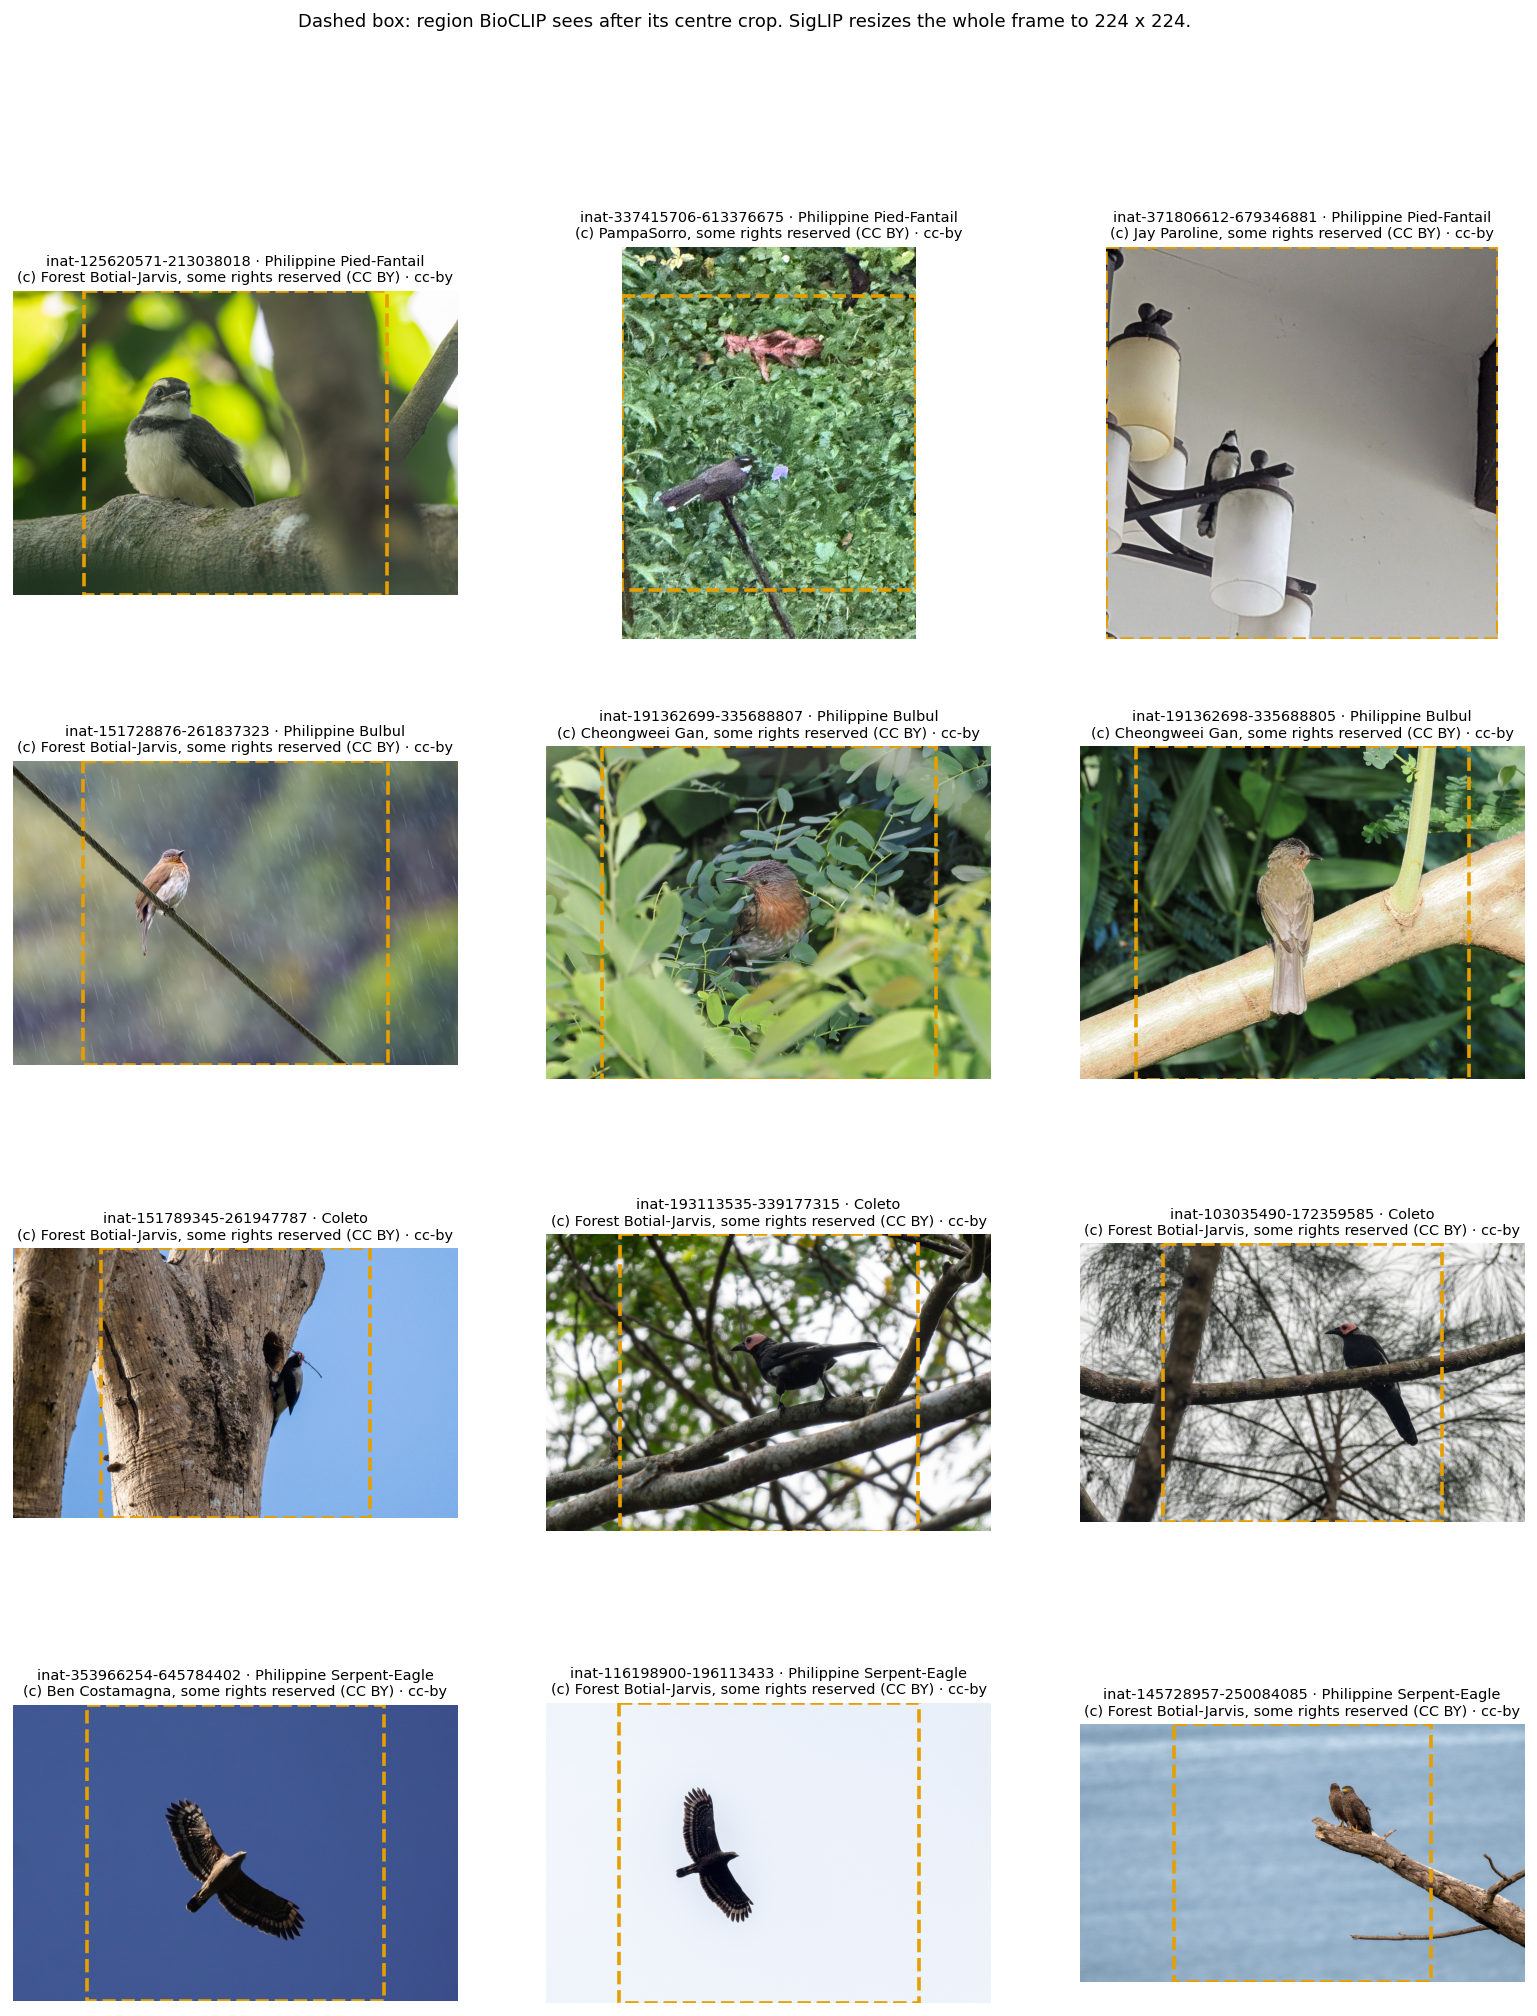

| id | attribution | observation_url | license_code | license_url |
| --- | --- | --- | --- | --- |
| inat-151789345-261947787 | (c) Forest Botial-Jarvis, some rights reserved (CC BY) | https://www.inaturalist.org/observations/151789345 | cc-by | https://creativecommons.org/licenses/by/4.0/ |
| inat-193113535-339177315 | (c) Forest Botial-Jarvis, some rights reserved (CC BY) | https://www.inaturalist.org/observations/193113535 | cc-by | https://creativecommons.org/licenses/by/4.0/ |
| inat-103035490-172359585 | (c) Forest Botial-Jarvis, some rights reserved (CC BY) | https://www.inaturalist.org/observations/103035490 | cc-by | https://creativecommons.org/licenses/by/4.0/ |
| inat-344854106-628387309 | (c) tlaloc27, some rights reserved (CC BY) | https://www.inaturalist.org/observations/344854106 | cc-by | https://creativecommons.org/licenses/by/4.0/ |
| inat-354080353-645993543 | (c) Ben Costamagna, some rights reserved (CC BY) | https://www.inaturalist.org/observations/354080353 | cc-by | https://creativecommons.org/licenses/by/4.0/ |
| inat-191336044-335635671 | (c) Cheongweei Gan, some rights reserved (CC BY) | https://www.inaturalist.org/observations/191336044 | cc-by | https://creativecommons.org/licenses/by/4.0/ |
| inat-191262903-335487214 | (c) Cheongweei Gan, some rights reserved (CC BY) | https://www.inaturalist.org/observations/191262903 | cc-by | https://creativecommons.org/licenses/by/4.0/ |
| inat-254716730-456310623 | (c) Mathieu Soetens, some rights reserved (CC BY) | https://www.inaturalist.org/observations/254716730 | cc-by | https://creativecommons.org/licenses/by/4.0/ |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/attribution.csv
Showing 8 of 61 records. Open the CSV for all rows and fields.


| probe | refused | reason |
| --- | --- | --- |
| disallowed licence | True | Disallowed photo licence |
| missing attribution | True | Missing attribution/licence URL |
| duplicate photo | True | Duplicate photo_id |
| duplicate observation | True | Duplicate observation_id |
| duplicate bytes | True | Duplicate sha256 |
| coordinates | True | Precise location/private metadata forbidden: latitude |
| too small | True | Image dimension ceiling |
| too large | True | Image dimension ceiling |
| unsupported format | True | Unsupported image format |
| missing test class | True | Canonical dataset requires four classes and 56 records |
| observer leakage | True | Observer leakage across roles |
| path traversal | True | Unsafe relative path: ../outside |
| changed bytes | True | Modified image cache: inat-151789345-261947787 |
| changed sha256 | True | Modified image cache: inat-151789345-261947787 |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/refusal_probe_results.csv


In [ ]:
run_stage('prepare')
show_table('dataset_summary.csv')
show_table('observer_roles.csv')
show_table('dataset_audit.csv', limit=40)
show_record('download_dataset.json')
show_figures('contact_train.png')
show_table('attribution.csv', limit=8)
show_table('refusal_probe_results.csv')

**What to notice:** inspect crop geometry as well as the original framing. The dashed box on each contact-sheet photograph marks the square BioCLIP actually sees after its centre crop; SigLIP instead resizes the whole frame to 224 × 224, which can squash wide photographs. The organism may occupy very different fractions of each photograph, and the audit table lists the sample builder's recorded crop limitations. Read observer counts alongside image counts. Look for one case where background or crop could help or hurt identification.

<details><summary>Why keep observers separate?</summary>Pictures by one observer can share camera characteristics, editing style and places. Placing that observer on both sides of the split could reward these shortcuts. Global grouping reduces this within-sample leakage; it does not prove pretraining independence.</details>

**Pretraining boundary:** BioCLIP's TreeOfLife pretraining and SigLIP's web-scale pretraining may include these photographs or related content. Exact overlap is unresolved. Holding out our observers protects head fitting and model selection inside this capstone; it cannot establish novel species, sites or images relative to pretraining.

## 4. Start with simple baselines

The **majority baseline** chooses the most frequent training label, with a fixed lexical tie-break. The **colour nearest-centroid baseline** measures coarse RGB features in the model-visible centre crop, fits a class centroid using training images and selects the nearest one. These ask whether label balance or simple appearance already explains a result.

Only validation results are shown here. **Accuracy** is the fraction correct; **macro-F1** averages each species' F1 equally. F1 combines precision (how often a predicted species is right) and recall (how many examples of that species were found). For comparable tables, the declared zero-division convention reports precision as zero when a class has no predictions; mathematically its denominator is empty. Read predicted counts and support before interpreting averages.

Predict: will the colour baseline separate the species, or mostly exploit backgrounds?

| system | accuracy | macro_f1 | top2_accuracy |
| --- | --- | --- | --- |
| majority | 0.2500 | 0.1000 | undefined |
| colour | 0.4167 | 0.4111 | 0.5000 |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/validation_baselines.csv
baseline validation


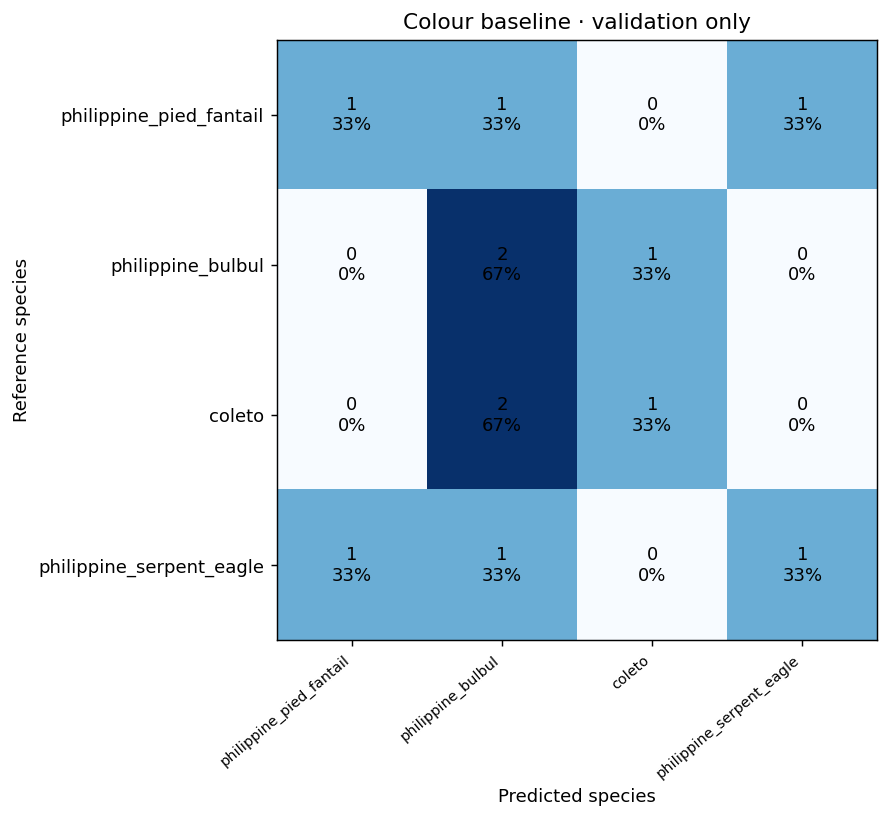

In [ ]:
show_table('validation_baselines.csv')
show_figures('baseline_validation.png')

**Interpret:** use the validation confusion counts to identify a weak class. A simple baseline succeeding is useful evidence; the biological model is not required to win. Keep all methods and all selected records in the final comparison.

## 5. Compare general and biological zero-shot systems

**Input:** the same images and either common or scientific names. **System:** pinned SigLIP 2 followed by pinned BioCLIP 2. **Output:** candidate rankings and validation metrics under four predeclared conditions.

SigLIP 2 is the general-purpose comparator. BioCLIP 2 is trained for biological representations. **BioCLIP scientific-name zero-shot is the canonical zero-shot reference** regardless of which prompt appears better. Their score magnitudes are not directly comparable or calibrated probabilities of taxonomic truth.

Each model runs under its own documented convention, so neither is handicapped by our formatting. SigLIP 2 was trained on lowercased text padded to 64 tokens, so its prompts are "This is a photo of {name}." with the name lowercased and the text padded to 64 tokens; its scores are independent sigmoids. BioCLIP 2 uses "a photo of {name}." with its own tokenizer, and its scores are a softmax over the four candidates. The exact SigLIP prompts are exported in `siglip_preprocessing.json`.

Predict whether scientific names will help both models equally. Change only the prompt vocabulary: keep images, split, checkpoints and preprocessing fixed. Models run sequentially, with process exit releasing memory between them.

Running siglip-zero-shot in a separate process. Log: /content/outputs/philippine_biodiversity/90d9a3b725c8/siglip-zero-shot.log


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


{"stage": "siglip-zero-shot", "products": 4, "status": "complete"}


| Evidence | Value |
| --- | --- |
| template | This is a photo of {}. |
| label text lowercased | True |
| padding | max_length |
| max length | 64 |
| score | sigmoid(logits_per_image); not normalised across candidates |
| source | Transformers SigLIP 2 usage notes (lowercased text, padding to 64 tokens) |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/siglip_preprocessing.json


...

{"stage": "bioclip-zero-shot", "products": 9, "status": "complete"}


| system | accuracy | macro_f1 | top2_accuracy |
| --- | --- | --- | --- |
| bioclip_common | 1.0000 | 1.0000 | 1.0000 |
| bioclip_scientific | 0.9167 | 0.9143 | 1.0000 |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/validation_bioclip.csv


| system | label | precision | recall | f1 | support | predicted |
| --- | --- | --- | --- | --- | --- | --- |
| bioclip_common | philippine_pied_fantail | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_common | philippine_bulbul | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_common | coleto | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_common | philippine_serpent_eagle | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_scientific | philippine_pied_fantail | 1.0000 | 0.6667 | 0.8000 | 3 | 2 |
| bioclip_scientific | philippine_bulbul | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_scientific | coleto | 0.7500 | 1.0000 | 0.8571 | 3 | 4 |
| bioclip_scientific | philippine_serpent_eagle | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| siglip_common | philippine_pied_fantail | 0.7500 | 1.0000 | 0.8571 | 3 | 4 |
| siglip_common | philippine_bulbul | 0.6000 | 1.0000 | 0.7500 | 3 | 5 |
| siglip_common | coleto | 0.0000 | 0.0000 | 0.0000 | 3 | 0 |
| siglip_common | philippine_serpent_eagle | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| siglip_scientific | philippine_pied_fantail | 0.3333 | 1.0000 | 0.5000 | 3 | 9 |
| siglip_scientific | philippine_bulbul | 0.0000 | 0.0000 | 0.0000 | 3 | 0 |
| siglip_scientific | coleto | 0.0000 | 0.0000 | 0.0000 | 3 | 0 |
| siglip_scientific | philippine_serpent_eagle | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/validation_per_class.csv
zero shot validation


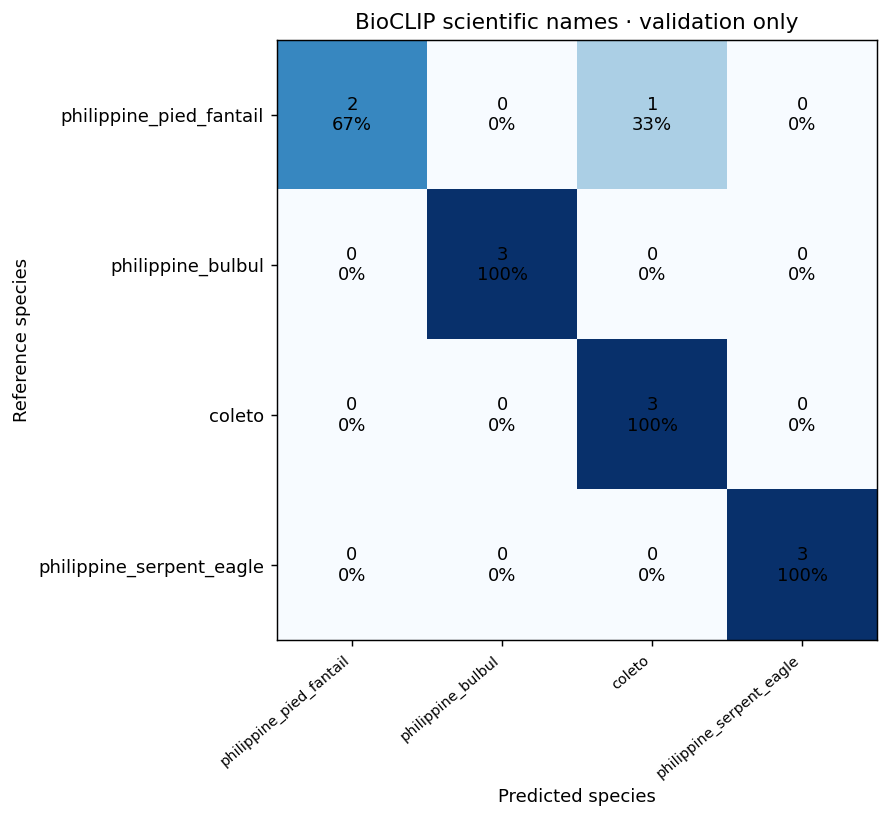

In [ ]:
run_stage('siglip-zero-shot')
show_record('siglip_preprocessing.json')
show_table('validation_siglip.csv')
run_stage('bioclip-zero-shot')
show_table('validation_bioclip.csv')
show_table('validation_per_class.csv')
show_figures('zero_shot_validation.png')

**Compare:** which prompt condition changes validation rankings, and for which species? Treat a difference from twelve validation photographs as a small-sample observation. Do not choose the canonical prompt from eventual test performance.

<details><summary>Why might scientific names behave differently?</summary>A biological model's training text may align taxonomic names closely with organism imagery; a general model may have encountered more common-name descriptions. This is a hypothesis about representation, not a guarantee for any species.</details>

## 6. Explore the frozen representation

**Input:** cached BioCLIP image vectors. **System:** L2-normalisation, train-only five-nearest-neighbour voting and a two-dimensional PCA projection fitted on train only. **Output:** validation predictions and a view of the embedding geometry.

For **5-NN**, only training images can be neighbours; votes sum non-negative cosine similarities, with fixed class-order ties. No gradients are needed. **PCA** compresses vectors to two coordinates for display; it can hide separation or invent apparent clusters. Split shapes and species colours are visual aids, not additional evaluation evidence.

Predict whether images of one species cluster together even when their observers differ.

Running representations in a separate process. Log: /content/outputs/philippine_biodiversity/90d9a3b725c8/representations.log


{"stage": "representations", "products": 3, "status": "complete"}


| system | accuracy | macro_f1 | top2_accuracy |
| --- | --- | --- | --- |
| bioclip_5nn | 1.0000 | 1.0000 | 1.0000 |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/validation_knn.csv
pca


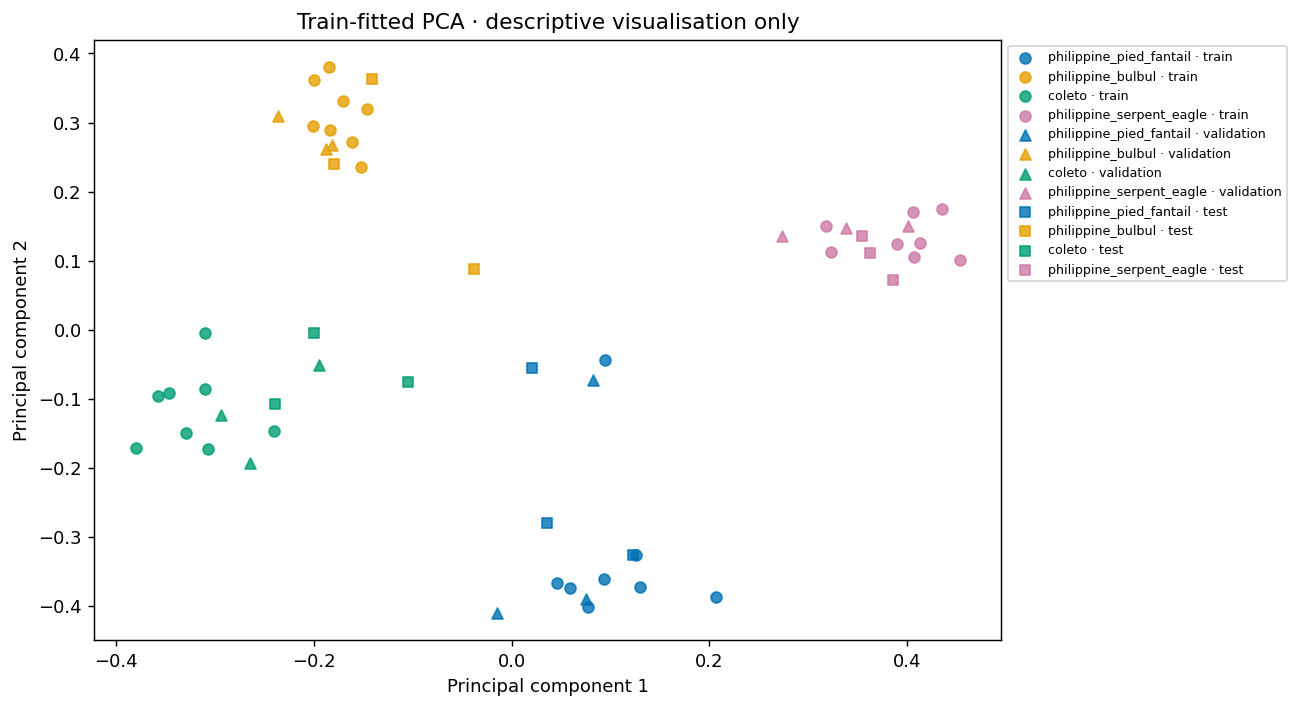

In [ ]:
run_stage('representations')
show_table('validation_knn.csv')
show_figures('pca.png')

**What to notice:** compare validation 5-NN results with zero-shot results. Neighbour voting tests how this local training set is arranged in the representation. A plausible PCA cluster does not establish accuracy, independence or a species' geographic distribution.

## 7. Fit a small head and lock the policy

Both BioCLIP towers stay frozen. A linear head starts from scientific-name text embeddings, scaled by BioCLIP's logit scale, so **epoch 0 of the head is exactly the BioCLIP scientific-name zero-shot classifier**. It is then fitted on training vectors using float32 AdamW, seed 42 and at most 20 epochs. This is **head-only adaptation**, not full-model fine-tuning.

The learning rate matters here. The starting weights are large (typically about 3.6 in magnitude), so a very small rate can barely move them in 80 optimiser steps, and "no change from zero-shot" would then be decided by the step size, not by the data. The head is therefore fitted once for each rate in a small grid declared in advance (1e-4, 1e-3 and 1e-2). **Validation cross-entropy alone selects the rate and the epoch together**; ties keep the earlier epoch, then the smaller rate. Epoch 0 competes too: if it wins, the exported head *is* the zero-shot classifier, and the record below says so. The table also reports how far the head moved: the largest weight and logit changes, and how many training and validation predictions differ from zero-shot.

Before any test metrics are revealed, lock the referral rule using **validation only**. Confidence is the largest minus second-largest head softmax score. Consider every distinct validation margin, requiring at least 50% coverage. Among thresholds reaching 80% selective accuracy choose greatest coverage; if none reaches it, choose greatest selective accuracy then coverage. Remaining ties choose the higher threshold. Acceptance uses the declared threshold comparison consistently.

The 80% teaching target is not a deployment guarantee. With twelve validation records, one decision can materially change a percentage. Predict whether decreasing training loss will always improve validation loss.

Running adapt-head in a separate process. Log: /content/outputs/philippine_biodiversity/90d9a3b725c8/adapt-head.log


{"stage": "adapt-head", "products": 7, "status": "complete"}


| Evidence | Value |
| --- | --- |
| trainable tensors | head.bias, head.weight |
| trainable parameters | 3076 |
| frozen | both BioCLIP towers |
| optimizer | AdamW |
| learning rate grid | 0.0001, 0.001, 0.01 |
| selected learning rate | 0.01 |
| weight decay | 0.0100 |
| batch size | 8 |
| max epochs | 20 |
| selected epoch | 20 |
| selected validation cross entropy | 0.0177 |
| head equals zero shot | False |
| max abs weight change train validation | 0.4676 |
| max abs bias train validation | 0.1326 |
| max abs logit change train validation | 3.4820 |
| predictions changed vs zero shot train validation | 2 |
| records compared train validation | 44 |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/head_training.json


| Evidence | Value |
| --- | --- |
| threshold | 0.6202107991 |
| coverage | 1.0000 |
| count | 12 |
| selective accuracy | 1.0000 |
| incorrect accepted | 0 |
| referred | 0 |
| selected learning rate | 0.01 |
| selected epoch | 20 |
| head equals zero shot | False |
| selection | minimum validation cross-entropy over the predeclared learning-rate grid and epochs 0-20; ties keep the earlier epoch, then the smaller rate |
| selection split | validation |
| locked before test | True |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/selected_policy.json
loss


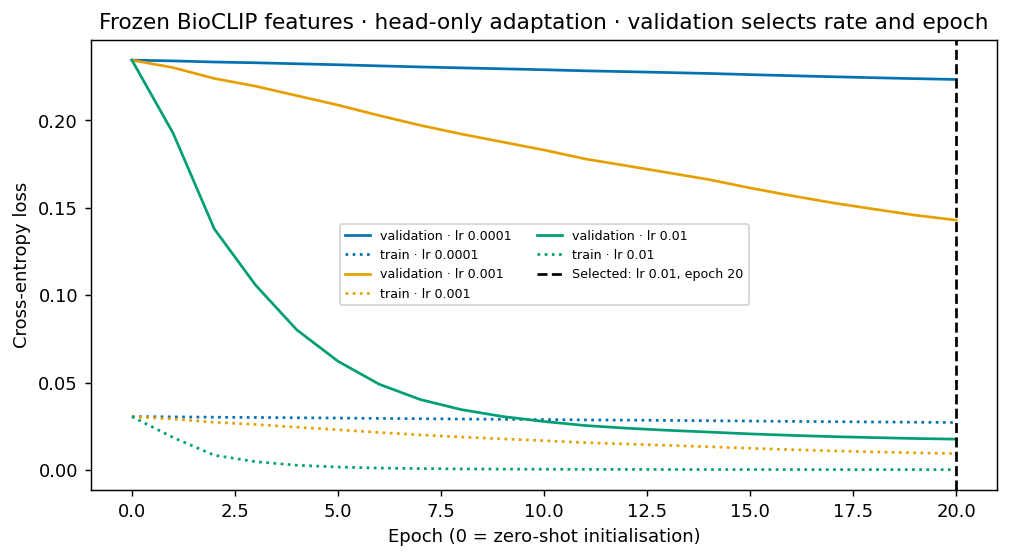

In [ ]:
run_stage('adapt-head')
show_record('head_training.json')
show_record('selected_policy.json')
show_figures('loss.png')

**Interpret:** locate the selected rate and epoch rather than assuming the final epoch is best. A widening train/validation gap can indicate overfitting even with a frozen backbone. If `head equals zero shot` is True, validation evidence did not favour moving away from the text prior; the head and the canonical zero-shot system will then agree on every test photograph. The head and validation threshold are now fixed. The next section must preserve negative or inconclusive results.

## 8. Reveal the observer-disjoint test results

**Input:** test photographs excluded from head fitting and all capstone selection. **System:** the eight predeclared systems with frozen settings. **Output:** the primary head macro-F1 endpoint, comparisons, per-species counts and uncertainty intervals.

The systems are majority, colour, SigLIP common/scientific names, BioCLIP common/scientific names, BioCLIP 5-NN and the BioCLIP head. Top-2 accuracy asks whether the true label occurs among the two highest scores; it does not mean either is verified. The majority baseline has no second choice (its scores are one-hot), so its top-2 accuracy is shown as undefined.

Accuracy and macro-F1 intervals come from 2,000 deterministic bootstrap resamples that **resample photographs within each species**, so every resample keeps three test photographs per species. Resampling without that constraint would sometimes drop a species entirely, and macro-F1 would then score it 0: even a classifier that is right on every photograph would receive a lower bound near 0.75. The intervals still treat photographs as independent although they come from only a few photographers (see `test observers` in the table), so they are optimistic, and they omit pretraining overlap, selection bias and label error.

Predict whether head adaptation improves every species or redistributes errors. Do not revise the head, prompt, k or threshold after reading this section.

Running evaluate in a separate process. Log: /content/outputs/philippine_biodiversity/90d9a3b725c8/evaluate.log


/content/outputs/philippine_biodiversity/90d9a3b725c8/capstone.py:121: UserWarning: Glyph 21570 (\N{CJK UNIFIED IDEOGRAPH-5442}) missing from font(s) DejaVu Sans.


  fig.savefig(destination, dpi=130, bbox_inches="tight")


/content/outputs/philippine_biodiversity/90d9a3b725c8/capstone.py:121: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.


  fig.savefig(destination, dpi=130, bbox_inches="tight")


...

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/metrics.csv


| system | accuracy_low | accuracy_high | macro_f1_low | macro_f1_high | test_observers | paired_correctness_difference_vs_bioclip_scientific |
| --- | --- | --- | --- | --- | --- | --- |
| majority | 0.2500 | 0.2500 | 0.1000 | 0.1000 | 4 | -0.7500 |
| colour | 0.3333 | 0.6667 | 0.2589 | 0.6167 | 4 | -0.5000 |
| siglip_common | 0.5000 | 0.5000 | 0.3375 | 0.4018 | 4 | -0.5000 |
| siglip_scientific | 0.2500 | 0.5000 | 0.1875 | 0.3506 | 4 | -0.6667 |
| bioclip_common | 0.7500 | 1.0000 | 0.6667 | 1.0000 | 4 | -0.0833 |
| bioclip_scientific | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 4 | 0.0000 |
| bioclip_5nn | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 4 | 0.0000 |
| bioclip_head | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 4 | 0.0000 |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/metrics.csv


| system | label | precision | recall | f1 | support | predicted |
| --- | --- | --- | --- | --- | --- | --- |
| majority | philippine_pied_fantail | 0.0000 | 0.0000 | 0.0000 | 3 | 0 |
| majority | philippine_bulbul | 0.0000 | 0.0000 | 0.0000 | 3 | 0 |
| majority | coleto | 0.2500 | 1.0000 | 0.4000 | 3 | 12 |
| majority | philippine_serpent_eagle | 0.0000 | 0.0000 | 0.0000 | 3 | 0 |
| colour | philippine_pied_fantail | 0.5000 | 0.3333 | 0.4000 | 3 | 2 |
| colour | philippine_bulbul | 0.7500 | 1.0000 | 0.8571 | 3 | 4 |
| colour | coleto | 0.0000 | 0.0000 | 0.0000 | 3 | 1 |
| colour | philippine_serpent_eagle | 0.4000 | 0.6667 | 0.5000 | 3 | 5 |
| siglip_common | philippine_pied_fantail | 0.0000 | 0.0000 | 0.0000 | 3 | 0 |
| siglip_common | philippine_bulbul | 0.4286 | 1.0000 | 0.6000 | 3 | 7 |
| siglip_common | coleto | 0.0000 | 0.0000 | 0.0000 | 3 | 1 |
| siglip_common | philippine_serpent_eagle | 0.7500 | 1.0000 | 0.8571 | 3 | 4 |
| siglip_scientific | philippine_pied_fantail | 0.1667 | 0.3333 | 0.2222 | 3 | 6 |
| siglip_scientific | philippine_bulbul | 0.0000 | 0.0000 | 0.0000 | 3 | 2 |
| siglip_scientific | coleto | 0.0000 | 0.0000 | 0.0000 | 3 | 0 |
| siglip_scientific | philippine_serpent_eagle | 0.7500 | 1.0000 | 0.8571 | 3 | 4 |
| bioclip_common | philippine_pied_fantail | 1.0000 | 0.6667 | 0.8000 | 3 | 2 |
| bioclip_common | philippine_bulbul | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_common | coleto | 0.7500 | 1.0000 | 0.8571 | 3 | 4 |
| bioclip_common | philippine_serpent_eagle | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_scientific | philippine_pied_fantail | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_scientific | philippine_bulbul | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_scientific | coleto | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_scientific | philippine_serpent_eagle | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_5nn | philippine_pied_fantail | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_5nn | philippine_bulbul | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_5nn | coleto | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_5nn | philippine_serpent_eagle | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_head | philippine_pied_fantail | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_head | philippine_bulbul | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_head | coleto | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |
| bioclip_head | philippine_serpent_eagle | 1.0000 | 1.0000 | 1.0000 | 3 | 3 |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/per_class_metrics.csv
confusion test bioclip 5nn


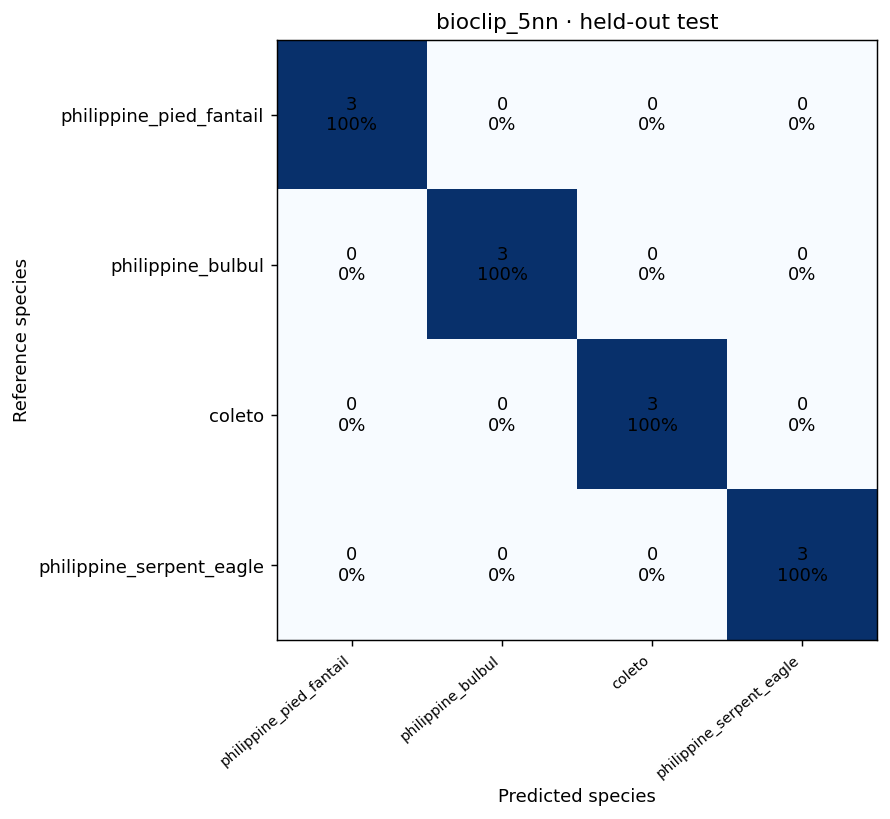

confusion test bioclip common


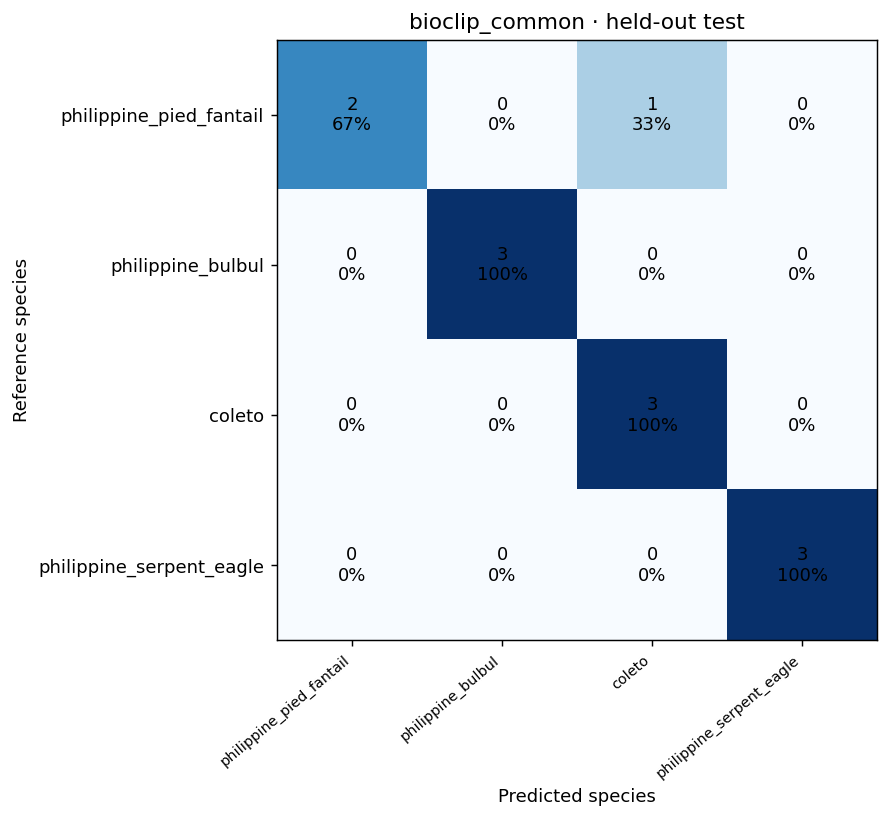

confusion test bioclip head


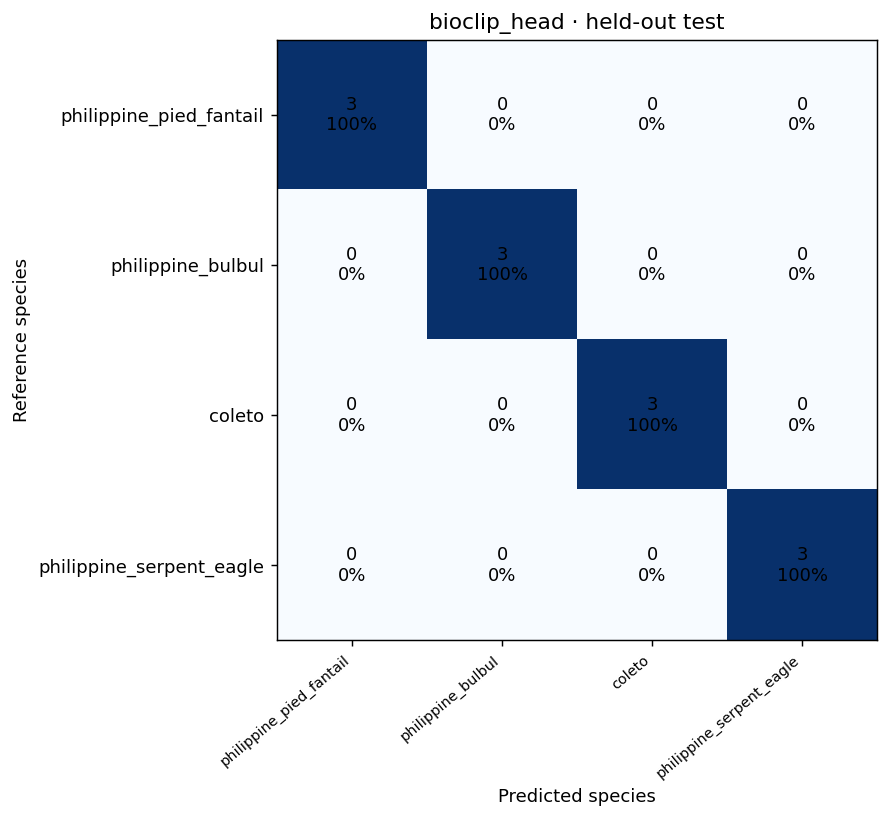

confusion test bioclip scientific


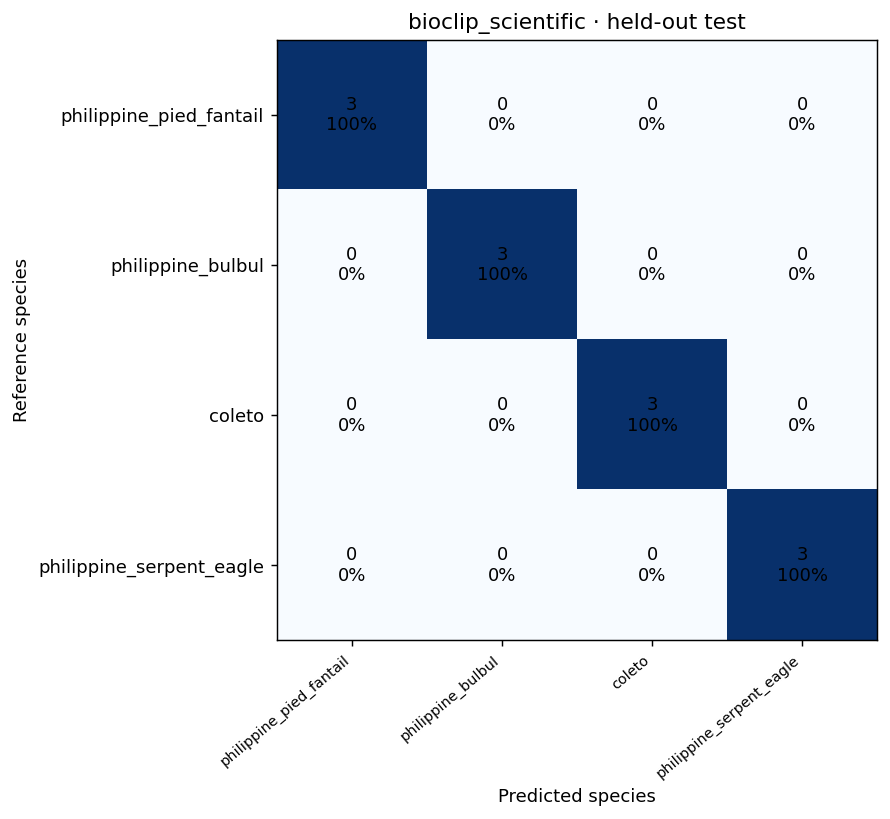

confusion test colour


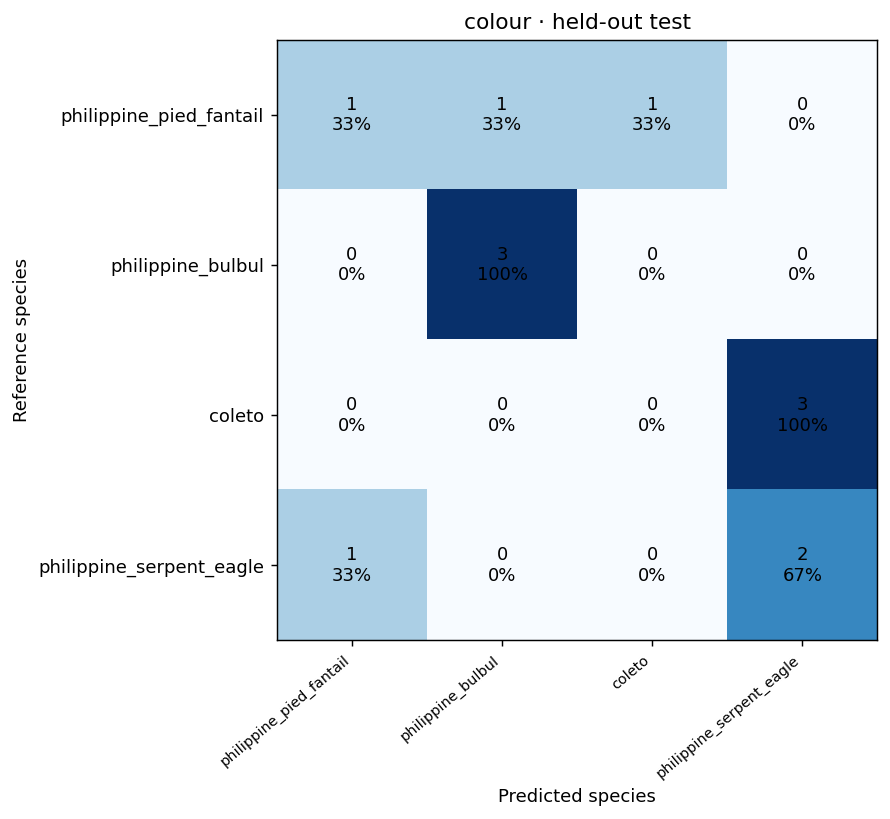

confusion test majority


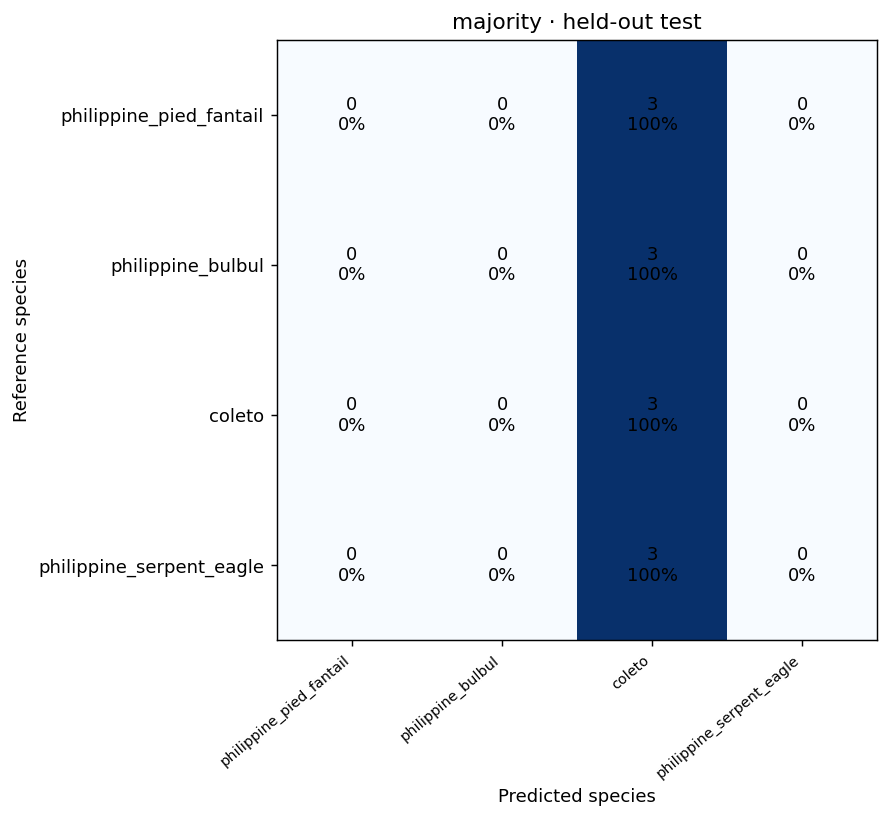

confusion test siglip common


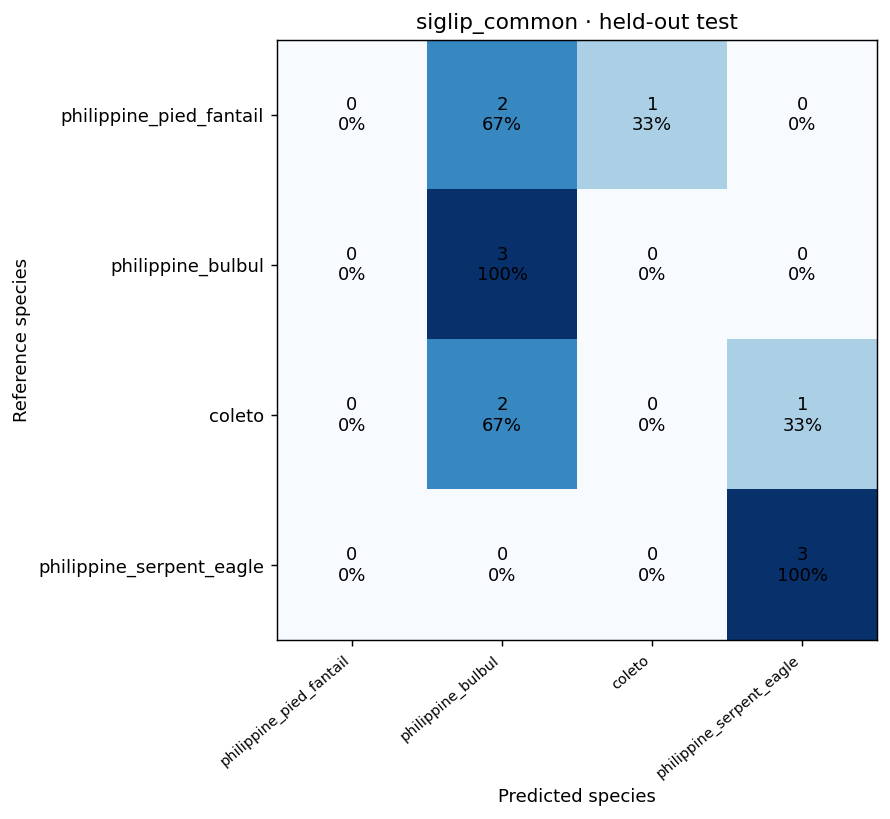

confusion test siglip scientific


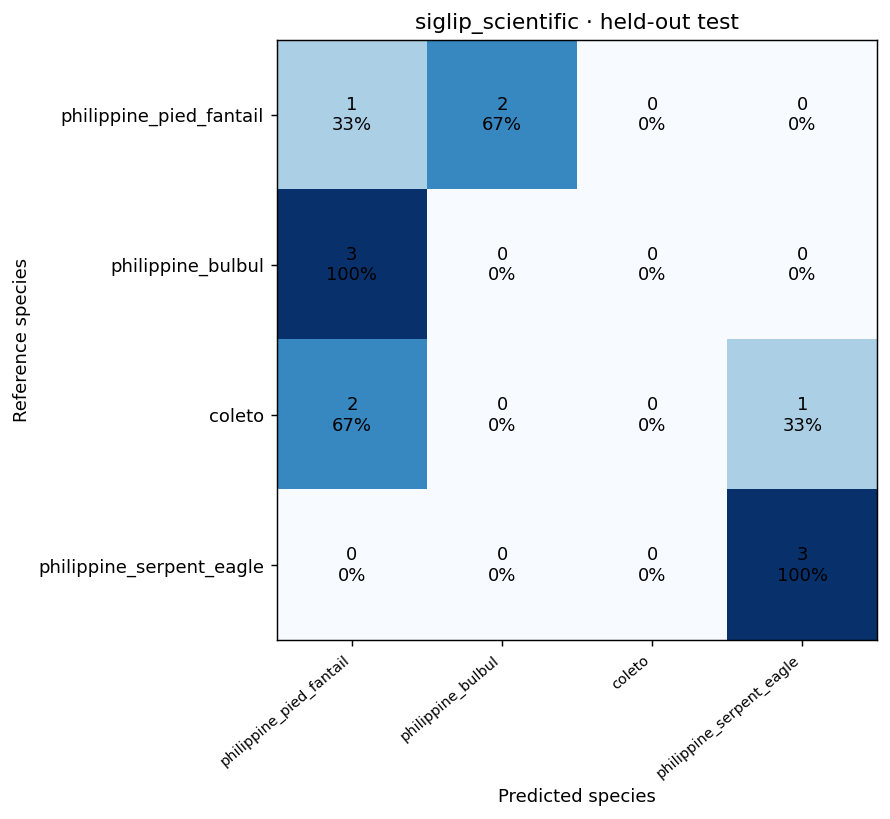

| category | id | available_records | shown | truth | prediction | margin | decision |
| --- | --- | --- | --- | --- | --- | --- | --- |
| highest-margin correct | inat-371150582-678109140 | 12 | True | philippine_pied_fantail | philippine_pied_fantail | 0.999999983 | accept |
| highest-margin incorrect | undefined | 0 | False | undefined | undefined | undefined | undefined |
| lowest margin | inat-274691310-493753571 | 12 | True | coleto | coleto | 0.6357904671 | accept |
| head and SigLIP (scientific) disagree | inat-314130723-567333486 | 8 | True | philippine_bulbul | philippine_bulbul | 0.8623386176 | accept |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/error_panel.csv
errors


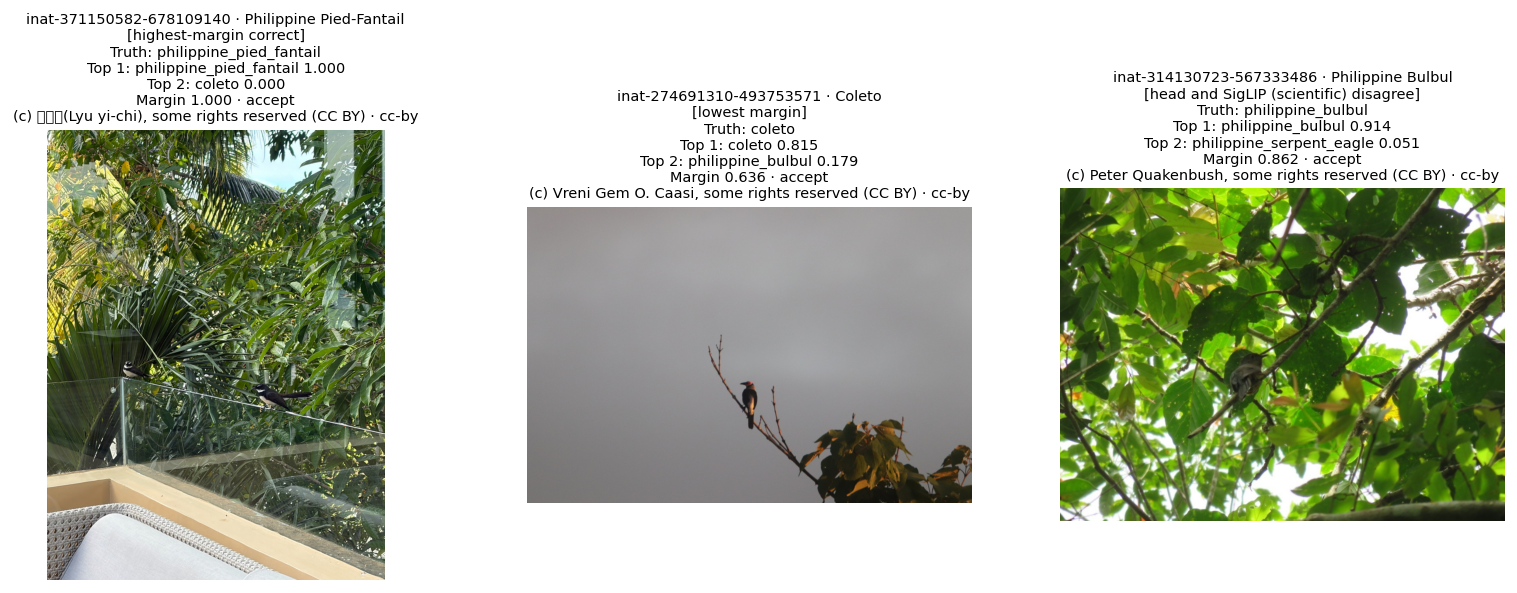

In [ ]:
run_stage('evaluate')
show_table('metrics.csv')
show_table('metrics.csv', columns=['system', 'accuracy_low', 'accuracy_high', 'macro_f1_low', 'macro_f1_high', 'test_observers', 'paired_correctness_difference_vs_bioclip_scientific'])
show_table('per_class_metrics.csv', limit=32)
show_figures('confusion_test_*.png')
show_table('error_panel.csv')
if (ROOT / 'outputs' / 'figures' / 'errors.png').exists():
    show_figures('errors.png')

**What to notice:** pair each average with support and predicted counts. Read confusion counts and row-normalised percentages. The error panel uses four declared diagnostic categories, each named in square brackets above its photograph: the highest-margin correct prediction, the highest-margin incorrect prediction (which may still have a modest margin), the lowest-margin prediction, and a photograph where the head and SigLIP (scientific names) disagree. Each photograph appears once; when a record already represents an earlier category, the next candidate is used. The `error_panel.csv` table reports any category with no test record; do not manufacture a failure or success to fill it.

Compare the head with the canonical BioCLIP scientific-name reference using paired per-record correctness. Identify one plausible explanation and one alternative, such as crop, background, community label uncertainty or pretraining overlap. These twelve test images do not estimate nationwide identification performance.

## 9. Change one thing: the review threshold

**Predict → change one thing → run → observe → explain.** First run the canonical triage policy. It reports acceptance coverage, accuracy among accepted cases, incorrect accepted cases, referrals and per-species referral rates. Primary classification metrics still include every test record.

Then use the form below to display a lower, canonical or higher threshold. "Lower" and "higher" are the neighbouring candidate thresholds from the validation sweep, the next distinct value below and above the locked one, so each view is a threshold that the validation sweep actually evaluated. On the test photographs a step can still leave every decision unchanged if no test margin falls between the two values; the comparison table shows the accepted and referred counts either way. Thresholds are shown with ten significant digits because head margins can sit very close to 1. Only the display decision changes. Weights, scores, records and canonical exports remain fixed. The test risk-coverage curve is a diagnostic, not permission to retune the reported policy.

Predict how a higher threshold changes coverage. Does it necessarily remove all incorrect accepted cases?

Running triage in a separate process. Log: /content/outputs/philippine_biodiversity/90d9a3b725c8/triage.log


{"stage": "triage", "products": 6, "status": "complete"}


| split | count | threshold | coverage | selective_accuracy | referred | incorrect_accepted | canonical |
| --- | --- | --- | --- | --- | --- | --- | --- |
| validation | 12 | 0 | 1.0000 | 1.0000 | 0 | 0 | False |
| validation | 12 | 0.6202107991 | 1.0000 | 1.0000 | 0 | 0 | True |
| validation | 11 | 0.999889479 | 0.9167 | 1.0000 | 1 | 0 | False |
| validation | 10 | 0.9998935028 | 0.8333 | 1.0000 | 2 | 0 | False |
| validation | 9 | 0.9999217986 | 0.7500 | 1.0000 | 3 | 0 | False |
| validation | 8 | 0.9999647923 | 0.6667 | 1.0000 | 4 | 0 | False |
| validation | 7 | 0.9999910004 | 0.5833 | 1.0000 | 5 | 0 | False |
| validation | 6 | 0.9999947272 | 0.5000 | 1.0000 | 6 | 0 | False |
| validation | 5 | 0.9999979464 | 0.4167 | 1.0000 | 7 | 0 | False |
| validation | 4 | 0.9999995267 | 0.3333 | 1.0000 | 8 | 0 | False |
| validation | 3 | 0.9999998164 | 0.2500 | 1.0000 | 9 | 0 | False |
| validation | 2 | 0.9999998552 | 0.1667 | 1.0000 | 10 | 0 | False |
| validation | 1 | 0.9999999993 | 0.0833 | 1.0000 | 11 | 0 | False |
| validation | 0 | 0.9999999993 | 0.0000 | undefined | 12 | 0 | False |
| test | 12 | 0 | 1.0000 | 1.0000 | 0 | 0 | False |
| test | 12 | 0.6202107991 | 1.0000 | 1.0000 | 0 | 0 | True |
| test | 12 | 0.6357904671 | 1.0000 | 1.0000 | 0 | 0 | False |
| test | 11 | 0.8623386176 | 0.9167 | 1.0000 | 1 | 0 | False |
| test | 10 | 0.9987875998 | 0.8333 | 1.0000 | 2 | 0 | False |
| test | 9 | 0.9989832384 | 0.7500 | 1.0000 | 3 | 0 | False |
| test | 8 | 0.9994583844 | 0.6667 | 1.0000 | 4 | 0 | False |
| test | 7 | 0.9999142213 | 0.5833 | 1.0000 | 5 | 0 | False |
| test | 6 | 0.9999959014 | 0.5000 | 1.0000 | 6 | 0 | False |
| test | 5 | 0.9999967445 | 0.4167 | 1.0000 | 7 | 0 | False |
| test | 4 | 0.9999983616 | 0.3333 | 1.0000 | 8 | 0 | False |
| test | 3 | 0.9999988729 | 0.2500 | 1.0000 | 9 | 0 | False |
| test | 2 | 0.9999997729 | 0.1667 | 1.0000 | 10 | 0 | False |
| test | 1 | 0.999999983 | 0.0833 | 1.0000 | 11 | 0 | False |
| test | 0 | 0.999999983 | 0.0000 | undefined | 12 | 0 | False |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/risk_coverage.csv


| label | count | referred | incorrect_accepted |
| --- | --- | --- | --- |
| philippine_pied_fantail | 3 | 0 | 0 |
| philippine_bulbul | 3 | 0 | 0 |
| coleto | 3 | 0 | 0 |
| philippine_serpent_eagle | 3 | 0 | 0 |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/referral_by_species.csv


| Evidence | Value |
| --- | --- |
| lower | 0 |
| canonical | 0.6202107991 |
| higher | 0.999889479 |
| rule | adjacent distinct validation candidate thresholds around the locked value |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/activity_thresholds.json
risk coverage


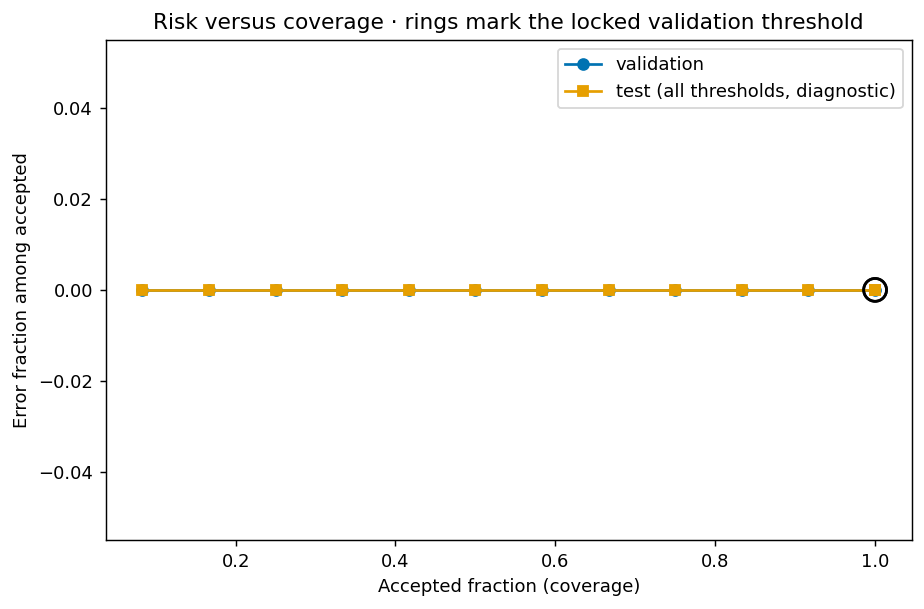

In [ ]:
run_stage('triage')
show_table('risk_coverage.csv', limit=40)
show_table('referral_by_species.csv')
show_record('activity_thresholds.json')
show_figures('risk_coverage.png')

Locked threshold: 0.6202107991; display-only threshold (canonical): 0.6202107991
Running triage in a separate process. Log: /content/outputs/philippine_biodiversity/90d9a3b725c8/triage.log


| Evidence | Value |
| --- | --- |
| display only | True |
| canonical threshold | 0.6202107991 |
| display threshold | 0.6202107991 |

| threshold | count | coverage | selective_accuracy | referred | incorrect_accepted |
| --- | --- | --- | --- | --- | --- |
| 0.6202107991 | 12 | 1.0000 | 1.0000 | 0 | 0 |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/activity.json
activity


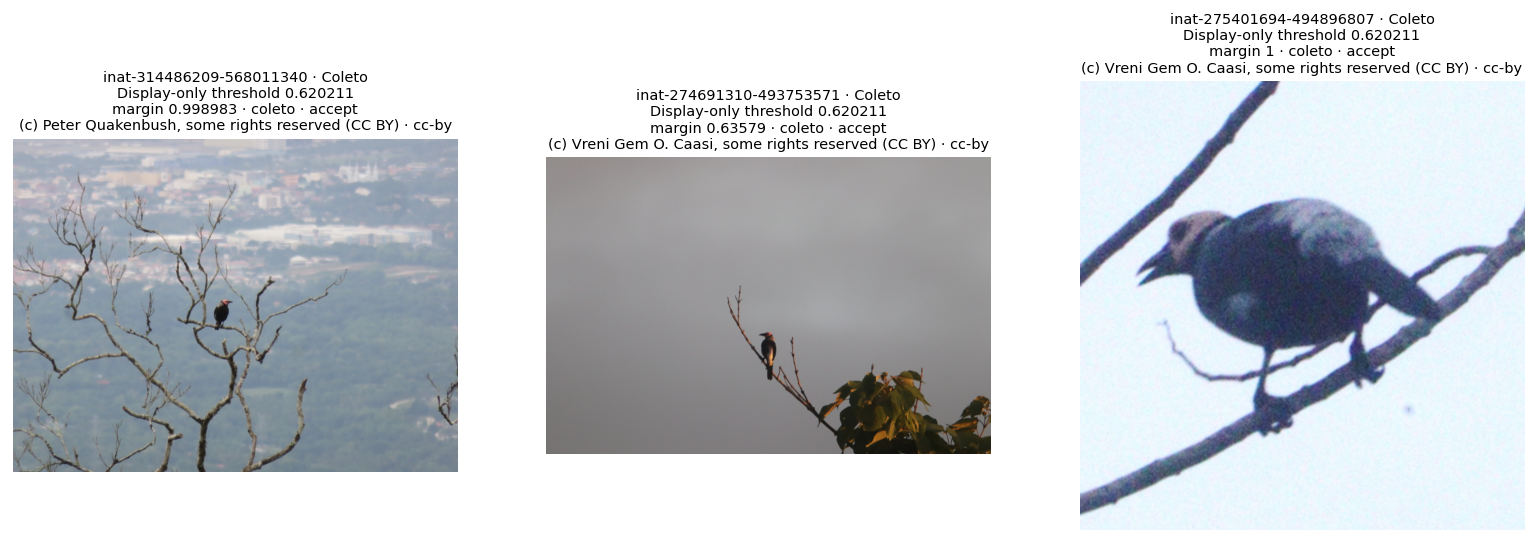

In [ ]:
# @title Display-only review-threshold activity
THRESHOLD_VIEW = 'canonical' # @param ['lower', 'canonical', 'higher']
views = json.loads((ROOT / 'outputs' / 'activity_thresholds.json').read_text(encoding='utf-8'))
threshold = float(views['canonical'])
display_threshold = float(views[THRESHOLD_VIEW])
print(f'Locked threshold: {threshold:.10g}; display-only threshold ({THRESHOLD_VIEW}): {display_threshold:.10g}')
if THRESHOLD_VIEW != 'canonical' and display_threshold == threshold:
    print('No distinct validation candidate exists on this side of the locked threshold.')
run_stage('triage', '--display-threshold', repr(display_threshold))
show_record('activity.json')
show_figures('activity.png')

**Explain:** compare how many records were accepted and how many accepted labels were wrong. A high margin may still accompany a confident mistake. Referral is a workflow policy, not calibrated uncertainty or a reliable detector of unfamiliar organisms.

## 10. Challenge the closed candidate list

The separate probe set includes at least two bird species outside the candidate list, two non-bird Philippine organisms and a synthetic blank control. These records never enter fitting, threshold selection or primary metrics.

**Input:** unsuitable or outside-list images. **System:** every predeclared system, plus the same four-class head and locked policy. **Output:** forced candidate labels from every system, and descriptive referral behaviour for the head. Predict whether all unsuitable images will be referred.

| id | system | truth | prediction | margin | accepted |
| --- | --- | --- | --- | --- | --- |
| inat-347455224-633525793 | bioclip_head | outside_bird_flowerpecker | philippine_pied_fantail | 0.9114133127 | True |
| inat-339451045-617512617 | bioclip_head | outside_bird_sparrow | philippine_pied_fantail | 0.195016903 | False |
| inat-255155973-457196725 | bioclip_head | nonbird_butterfly | philippine_pied_fantail | 0.9969041704 | True |
| inat-379912631-694982033 | bioclip_head | nonbird_snail | philippine_pied_fantail | 0.9953998238 | True |
| blank-control | bioclip_head | blank_control | philippine_pied_fantail | 0.5262919035 | False |
| inat-347455224-633525793 | majority | outside_bird_flowerpecker | coleto | 1 | undefined |
| inat-339451045-617512617 | majority | outside_bird_sparrow | coleto | 1 | undefined |
| inat-255155973-457196725 | majority | nonbird_butterfly | coleto | 1 | undefined |
| inat-379912631-694982033 | majority | nonbird_snail | coleto | 1 | undefined |
| blank-control | majority | blank_control | coleto | 1 | undefined |
| inat-347455224-633525793 | colour | outside_bird_flowerpecker | philippine_serpent_eagle | 0.00938241107 | undefined |
| inat-339451045-617512617 | colour | outside_bird_sparrow | philippine_bulbul | 0.000213720999 | undefined |
| inat-255155973-457196725 | colour | nonbird_butterfly | philippine_bulbul | 0.0006959151511 | undefined |
| inat-379912631-694982033 | colour | nonbird_snail | philippine_bulbul | 0.0005007243684 | undefined |
| blank-control | colour | blank_control | philippine_serpent_eagle | 0.0118920211 | undefined |
| inat-347455224-633525793 | siglip_common | outside_bird_flowerpecker | philippine_bulbul | 0.001504831715 | undefined |
| inat-339451045-617512617 | siglip_common | outside_bird_sparrow | philippine_serpent_eagle | 0.007641991135 | undefined |
| inat-255155973-457196725 | siglip_common | nonbird_butterfly | coleto | 0.0002926880552 | undefined |
| inat-379912631-694982033 | siglip_common | nonbird_snail | coleto | 0.0003245328262 | undefined |
| blank-control | siglip_common | blank_control | coleto | 9.063797916e-05 | undefined |
| inat-347455224-633525793 | siglip_scientific | outside_bird_flowerpecker | philippine_pied_fantail | 0.009743213654 | undefined |
| inat-339451045-617512617 | siglip_scientific | outside_bird_sparrow | philippine_bulbul | 0.0007225411246 | undefined |
| inat-255155973-457196725 | siglip_scientific | nonbird_butterfly | philippine_bulbul | 0.000662498991 | undefined |
| inat-379912631-694982033 | siglip_scientific | nonbird_snail | philippine_bulbul | 0.00724176364 | undefined |
| blank-control | siglip_scientific | blank_control | philippine_pied_fantail | 7.638334864e-06 | undefined |
| inat-347455224-633525793 | bioclip_common | outside_bird_flowerpecker | philippine_pied_fantail | 0.005638304421 | undefined |
| inat-339451045-617512617 | bioclip_common | outside_bird_sparrow | philippine_serpent_eagle | 0.8764402677 | undefined |
| inat-255155973-457196725 | bioclip_common | nonbird_butterfly | coleto | 0.5633395716 | undefined |
| inat-379912631-694982033 | bioclip_common | nonbird_snail | philippine_serpent_eagle | 0.5049047149 | undefined |
| blank-control | bioclip_common | blank_control | coleto | 0.8866178439 | undefined |
| inat-347455224-633525793 | bioclip_scientific | outside_bird_flowerpecker | coleto | 0.05555919211 | undefined |
| inat-339451045-617512617 | bioclip_scientific | outside_bird_sparrow | philippine_serpent_eagle | 0.6186774646 | undefined |
| inat-255155973-457196725 | bioclip_scientific | nonbird_butterfly | philippine_pied_fantail | 0.9525787583 | undefined |
| inat-379912631-694982033 | bioclip_scientific | nonbird_snail | philippine_pied_fantail | 0.8676984357 | undefined |
| blank-control | bioclip_scientific | blank_control | coleto | 0.1419758264 | undefined |
| inat-347455224-633525793 | bioclip_5nn | outside_bird_flowerpecker | philippine_pied_fantail | 1.325913548 | undefined |
| inat-339451045-617512617 | bioclip_5nn | outside_bird_sparrow | philippine_serpent_eagle | 2.131328285 | undefined |
| inat-255155973-457196725 | bioclip_5nn | nonbird_butterfly | philippine_serpent_eagle | 2.192817092 | undefined |
| inat-379912631-694982033 | bioclip_5nn | nonbird_snail | philippine_pied_fantail | 0.6380223036 | undefined |
| blank-control | bioclip_5nn | blank_control | philippine_pied_fantail | 0.581736207 | undefined |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/probe_predictions.csv
probes


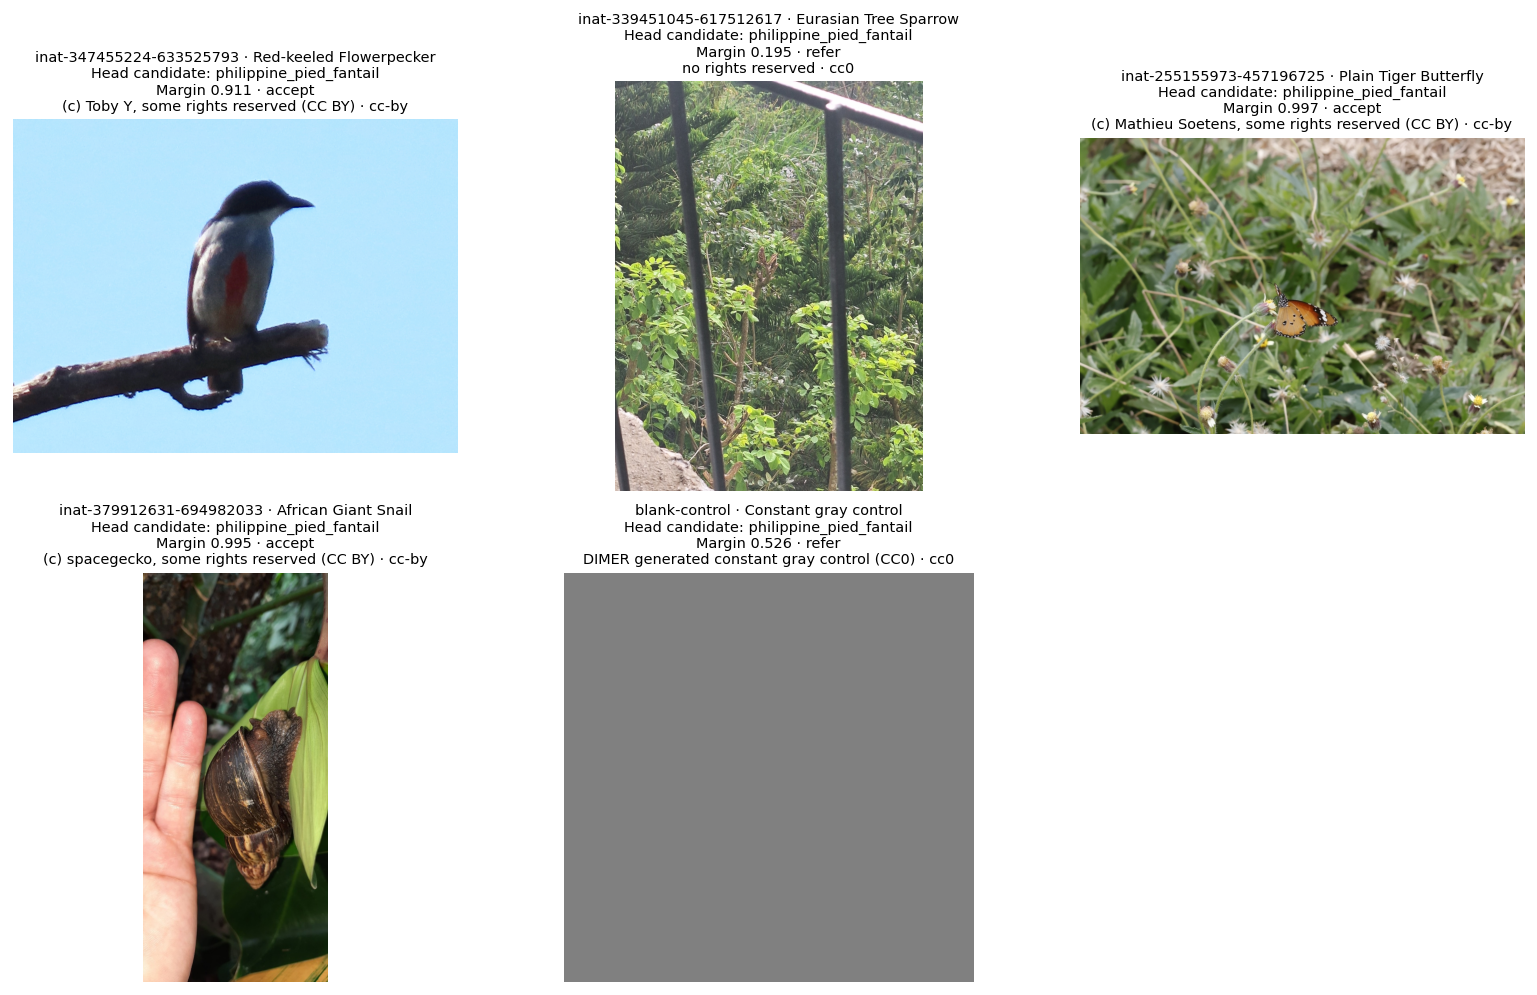

In [ ]:
show_table('probe_predictions.csv', columns=['id', 'system', 'truth', 'prediction', 'margin', 'accepted'], limit=40)
show_figures('probes.png')

**Interpret:** every system, zero-shot, nearest-neighbour or fitted, returns one of its four labels even when none is correct; `accepted` is undefined for systems without a referral policy. Some probes may be accepted confidently by the head. Record that failure rather than scoring an outside-list label as an ordinary four-class test example. Expert review and a broader validation design remain necessary for field use.

## 11. Verify the head and results bundle

The adapter contains only the declared head tensors in safetensors format. Reload verifies the base model/revision, class order, byte count, digest, tensor names, shapes and finiteness before use. A **new process ID** reconstructs BioCLIP and reproduces a fixed test probe, checking score tolerance, labels, meaningful top-2 ordering and canonical referral decisions.

The report reopens CSVs and recomputes headline metrics. It then reopens the written ZIP and checks CRCs, every member digest, member paths, the size ceiling and that no image, embedding array, cache, weight or figure file is inside, and it recomputes the headline metrics from the archived predictions. Those archive checks are recorded in `archive_verification.json`, which sits beside the ZIP because a file cannot verify the archive that contains it. The results ZIP includes derived evidence, manifests, the small head and licences. Source photographs, image contact sheets and other figures, model weights, package caches, raw API payloads and precise locations are excluded. Complete attribution stays available beside locally displayed images.

The runtime table reports the measured bootstrap, download and per-stage times with peak host RAM and VRAM. Output files live in the run directory shown at the start; open them from Colab's **Files** panel, or set `DOWNLOAD_RESULTS` to download the ZIP.

In [ ]:
DOWNLOAD_RESULTS = False # @param {type:'boolean'}
run_stage('reload')
show_record('verification_reload.json')
run_stage('report')
show_record('verification.json')
show_record('archive_verification.json')
show_record('run_summary.json')
show_table('runtime_summary.csv', limit=40)
show_path(ROOT / 'outputs' / 'results.zip')
if DOWNLOAD_RESULTS:
    from google.colab import files
    files.download(str(ROOT / 'outputs' / 'results.zip'))
display(Markdown((ROOT / 'outputs' / 'conclusion.md').read_text(encoding='utf-8')))

Running reload in a separate process. Log: /content/outputs/philippine_biodiversity/90d9a3b725c8/reload.log


{"stage": "reload", "products": 1, "status": "complete"}


| Evidence | Value |
| --- | --- |
| score allclose | True |
| identical labels | True |
| identical referrals | True |
| max absolute error | 0.0000 |
| atol | 1.000e-06 |
| rtol | 1.000e-05 |
| fresh process | True |
| original pid | 2463 |
| reload pid | 2512 |
| adapter sha256 | 3cd707f45c718369df7b270de5d535f1a17a53a4d640c330cba6915b9ca746dd |
| batch composition | the same two test records, embedded together, as in the bioclip-zero-shot stage |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/verification_reload.json
Running report in a separate process. Log: /content/outputs/philippine_biodiversity/90d9a3b725c8/report.log


{"stage": "report", "products": 7, "status": "complete"}


...

| Evidence | Value |
| --- | --- |
| status | Candidate |
| notebook revision | 0.2.2-candidate |
| wall clock seconds since session start | 226.2897 |
| stage seconds excluding report | 152.1126 |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/run_summary.json


| step | seconds | downloaded_bytes | peak_vram_bytes | peak_host_ram_bytes |
| --- | --- | --- | --- | --- |
| bootstrap: uv download | 0.5643 | undefined | undefined | undefined |
| bootstrap: environment | 1.4705 | undefined | undefined | undefined |
| bootstrap: install | 53.5088 | undefined | undefined | undefined |
| download: dataset (included in its stage) | 32.8625 | 23918875 | undefined | undefined |
| download: siglip (included in its stage) | 15.0773 | 1539456760 | undefined | undefined |
| download: bioclip (included in its stage) | 19.8616 | 1710538981 | undefined | undefined |
| stage: prepare | 37.4614 | undefined | undefined | 259649536 |
| stage: siglip-zero-shot | 38.4795 | undefined | 1578622976 | 2481889280 |
| stage: bioclip-zero-shot | 43.1017 | undefined | 1827714048 | 4269752320 |
| stage: representations | 2.6854 | undefined | undefined | 259649536 |
| stage: adapt-head | 3.3424 | undefined | 0 | 699932672 |
| stage: evaluate | 4.3005 | undefined | undefined | 259649536 |
| stage: triage | 1.8246 | undefined | undefined | 259649536 |
| stage: reload | 20.9170 | undefined | 1748415488 | 4245790720 |
| total: bootstrap + stages before report | 207.6562 | undefined | undefined | undefined |

File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/runtime_summary.csv
File (Colab Files panel, folder icon on the left): outputs/philippine_biodiversity/90d9a3b725c8/outputs/results.zip


On this observer-disjoint sample of [n] Philippine bird photographs from [number] held-out photographers, [system] achieved [macro-F1 with its species-stratified interval] compared with [baselines]. The selected head [did / did not] equal the zero-shot classifier (learning rate and epoch chosen on validation). The review policy accepted [coverage] with [selective accuracy], while [failure pattern] remained. This supports [bounded use], but does not establish pretraining independence, open-set recognition, nationwide accuracy or expert-level identification. Next collect [evidence].

Completion notes are optional, not required submissions.


### Optional: explore your own photographs

This form is disabled by default and runs in a separate directory. Upload your ZIP through Colab's Files panel, then enter its path. Acceptable layouts are `labels.csv` with `id,image,label,scientific_name,observer_group`, or `<label>/<image>` folders (a single enclosing top-level folder, as produced by zipping a folder, is accepted) plus a JSON mapping of labels to scientific names. The folder layout has no observer groups, so it always runs as descriptive inference. The BYOD run reuses the two model snapshots already verified in this session instead of downloading them again. Use 2–20 classes, at least twelve images per class and no duplicate images. No location fields are required or retained.

Grouped evaluation requires at least six distinct observer groups per class so train, validation and test can each contain two observers, with a feasible global assignment and at least 6/3/3 images. This is stricter than merely supplying three groups per class. If groups are absent, only descriptive inference is permitted; the notebook refuses to present an equivalent held-out adaptation score. Set the rights confirmation only for photographs you are authorised to process. BYOD images are never added to the canonical archive.

In [ ]:
# @title Optional BYOD (default off)
USE_BYOD = False # @param {type:'boolean'}
BYOD_ZIP = '' # @param {type:'string'}
BYOD_CLASS_PROMPTS_JSON = '{}' # @param {type:'string'}
BYOD_AUTHORIZED = False # @param {type:'boolean'}
if not USE_BYOD:
    print('Optional BYOD is off. The canonical capstone is complete.')
else:
    if not BYOD_AUTHORIZED:
        raise ValueError('Confirm that you are authorised to process the supplied photographs.')
    zip_path = Path(BYOD_ZIP).expanduser().resolve()
    if not zip_path.is_file():
        raise ValueError('Upload a ZIP in the Colab Files panel and enter its actual path.')
    prompts = json.loads(BYOD_CLASS_PROMPTS_JSON)
    if not isinstance(prompts, dict):
        raise ValueError('Class prompts must be a JSON object mapping labels to scientific names.')
    canonical_root = ROOT
    byod_root = ROOT.parent / (ROOT.name + '-byod-' + uuid.uuid4().hex[:6])
    byod_root.mkdir(parents=True)
    for name, text in CARRIED_FILES.items():
        target = byod_root / name
        target.parent.mkdir(parents=True, exist_ok=True)
        target.write_text(text, encoding='utf-8', newline='\n')
    # Reuse the verified snapshots (hard links, copy as fallback); every stage re-hashes them.
    for source in sorted((ROOT / 'weights').rglob('*')):
        relative = source.relative_to(ROOT / 'weights')
        if source.is_file() and '.cache' not in relative.parts and source.name != 'dimer-base-manifest.json':
            target = byod_root / 'weights' / relative
            target.parent.mkdir(parents=True, exist_ok=True)
            try:
                os.link(source, target)
            except OSError:
                shutil.copy2(source, target)
    prepare_script = ('import json,sys; from pathlib import Path; import biodiversity_core as core; '
                      'core.prepare_byod(Path(sys.argv[1]),Path(sys.argv[2]),'
                      'class_prompts=json.loads(sys.argv[3]),authorization=True)')
    subprocess.run([str(PYTHON), '-c', prepare_script, str(byod_root), str(zip_path), json.dumps(prompts)],
                   cwd=byod_root, env=ENV, check=True)
    manifest = json.loads((byod_root / 'data_manifest.json').read_text(encoding='utf-8'))
    try:
        ROOT = byod_root
        if manifest.get('inference_only'):
            run_stage('byod-infer')
            show_table('byod_predictions.csv')
            print('Ungrouped BYOD: descriptive inference only; no held-out metric.')
        else:
            for stage in ('prepare', 'siglip-zero-shot', 'bioclip-zero-shot', 'representations',
                          'adapt-head', 'evaluate', 'triage', 'reload', 'report'):
                run_stage(stage)
            show_table('metrics.csv')
            show_path(ROOT / 'outputs' / 'results.zip')
        print('Separate BYOD outputs:', ROOT / 'outputs')
    finally:
        ROOT = canonical_root

Optional BYOD is off. The canonical capstone is complete.


## 12. Conclude with evidence

Complete this optional record in your own words:

> On this observer-disjoint sample of [n] Philippine bird photographs from [number of test photographers] held-out photographers, [system] achieved [macro-F1 with its species-stratified interval] compared with [baselines]. The locked review policy accepted [coverage] with [selective accuracy], while [failure pattern] remained. Changing only the display threshold showed [trade-off]. This supports [bounded use], but does not establish pretraining independence, open-set recognition, nationwide accuracy or expert-level identification. We would next collect [specific evidence].

Research Grade labels may be wrong. Candidate scores are not taxonomic truth. Observer grouping does not remove unresolved foundation-model pretraining overlap. The model does not count individuals, estimate abundance or infer population trends. One small frozen sample cannot establish population abundance, conservation status, geographic occurrence or operational performance across Philippine geography, seasons, habitats, cameras, life stages or rare taxa. Endemic status never justifies exposing exact locations, and nothing here should be used to reconstruct them. Because the learning rate and epoch were chosen on validation from a predeclared grid, a head that fails to beat zero-shot is still an informative result. State whether the selected head equals the zero-shot classifier. The strongest next study uses more independent observers, species and labelled cases, with the evaluation plan fixed before test inspection.

## 13. Continue exploring DIMER

Browse the [DIMER model repository](https://training.dimer1.asti.dost.gov.ph/signin) and explore the full [BioCLIP 2 pipeline notebook](https://github.com/kurtvalcorza/bioclip2-biodiversity-pipeline/blob/main/tutorials/bioclip2_biodiversity_colab.ipynb) or [SigLIP 2 pipeline](https://github.com/kurtvalcorza/siglip2-vision-language-pipeline) for deeper data preparation, supported adaptation, evaluation, inference and artifact contracts. Completion records are not required submissions.

## Troubleshooting and sources

| Observation | Response |
| --- | --- |
| Missing T4 or insufficient disk | Start a fresh T4 runtime with the stated free-space requirement. |
| Asset hash, licence or split refusal | Stop and retain diagnostics; do not weaken validation or substitute photos. |
| No method improves on zero-shot | Preserve results and examine sample size, representations and errors. |
| High confidence on a non-bird | Record the closed-set failure; confidence does not prove candidate membership. |
| Reload or CSV parity fails | Retain outputs and resolve the mismatch before release. |
| Undefined metric | Read its denominator and support; do not replace it with a favourable number. |

Sources: [BioCLIP 2](https://huggingface.co/imageomics/bioclip-2), [SigLIP 2](https://huggingface.co/google/siglip2-base-patch16-224), [iNaturalist developer guidance](https://www.inaturalist.org/pages/developers), [iNaturalist open data](https://github.com/inaturalist/inaturalist-open-data), [DIMER notebook standard](https://github.com/kurtvalcorza/ml-worker/blob/main/integrations/dimer/fleet-specs/NOTEBOOK_SPEC.md). Exact immutable model and data identities are carried in this notebook and exported in the run.